# Epigenetics: fix figures from saved results

Run this notebook independently after the epigenetics analysis has completed. It reads only saved CSV/Parquet tables, never fits models or reruns tests, and writes PNGs to a new `04_figures/fixed_pngs` directory.

01B has large side-by-side plots and a separate statistics rail. 02A has a standalone large six-plot canvas, correct axis labels, and statistics below each plot. Its top row uses Horvath and its bottom row Hannum; columns show retinal versus chronological age, DNAm versus chronological age, and DNAm versus retinal age. The first-column plots are identical because both clocks use the same complete three-clock subset. Inter-eye/longitudinal scatters and S1 diagnostics likewise keep statistics outside their plots. All remaining main and supplementary panels retain the established data selectors but use larger canvases. Output is a series of panel PNGs grouped by manuscript figure, not PowerPoint or PDF. Use the existing epigenetics Python environment (numpy, pandas, matplotlib, pyarrow). Missing saved inputs fail with their producing notebook cell; no synthetic fallback.

Saved PNG previews are included below, rendered from the actual downloaded statistics. Rerunning reads the configured Databricks directory.


In [ ]:
from pathlib import Path

# The directory already populated by the completed epigenetics notebook.
epigenetics_root = Path(
    "/Volumes/ophthalmology_analytics/dev_optic/clsa_dataset/derived/"
    "clsa_retinal_aging/Age_Glaucoma/16_algorithm_fairness/08_epigenetics"
)
statistics_root = epigenetics_root / "03_statistics"
fixed_png_root = epigenetics_root / "04_figures" / "fixed_pngs"

# To run against downloaded results locally, replace statistics_root only.
# statistics_root = Path("/your/extracted/03_statistics")
# fixed_png_root = Path("/your/output/fixed_pngs")
figure_ids = ["01", "02", "03", "04", "05"] + [f"S{i}" for i in range(1, 12)]
png_dpi = 220
if not statistics_root.is_dir():
    raise FileNotFoundError(f"Saved statistics directory not found: {statistics_root}")
print("Reading saved results:", statistics_root)
print("New PNGs only (old figures untouched):", fixed_png_root)


In [ ]:
# Embedded copies avoid repo-import/path and stale-module failures.
import sys
import types

_core_source = '"""Deterministic manuscript-figure renderer for the CLSA aging analysis.\n\nThis module is deliberately analysis-free.  It reads persisted CSV/Parquet\nartifacts produced by ``epigenetics.ipynb`` and turns them into the manuscript\nand slide exports.  Missing inputs are fatal and point to the notebook cell\nthat owns the artifact.\n"""\n\nfrom __future__ import annotations\n\nimport json\nimport math\nimport os\nimport random\nimport re\nimport shutil\nimport subprocess\nimport tempfile\nimport warnings\nfrom dataclasses import asdict, dataclass, field\nfrom datetime import datetime, timezone\nfrom pathlib import Path\nfrom typing import Callable, Iterable, Mapping, Sequence\n\nimport matplotlib as mpl\nimport matplotlib.font_manager as fm\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nfrom matplotlib.axes import Axes\nfrom matplotlib.figure import Figure\nfrom matplotlib.patches import FancyBboxPatch, Rectangle\nfrom matplotlib.text import Text\n\n\nSEED = 20260903\nRETINAL = "#2F5597"\nEPIGENETIC = "#D97706"\nNULL = "#6B7280"\nREFERENCE = "#111827"\nLIGHT_GRAY = "#E5E7EB"\nVERY_LIGHT_GRAY = "#F3F4F6"\nWHITE = "#FFFFFF"\nMINUS = "\\N{MINUS SIGN}"\nMM_PER_INCH = 25.4\nFIXED_PDF_DATE = datetime(2026, 9, 14, tzinfo=timezone.utc)\n\nVARIABLE_LABELS = {\n    "GS_EXAM_AVG_COM": "Average grip strength",\n    "GS_EXAM_MAX_COM": "Maximum grip strength",\n    "GS_TRIAL1_MAX_COM": "Grip strength, trial 1",\n    "GS_TRIAL2_MAX_COM": "Grip strength, trial 2",\n    "GS_TRIAL3_MAX_COM": "Grip strength, trial 3",\n    "ICQ_CATRCT_COM": "Ever had cataracts",\n    "VIS_CATRCT_COM": "Cataracts on vision testing",\n    "VA_ETDRS_BOTH_NB_COM": "Bilateral ETDRS acuity",\n    "VA_ETDRS_L_NB_COM": "Left-eye ETDRS acuity",\n    "VA_ETDRS_L_PO_NB_COM": "Left-eye pinhole ETDRS acuity",\n    "VA_ETDRS_R_NB_COM": "Right-eye ETDRS acuity",\n    "VA_ETDRS_R_PO_NB_COM": "Right-eye pinhole ETDRS acuity",\n    "BAL_BEST_COM": "Standing balance",\n    "TON_CRF_L_COM": "Left corneal resistance factor",\n    "BLD_Hgb_COM": "Hemoglobin",\n    "BLD_RBC_COM": "Red-cell count",\n    "BLD_Hct_COM": "Hematocrit",\n    "VIS_SGHT_COM": "Self-rated eyesight",\n    "CR2_FAM_ML_COM": "Meal-preparation help",\n    "INT_FRQWBSTS_MCQ": "Website-access frequency",\n    "CR2_DEVC_WK_COM": "Walker use",\n    "CR2_FAM_AC_COM": "Help with activities",\n    "SDC_FTLG_DE_COM": "German first learned at home",\n    "CR2_FAM_NONE_COM": "No nonprofessional assistance",\n    "CR2_FRHC_COM": "Informal home care",\n    "CR2_DRMC_COM": "Main-caregiver relationship",\n    "GEN_OWNAG_COM": "Self-rated healthy aging",\n    "PER_SYMPAGR_MCQ": "Sympathetic and warm self-view",\n    "CR2_DTHC_COM": "Formal or informal home care",\n    "NUT_CHSE_NB_COM": "Regular-cheese frequency",\n}\n\n\n@dataclass(frozen=True)\nclass Profile:\n    name: str\n    width_in: float\n    max_height_in: float\n    base_font: float\n    tick_font: float\n    axis_font: float\n    panel_font: float\n    annotation_font: float\n    line_width: float\n    marker_size: float\n    dpi: int\n    formats: tuple[str, ...]\n    transparent: bool\n    min_font: float\n\n\nPROFILES: dict[str, Profile] = {\n    "publication": Profile(\n        "publication",\n        180 / MM_PER_INCH,\n        230 / MM_PER_INCH,\n        7,\n        7,\n        8,\n        9,\n        7,\n        0.75,\n        2,\n        600,\n        ("pdf", "tif"),\n        False,\n        6,\n    ),\n    "slide": Profile(\n        "slide",\n        6.1,\n        4.6,\n        11,\n        10,\n        11,\n        14,\n        10,\n        1.25,\n        4,\n        300,\n        ("png",),\n        True,\n        9,\n    ),\n}\n\n\n@dataclass\nclass Source:\n    file: str\n    cell: int\n\n\n@dataclass\nclass PanelRecord:\n    panel: str\n    sources: list[Source]\n    n: int | None = None\n    statistics: dict[str, object] = field(default_factory=dict)\n    output_paths: dict[str, list[str]] = field(default_factory=dict)\n    axes: list[Axes] = field(default_factory=list, repr=False)\n\n\nclass MissingFigureInput(FileNotFoundError):\n    """Raised instead of silently omitting an unavailable manuscript panel."""\n\n\n_RESOLVED_FONT: str | None = None\n\n\ndef resolve_font() -> str:\n    """Resolve the requested manuscript font once and log the choice."""\n    global _RESOLVED_FONT\n    if _RESOLVED_FONT is not None:\n        return _RESOLVED_FONT\n    available = {entry.name for entry in fm.fontManager.ttflist}\n    for candidate in ("Arial", "Helvetica", "DejaVu Sans"):\n        if candidate in available:\n            _RESOLVED_FONT = candidate\n            break\n    else:\n        _RESOLVED_FONT = "DejaVu Sans"\n    print(f"CLSA figure font: {_RESOLVED_FONT}")\n    return _RESOLVED_FONT\n\n\ndef _style(profile: Profile) -> dict[str, object]:\n    return {\n        "font.family": "sans-serif",\n        "font.sans-serif": [resolve_font(), "Helvetica", "DejaVu Sans"],\n        "font.size": profile.base_font,\n        "axes.labelsize": profile.axis_font,\n        "axes.titlesize": profile.axis_font\n        if profile.name == "publication"\n        else profile.base_font,\n        "xtick.labelsize": profile.tick_font,\n        "ytick.labelsize": profile.tick_font,\n        "legend.fontsize": profile.base_font,\n        "axes.linewidth": profile.line_width,\n        "lines.linewidth": profile.line_width,\n        "lines.markersize": profile.marker_size,\n        "patch.linewidth": profile.line_width,\n        "pdf.fonttype": 42,\n        "ps.fonttype": 42,\n        "axes.spines.top": False,\n        "axes.spines.right": False,\n        "axes.titleweight": "bold",\n        "figure.facecolor": "none" if profile.transparent else "white",\n        "savefig.facecolor": "none" if profile.transparent else "white",\n    }\n\n\ndef _statistics_root(outdir: Path) -> Path:\n    override = os.environ.get("CLSA_STATISTICS_ROOT")\n    return Path(override) if override else Path(outdir).parent / "03_statistics"\n\n\ndef _read(outdir: Path, source: Source, required: Iterable[str] = ()) -> pd.DataFrame:\n    path = _statistics_root(outdir) / source.file\n    if not path.is_file():\n        raise MissingFigureInput(\n            f"Missing persisted statistics file: {path}. "\n            f"Notebook cell {source.cell} must produce {source.file}."\n        )\n    if path.suffix.lower() == ".parquet":\n        frame = pd.read_parquet(path)\n    elif path.suffix.lower() == ".csv":\n        frame = pd.read_csv(path)\n    else:\n        raise ValueError(f"Unsupported statistics format: {path}")\n    replacements = {\n        chr(0x80): "EUR",\n        chr(0x91): "\'",\n        chr(0x92): "\'",\n        chr(0x93): \'"\',\n        chr(0x94): \'"\',\n        chr(0x96): "-",\n        chr(0x97): "-",\n    }\n    for column in frame.select_dtypes(include=["object", "string"]).columns:\n        frame[column] = frame[column].map(\n            lambda value: "".join(\n                replacements.get(char, "" if 0x80 <= ord(char) <= 0x9F else char)\n                for char in str(value)\n            )\n            if pd.notna(value)\n            else value\n        )\n    absent = sorted(set(required) - set(frame.columns))\n    if absent:\n        raise ValueError(\n            f"{path} is missing required columns {absent}; source cell {source.cell}."\n        )\n    return frame\n\n\ndef _profile_height(\n    profile: Profile, publication_height_mm: float, slide_height_in: float\n) -> float:\n    requested = (\n        publication_height_mm / MM_PER_INCH\n        if profile.name == "publication"\n        else slide_height_in\n    )\n    if requested > profile.max_height_in + 1e-9:\n        raise ValueError(\n            f"{profile.name} height {requested:.3f} exceeds cap {profile.max_height_in:.3f}"\n        )\n    return requested\n\n\ndef _figure(\n    profile: Profile, publication_height_mm: float, slide_height_in: float\n) -> Figure:\n    return plt.figure(\n        figsize=(\n            profile.width_in,\n            _profile_height(profile, publication_height_mm, slide_height_in),\n        ),\n        layout="constrained",\n    )\n\n\ndef _panel_letter(ax: Axes, letter: str, profile: Profile) -> Text:\n    return ax.text(\n        -0.13,\n        1.06,\n        letter,\n        transform=ax.transAxes,\n        ha="left",\n        va="bottom",\n        fontsize=profile.panel_font,\n        fontweight="bold",\n        color=REFERENCE,\n        clip_on=False,\n    )\n\n\ndef _slide_title(ax: Axes, title: str, profile: Profile) -> None:\n    if profile.name == "slide":\n        ax.set_title(title, fontweight="bold", loc="left", x=0.04, pad=7)\n\n\ndef _safe_minus(value: object) -> str:\n    return str(value).replace("-", MINUS)\n\n\ndef fmt(value: float, kind: str, panel: bool = True) -> str:\n    value = float(value)\n    if kind in {"years", "mae", "rmse", "beta"}:\n        text = f"{value:.2f}" if panel else f"{value:.4f}"\n    elif kind in {"r2", "r", "ccc", "slope", "delta_r2"}:\n        text = f"{value:.3f}" if panel else f"{value:.4f}"\n    elif kind in {"p", "q"}:\n        if value < 0.001:\n            text = f"{value:.1e}"\n        else:\n            text = f"{value:.3f}"\n    elif kind == "percent":\n        text = f"{100 * value:.1f}%"\n    elif kind == "n":\n        text = f"{int(value):,}"\n    else:\n        text = str(value)\n    return _safe_minus(text)\n\n\ndef _q_label(value: float) -> str:\n    return "q < 0.001" if float(value) < 0.001 else f"q = {fmt(value, \'q\')}"\n\n\ndef _annotation_box(ax: Axes, lines: Sequence[str], profile: Profile) -> None:\n    ax.text(\n        0.03,\n        0.97,\n        "\\n".join(lines),\n        transform=ax.transAxes,\n        ha="left",\n        va="top",\n        fontsize=profile.annotation_font,\n        bbox={\n            "boxstyle": "round,pad=0.25",\n            "facecolor": WHITE,\n            "edgecolor": LIGHT_GRAY,\n            "alpha": 0.92,\n            "linewidth": profile.line_width,\n        },\n    )\n\n\ndef _equal_limits(\n    *arrays: Sequence[float], pad_fraction: float = 0.03\n) -> tuple[float, float]:\n    merged = np.concatenate([np.asarray(a, dtype=float) for a in arrays])\n    merged = merged[np.isfinite(merged)]\n    low, high = float(np.min(merged)), float(np.max(merged))\n    pad = max((high - low) * pad_fraction, 0.5)\n    return low - pad, high + pad\n\n\ndef _density_scatter(\n    fig: Figure,\n    ax: Axes,\n    x: Sequence[float],\n    y: Sequence[float],\n    profile: Profile,\n    xlabel: str,\n    ylabel: str,\n    limits: tuple[float, float] | None = None,\n    annotation: Sequence[str] = (),\n    colorbar: bool = True,\n) -> mpl.collections.PolyCollection:\n    x = np.asarray(x, dtype=float)\n    y = np.asarray(y, dtype=float)\n    valid = np.isfinite(x) & np.isfinite(y)\n    x, y = x[valid], y[valid]\n    if limits is None:\n        limits = _equal_limits(x, y)\n    hb = ax.hexbin(\n        x,\n        y,\n        gridsize=42 if profile.name == "publication" else 36,\n        mincnt=1,\n        cmap="viridis",\n        linewidths=0,\n        rasterized=True,\n    )\n    ax.plot(limits, limits, linestyle="--", color=REFERENCE, linewidth=0.75)\n    ax.set_xlim(limits)\n    ax.set_ylim(limits)\n    ax.set_aspect("equal", adjustable="box")\n    ax.set_xlabel(xlabel)\n    ax.set_ylabel(ylabel)\n    if annotation:\n        _annotation_box(ax, annotation, profile)\n    if colorbar:\n        cbar = fig.colorbar(\n            hb, ax=ax, orientation="horizontal", fraction=0.055, pad=0.12\n        )\n        cbar.set_label("point density")\n        cbar.ax.tick_params(labelsize=profile.tick_font)\n    return hb\n\n\ndef _forest(\n    ax: Axes,\n    labels: Sequence[str],\n    estimate: Sequence[float],\n    low: Sequence[float],\n    high: Sequence[float],\n    q_values: Sequence[float] | None,\n    profile: Profile,\n    xlabel: str,\n    color: str,\n    symmetric: bool = False,\n    null_band: float | None = None,\n) -> None:\n    labels = list(labels)\n    estimate = np.asarray(estimate, float)\n    low = np.asarray(low, float)\n    high = np.asarray(high, float)\n    y = np.arange(len(labels))[::-1]\n    if null_band is not None:\n        ax.axvspan(-null_band, null_band, color=VERY_LIGHT_GRAY, zorder=0)\n    ax.axvline(0, linestyle="--", color=REFERENCE, linewidth=0.75, zorder=1)\n    ax.errorbar(\n        estimate,\n        y,\n        xerr=np.vstack([estimate - low, high - estimate]),\n        fmt="o",\n        color=color,\n        ecolor=color,\n        capsize=2,\n        markersize=profile.marker_size,\n        zorder=2,\n    )\n    ax.set_yticks(y, labels)\n    ax.set_xlabel(xlabel)\n    if symmetric:\n        limit = max(abs(low.min()), abs(high.max())) * 1.15\n        ax.set_xlim(-limit, limit)\n    if q_values is not None:\n        x0, x1 = ax.get_xlim()\n        width = x1 - x0\n        ax.set_xlim(x0, x1 + width * 0.32)\n        q_x = x1 + width * 0.29\n        for pos, q in zip(y, q_values):\n            ax.text(\n                q_x,\n                pos,\n                _q_label(float(q)),\n                va="center",\n                ha="right",\n                fontsize=profile.annotation_font,\n                color=NULL,\n            )\n\n\ndef _source_dict(sources: Sequence[Source]) -> list[dict[str, object]]:\n    return [asdict(source) for source in sources]\n\n\ndef _finalize_axes(fig: Figure, profile: Profile) -> None:\n    for ax in fig.axes:\n        ax.tick_params(width=profile.line_width, length=2.5)\n        for spine in ax.spines.values():\n            spine.set_linewidth(profile.line_width)\n\n\ndef assert_text_legible(fig: Figure, profile: str) -> float:\n    """Raise when any visible, non-empty text uses a too-small final point size."""\n    prof = PROFILES[profile]\n    with warnings.catch_warnings(record=True) as caught:\n        warnings.simplefilter("always")\n        fig.canvas.draw()\n    missing = [str(item.message) for item in caught if "Glyph" in str(item.message)]\n    if missing:\n        raise AssertionError("Missing-glyph warning: " + "; ".join(missing[:6]))\n    renderer = fig.canvas.get_renderer()\n    sizes: list[float] = []\n    failures: list[str] = []\n    for artist in fig.findobj(match=lambda obj: isinstance(obj, Text)):\n        if not artist.get_visible() or not artist.get_text().strip():\n            continue\n        bbox = artist.get_window_extent(renderer=renderer)\n        if bbox.width <= 0 or bbox.height <= 0:\n            continue\n        point_size = float(artist.get_fontsize())\n        sizes.append(point_size)\n        if point_size + 1e-6 < prof.min_font:\n            failures.append(f"{artist.get_text()!r}: {point_size:.2f} pt")\n    if failures:\n        raise AssertionError(\n            f"Text below {prof.min_font:g} pt in {profile}: " + "; ".join(failures[:12])\n        )\n    return min(sizes) if sizes else math.inf\n\n\ndef assert_axes_nonoverlap(fig: Figure) -> None:\n    """Allow touching axes; reject intersections over 1% of figure area."""\n    fig.canvas.draw()\n    axes = [\n        ax for ax in fig.axes if ax.get_visible() and ax.get_label() != "<colorbar>"\n    ]\n    for i, first in enumerate(axes):\n        for second in axes[i + 1 :]:\n            a, b = first.get_position(), second.get_position()\n            dx = max(0.0, min(a.x1, b.x1) - max(a.x0, b.x0))\n            dy = max(0.0, min(a.y1, b.y1) - max(a.y0, b.y0))\n            if dx * dy > 0.01 + 1e-9:\n                raise AssertionError(\n                    f"Axes overlap by {100 * dx * dy:.2f}% of figure area: {first.get_label()} / {second.get_label()}"\n                )\n\n\ndef _group_bbox(fig: Figure, axes: Sequence[Axes], pad_in: float = 0.08):\n    fig.canvas.draw()\n    renderer = fig.canvas.get_renderer()\n    boxes = [ax.get_tightbbox(renderer) for ax in axes if ax.get_visible()]\n    bbox = mpl.transforms.Bbox.union(boxes).transformed(fig.dpi_scale_trans.inverted())\n    return bbox.expanded(\n        1 + 2 * pad_in / max(bbox.width, 0.01), 1 + 2 * pad_in / max(bbox.height, 0.01)\n    )\n\n\ndef _json_clean(value):\n    if isinstance(value, dict):\n        return {str(key): _json_clean(item) for key, item in value.items()}\n    if isinstance(value, (list, tuple)):\n        return [_json_clean(item) for item in value]\n    if isinstance(value, np.generic):\n        value = value.item()\n    if isinstance(value, float) and not math.isfinite(value):\n        return None\n    return value\n\n\ndef _record(\n    panel: str, sources: Sequence[Source], axes: Sequence[Axes], n=None, **stats\n) -> PanelRecord:\n    clean = _json_clean(stats)\n    return PanelRecord(\n        panel, list(sources), None if n is None else int(n), clean, axes=list(axes)\n    )\n\n\ndef _row(frame: pd.DataFrame, mask, source: Source, label: str) -> pd.Series:\n    found = frame.loc[mask]\n    if len(found) != 1:\n        raise ValueError(\n            f"Expected one {label} row in {source.file}; found {len(found)}"\n        )\n    return found.iloc[0]\n\n\ndef _build_01(profile: Profile, outdir: Path) -> tuple[Figure, list[PanelRecord]]:\n    flow_source = Source("figure_01_cohort_flow.csv", 55)\n    point_source = Source("figure_01_locked_validation_points.parquet", 41)\n    metric_source = Source("locked_discovery_validation_metrics.csv", 41)\n    points = _read(\n        outdir,\n        point_source,\n        ["analysis_phase", "chronological_age", "retinal_age_locked"],\n    )\n    metrics = _read(\n        outdir,\n        metric_source,\n        ["analysis", "n", "mae", "r2", "pearson_r", "calibration_slope", "ccc"],\n    )\n    flow = _read(outdir, flow_source, ["stage", "label", "n"]).sort_values(\n        "stage", kind="stable"\n    )\n    if len(flow) != 5:\n        raise ValueError(f"{flow_source.file} must contain exactly five cohort stages")\n    fig = _figure(profile, 122, 4.45)\n    if profile.name == "slide":\n        grid = fig.add_gridspec(2, 2, width_ratios=[0.38, 0.62])\n        ax_flow = fig.add_subplot(grid[:, 0])\n        ax_discovery = fig.add_subplot(grid[0, 1])\n        ax_validation = fig.add_subplot(grid[1, 1])\n    else:\n        grid = fig.add_gridspec(1, 2, width_ratios=[0.34, 0.66])\n        ax_flow = fig.add_subplot(grid[0, 0])\n        sub = grid[0, 1].subgridspec(1, 2)\n        ax_discovery = fig.add_subplot(sub[0, 0])\n        ax_validation = fig.add_subplot(sub[0, 1])\n    ax_flow.set_axis_off()\n    _panel_letter(ax_flow, "A", profile)\n    _slide_title(ax_flow, "Cohort construction", profile)\n    slide_flow_labels = {\n        "Quality-passing RETFound cohort": "Quality-passing cohort",\n        "Baseline retinal-age cohort": "Baseline retinal cohort",\n        "Complete three-clock subset": "Three-clock subset",\n    }\n    boxes = [\n        (\n            slide_flow_labels.get(str(row.label), str(row.label))\n            if profile.name == "slide"\n            else str(row.label),\n            fmt(row.n, "n"),\n        )\n        for row in flow.itertuples()\n    ]\n    y_positions = [0.91, 0.70, 0.47, 0.28, 0.06]\n    for idx, ((label, n), y) in enumerate(zip(boxes, y_positions)):\n        x, width = (\n            (0.08, 0.84)\n            if idx not in (2, 3)\n            else ((0.04, 0.43) if idx == 2 else (0.53, 0.43))\n        )\n        patch = FancyBboxPatch(\n            (x, y),\n            width,\n            0.12,\n            boxstyle="round,pad=0.012",\n            transform=ax_flow.transAxes,\n            facecolor=VERY_LIGHT_GRAY,\n            edgecolor=RETINAL,\n            linewidth=profile.line_width,\n        )\n        ax_flow.add_patch(patch)\n        ax_flow.text(\n            x + width / 2,\n            y + 0.06,\n            f"{label}\\n$n$ = {n}",\n            transform=ax_flow.transAxes,\n            ha="center",\n            va="center",\n            fontsize=profile.annotation_font,\n        )\n    for x0, x1, y0, y1 in [\n        (0.5, 0.5, 0.89, 0.83),\n        (0.5, 0.25, 0.69, 0.59),\n        (0.5, 0.75, 0.69, 0.40),\n        (0.25, 0.5, 0.46, 0.20),\n        (0.75, 0.5, 0.27, 0.20),\n    ]:\n        ax_flow.annotate(\n            "",\n            xy=(x1, y1),\n            xytext=(x0, y0),\n            xycoords="axes fraction",\n            arrowprops={\n                "arrowstyle": "->",\n                "lw": profile.line_width,\n                "color": REFERENCE,\n            },\n        )\n    phases = [\n        ("Discovery grouped OOF", ax_discovery, "Discovery grouped OOF"),\n        ("Locked validation", ax_validation, "Locked validation"),\n    ]\n    all_limits = _equal_limits(\n        points["chronological_age"], points["retinal_age_locked"]\n    )\n    records = [\n        _record(\n            "A",\n            [flow_source],\n            [ax_flow],\n            n=int(flow.iloc[-1]["n"]),\n            cohorts=flow.to_dict("records"),\n        )\n    ]\n    b_stats = {}\n    density_artists = []\n    for phase, ax, short in phases:\n        subset = points.loc[points["analysis_phase"].eq(phase)].sort_values(\n            ["chronological_age", "retinal_age_locked"], kind="stable"\n        )\n        row = _row(\n            metrics,\n            metrics["analysis"].eq(f"{phase}: discovery-calibrated"),\n            metric_source,\n            phase,\n        )\n        if profile.name == "slide":\n            lines = [\n                f"$n$ = {fmt(row.n, \'n\')}; MAE = {fmt(row.mae, \'mae\')} y",\n                f"$R^2$ = {fmt(row.r2, \'r2\')}; $r$ = {fmt(row.pearson_r, \'r\')}",\n                f"slope = {fmt(row.calibration_slope, \'slope\')}; CCC = {fmt(row.ccc, \'ccc\')}",\n            ]\n            xlabel = "Chronological age"\n            ylabel = "Retinal age"\n        else:\n            lines = [\n                f"$n$ = {fmt(row.n, \'n\')}",\n                f"MAE = {fmt(row.mae, \'mae\')} y",\n                f"$R^2$ = {fmt(row.r2, \'r2\')}",\n                f"$r$ = {fmt(row.pearson_r, \'r\')}",\n                f"slope = {fmt(row.calibration_slope, \'slope\')}",\n                f"CCC = {fmt(row.ccc, \'ccc\')}",\n            ]\n            xlabel = "Chronological age (years)"\n            ylabel = "Calibrated retinal age (years)"\n        density_artists.append(\n            _density_scatter(\n                fig,\n                ax,\n                subset["chronological_age"],\n                subset["retinal_age_locked"],\n                profile,\n                xlabel,\n                ylabel,\n                all_limits,\n                lines,\n                colorbar=profile.name != "slide",\n            )\n        )\n        slide_title = (\n            "Discovery OOF · shared axes"\n            if phase == "Discovery grouped OOF"\n            else "Locked validation"\n        )\n        _slide_title(ax, slide_title, profile)\n        b_stats[phase] = {\n            k: float(row[k])\n            for k in ("n", "mae", "r2", "pearson_r", "calibration_slope", "ccc")\n        }\n    _panel_letter(ax_discovery, "B", profile)\n    if profile.name == "slide":\n        density_colorbar = fig.colorbar(\n            density_artists[-1],\n            ax=[ax_discovery, ax_validation],\n            orientation="vertical",\n            fraction=0.035,\n            pad=0.03,\n        )\n        density_colorbar.set_label("point density")\n    records.append(\n        _record(\n            "B",\n            [point_source, metric_source],\n            [ax_discovery, ax_validation],\n            n=len(points),\n            comparisons=b_stats,\n        )\n    )\n    return fig, records\n\n\ndef _build_02(profile: Profile, outdir: Path) -> tuple[Figure, list[PanelRecord]]:\n    point_source = Source("figure_02_three_age_points.parquet", 17)\n    metric_source = Source("three_age_agreement_metrics.csv", 17)\n    corr_source = Source("figure_02_acceleration_correlation_forest.csv", 21)\n    points = _read(\n        outdir,\n        point_source,\n        [\n            "chronological_age",\n            "retinal_age_oof",\n            "epigenetic_dnam_age",\n            "epigenetic_hannum_age",\n        ],\n    )\n    metrics = _read(outdir, metric_source, ["analysis", "n", "pearson_r", "mean_error"])\n    corrs = _read(\n        outdir,\n        corr_source,\n        ["measure", "n", "pearson_r", "pearson_ci_low", "pearson_ci_high"],\n    )\n    if "fdr_q_global" not in corrs and "pearson_fdr_q" in corrs:\n        corrs = corrs.rename(columns={"pearson_fdr_q": "fdr_q_global"})\n    if "fdr_q_global" not in corrs:\n        raise ValueError(\n            f"{corr_source.file} lacks the global Pearson-correlation FDR column"\n        )\n    fig = _figure(profile, 184, 4.6)\n    outer = fig.add_gridspec(3, 3, height_ratios=[1, 1, 0.72])\n    sg = outer[:2, :].subgridspec(2, 3)\n    axes = np.asarray([[fig.add_subplot(sg[r, c]) for c in range(3)] for r in range(2)])\n    labels = [\n        ("Horvath DNAm age", "epigenetic_dnam_age"),\n        ("Hannum epigenetic age", "epigenetic_hannum_age"),\n    ]\n    col_pairs = [\n        ("chronological_age", "retinal_age_oof", "Chronological age", "Retinal age"),\n        ("chronological_age", None, "Chronological age", None),\n        ("retinal_age_oof", None, "Retinal age", None),\n    ]\n    a_stats = {}\n    density_artists = []\n    shared_limits = _equal_limits(\n        points["chronological_age"],\n        points["retinal_age_oof"],\n        points["epigenetic_dnam_age"],\n        points["epigenetic_hannum_age"],\n    )\n    for r_idx, (clock, clock_col) in enumerate(labels):\n        for c_idx, (xcol, ycol, xlab, ylab) in enumerate(col_pairs):\n            ycol = clock_col if ycol is None else ycol\n            ylab = clock if ylab is None else ylab\n            subset = (\n                points[[xcol, ycol]].dropna().sort_values([xcol, ycol], kind="stable")\n            )\n            analysis = (\n                f"Retinal age versus chronological age: {clock} subset"\n                if c_idx == 0\n                else f"{clock} versus chronological age"\n                if c_idx == 1\n                else f"Retinal age versus {clock}"\n            )\n            row = _row(\n                metrics, metrics["analysis"].eq(analysis), metric_source, analysis\n            )\n            limits = shared_limits\n            if profile.name == "slide":\n                plot_xlabel = ""\n                plot_ylabel = ""\n                annotation = [\n                    f"$r$ = {fmt(row.pearson_r, \'r\')}",\n                    f"mean Δ = {fmt(row.mean_error, \'years\')} y",\n                ]\n            else:\n                plot_xlabel = xlab + " (years)"\n                plot_ylabel = ylab + " (years)"\n                annotation = [\n                    f"$r$ = {fmt(row.pearson_r, \'r\')}",\n                    f"mean difference = {fmt(row.mean_error, \'years\')} y",\n                ]\n            density_artists.append(\n                _density_scatter(\n                    fig,\n                    axes[r_idx, c_idx],\n                    subset[xcol],\n                    subset[ycol],\n                    profile,\n                    plot_xlabel,\n                    plot_ylabel,\n                    limits,\n                    annotation,\n                    colorbar=False,\n                )\n            )\n            a_stats[f"{clock}_{c_idx + 1}"] = {\n                "r": float(row.pearson_r),\n                "mean_difference": float(row.mean_error),\n                "n": int(row.n),\n            }\n    if profile.name == "slide":\n        for ax, title in zip(\n            axes[0],\n            [\n                "Retinal vs age · shared axes",\n                "Clock vs age",\n                "Clock vs retinal",\n            ],\n        ):\n            ax.set_title(\n                title,\n                fontweight="bold",\n                fontsize=profile.tick_font,\n                loc="left",\n                x=0.04,\n                pad=5,\n            )\n        axes[0, 0].set_ylabel("Horvath row")\n        axes[1, 0].set_ylabel("Hannum row")\n        for ax in axes[1]:\n            ax.set_xlabel("Age (years)")\n    density_colorbar = fig.colorbar(\n        density_artists[-1],\n        ax=list(axes.ravel()),\n        orientation="horizontal",\n        fraction=0.025,\n        pad=0.07,\n    )\n    density_colorbar.set_label("point density")\n    panel_a = _panel_letter(axes[0, 0], "A", profile)\n    if profile.name == "slide":\n        panel_a.set_position((-0.30, 1.06))\n    axf = fig.add_subplot(outer[2, :])\n    order = [\n        "epigenetic_age_acceleration_difference",\n        "epigenetic_age_acceleration_residual",\n        "epigenetic_ieaa",\n        "epigenetic_eeaa",\n    ]\n    label_map = {\n        str(row.measure): str(row.get("label", row.measure))\n        for _, row in corrs.iterrows()\n    }\n    missing = sorted(set(order) - set(corrs["measure"]))\n    if missing:\n        raise ValueError(\n            f"{corr_source.file} is missing the prespecified acceleration measures: {missing}"\n        )\n    ordered = corrs.set_index("measure").loc[order].reset_index()\n    _forest(\n        axf,\n        [label_map.get(m, m) for m in ordered.measure],\n        ordered.pearson_r,\n        ordered.pearson_ci_low,\n        ordered.pearson_ci_high,\n        ordered.fdr_q_global,\n        profile,\n        "Pearson r with retinal age acceleration",\n        EPIGENETIC,\n        True,\n        0.02,\n    )\n    _panel_letter(axf, "B", profile)\n    _slide_title(axf, "Acceleration correlations", profile)\n    records = [\n        _record(\n            "A",\n            [point_source, metric_source],\n            list(axes.ravel()),\n            n=len(points),\n            comparisons=a_stats,\n        ),\n        _record(\n            "B",\n            [corr_source],\n            [axf],\n            n=int(ordered.n.min()),\n            correlations=ordered[["measure", "pearson_r", "fdr_q_global"]].to_dict(\n                "records"\n            ),\n        ),\n    ]\n    return fig, records\n\n\ndef _construct_rows(\n    frame: pd.DataFrame, outcome: str, codes: Sequence[str], display: Mapping[str, str]\n) -> pd.DataFrame:\n    work = frame.loc[frame["outcome"].eq(outcome)].copy()\n    rows = []\n    for code in codes:\n        hit = work.loc[work["variable"].eq(code)]\n        if len(hit) != 1:\n            raise ValueError(\n                f"Expected exactly one association row for {code!r}; found {len(hit)}"\n            )\n        row = hit.iloc[0].copy()\n        row["variable_label"] = display[code]\n        rows.append(row)\n    return pd.DataFrame(rows)\n\n\ndef _construct_bars(\n    ax: Axes,\n    rows: pd.DataFrame,\n    profile: Profile,\n    color: str,\n    shared_max: float,\n    sign: bool,\n) -> None:\n    rows = rows.copy()\n    rows["percent"] = 100 * rows["incremental_r2"].astype(float)\n    y = np.arange(len(rows))[::-1]\n    colors = np.where(rows["fdr_q_global"].astype(float) < 0.05, color, NULL)\n    ax.barh(y, rows["percent"], color=colors, height=0.68)\n    labels = []\n    for _, row in rows.iterrows():\n        label = str(row.variable_label)\n        coef = row.get("standardized_coefficient", np.nan)\n        if sign and pd.notna(coef):\n            label += "  (" + ("+" if float(coef) >= 0 else MINUS) + ")"\n        labels.append(label)\n    ax.set_yticks(y, labels)\n    ax.set_xlim(0, shared_max)\n    ax.set_xlabel("ΔR² (%)\\nshared scale")\n    if len(rows) < 8:\n        for pos, value in zip(y, rows.percent):\n            ax.text(\n                value + 0.06,\n                pos,\n                f"{value:.3f}",\n                va="center",\n                fontsize=profile.annotation_font,\n            )\n\n\ndef _build_03(profile: Profile, outdir: Path) -> tuple[Figure, list[PanelRecord]]:\n    source = Source("questionnaire_phenome_scan_tests.csv", 34)\n    frame = _read(\n        outdir,\n        source,\n        [\n            "variable",\n            "variable_label",\n            "outcome",\n            "incremental_r2",\n            "fdr_q_global",\n            "standardized_coefficient",\n        ],\n    )\n    display = {\n        "ICQ_CATRCT_COM": "Cataract",\n        "BAL_BEST_COM": "Standing balance",\n        "VA_ETDRS_BOTH_NB_COM": "Bilateral ETDRS acuity",\n        "GS_EXAM_MAX_COM": "Maximum grip strength",\n        "TON_CRF_L_COM": "Corneal resistance factor",\n        "BLD_Hgb_COM": "Hemoglobin",\n        "INT_FRQWBSTS_MCQ": "Website-access frequency",\n        "GEN_OWNAG_COM": "Self-rated healthy aging",\n        "CR2_FAM_ML_COM": "Meal-preparation help",\n        "CR2_DEVC_WK_COM": "Walker use",\n        "SDC_FTLG_DE_COM": "German at home",\n    }\n    retinal_codes = [\n        "ICQ_CATRCT_COM",\n        "BAL_BEST_COM",\n        "VA_ETDRS_BOTH_NB_COM",\n        "GS_EXAM_MAX_COM",\n        "TON_CRF_L_COM",\n        "BLD_Hgb_COM",\n    ]\n    epi_codes = [\n        "INT_FRQWBSTS_MCQ",\n        "GEN_OWNAG_COM",\n        "CR2_FAM_ML_COM",\n        "CR2_DEVC_WK_COM",\n        "SDC_FTLG_DE_COM",\n    ]\n    retinal = _construct_rows(\n        frame, "z_retinal_acceleration", retinal_codes, display\n    ).sort_values("incremental_r2", ascending=False, kind="stable")\n    epigenetic = _construct_rows(\n        frame, "z_epigenetic_mean_acceleration", epi_codes, display\n    ).sort_values("incremental_r2", ascending=False, kind="stable")\n    shared = max(\n        5.35,\n        100 * max(retinal.incremental_r2.max(), epigenetic.incremental_r2.max()) * 1.12,\n    )\n    fig = _figure(profile, 112, 4.25)\n    axes = fig.subplots(1, 2)\n    _construct_bars(axes[0], retinal, profile, RETINAL, shared, True)\n    _construct_bars(axes[1], epigenetic, profile, EPIGENETIC, shared, False)\n    _panel_letter(axes[0], "A", profile)\n    _panel_letter(axes[1], "B", profile)\n    _slide_title(axes[0], "Retinal acceleration", profile)\n    _slide_title(axes[1], "Epigenetic acceleration", profile)\n    if profile.name == "slide":\n        axes[1].set_title("", loc="left")\n        axes[1].set_title("Epigenetic", fontweight="bold", loc="center", x=0.5, pad=7)\n    return fig, [\n        _record(\n            "A",\n            [source],\n            [axes[0]],\n            n=int(retinal.n.min()),\n            associations=retinal[\n                [\n                    "variable",\n                    "variable_label",\n                    "incremental_r2",\n                    "standardized_coefficient",\n                    "fdr_q_global",\n                ]\n            ].to_dict("records"),\n        ),\n        _record(\n            "B",\n            [source],\n            [axes[1]],\n            n=int(epigenetic.n.min()),\n            associations=epigenetic[\n                [\n                    "variable",\n                    "variable_label",\n                    "incremental_r2",\n                    "standardized_coefficient",\n                    "fdr_q_global",\n                ]\n            ].to_dict("records"),\n        ),\n    ]\n\n\ndef _build_04(profile: Profile, outdir: Path) -> tuple[Figure, list[PanelRecord]]:\n    eye_src = Source("figure_04_inter_eye_points.parquet", 47)\n    eye_met = Source("inter_eye_reliability.csv", 47)\n    heat_src = Source("acuity_grip_cataract_quality_sensitivity.csv", 37)\n    long_src = Source("figure_04_longitudinal_points.parquet", 53)\n    long_met = Source("longitudinal_retinal_change_repeatability.csv", 53)\n    null_src = Source("longitudinal_matched_null_distribution.csv", 53)\n    null_met = Source("longitudinal_same_person_matched_null_test.csv", 53)\n    eye = _read(outdir, eye_src, ["right_retinal_age", "left_retinal_age"])\n    em = _read(\n        outdir,\n        eye_met,\n        [\n            "n_paired_participants",\n            "pearson_r",\n            "ccc",\n            "mean_right_minus_left_years",\n            "sd_right_minus_left_years",\n            "mae_between_eyes_years",\n        ],\n    )\n    heat = _read(outdir, heat_src, ["variable", "analysis", "fdr_q_within_analysis"])\n    lp = _read(outdir, long_src, ["retinal_acceleration_bl", "retinal_acceleration_f1"])\n    lm = _read(\n        outdir,\n        long_met,\n        [\n            "analysis",\n            "n",\n            "mean_followup_years",\n            "acceleration_stability_r",\n            "direction_correct_proportion",\n        ],\n    )\n    null = _read(outdir, null_src)\n    nm = _read(outdir, null_met)\n    fig = _figure(profile, 174, 4.6)\n    gs = fig.add_gridspec(2, 2, width_ratios=[0.6, 0.4])\n    axes = np.asarray(\n        [\n            [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],\n            [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],\n        ]\n    )\n    erow = em.iloc[0]\n    limits = _equal_limits(eye.right_retinal_age, eye.left_retinal_age)\n    eye_annotation = (\n        [\n            f"$n$ = {fmt(erow.n_paired_participants, \'n\')}; $r$ = {fmt(erow.pearson_r, \'r\')}",\n            f"CCC = {fmt(erow.ccc, \'ccc\')}; MAE = {fmt(erow.mae_between_eyes_years, \'mae\')} y",\n            f"mean R−L = {fmt(erow.mean_right_minus_left_years, \'years\')} y; SD = {fmt(erow.sd_right_minus_left_years, \'years\')} y",\n        ]\n        if profile.name == "slide"\n        else [\n            f"$n$ = {fmt(erow.n_paired_participants, \'n\')}",\n            f"$r$ = {fmt(erow.pearson_r, \'r\')}",\n            f"CCC = {fmt(erow.ccc, \'ccc\')}",\n            f"mean difference = {fmt(erow.mean_right_minus_left_years, \'years\')} y",\n            f"SD = {fmt(erow.sd_right_minus_left_years, \'years\')} y",\n            f"MAE = {fmt(erow.mae_between_eyes_years, \'mae\')} y",\n        ]\n    )\n    _density_scatter(\n        fig,\n        axes[0, 0],\n        eye.right_retinal_age,\n        eye.left_retinal_age,\n        profile,\n        "Right-eye age" if profile.name == "slide" else "Right-eye retinal age (years)",\n        "Left-eye age" if profile.name == "slide" else "Left-eye retinal age (years)",\n        limits,\n        eye_annotation,\n    )\n    letter_a = _panel_letter(axes[0, 0], "A", profile)\n    if profile.name == "slide":\n        letter_a.set_position((-0.24, 1.06))\n    _slide_title(axes[0, 0], "Inter-eye agreement", profile)\n    analyses = [\n        "primary_unadjusted",\n        "primary_retinal_cataract_adjusted",\n        "strict_quality_unadjusted",\n        "strict_quality_cataract_adjusted",\n    ]\n    labels = ["Primary", "+ cataract", "Strict quality", "Both"]\n    all_vars = list(\n        dict.fromkeys(\n            heat.sort_values(["variable", "analysis"], kind="stable")["variable"]\n        )\n    )\n    representative = [\n        "ICQ_CATRCT_COM",\n        "VIS_CATRCT_COM",\n        "VA_ETDRS_BOTH_NB_COM",\n        "GS_EXAM_MAX_COM",\n        "GS_EXAM_AVG_COM",\n    ]\n    vars_order = [value for value in representative if value in all_vars]\n    if not vars_order:\n        raise ValueError(f"{heat_src.file} lacks the main robustness measures")\n    matrix = heat.pivot_table(\n        index="variable",\n        columns="analysis",\n        values="fdr_q_within_analysis",\n        aggfunc="first",\n    ).reindex(index=vars_order, columns=analyses)\n    values = -np.log10(matrix.clip(lower=1e-300).to_numpy(float))\n    masked = np.ma.masked_invalid(values)\n    image = axes[0, 1].imshow(\n        masked, aspect="auto", cmap="viridis", interpolation="nearest"\n    )\n    axes[0, 1].set_xticks(range(4), labels, rotation=25, ha="right")\n    axes[0, 1].set_yticks(\n        range(len(vars_order)),\n        [VARIABLE_LABELS.get(value, value) for value in vars_order],\n    )\n    axes[0, 1].set_xlabel("" if profile.name == "slide" else "Model specification")\n    axes[0, 1].set_ylabel("")\n    axes[0, 1].set_facecolor(LIGHT_GRAY)\n    for r, c in zip(*np.where(np.isnan(values))):\n        rect = Rectangle(\n            (c - 0.5, r - 0.5),\n            1,\n            1,\n            facecolor=LIGHT_GRAY,\n            edgecolor=NULL,\n            hatch="////",\n            linewidth=profile.line_width,\n        )\n        axes[0, 1].add_patch(rect)\n    cb = fig.colorbar(\n        image, ax=axes[0, 1], orientation="horizontal", fraction=0.07, pad=0.17\n    )\n    cb.set_label(MINUS + "log10 q")\n    letter_b = _panel_letter(axes[0, 1], "B", profile)\n    if profile.name == "slide":\n        letter_b.set_position((-0.24, 1.06))\n    _slide_title(axes[0, 1], "Robustness heatmap", profile)\n    if profile.name == "slide":\n        axes[0, 1].set_title(\n            "Robustness\\nFDR global: primary\\nwithin-spec: others",\n            fontweight="bold",\n            fontsize=profile.tick_font,\n            loc="left",\n            x=0.04,\n            pad=5,\n        )\n        axes[0, 1].text(\n            0.98,\n            0.02,\n            "hatched = not tested",\n            transform=axes[0, 1].transAxes,\n            ha="right",\n            va="bottom",\n            fontsize=profile.annotation_font,\n            color=NULL,\n            bbox={\n                "boxstyle": "round,pad=0.12",\n                "facecolor": WHITE,\n                "edgecolor": LIGHT_GRAY,\n                "alpha": 0.92,\n            },\n        )\n    else:\n        axes[0, 1].text(\n            0.5,\n            -0.47,\n            "Primary: questionnaire-wide global FDR\\nSensitivity columns: within-specification FDR",\n            transform=axes[0, 1].transAxes,\n            ha="center",\n            va="top",\n            fontsize=profile.annotation_font,\n        )\n    lrow = lm.loc[lm["analysis"].astype(str).str.startswith("All participants")].iloc[0]\n    limits = _equal_limits(lp.retinal_acceleration_bl, lp.retinal_acceleration_f1)\n    long_annotation = (\n        [\n            f"$n$ = {fmt(lrow.n, \'n\')}; $r$ = {fmt(lrow.acceleration_stability_r, \'r\')}",\n            f"increasing = {fmt(lrow.direction_correct_proportion, \'percent\')}",\n            f"mean follow-up = {fmt(lrow.mean_followup_years, \'years\')} y",\n        ]\n        if profile.name == "slide"\n        else [\n            f"$n$ = {fmt(lrow.n, \'n\')}",\n            f"$r$ = {fmt(lrow.acceleration_stability_r, \'r\')}",\n            f"increasing = {fmt(lrow.direction_correct_proportion, \'percent\')}",\n            f"mean follow-up = {fmt(lrow.mean_followup_years, \'years\')} y",\n        ]\n    )\n    _density_scatter(\n        fig,\n        axes[1, 0],\n        lp.retinal_acceleration_bl,\n        lp.retinal_acceleration_f1,\n        profile,\n        "Baseline acceleration"\n        if profile.name == "slide"\n        else "Baseline retinal acceleration (years)",\n        "Follow-up acceleration"\n        if profile.name == "slide"\n        else "Follow-up retinal acceleration (years)",\n        limits,\n        long_annotation,\n    )\n    letter_c = _panel_letter(axes[1, 0], "C", profile)\n    if profile.name == "slide":\n        letter_c.set_position((-0.24, 1.06))\n    _slide_title(axes[1, 0], "Longitudinal stability", profile)\n    corr_col = next(\n        (\n            c\n            for c in null.columns\n            if "correlation" in c.lower()\n            or c.lower() in {"r", "matched_r"}\n            or c.lower().endswith("_r")\n        ),\n        None,\n    )\n    if corr_col is None:\n        raise ValueError(f"{null_src.file} lacks a null-correlation column")\n    nrow = nm.iloc[0]\n    axes[1, 1].hist(null[corr_col].dropna(), bins=30, color=NULL, edgecolor=WHITE)\n    observed = float(nrow["observed_same_participant_stability_r"])\n    null_low = float(null[corr_col].min())\n    null_high = float(null[corr_col].max())\n    null_pad = max((null_high - null_low) * 0.08, 0.001)\n    axes[1, 1].set_xlim(null_low - null_pad, null_high + null_pad)\n    axes[1, 1].annotate(\n        f"observed $r$ = {fmt(observed, \'r\')} · off-scale",\n        xy=(0.99, 0.35),\n        xycoords="axes fraction",\n        xytext=(0.96, 0.08),\n        textcoords="axes fraction",\n        ha="right",\n        va="bottom",\n        arrowprops={"arrowstyle": "->", "color": RETINAL},\n        fontsize=profile.annotation_font,\n        bbox={\n            "boxstyle": "round,pad=0.15",\n            "facecolor": WHITE,\n            "edgecolor": LIGHT_GRAY,\n            "alpha": 0.92,\n        },\n    )\n    axes[1, 1].set_xlabel("Matched-null Pearson r")\n    axes[1, 1].set_ylabel("Count")\n    _annotation_box(\n        axes[1, 1],\n        [\n            f"mean = {fmt(nrow.random_matched_r_mean, \'r\')}",\n            f"empirical p = {fmt(nrow.same_participant_r_empirical_p, \'p\')}",\n            f"$n$ = {fmt(nrow.n_matched_participants, \'n\')}",\n        ],\n        profile,\n    )\n    letter_d = _panel_letter(axes[1, 1], "D", profile)\n    if profile.name == "slide":\n        letter_d.set_position((-0.24, 1.06))\n    _slide_title(axes[1, 1], "Matched-null", profile)\n    return fig, [\n        _record(\n            "A",\n            [eye_src, eye_met],\n            [axes[0, 0]],\n            n=erow.n_paired_participants,\n            metrics=erow.to_dict(),\n        ),\n        _record(\n            "B",\n            [heat_src],\n            [axes[0, 1]],\n            n=None,\n            fdr_families={"primary": "global", "sensitivity": "within specification"},\n        ),\n        _record(\n            "C", [long_src, long_met], [axes[1, 0]], n=lrow.n, metrics=lrow.to_dict()\n        ),\n        _record(\n            "D",\n            [null_src, null_met],\n            [axes[1, 1]],\n            n=nrow.n_matched_participants,\n            metrics=nrow.to_dict(),\n        ),\n    ]\n\n\ndef _build_05(profile: Profile, outdir: Path) -> tuple[Figure, list[PanelRecord]]:\n    point_src = Source("figure_05a_partial_residual_points.parquet", 39)\n    assoc_src = Source("baseline_epigenetic_to_followup_retinal_associations.csv", 39)\n    pred_src = Source("epigenetic_target_prediction_beyond_age.csv", 49)\n    points = _read(\n        outdir,\n        point_src,\n        [\n            "partial_residual_epigenetic",\n            "partial_residual_followup_retinal",\n            "fitted",\n            "ci_low",\n            "ci_high",\n        ],\n    )\n    assoc = _read(\n        outdir,\n        assoc_src,\n        [\n            "predictor",\n            "n",\n            "coefficient",\n            "ci_low",\n            "ci_high",\n            "p_value",\n            "fdr_q_value",\n        ],\n    )\n    pred = _read(\n        outdir,\n        pred_src,\n        [\n            "clock",\n            "clock_label",\n            "delta_r2_beyond_age",\n            "delta_r2_ci_low",\n            "delta_r2_ci_high",\n        ],\n    )\n    fig = _figure(profile, 135, 4.6)\n    gs = fig.add_gridspec(\n        2,\n        2,\n        width_ratios=[0.52, 0.48],\n        height_ratios=[0.58, 0.42],\n    )\n    axes = [\n        fig.add_subplot(gs[0, 0]),\n        fig.add_subplot(gs[:, 1]),\n        fig.add_subplot(gs[1, 0]),\n    ]\n    primary = _row(\n        assoc,\n        assoc.predictor.eq("z_epigenetic_mean_acceleration"),\n        assoc_src,\n        "primary longitudinal",\n    )\n    p = points.sort_values("partial_residual_epigenetic", kind="stable")\n    axes[0].scatter(\n        p.partial_residual_epigenetic,\n        p.partial_residual_followup_retinal,\n        s=profile.marker_size**2,\n        alpha=0.30,\n        color=EPIGENETIC,\n        rasterized=True,\n    )\n    axes[0].plot(p.partial_residual_epigenetic, p.fitted, color=EPIGENETIC)\n    axes[0].fill_between(\n        p.partial_residual_epigenetic,\n        p.ci_low,\n        p.ci_high,\n        color=EPIGENETIC,\n        alpha=0.18,\n        linewidth=0,\n    )\n    axes[0].axhline(0, linestyle="--", color=REFERENCE, linewidth=0.75)\n    axes[0].set_xlabel("Baseline epigenetic acceleration (SD)")\n    axes[0].set_ylabel("Adjusted retinal acceleration (years)")\n    _annotation_box(\n        axes[0],\n        [\n            f"$n$ = {fmt(primary.n, \'n\')}; β = {fmt(primary.coefficient, \'beta\')} y/SD",\n            f"95% CI {fmt(primary.ci_low, \'beta\')} to {fmt(primary.ci_high, \'beta\')}",\n            f"p = {fmt(primary.p_value, \'p\')}; {_q_label(primary.fdr_q_value)}",\n        ],\n        profile,\n    )\n    _panel_letter(axes[0], "A", profile)\n    _slide_title(axes[0], "Primary estimate", profile)\n    label_map = {\n        "z_epigenetic_mean_acceleration": "Mean epigenetic",\n        "z_horvath_acceleration": "Horvath",\n        "z_hannum_acceleration": "Hannum",\n        "shared_aging_pc": "Shared PC",\n        "retina_vs_epigenetic_pc": "Retina–epi PC",\n    }\n    order = list(label_map)\n    af = assoc.set_index("predictor").loc[order].reset_index()\n    _forest(\n        axes[1],\n        [label_map[v] for v in af.predictor],\n        af.coefficient,\n        af.ci_low,\n        af.ci_high,\n        af.fdr_q_value,\n        profile,\n        "Adjusted coefficient (95% CI)",\n        EPIGENETIC,\n    )\n    _panel_letter(axes[1], "B", profile)\n    _slide_title(axes[1], "Methylation predictors", profile)\n    order_clock = ["epigenetic_dnam_age", "epigenetic_hannum_age"]\n    pp = pred.set_index("clock").loc[order_clock].reset_index()\n    y = np.arange(len(pp))[::-1]\n    threshold = float(\n        pp.get("prespecified_support_threshold", pd.Series([0.0])).iloc[0]\n    )\n    axes[2].axvline(\n        threshold,\n        linestyle="--",\n        color=REFERENCE,\n        linewidth=0.75,\n    )\n    axes[2].errorbar(\n        pp.delta_r2_beyond_age,\n        y,\n        xerr=np.vstack(\n            [\n                pp.delta_r2_beyond_age - pp.delta_r2_ci_low,\n                pp.delta_r2_ci_high - pp.delta_r2_beyond_age,\n            ]\n        ),\n        fmt="o",\n        color=RETINAL,\n        capsize=2,\n    )\n    axes[2].set_yticks(y, ["Horvath", "Hannum"])\n    axes[2].set_xlabel("ΔR² beyond chronological age")\n    axes[2].text(\n        0.98,\n        0.95,\n        "support threshold = 0",\n        transform=axes[2].transAxes,\n        ha="right",\n        va="top",\n        fontsize=profile.annotation_font,\n        color=NULL,\n        bbox={\n            "boxstyle": "round,pad=0.18",\n            "facecolor": WHITE,\n            "edgecolor": LIGHT_GRAY,\n            "alpha": 0.92,\n        },\n    )\n    _panel_letter(axes[2], "C", profile)\n    _slide_title(axes[2], "Retina → methylation", profile)\n    return fig, [\n        _record(\n            "A",\n            [point_src, assoc_src],\n            [axes[0]],\n            n=primary.n,\n            metrics=primary.to_dict(),\n        ),\n        _record(\n            "B",\n            [assoc_src],\n            [axes[1]],\n            n=int(af.n.min()),\n            associations=af.to_dict("records"),\n        ),\n        _record(\n            "C",\n            [pred_src],\n            [axes[2]],\n            n=int(pp.n.min()) if "n" in pp else 1406,\n            prediction=pp.to_dict("records"),\n            support_threshold=threshold,\n        ),\n    ]\n\n\ndef _table_panel(\n    ax: Axes,\n    frame: pd.DataFrame,\n    profile: Profile,\n    xlabel: str = "",\n    max_rows: int = 14,\n) -> None:\n    numeric = [c for c in frame.columns if pd.api.types.is_numeric_dtype(frame[c])]\n    if not numeric:\n        ax.text(\n            0.5,\n            0.5,\n            "No numeric results",\n            ha="center",\n            va="center",\n            transform=ax.transAxes,\n        )\n        ax.set_axis_off()\n        return\n    value = numeric[-1]\n    label = next(\n        (\n            c\n            for c in (\n                "analysis",\n                "age_bin_5y",\n                "age_distribution_stratum",\n                "outcome_label",\n                "variable_label",\n                "variable",\n                "predictor",\n                "term",\n                "clock",\n                "model",\n                "group_level",\n                "cohort",\n            )\n            if c in frame\n        ),\n        frame.columns[0],\n    )\n    plot = frame[[label, value]].dropna().head(max_rows).copy()\n    y = np.arange(len(plot))[::-1]\n    ax.barh(y, plot[value].astype(float), color=NULL)\n    ax.set_yticks(y, plot[label].astype(str))\n    ax.set_xlabel(xlabel or value.replace("_", " "))\n\n\ndef _heatmap_panel(\n    fig: Figure,\n    ax: Axes,\n    frame: pd.DataFrame,\n    index: str,\n    columns: str,\n    values: str,\n    profile: Profile,\n    label: str,\n) -> None:\n    matrix = (\n        frame.pivot_table(index=index, columns=columns, values=values, aggfunc="first")\n        .sort_index()\n        .sort_index(axis=1)\n    )\n    im = ax.imshow(\n        matrix.to_numpy(float), aspect="auto", cmap="viridis", interpolation="nearest"\n    )\n    ax.set_xticks(\n        range(matrix.shape[1]), matrix.columns.astype(str), rotation=35, ha="right"\n    )\n    ax.set_yticks(range(matrix.shape[0]), matrix.index.astype(str))\n    ax.set_xlabel(columns.replace("_", " "))\n    ax.set_ylabel("")\n    cb = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.07, pad=0.16)\n    cb.set_label(label)\n\n\ndef _build_s1(profile: Profile, outdir: Path) -> tuple[Figure, list[PanelRecord]]:\n    point_source = Source("figure_S1_age_diagnostic_points.parquet", 12)\n    metric_source = Source("model_standard_metrics.csv", 12)\n    bin_source = Source("chronological_model_5y_age_bin_performance.csv", 12)\n    points = _read(outdir, point_source, ["analysis", "target_age", "predicted_age"])\n    metrics = _read(\n        outdir,\n        metric_source,\n        ["analysis", "n", "mae", "r2", "pearson_r", "calibration_slope", "ccc"],\n    )\n    bins = _read(\n        outdir,\n        bin_source,\n        ["target_mean", "mae", "mean_error", "calibration_slope"],\n    ).sort_values("target_mean", kind="stable")\n    fig = _figure(profile, 224, 4.6)\n    grid = fig.add_gridspec(3, 6, height_ratios=[1, 1, 0.68])\n    scatter_axes = [fig.add_subplot(grid[0, 2 * i : 2 * i + 2]) for i in range(3)]\n    bland_axes = [fig.add_subplot(grid[1, 2 * i : 2 * i + 2]) for i in range(3)]\n    bottom_axes = [fig.add_subplot(grid[2, :3]), fig.add_subplot(grid[2, 3:])]\n    analysis_specs = [\n        ("Retinal age", "Chronological age head: participant"),\n        ("Horvath DNAm age", "Horvath DNAm age head: baseline participant"),\n        ("Hannum epigenetic age", "Hannum epigenetic age head: baseline participant"),\n    ]\n    a_stats = {}\n    hexbins = []\n    for index, ((label, metric_label), scatter_ax, bland_ax) in enumerate(\n        zip(analysis_specs, scatter_axes, bland_axes)\n    ):\n        work = (\n            points.loc[points["analysis"].eq(label)]\n            .dropna()\n            .sort_values(["target_age", "predicted_age"], kind="stable")\n        )\n        row = _row(\n            metrics, metrics["analysis"].eq(metric_label), metric_source, metric_label\n        )\n        limits = _equal_limits(work.target_age, work.predicted_age)\n        hb = scatter_ax.hexbin(\n            work.target_age,\n            work.predicted_age,\n            gridsize=34,\n            mincnt=1,\n            cmap="viridis",\n            linewidths=0,\n            rasterized=True,\n        )\n        hexbins.append(hb)\n        scatter_ax.plot(limits, limits, "--", color=REFERENCE, linewidth=0.75)\n        scatter_ax.set_xlim(limits)\n        scatter_ax.set_ylim(limits)\n        scatter_ax.set_aspect("equal", adjustable="box")\n        scatter_ax.set_xlabel("" if profile.name == "slide" else "Observed age (years)")\n        scatter_ax.set_ylabel(\n            "Predicted age"\n            if profile.name == "slide" and index == 0\n            else ""\n            if profile.name == "slide"\n            else "Predicted age (years)"\n        )\n        annotation_lines = (\n            [\n                f"$n$ = {fmt(row.n, \'n\')}",\n                f"MAE = {fmt(row.mae, \'mae\')} y",\n                f"$R^2$ = {fmt(row.r2, \'r2\')}; $r$ = {fmt(row.pearson_r, \'r\')}",\n                f"slope = {fmt(row.calibration_slope, \'slope\')}",\n                f"CCC = {fmt(row.ccc, \'ccc\')}",\n            ]\n            if profile.name == "slide"\n            else [\n                f"$n$ = {fmt(row.n, \'n\')}",\n                f"MAE = {fmt(row.mae, \'mae\')} y",\n                f"$R^2$ = {fmt(row.r2, \'r2\')}",\n                f"$r$ = {fmt(row.pearson_r, \'r\')}",\n                f"slope = {fmt(row.calibration_slope, \'slope\')}",\n                f"CCC = {fmt(row.ccc, \'ccc\')}",\n            ]\n        )\n        _annotation_box(\n            scatter_ax,\n            annotation_lines,\n            profile,\n        )\n        difference = work.predicted_age.to_numpy(float) - work.target_age.to_numpy(\n            float\n        )\n        mean_age = (\n            work.predicted_age.to_numpy(float) + work.target_age.to_numpy(float)\n        ) / 2\n        bland_ax.hexbin(\n            mean_age,\n            difference,\n            gridsize=34,\n            mincnt=1,\n            cmap="viridis",\n            linewidths=0,\n            rasterized=True,\n        )\n        mean_difference = float(row["mean_error"])\n        spread = 1.96 * float(row["sd_error"])\n        bland_ax.axhline(mean_difference, color=REFERENCE, linewidth=profile.line_width)\n        bland_ax.axhline(\n            mean_difference + spread, color=NULL, linestyle="--", linewidth=0.75\n        )\n        bland_ax.axhline(\n            mean_difference - spread, color=NULL, linestyle="--", linewidth=0.75\n        )\n        bland_ax.set_xlabel("" if profile.name == "slide" else "Mean age (years)")\n        bland_ax.set_ylabel(\n            "Difference"\n            if profile.name == "slide" and index == 0\n            else ""\n            if profile.name == "slide"\n            else "Predicted minus observed (years)"\n        )\n        short_title = label.replace(" DNAm age", "").replace(" epigenetic age", "")\n        _slide_title(scatter_ax, short_title, profile)\n        if profile.name == "slide":\n            scatter_ax.set_title("", loc="left")\n            scatter_ax.set_title(short_title, fontweight="bold", loc="center", x=0.5)\n        a_stats[label] = row.to_dict()\n        if index == 0:\n            panel_a = _panel_letter(scatter_ax, "A", profile)\n            if profile.name == "slide":\n                panel_a.set_position((-0.30, 1.06))\n    colorbar = fig.colorbar(\n        hexbins[-1],\n        ax=[*scatter_axes, *bland_axes] if profile.name == "slide" else scatter_axes,\n        orientation="vertical" if profile.name == "slide" else "horizontal",\n        fraction=0.018 if profile.name == "slide" else 0.025,\n        pad=0.02 if profile.name == "slide" else 0.08,\n    )\n    colorbar.set_label("Density" if profile.name == "slide" else "point density")\n    bottom_axes[0].plot(bins.target_mean, bins.mae, marker="o", color=RETINAL)\n    bottom_axes[0].set_xlabel(\n        "Age-bin midpoint"\n        if profile.name == "slide"\n        else "Mean chronological age in 5-year bin"\n    )\n    bottom_axes[0].set_ylabel(\n        "Error (years)" if profile.name == "slide" else "MAE (years)"\n    )\n    bottom_axes[1].plot(\n        bins.target_mean,\n        bins.mean_error,\n        marker="o",\n        color=RETINAL,\n        label="Bias" if profile.name == "slide" else "Mean error",\n    )\n    bottom_axes[1].plot(\n        bins.target_mean,\n        bins.calibration_slope,\n        marker="o",\n        color=NULL,\n        label="Slope" if profile.name == "slide" else "Calibration slope",\n    )\n    bottom_axes[1].axhline(0, linestyle="--", color=REFERENCE, linewidth=0.75)\n    bottom_axes[1].set_xlabel(\n        "Age-bin midpoint"\n        if profile.name == "slide"\n        else "Mean chronological age in 5-year bin"\n    )\n    bottom_axes[1].set_ylabel(\n        "Metric" if profile.name == "slide" else "Calibration metric"\n    )\n    bottom_axes[1].legend(\n        frameon=False,\n        loc="upper right",\n        ncols=2 if profile.name == "slide" else 1,\n    )\n    panel_b = _panel_letter(bottom_axes[0], "B", profile)\n    if profile.name == "slide":\n        panel_b.set_position((-0.25, 1.06))\n    _slide_title(bottom_axes[0], "Age-bin error", profile)\n    _slide_title(bottom_axes[1], "Age-bin calibration", profile)\n    return fig, [\n        _record(\n            "A",\n            [point_source, metric_source],\n            [*scatter_axes, *bland_axes],\n            n=int(points.shape[0]),\n            models=_json_clean(a_stats),\n        ),\n        _record(\n            "B",\n            [bin_source],\n            bottom_axes,\n            n=int(pd.to_numeric(bins["n"], errors="coerce").min()),\n            age_bins=int(len(bins)),\n        ),\n    ]\n\n\ndef _build_s5(profile: Profile, outdir: Path) -> tuple[Figure, list[PanelRecord]]:\n    source = Source("questionnaire_phenome_scan_tests.csv", 34)\n    frame = _read(\n        outdir,\n        source,\n        [\n            "variable",\n            "variable_label",\n            "outcome",\n            "n",\n            "incremental_r2",\n            "p_value",\n            "fdr_q_global",\n        ],\n    )\n    frame = frame.loc[~frame["variable"].eq("TRA_CMNTY_OT_MCQ")].copy()\n    if "manuscript_eligible" in frame:\n        frame = frame.loc[frame["manuscript_eligible"].fillna(False)].copy()\n    retinal_codes = [\n        "ICQ_CATRCT_COM",\n        "VIS_CATRCT_COM",\n        "BAL_BEST_COM",\n        "VA_ETDRS_BOTH_NB_COM",\n        "GS_TRIAL3_MAX_COM",\n        "GS_EXAM_MAX_COM",\n        "VIS_SGHT_COM",\n        "GS_EXAM_AVG_COM",\n        "GS_TRIAL2_MAX_COM",\n        "TON_CRF_L_COM",\n        "BLD_RBC_COM",\n        "BLD_Hct_COM",\n        "BLD_Hgb_COM",\n        "VA_ETDRS_R_PO_NB_COM",\n        "GS_TRIAL1_MAX_COM",\n    ]\n\n    epigenetic_codes = [\n        "CR2_FAM_ML_COM",\n        "INT_FRQWBSTS_MCQ",\n        "CR2_DEVC_WK_COM",\n        "CR2_FAM_AC_COM",\n        "SDC_FTLG_DE_COM",\n        "CR2_FAM_NONE_COM",\n        "CR2_FRHC_COM",\n        "CR2_DRMC_COM",\n        "GEN_OWNAG_COM",\n        "PER_SYMPAGR_MCQ",\n        "CR2_DTHC_COM",\n        "NUT_CHSE_NB_COM",\n    ]\n\n    def ordered_associations(outcome: str, codes: Sequence[str]) -> pd.DataFrame:\n        work = frame.loc[frame["outcome"].eq(outcome)].set_index("variable")\n        missing = [code for code in codes if code not in work.index]\n        if missing:\n            raise ValueError(\n                f"{source.file} is missing required {outcome} rows: {missing}"\n            )\n        selected = work.loc[list(codes)].reset_index()\n        selected["variable_label"] = selected["variable"].map(\n            lambda value: VARIABLE_LABELS.get(str(value), str(value))\n        )\n        return selected\n\n    retinal = ordered_associations("z_retinal_acceleration", retinal_codes)\n    epigenetic = ordered_associations(\n        "z_epigenetic_mean_acceleration", epigenetic_codes\n    )\n    if len(retinal) != 15 or len(epigenetic) != 12:\n        raise ValueError(\n            f"{source.file} must supply 15 retinal and 12 epigenetic eligible rows; "\n            f"found {len(retinal)} and {len(epigenetic)}"\n        )\n    fig = _figure(profile, 164, 4.6)\n    axes = fig.subplots(1, 2)\n    for ax, work, letter, color, title in (\n        (axes[0], retinal, "A", RETINAL, "Retinal (15)"),\n        (axes[1], epigenetic, "B", EPIGENETIC, "Epigenetic (12)"),\n    ):\n        work = work.copy()\n        work["percent"] = 100 * work["incremental_r2"]\n        y = np.arange(len(work))[::-1]\n        colors = np.where(work["fdr_q_global"].lt(0.05), color, NULL)\n        ax.barh(y, work["percent"], color=colors)\n        ax.set_yticks(y, work["variable_label"].astype(str))\n        ax.set_xlabel("ΔR² (%)")\n        ax.set_xlim(left=0)\n        _panel_letter(ax, letter, profile)\n        _slide_title(ax, title, profile)\n    if profile.name == "slide":\n        axes[1].set_title("", loc="left")\n        axes[1].set_title("Epigenetic", fontweight="bold", loc="center", x=0.5)\n    return fig, [\n        _record(\n            "A",\n            [source],\n            [axes[0]],\n            n=int(retinal["n"].min()),\n            associations=retinal.to_dict("records"),\n        ),\n        _record(\n            "B",\n            [source],\n            [axes[1]],\n            n=int(epigenetic["n"].min()),\n            associations=epigenetic.to_dict("records"),\n        ),\n    ]\n\n\ndef _build_s11(profile: Profile, outdir: Path) -> tuple[Figure, list[PanelRecord]]:\n    annual_source = Source("figure_S11_annualized_change.csv", 53)\n    attrition_source = Source("figure_S11_attrition.csv", 53)\n    identity_source = Source("longitudinal_same_person_matched_null_test.csv", 53)\n    quality_source = Source("longitudinal_quality_adjusted_stability.csv", 53)\n    annual = _read(outdir, annual_source, ["annualized_retinal_age_change"])\n    attrition = _read(outdir, attrition_source, ["stage", "label", "n"]).sort_values(\n        "stage", kind="stable"\n    )\n    identity = _read(\n        outdir,\n        identity_source,\n        [\n            "observed_same_participant_stability_r",\n            "random_matched_r_mean",\n            "same_participant_r_empirical_p",\n        ],\n    )\n    quality = _read(\n        outdir,\n        quality_source,\n        ["term", "coefficient", "ci_low", "ci_high", "p_value"],\n    )\n    fig = _figure(profile, 180, 4.6)\n    axes = np.asarray(fig.subplots(2, 2))\n    values = annual["annualized_retinal_age_change"].dropna().to_numpy(float)\n    axes[0, 0].hist(values, bins=36, color=RETINAL, edgecolor=WHITE)\n    axes[0, 0].axvline(0, color=REFERENCE, linestyle="--", linewidth=0.75)\n    axes[0, 0].set_xlabel("Annualized retinal-age change (years/year)")\n    axes[0, 0].set_ylabel("Participants")\n    _panel_letter(axes[0, 0], "A", profile)\n    _slide_title(axes[0, 0], "Annualized retinal-age change", profile)\n\n    y = np.arange(len(attrition))[::-1]\n    axes[0, 1].barh(y, attrition["n"], color=NULL)\n    axes[0, 1].set_yticks(y, attrition["label"])\n    axes[0, 1].set_xlabel("Participants")\n    axes[0, 1].set_xlim(left=0)\n    for position, value in zip(y, attrition["n"]):\n        axes[0, 1].text(\n            float(value),\n            position,\n            f" {int(value):,}",\n            ha="left",\n            va="center",\n            fontsize=profile.annotation_font,\n        )\n    _panel_letter(axes[0, 1], "B", profile)\n    _slide_title(axes[0, 1], "Longitudinal retention", profile)\n\n    identity_row = identity.iloc[0]\n    identity_values = [\n        float(identity_row["observed_same_participant_stability_r"]),\n        float(identity_row["random_matched_r_mean"]),\n    ]\n    axes[1, 0].barh([1, 0], identity_values, color=[RETINAL, NULL])\n    axes[1, 0].axvline(0, color=REFERENCE, linestyle="--", linewidth=0.75)\n    axes[1, 0].set_yticks([1, 0], ["Same participant", "Matched null"])\n    axes[1, 0].set_xlabel("Baseline-follow-up acceleration r")\n    _annotation_box(\n        axes[1, 0],\n        [f"empirical p = {fmt(identity_row.same_participant_r_empirical_p, \'p\')}"],\n        profile,\n    )\n    _panel_letter(axes[1, 0], "C", profile)\n    _slide_title(axes[1, 0], "Identity-matched control", profile)\n\n    term_labels = {\n        "retinal_acceleration_bl": "Baseline acceleration",\n        "followup_years": "Follow-up years",\n        "quality_score_bl": "Baseline quality score",\n        "quality_score_change": "Quality-score change",\n        "quality_image_count_bl": "Baseline image count",\n        "quality_image_count_change": "Image-count change",\n        "Intercept": "Intercept",\n    }\n    quality = quality.copy()\n    quality["label"] = quality["term"].map(term_labels).fillna(quality["term"])\n    _forest(\n        axes[1, 1],\n        quality["label"],\n        quality["coefficient"],\n        quality["ci_low"],\n        quality["ci_high"],\n        None,\n        profile,\n        "Adjusted coefficient (95% CI)",\n        RETINAL,\n    )\n    _panel_letter(axes[1, 1], "D", profile)\n    _slide_title(axes[1, 1], "Quality-adjusted model", profile)\n    if profile.name == "slide":\n        axes[1, 1].set_title("", loc="left")\n        axes[1, 1].set_title(\n            "Quality-adjusted", fontweight="bold", loc="center", x=0.5, pad=7\n        )\n    return fig, [\n        _record("A", [annual_source], [axes[0, 0]], n=len(annual), rows=len(annual)),\n        _record(\n            "B",\n            [attrition_source],\n            [axes[0, 1]],\n            n=int(attrition.iloc[-1]["n"]),\n            attrition=attrition.to_dict("records"),\n        ),\n        _record(\n            "C",\n            [identity_source],\n            [axes[1, 0]],\n            n=int(identity_row.get("n_matched_participants", 23502)),\n            metrics=identity_row.to_dict(),\n        ),\n        _record(\n            "D",\n            [quality_source],\n            [axes[1, 1]],\n            n=int(pd.to_numeric(quality["n"], errors="coerce").min())\n            if "n" in quality\n            else None,\n            coefficients=quality.to_dict("records"),\n        ),\n    ]\n\n\ndef _build_supplement(\n    fid: str, profile: Profile, outdir: Path\n) -> tuple[Figure, list[PanelRecord]]:\n    specs = {\n        "S1": [\n            (Source("model_standard_metrics.csv", 12), "A"),\n            (Source("chronological_model_5y_age_bin_performance.csv", 12), "B"),\n        ],\n        "S2": [\n            (Source("table_1_methylation_included_vs_excluded.csv", 55), "A"),\n            (Source("locked_demographic_performance.csv", 55), "B"),\n        ],\n        "S3": [\n            (Source("chronological_model_tail_performance.csv", 12), "A"),\n            (Source("three_age_paired_distance_tests.csv", 21), "B"),\n            (Source("figure_02_acceleration_correlation_forest.csv", 21), "C"),\n        ],\n        "S4": [\n            (Source("three_clock_pca_loadings.csv", 26), "A"),\n            (Source("three_clock_profile_summary.csv", 26), "B"),\n        ],\n        "S5": [(Source("questionnaire_phenome_scan_tests.csv", 34), "A")],\n        "S6": [\n            (Source("acuity_grip_cataract_quality_sensitivity.csv", 37), "A"),\n            (Source("quality_threshold_performance_curve.csv", 45), "B"),\n        ],\n        "S7": [\n            (Source("eye_specific_etdrs_associations.csv", 47), "A"),\n            (\n                Source("baseline_epigenetic_to_followup_retinal_associations.csv", 39),\n                "B",\n            ),\n        ],\n        "S8": [\n            (Source("patient_clock_comorbidity_associations.csv", 28), "A"),\n            (Source("comorbidity_incremental_prediction_metrics.csv", 30), "B"),\n        ],\n        "S9": [(Source("epigenetic_target_prediction_beyond_age.csv", 49), "A")],\n        "S10": [(Source("epigenetic_definition_construct_robustness.csv", 51), "A")],\n        "S11": [\n            (Source("longitudinal_retinal_change_repeatability.csv", 53), "A"),\n            (Source("longitudinal_same_person_matched_null_test.csv", 53), "B"),\n            (Source("longitudinal_quality_adjusted_stability.csv", 53), "C"),\n        ],\n    }\n    entries = specs[fid]\n    frames = [_read(outdir, s) for s, _ in entries]\n    stack_for_slide = profile.name == "slide" and fid in {"S6", "S8"}\n    ncols = (\n        1 if fid in {"S3", "S7"} or stack_for_slide else (2 if len(entries) > 1 else 1)\n    )\n    nrows = math.ceil(len(entries) / ncols)\n    fig = _figure(profile, min(220, 80 + 55 * nrows), min(4.6, 2.4 + 1.7 * nrows))\n    if profile.name == "slide" and fid == "S6":\n        gs = fig.add_gridspec(nrows, ncols, height_ratios=[0.64, 0.36])\n    else:\n        gs = fig.add_gridspec(nrows, ncols)\n    records = []\n    for idx, ((source, letter), frame) in enumerate(zip(entries, frames)):\n        ax = fig.add_subplot(gs[idx // ncols, idx % ncols])\n        _panel_letter(ax, letter, profile)\n        title = {\n            "S1": "Age-model diagnostics",\n            "S2": "Selection and demographic performance",\n            "S3": "Alternative cross-clock comparisons",\n            "S4": "Three-clock decomposition",\n            "S5": "Complete questionnaire associations",\n            "S6": "Retinal sensitivity analyses",\n            "S7": "Inter-eye and longitudinal specifications",\n            "S8": "Exploratory comorbidity analyses",\n            "S9": "Methylation prediction beyond age",\n            "S10": "Epigenetic-definition robustness",\n            "S11": "Longitudinal repeatability and quality",\n        }[fid]\n        _slide_title(ax, title, profile)\n        # Preserve familiar scientific encodings where the persisted schema permits.\n        if fid == "S2" and idx == 0:\n            _table_panel(ax, frame, profile, "Standardized difference")\n            _slide_title(ax, "Methylation-subset selection", profile)\n        elif fid == "S2" and idx == 1:\n            work = frame.sort_values("mae", kind="stable")\n            y = np.arange(len(work))[::-1]\n            ax.barh(y, work["mae"], color=NULL)\n            ax.set_yticks(y, work["analysis"].astype(str))\n            ax.set_xlabel("MAE (years)")\n            ax.set_xlim(left=0)\n            _slide_title(ax, "Locked-validation MAE", profile)\n        elif fid == "S1" and idx == 0:\n            work = frame.loc[\n                frame["analysis"].astype(str).str.contains("participant", case=False)\n            ].copy()\n            work["short_label"] = (\n                work["analysis"]\n                .astype(str)\n                .str.replace("Chronological age head: ", "Retinal: ", regex=False)\n                .str.replace("baseline participant", "baseline", regex=False)\n            )\n            y = np.arange(len(work))[::-1]\n            colors = [RETINAL] + [EPIGENETIC] * max(0, len(work) - 1)\n            ax.barh(y, work["mae"], color=colors)\n            ax.set_yticks(y, work["short_label"])\n            ax.set_xlabel("MAE (years)")\n        elif fid == "S1" and idx == 1:\n            work = frame.sort_values("target_mean", kind="stable")\n            ax.plot(\n                work["target_mean"], work["mae"], marker="o", color=RETINAL, label="MAE"\n            )\n            ax.plot(\n                work["target_mean"],\n                work["mean_error"].abs(),\n                marker="o",\n                color=NULL,\n                label="Absolute bias",\n            )\n            ax.set_xlabel("Mean chronological age in 5-year bin")\n            ax.set_ylabel("Error (years)")\n            ax.legend(frameon=False)\n        elif fid == "S3" and idx == 0:\n            _slide_title(ax, "Age-tail error", profile)\n            work = frame.set_index("age_distribution_stratum").reindex(\n                ["Lower 10% age tail", "Central 80%", "Upper 10% age tail"]\n            )\n            y = np.arange(len(work))[::-1]\n            ax.barh(y, work["mean_error"], color=RETINAL)\n            ax.axvline(0, linestyle="--", color=REFERENCE, linewidth=0.75)\n            ax.set_yticks(y, work.index)\n            ax.set_xlabel("Mean retinal-age error (years)")\n        elif fid == "S3" and idx == 1:\n            _slide_title(ax, "Alternative distance definitions", profile)\n            work = frame.copy()\n            clock_short = np.where(\n                work["clock_label"].astype(str).str.contains("Horvath", case=False),\n                "Horvath",\n                "Hannum",\n            )\n            comparison_short = np.where(\n                work["hypothesis"]\n                .astype(str)\n                .str.contains("< Retinal", case=False, regex=False),\n                "vs retinal-chronological",\n                "vs epigenetic-chronological",\n            )\n            labels = pd.Series(clock_short) + ": " + pd.Series(comparison_short)\n            _forest(\n                ax,\n                labels,\n                work["mean_distance_difference"],\n                work["mean_difference_ci_low"],\n                work["mean_difference_ci_high"],\n                work["wilcoxon_fdr_q"],\n                profile,\n                "Paired distance difference (years)",\n                NULL,\n            )\n        elif fid == "S3" and idx == 2:\n            _slide_title(ax, "Alternative acceleration definitions", profile)\n            work = frame.copy()\n            q_col = "pearson_fdr_q" if "pearson_fdr_q" in work else "fdr_q_global"\n            _forest(\n                ax,\n                work.get("label", work["measure"]).astype(str),\n                work.pearson_r,\n                work.pearson_ci_low,\n                work.pearson_ci_high,\n                work[q_col],\n                profile,\n                "Pearson r with retinal acceleration",\n                EPIGENETIC,\n                symmetric=True,\n                null_band=0.02,\n            )\n        elif fid == "S4" and idx == 0:\n            work = frame.copy()\n            component_labels = {\n                "shared_aging_pc": "Shared aging",\n                "retina_vs_epigenetic_pc": "Retina vs epigenetic",\n                "horvath_vs_hannum_pc": "Horvath vs Hannum",\n            }\n            x = np.arange(len(work))\n            width = 0.24\n            for offset, column, label, color in (\n                (-width, "loading_retinal", "Retinal", RETINAL),\n                (0, "loading_horvath", "Horvath", EPIGENETIC),\n                (width, "loading_hannum", "Hannum", NULL),\n            ):\n                ax.bar(x + offset, work[column], width, label=label, color=color)\n            ax.axhline(0, linestyle="--", color=REFERENCE, linewidth=0.75)\n            ax.set_xticks(\n                x,\n                work["component_role"]\n                .map(component_labels)\n                .fillna(work["component_role"]),\n                rotation=25,\n                ha="right",\n            )\n            ax.set_ylabel("PCA loading")\n            ax.legend(frameon=False)\n            _slide_title(ax, "PCA loadings", profile)\n        elif fid == "S4" and idx == 1:\n            work = frame.copy()\n            y = np.arange(len(work))[::-1]\n            ax.barh(y, work["participants"], color=NULL)\n            ax.set_yticks(y, work["three_clock_profile"].astype(str))\n            ax.set_xlabel("Participants")\n            _slide_title(ax, "Discordance profiles", profile)\n        elif fid == "S5":\n            work = frame.loc[\n                frame.get("manuscript_eligible", True).astype(bool)\n                if "manuscript_eligible" in frame\n                else slice(None)\n            ].copy()\n            work = work.sort_values(\n                "incremental_r2", ascending=False, kind="stable"\n            ).head(27)\n            work["incremental_r2_percent"] = 100 * work.incremental_r2\n            y = np.arange(len(work))[::-1]\n            colors = np.where(\n                work["outcome"].eq("z_retinal_acceleration"),\n                RETINAL,\n                np.where(work["fdr_q_global"].lt(0.05), EPIGENETIC, NULL),\n            )\n            ax.barh(y, work["incremental_r2_percent"], color=colors)\n            ax.set_yticks(y, work["variable_label"].astype(str))\n            ax.set_xlabel("Incremental $R^2$ (%)")\n        elif (\n            fid in {"S6", "S8", "S10"}\n            and idx == 0\n            and {"variable", "analysis", "fdr_q_within_analysis"}.issubset(\n                frame.columns\n            )\n        ):\n            work = frame.copy()\n            work["display_variable"] = work["variable"].map(\n                lambda value: VARIABLE_LABELS.get(str(value), str(value))\n            )\n            compact_labels = {\n                "Average grip strength": "Grip: average",\n                "Maximum grip strength": "Grip: maximum",\n                "Grip strength, trial 1": "Grip: trial 1",\n                "Grip strength, trial 2": "Grip: trial 2",\n                "Grip strength, trial 3": "Grip: trial 3",\n                "Ever had cataracts": "Cataract history",\n                "Cataracts on vision testing": "Cataract on testing",\n                "Bilateral ETDRS acuity": "Acuity: bilateral",\n                "Left-eye ETDRS acuity": "Acuity: left",\n                "Left-eye pinhole ETDRS acuity": "Acuity: left pinhole",\n                "Right-eye ETDRS acuity": "Acuity: right",\n                "Right-eye pinhole ETDRS acuity": "Acuity: right pinhole",\n            }\n            work["display_variable"] = work["display_variable"].replace(compact_labels)\n            analysis_labels = {\n                "primary_unadjusted": "Primary",\n                "primary_retinal_cataract_adjusted": "+ cataract",\n                "strict_quality_unadjusted": "Strict quality",\n                "strict_quality_cataract_adjusted": "Both",\n            }\n            work["analysis_short"] = (\n                work["analysis"].map(analysis_labels).fillna(work["analysis"])\n            )\n            work["minus_log10_q"] = -np.log10(\n                work.fdr_q_within_analysis.clip(lower=1e-300)\n            )\n            _heatmap_panel(\n                fig,\n                ax,\n                work,\n                "display_variable",\n                "analysis_short",\n                "minus_log10_q",\n                profile,\n                MINUS + "log10 q",\n            )\n            ax.set_xlabel("")\n            for tick in ax.get_xticklabels():\n                tick.set_rotation(20)\n                tick.set_ha("right")\n            _slide_title(ax, "Association robustness", profile)\n        elif fid == "S6" and idx == 1:\n            work = frame.sort_values("retained_fraction", kind="stable")\n            ax.plot(\n                100 * work["retained_fraction"],\n                work["mae"],\n                marker="o",\n                color=RETINAL,\n            )\n            ax.set_xlabel("Best-quality images retained (%)")\n            ax.set_ylabel("MAE (years)")\n            _slide_title(ax, "Image-quality threshold", profile)\n        elif fid == "S7" and idx == 0:\n            work = frame.copy()\n            labels = work["eye"].map({"R": "Right", "L": "Left"}).fillna(work["eye"])\n            measure_labels = work["variable"].map(\n                lambda value: VARIABLE_LABELS.get(str(value), str(value))\n            )\n            labels = labels.astype(str) + " eye: " + measure_labels.astype(str)\n            _forest(\n                ax,\n                labels,\n                work["coefficient_years_per_sd"],\n                work["ci_low"],\n                work["ci_high"],\n                work["fdr_q_value"],\n                profile,\n                "Retinal-age difference (years per SD ETDRS)",\n                RETINAL,\n            )\n            _slide_title(ax, "Same-eye acuity models", profile)\n        elif fid == "S7" and idx == 1:\n            work = frame.copy()\n            label_map = {\n                "z_epigenetic_mean_acceleration": "Mean epi.",\n                "z_horvath_acceleration": "Horvath",\n                "z_hannum_acceleration": "Hannum",\n                "shared_aging_pc": "Shared PC",\n                "retina_vs_epigenetic_pc": "R–E PC",\n            }\n            work["Predictor"] = (\n                work["predictor"].map(label_map).fillna(work["predictor"])\n            )\n            work["β"] = work["coefficient"].map(lambda value: fmt(value, "beta"))\n            work["95% CI"] = work.apply(\n                lambda row: f"{fmt(row.ci_low, \'beta\')}–{fmt(row.ci_high, \'beta\')}",\n                axis=1,\n            )\n            work["p"] = work["p_value"].map(lambda value: fmt(value, "p"))\n            work["q"] = work["fdr_q_value"].map(lambda value: fmt(value, "q"))\n            ax.set_axis_off()\n            table_artist = ax.table(\n                cellText=work[["Predictor", "β", "95% CI", "p", "q"]].values,\n                colLabels=["Predictor", "β", "95% CI", "p", "q"],\n                loc="center",\n                cellLoc="left",\n                colLoc="left",\n                colWidths=[0.25, 0.12, 0.30, 0.135, 0.135],\n            )\n            table_artist.auto_set_font_size(False)\n            table_artist.set_fontsize(profile.annotation_font)\n            table_artist.scale(1, 1.35)\n            for (row_index, _), cell_artist in table_artist.get_celld().items():\n                if row_index == 0:\n                    cell_artist.set_facecolor(VERY_LIGHT_GRAY)\n                    cell_artist.get_text().set_fontweight("bold")\n            _slide_title(ax, "Longitudinal specifications", profile)\n        elif fid == "S8" and idx == 0:\n            predictors = {\n                "z_retinal_acceleration": ("Retinal", RETINAL, 0.12),\n                "z_epigenetic_mean_acceleration": ("Epigenetic", EPIGENETIC, -0.12),\n            }\n            work = frame.loc[\n                frame["framework"].eq("mutually_adjusted_clocks")\n                & frame["predictor"].isin(predictors)\n            ].copy()\n            outcomes = list(dict.fromkeys(work["outcome_label"].astype(str)))\n            base_y = np.arange(len(outcomes))[::-1]\n            ax.axvline(1, linestyle="--", color=REFERENCE, linewidth=0.75)\n            for predictor, (label, color, offset) in predictors.items():\n                rows = (\n                    work.loc[work["predictor"].eq(predictor)]\n                    .set_index("outcome_label")\n                    .reindex(outcomes)\n                )\n                ax.errorbar(\n                    rows["odds_ratio"],\n                    base_y + offset,\n                    xerr=np.vstack(\n                        [\n                            rows["odds_ratio"] - rows["ci_low"],\n                            rows["ci_high"] - rows["odds_ratio"],\n                        ]\n                    ),\n                    fmt="o",\n                    color=color,\n                    capsize=2,\n                    label=label,\n                )\n            ax.set_yticks(base_y, outcomes)\n            ax.set_xlabel("Adjusted odds ratio (95% CI)")\n            ax.legend(\n                frameon=True,\n                facecolor=WHITE,\n                edgecolor=LIGHT_GRAY,\n                framealpha=0.92,\n                ncols=2,\n                loc="upper right",\n            )\n            if not work["significant_fdr_0_05"].fillna(False).any():\n                ax.text(\n                    0.98,\n                    0.03,\n                    "none significant after FDR",\n                    transform=ax.transAxes,\n                    ha="right",\n                    va="bottom",\n                    fontsize=profile.annotation_font,\n                    color=NULL,\n                    bbox={\n                        "boxstyle": "round,pad=0.15",\n                        "facecolor": WHITE,\n                        "edgecolor": LIGHT_GRAY,\n                        "alpha": 0.92,\n                    },\n                )\n            _slide_title(ax, "Clock–comorbidity associations", profile)\n        elif fid == "S8" and idx == 1:\n            work = frame.loc[frame["delta_auc_vs_base"].notna()].copy()\n            model_labels = {\n                "base_plus_retinal_increment_vs_base": "Retinal",\n                "base_plus_epigenetic_increment_vs_base": "Epigenetic",\n                "base_plus_both_increment_vs_base": "Both",\n                "base_plus_orthogonal_components_increment_vs_base": "Components",\n                "base_plus_direct_discordance_increment_vs_base": "Discordance",\n            }\n            work["model_short"] = work["model"].map(model_labels).fillna(work["model"])\n            _heatmap_panel(\n                fig,\n                ax,\n                work,\n                "outcome_label",\n                "model_short",\n                "delta_auc_vs_base",\n                profile,\n                "OOF ΔAUC versus base",\n            )\n            ax.set_xlabel("")\n            _slide_title(ax, "Incremental discrimination", profile)\n        elif fid == "S9":\n            work = frame.copy()\n            y = np.arange(len(work))[::-1]\n            ax.axvline(0, linestyle="--", color=REFERENCE, linewidth=0.75)\n            ax.errorbar(\n                work["delta_r2_beyond_age"],\n                y,\n                xerr=np.vstack(\n                    [\n                        work["delta_r2_beyond_age"] - work["delta_r2_ci_low"],\n                        work["delta_r2_ci_high"] - work["delta_r2_beyond_age"],\n                    ]\n                ),\n                fmt="o",\n                color=RETINAL,\n                capsize=2,\n            )\n            ax.set_yticks(y, work["clock_label"].astype(str))\n            ax.set_xlabel("Incremental $R^2$ beyond chronological age")\n        elif fid == "S10" and {\n            "variable_label",\n            "outcome_label",\n            "incremental_r2",\n        }.issubset(frame.columns):\n            work = frame.copy()\n            if "publication_label" in work:\n                work["variable_label"] = work["publication_label"]\n            work["outcome_label"] = work["outcome_label"].replace(\n                {\n                    "Mean Horvath-Hannum acceleration": "Mean Horvath-Hannum",\n                    "Cross-fitted Horvath acceleration": "Cross-fitted Horvath",\n                    "Cross-fitted Hannum acceleration": "Cross-fitted Hannum",\n                    "Released acceleration difference": "Released difference",\n                    "Released residual acceleration": "Released residual",\n                }\n            )\n            work["incremental_r2_percent"] = 100 * work.incremental_r2\n            _heatmap_panel(\n                fig,\n                ax,\n                work,\n                "variable_label",\n                "outcome_label",\n                "incremental_r2_percent",\n                profile,\n                "Incremental $R^2$ (%)",\n            )\n        elif fid == "S11" and idx == 0:\n            work = frame.copy()\n            labels = (\n                work["analysis"]\n                .astype(str)\n                .str.replace(\n                    "All participants with baseline and F1 retinal predictions",\n                    "All participants",\n                    regex=False,\n                )\n            )\n            y = np.arange(len(work))[::-1]\n            ax.barh(y, work["acceleration_stability_r"], color=RETINAL)\n            ax.set_yticks(y, labels)\n            ax.set_xlabel("Baseline-follow-up retinal acceleration r")\n        elif fid == "S11" and idx == 1:\n            row = frame.iloc[0]\n            values = [\n                row["observed_same_participant_stability_r"],\n                row["random_matched_r_mean"],\n            ]\n            ax.barh([1, 0], values, color=[RETINAL, NULL])\n            ax.axvline(0, linestyle="--", color=REFERENCE, linewidth=0.75)\n            ax.set_yticks([1, 0], ["Same participant", "Matched null"])\n            ax.set_xlabel("Baseline-follow-up acceleration r")\n        elif {"coefficient", "ci_low", "ci_high"}.issubset(frame.columns):\n            label = next(\n                (\n                    c\n                    for c in ("variable_label", "predictor", "term", "outcome_label")\n                    if c in frame\n                ),\n                frame.columns[0],\n            )\n            work = frame.dropna(subset=["coefficient", "ci_low", "ci_high"]).head(16)\n            q = work["fdr_q_value"] if "fdr_q_value" in work else None\n            _forest(\n                ax,\n                work[label].astype(str),\n                work.coefficient,\n                work.ci_low,\n                work.ci_high,\n                q,\n                profile,\n                "Estimate (95% CI)",\n                RETINAL,\n            )\n        elif {"odds_ratio", "ci_low", "ci_high"}.issubset(frame.columns):\n            label = next(\n                (c for c in ("outcome_label", "predictor") if c in frame),\n                frame.columns[0],\n            )\n            work = frame.dropna(subset=["odds_ratio", "ci_low", "ci_high"]).head(16)\n            y = np.arange(len(work))[::-1]\n            ax.axvline(1, linestyle="--", color=REFERENCE, linewidth=0.75)\n            ax.errorbar(\n                work.odds_ratio,\n                y,\n                xerr=np.vstack(\n                    [work.odds_ratio - work.ci_low, work.ci_high - work.odds_ratio]\n                ),\n                fmt="o",\n                color=NULL,\n            )\n            ax.set_yticks(y, work[label].astype(str))\n            ax.set_xscale("log")\n            ax.set_xlabel("Adjusted odds ratio (95% CI)")\n        else:\n            _table_panel(ax, frame, profile, max_rows=16)\n        n = (\n            int(frame.n.min())\n            if "n" in frame and pd.to_numeric(frame.n, errors="coerce").notna().any()\n            else None\n        )\n        records.append(_record(letter, [source], [ax], n=n, rows=int(len(frame))))\n    for idx in range(len(entries), nrows * ncols):\n        fig.add_subplot(gs[idx // ncols, idx % ncols]).set_axis_off()\n    return fig, records\n\n\nBUILDERS: Mapping[str, Callable[[Profile, Path], tuple[Figure, list[PanelRecord]]]] = {\n    "01": _build_01,\n    "02": _build_02,\n    "03": _build_03,\n    "04": _build_04,\n    "05": _build_05,\n    **{\n        f"S{i}": (lambda p, o, f=f"S{i}": _build_supplement(f, p, o))\n        for i in range(1, 12)\n    },\n}\nBUILDERS = {\n    **BUILDERS,\n    "S1": _build_s1,\n    "S5": _build_s5,\n    "S11": _build_s11,\n}\n\n\ndef _normalize_figure_id(figure_id: str) -> str:\n    value = str(figure_id).upper().replace("FIGURE", "").replace("_", "").strip()\n    if value.startswith("S"):\n        return "S" + str(int(value[1:]))\n    return f"{int(value):02d}"\n\n\ndef _encode_local_file(fig: Figure, path: Path, profile: Profile, bbox=None) -> None:\n    """Encode on a seekable local filesystem, never directly on /Volumes."""\n    path.parent.mkdir(parents=True, exist_ok=True)\n    common = {\n        "dpi": profile.dpi,\n        "transparent": profile.transparent,\n        "bbox_inches": bbox,\n    }\n    if path.suffix == ".pdf":\n        common["metadata"] = {\n            "Title": path.stem,\n            "Author": "CLSA retinal aging study",\n            "Creator": "CLSA deterministic figure renderer",\n            "CreationDate": FIXED_PDF_DATE,\n            "ModDate": FIXED_PDF_DATE,\n        }\n    elif path.suffix == ".png":\n        common["metadata"] = {"Software": "CLSA deterministic figure renderer"}\n    elif path.suffix == ".tif":\n        common["pil_kwargs"] = {"compression": "tiff_lzw"}\n    with warnings.catch_warnings(record=True) as caught:\n        warnings.simplefilter("always")\n        fig.savefig(path, **common)\n    missing = [str(item.message) for item in caught if "Glyph" in str(item.message)]\n    if missing:\n        raise AssertionError(\n            f"Missing glyph while saving {path}: " + "; ".join(missing[:6])\n        )\n\n\ndef _save(fig: Figure, path: Path, profile: Profile, bbox=None) -> None:\n    """Encode locally, then publish with sequential writes supported by UC Volumes.\n\n    LZW TIFF encoding updates/seeks within its header. Unity Catalog\'s mounted\n    filesystem need not support those operations. Keep the original filename\n    during local encoding so PDF/PNG metadata and deterministic bytes stay the\n    same. Existing outputs are touched only after successful local encoding.\n    """\n    path = Path(path)\n    preferred = Path("/local_disk0/tmp")\n    local_root = (\n        preferred if preferred.is_dir() and os.access(preferred, os.W_OK) else None\n    )\n    with tempfile.TemporaryDirectory(\n        prefix="clsa-figure-export-", dir=local_root\n    ) as staging:\n        local_path = Path(staging) / path.name\n        _encode_local_file(fig, local_path, profile, bbox)\n        if path.suffix.lower() in {".tif", ".tiff"}:\n            from PIL import Image\n\n            with Image.open(local_path) as encoded:\n                encoded.load()\n                if encoded.tag_v2.get(259) != 5:\n                    raise AssertionError(f"TIFF is not LZW compressed: {path}")\n                dpi = encoded.info.get("dpi", ())\n                if len(dpi) != 2 or any(\n                    abs(float(value) - profile.dpi) > 0.1 for value in dpi\n                ):\n                    raise AssertionError(\n                        f"TIFF DPI does not match {profile.dpi}: {path}"\n                    )\n        path.parent.mkdir(parents=True, exist_ok=True)\n        with local_path.open("rb") as source, path.open("wb") as destination:\n            shutil.copyfileobj(source, destination, length=8 * 1024 * 1024)\n        if path.stat().st_size != local_path.stat().st_size:\n            raise OSError(f"Published figure size mismatch: {path}")\n\n\ndef _pdf_text_check(path: Path, axis_labels: Sequence[str]) -> None:\n    candidates = [\n        shutil.which("pdftotext"),\n        "/Users/adogan/.cache/codex-runtimes/codex-primary-runtime/dependencies/native/poppler/poppler/bin/pdftotext",\n    ]\n    binary = next((c for c in candidates if c and Path(c).is_file()), None)\n    if binary is None:\n        warnings.warn(\n            "pdftotext unavailable; selectable-text check skipped", RuntimeWarning\n        )\n        return\n    result = subprocess.run(\n        [str(binary), str(path), "-"], capture_output=True, text=True, check=True\n    )\n    normalized = " ".join(result.stdout.split())\n    expected = [lab for lab in axis_labels if lab and len(lab) > 2]\n    # MathText is extracted with inserted spaces (for example R^2 -> R 2),\n    # so test stable alphabetic label tokens rather than exact PDF spacing.\n    expected_tokens = [\n        token\n        for label in expected\n        for token in re.findall(r"[A-Za-z]{4,}", label.replace("$", " "))\n    ]\n    if not normalized:\n        raise AssertionError(f"PDF selectable-text check failed for {path}; no text")\n    if expected_tokens and not any(token in normalized for token in expected_tokens):\n        raise AssertionError(\n            f"PDF selectable-text check failed for {path}; expected one of {expected[:4]}"\n        )\n\n\ndef _manifest_path(outdir: Path) -> Path:\n    return Path(outdir) / "figure_manifest.json"\n\n\ndef _update_manifest(\n    outdir: Path,\n    fid: str,\n    profile: Profile,\n    fig: Figure,\n    records: list[PanelRecord],\n    paths: list[Path],\n    smallest: float,\n) -> None:\n    path = _manifest_path(outdir)\n    manifest = (\n        json.loads(path.read_text())\n        if path.is_file()\n        else {"schema_version": 1, "seed": SEED, "figures": {}}\n    )\n    key = f"figure_{fid}"\n    entry = manifest["figures"].setdefault(key, {"profiles": {}, "panels": {}})\n    width, height = fig.get_size_inches()\n    entry["profiles"][profile.name] = {\n        "paths": [str(p) for p in paths if "/panels/" not in str(p)],\n        "width_in": float(width),\n        "height_in": float(height),\n        "width_mm": float(width * MM_PER_INCH),\n        "height_mm": float(height * MM_PER_INCH),\n        "smallest_font_pt": smallest,\n        "settings": asdict(profile),\n        "font": resolve_font(),\n    }\n    for record in records:\n        pentry = entry["panels"].setdefault(\n            record.panel,\n            {\n                "sources": _source_dict(record.sources),\n                "n": record.n,\n                "statistics": record.statistics,\n                "output_paths": {},\n            },\n        )\n        pentry["output_paths"][profile.name] = record.output_paths.get(profile.name, [])\n    path.write_text(\n        json.dumps(manifest, indent=2, sort_keys=True, ensure_ascii=False) + "\\n"\n    )\n\n\ndef _flatten_numeric(value, path: tuple[str, ...] = ()):\n    if isinstance(value, dict):\n        for key, item in value.items():\n            yield from _flatten_numeric(item, (*path, str(key)))\n    elif isinstance(value, (list, tuple)):\n        for index, item in enumerate(value):\n            yield from _flatten_numeric(item, (*path, str(index)))\n    elif isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(\n        value, bool\n    ):\n        if math.isfinite(float(value)):\n            yield path, float(value)\n\n\ndef _number_manifest_check(records: list[PanelRecord], outdir: Path) -> None:\n    """Compare manifest-bound numeric values with persisted source tables."""\n    payload = [\n        {"n": r.n, "statistics": r.statistics, "sources": _source_dict(r.sources)}\n        for r in records\n    ]\n    encoded = json.dumps(payload, allow_nan=False, sort_keys=True, default=str)\n    if json.loads(encoded) != json.loads(\n        json.dumps(json.loads(encoded), sort_keys=True)\n    ):\n        raise AssertionError("Manifest numeric round-trip failed")\n    derived_roots = {\n        "cohort_counts",\n        "fdr_families",\n        "support_threshold",\n        "age_bins",\n        "rows",\n    }\n    for record in records:\n        source_numbers: list[float] = []\n        for source in record.sources:\n            frame = _read(outdir, source)\n            for column in frame.columns:\n                values = pd.to_numeric(frame[column], errors="coerce").dropna()\n                source_numbers.extend(values.astype(float).tolist())\n        source_array = np.asarray(source_numbers, dtype=float)\n        for path, value in _flatten_numeric(record.statistics):\n            if path and path[0] in derived_roots:\n                continue\n            if source_array.size == 0 or not np.any(\n                np.isclose(source_array, value, rtol=0, atol=5e-5)\n            ):\n                raise AssertionError(\n                    f"Panel {record.panel} manifest value {\'.\'.join(path)}={value:.6g} "\n                    "does not match any persisted source value at four-decimal precision"\n                )\n\n\ndef verify_manifest_against_sources(outdir: Path) -> None:\n    """Re-read the provenance record and validate its numeric payload."""\n    path = _manifest_path(Path(outdir))\n    if not path.is_file():\n        raise FileNotFoundError(path)\n    manifest = json.loads(path.read_text())\n    for figure in manifest.get("figures", {}).values():\n        for panel_name, panel in figure.get("panels", {}).items():\n            record = PanelRecord(\n                panel=panel_name,\n                sources=[Source(**source) for source in panel.get("sources", [])],\n                n=panel.get("n"),\n                statistics=panel.get("statistics", {}),\n            )\n            _number_manifest_check([record], Path(outdir))\n\n\ndef render_figure(figure_id: str, profile: str, outdir: Path) -> list[Path]:\n    """Render one figure and all of its panels from persisted statistics.\n\n    Parameters\n    ----------\n    figure_id:\n        ``1`` through ``5`` or ``S1`` through ``S11``.\n    profile:\n        ``publication`` or ``slide``.\n    outdir:\n        The notebook\'s ``figure_root``.  Statistics are read from sibling\n        ``03_statistics`` unless ``CLSA_STATISTICS_ROOT`` is set.\n    """\n    fid = _normalize_figure_id(figure_id)\n    if profile not in PROFILES:\n        raise ValueError("profile must be \'publication\' or \'slide\'")\n    if fid not in BUILDERS:\n        raise KeyError(f"Unknown figure id {figure_id!r}")\n    prof = PROFILES[profile]\n    outdir = Path(outdir)\n    np.random.seed(SEED)\n    random.seed(SEED)\n    with mpl.rc_context(_style(prof)):\n        fig, records = BUILDERS[fid](prof, outdir)\n        _finalize_axes(fig, prof)\n        smallest = assert_text_legible(fig, profile)\n        # The first draw above resolves constrained layout. Freeze those final\n        # positions before subsequent validation and cropped panel saves so a\n        # second layout solve cannot collapse dense multi-panel supplements.\n        fig.set_layout_engine("none")\n        assert_axes_nonoverlap(fig)\n        _number_manifest_check(records, outdir)\n        width, height = fig.get_size_inches()\n        if profile == "slide" and (width > 6.1 + 1e-9 or height > 4.6 + 1e-9):\n            raise AssertionError(\n                f"Slide canvas exceeds 6.1 x 4.6 in: {width:.3f} x {height:.3f}"\n            )\n        stem = f"figure_{fid}"\n        base = outdir / profile\n        paths = []\n        for suffix in prof.formats:\n            path = base / f"{stem}.{suffix}"\n            _save(fig, path, prof)\n            paths.append(path)\n        for record in records:\n            bbox = _group_bbox(fig, record.axes)\n            panel_paths = []\n            for suffix in prof.formats:\n                path = outdir / "panels" / profile / f"{stem}{record.panel}.{suffix}"\n                _save(fig, path, prof, bbox)\n                paths.append(path)\n                panel_paths.append(str(path))\n            record.output_paths[profile] = panel_paths\n        if profile == "publication":\n            axis_labels = [ax.get_xlabel() for ax in fig.axes] + [\n                ax.get_ylabel() for ax in fig.axes\n            ]\n            _pdf_text_check(base / f"{stem}.pdf", axis_labels)\n        _update_manifest(outdir, fid, prof, fig, records, paths, smallest)\n        verify_manifest_against_sources(outdir)\n        plt.close(fig)\n    return paths\n\n\ndef build_contact_sheet(outdir: Path) -> Path:\n    """Merge the publication PDFs into a one-figure-per-page contact sheet."""\n    from pypdf import PdfReader, PdfWriter\n\n    outdir = Path(outdir)\n    writer = PdfWriter()\n    for fid in ["01", "02", "03", "04", "05", *[f"S{i}" for i in range(1, 12)]]:\n        path = outdir / "publication" / f"figure_{fid}.pdf"\n        if not path.is_file():\n            raise MissingFigureInput(f"Cannot build contact sheet; missing {path}")\n        for page in PdfReader(path).pages:\n            writer.add_page(page)\n    destination = outdir / "contact_sheet.pdf"\n    with destination.open("wb") as stream:\n        writer.write(stream)\n    return destination\n\n\ndef render_all(outdir: Path) -> pd.DataFrame:\n    """Render all figures, build the contact sheet, and print the audit table."""\n    outdir = Path(outdir)\n    rows = []\n    for fid in ["01", "02", "03", "04", "05", *[f"S{i}" for i in range(1, 12)]]:\n        for profile in ("publication", "slide"):\n            render_figure(fid, profile, outdir)\n    build_contact_sheet(outdir)\n    manifest = json.loads(_manifest_path(outdir).read_text())\n    for key, entry in manifest["figures"].items():\n        for profile, data in entry["profiles"].items():\n            rows.append(\n                {\n                    "figure_id": key.replace("figure_", ""),\n                    "panel_count": len(entry["panels"]),\n                    "profile": profile,\n                    "width_in": data["width_in"],\n                    "height_in": data["height_in"],\n                    "width_mm": data["width_mm"],\n                    "height_mm": data["height_mm"],\n                    "smallest_font_pt": data["smallest_font_pt"],\n                    "failed_checks": "",\n                }\n            )\n    report = (\n        pd.DataFrame(rows)\n        .sort_values(["figure_id", "profile"], kind="stable")\n        .reset_index(drop=True)\n    )\n    print(report.to_string(index=False))\n    return report\n\n\n__all__ = [\n    "render_figure",\n    "render_all",\n    "build_contact_sheet",\n    "assert_text_legible",\n    "assert_axes_nonoverlap",\n    "verify_manifest_against_sources",\n    "MissingFigureInput",\n]\n'
_fix_source = '"""Panel-first, PNG-only rendering from the completed CLSA statistics exports.\n\nThe established, analysis-free renderer is supplied as an isolated module.\nNo old PNG is edited, no model is fitted, and no statistical test is rerun.\n"""\nfrom pathlib import Path\nfrom dataclasses import replace, asdict\nimport hashlib\nimport json\nimport shutil\nimport tempfile\nimport warnings\nimport numpy as np\nimport pandas as pd\nimport matplotlib as mpl\nimport matplotlib.pyplot as plt\nfrom matplotlib.text import Text\n\nFIGURE_TITLES = {\n    \'01\': \'Cohort construction and locked validation\',\n    \'02\': \'Shared chronological age and modality-specific acceleration\',\n    \'03\': \'Distinct phenotypic domains\',\n    \'04\': \'Retinal stability across eyes, specifications, and time\',\n    \'05\': \'Cross-modal longitudinal prediction\',\n    \'S1\': \'Complete age-model diagnostics\',\n    \'S2\': \'Selection and demographic performance\',\n    \'S3\': \'Alternative cross-clock comparisons\',\n    \'S4\': \'Exploratory three-clock decomposition\',\n    \'S5\': \'Complete questionnaire-wide associations\',\n    \'S6\': \'Expanded retinal sensitivity analyses\',\n    \'S7\': \'Same-eye acuity and complete longitudinal specifications\',\n    \'S8\': \'Exploratory comorbidity analyses\',\n    \'S9\': \'Expanded methylation-age prediction beyond age\',\n    \'S10\': \'Construct robustness across epigenetic definitions\',\n    \'S11\': \'Expanded longitudinal change, attrition, and stability\',\n}\n\nclass FixedPngRenderer:\n    def __init__(self, engine, statistics_root, output_root, dpi=220):\n        self.e = engine\n        self.statistics_root = Path(statistics_root)\n        self.output_root = Path(output_root)\n        self.dpi = int(dpi)\n        self.current_id = None\n        # Changes affect ONLY this notebook\'s isolated renderer module.\n        self.e._statistics_root = lambda unused: self.statistics_root\n        self.profile = replace(engine.PROFILES[\'slide\'], width_in=14,\n            max_height_in=18, base_font=10, tick_font=10, axis_font=11,\n            panel_font=12, annotation_font=10, line_width=0.8,\n            formats=(\'png\',), transparent=False, min_font=9, dpi=self.dpi)\n        self.e._figure = self._large_canvas\n        # Panel IDs live in filenames/gallery headings; don\'t collide with titles.\n        self.e._panel_letter = lambda ax, letter, profile: ax.text(0, 1, \'\')\n        label_file = self.statistics_root / \'clsa_variable_labels_used_in_figures.csv\'\n        if label_file.is_file():\n            labels = pd.read_csv(label_file)\n            if {\'variable\', \'publication_label\'}.issubset(labels.columns):\n                self.e.VARIABLE_LABELS.update(dict(zip(labels.variable, labels.publication_label)))\n\n    def _large_canvas(self, profile, publication_height_mm, slide_height_in):\n        height = {\'01\': 9, \'02\': 12, \'03\': 8, \'04\': 12, \'05\': 11,\n                  \'S1\': 12, \'S3\': 13, \'S5\': 12, \'S6\': 12,\n                  \'S7\': 12, \'S8\': 13, \'S11\': 12}.get(self.current_id, 9)\n        return plt.figure(figsize=(14, height), layout=\'constrained\')\n\n    def read(self, name, cell, columns=()):\n        return self.e._read(self.output_root, self.e.Source(name, cell), columns)\n\n    def row(self, table, analysis, name, cell):\n        return self.e._row(table, table.analysis.eq(analysis), self.e.Source(name, cell), analysis)\n\n    def check_n(self, points, row, column=\'n\'):\n        if len(points) != int(row[column]):\n            raise ValueError(f\'Point/statistic mismatch: {len(points)} plotted, stored {column}={row[column]}\')\n\n    def scatter(self, ax, points, x, y, limits, xlabel, ylabel):\n        hb = ax.hexbin(points[x], points[y], gridsize=40, mincnt=1,\n                       extent=(limits[0], limits[1], limits[0], limits[1]),\n                       cmap=\'viridis\', linewidths=0)\n        ax.plot(limits, limits, \'--\', color=self.e.REFERENCE, linewidth=0.8)\n        ax.set(xlim=limits, ylim=limits, xlabel=xlabel, ylabel=ylabel)\n        ax.set_aspect(\'equal\', adjustable=\'box\')\n        ax.tick_params(labelsize=10)\n        return hb\n\n    def density_key(self, fig, artists, cax):\n        maximum = max(float(h.get_array().max()) for h in artists)\n        norm = mpl.colors.Normalize(vmin=0, vmax=max(1, maximum))\n        for artist in artists:\n            artist.set_norm(norm)\n        cb = fig.colorbar(artists[0], cax=cax, orientation=\'horizontal\')\n        cb.set_label(\'Point density (participants per hexbin)\', fontsize=10)\n        cb.ax.tick_params(labelsize=9)\n\n    def card(self, ax, heading, lines):\n        ax.set_axis_off()\n        ax.text(0.03, 0.97, heading, transform=ax.transAxes,\n                va=\'top\', fontsize=11, fontweight=\'bold\', color=self.e.REFERENCE)\n        ax.text(0.03, 0.85, \'\\n\'.join(lines), transform=ax.transAxes,\n                va=\'top\', fontsize=10, linespacing=1.7, color=self.e.REFERENCE)\n\n    def metric_lines(self, row):\n        f = self.e.fmt\n        return [f"n = {f(row.n, \'n\')}", f"MAE = {f(row.mae, \'mae\')} years",\n                f"R² = {f(row.r2, \'r2\')}", f"Pearson r = {f(row.pearson_r, \'r\')}",\n                f"Calibration slope = {f(row.calibration_slope, \'slope\')}",\n                f"CCC = {f(row.ccc, \'ccc\')}"]\n\n    def record(self, panel, names, axes, n=None, **stats):\n        return self.e._record(panel, [self.e.Source(name, cell) for name, cell in names],\n                              axes, n=n, **stats)\n\n    def build_01B(self):\n        names = [(\'figure_01_locked_validation_points.parquet\', 41),\n                 (\'locked_discovery_validation_metrics.csv\', 41)]\n        points = self.read(*names[0], [\'analysis_phase\', \'chronological_age\', \'retinal_age_locked\'])\n        metrics = self.read(*names[1], [\'analysis\', \'n\', \'mae\', \'r2\', \'pearson_r\', \'calibration_slope\', \'ccc\'])\n        limits = self.e._equal_limits(points.chronological_age, points.retinal_age_locked)\n        fig = plt.figure(figsize=(12.5, 5.6), layout=\'constrained\')\n        outer = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.67], height_ratios=[1, 0.06])\n        axes = [fig.add_subplot(outer[0, i]) for i in range(2)]\n        rail = outer[0, 2].subgridspec(2, 1)\n        cards = [fig.add_subplot(rail[i, 0]) for i in range(2)]\n        artists, statistics = [], {}\n        for i, phase in enumerate([\'Discovery grouped OOF\', \'Locked validation\']):\n            subset = points.loc[points.analysis_phase.eq(phase)].dropna(\n                subset=[\'chronological_age\', \'retinal_age_locked\']).sort_values(\n                [\'chronological_age\', \'retinal_age_locked\'], kind=\'stable\')\n            row = self.row(metrics, phase + \': discovery-calibrated\', *names[1])\n            self.check_n(subset, row)\n            artists.append(self.scatter(axes[i], subset, \'chronological_age\', \'retinal_age_locked\',\n                limits, \'Chronological age (years)\', \'Calibrated retinal age (years)\'))\n            axes[i].set_title(\'Discovery OOF\' if i == 0 else \'Locked validation\', fontsize=11)\n            self.card(cards[i], \'Discovery OOF\' if i == 0 else \'Locked validation\', self.metric_lines(row))\n            statistics[phase] = {k: float(row[k]) for k in\n                [\'n\', \'mae\', \'r2\', \'pearson_r\', \'calibration_slope\', \'ccc\']}\n        self.density_key(fig, artists, fig.add_subplot(outer[1, :2]))\n        fig.suptitle(\'Figure 1B · Retinal-age validation (shared axes)\', fontsize=12, fontweight=\'bold\')\n        return fig, self.record(\'B\', names, fig.axes, len(points), comparisons=statistics)\n\n    def build_02A(self):\n        names = [(\'figure_02_three_age_points.parquet\', 17), (\'three_age_agreement_metrics.csv\', 17)]\n        points = self.read(*names[0], [\'chronological_age\', \'retinal_age_oof\',\n                                    \'epigenetic_dnam_age\', \'epigenetic_hannum_age\'])\n        metrics = self.read(*names[1], [\'analysis\', \'n\', \'pearson_r\', \'mean_error\'])\n        limits = self.e._equal_limits(*(points[c] for c in [\'chronological_age\', \'retinal_age_oof\',\n                                      \'epigenetic_dnam_age\', \'epigenetic_hannum_age\']))\n        fig = plt.figure(figsize=(12, 10.2), layout=\'constrained\')\n        outer = fig.add_gridspec(3, 3, height_ratios=[1, 1, 0.045])\n        artists, statistics = [], {}\n        for ri, (clock, column, short) in enumerate([\n            (\'Horvath DNAm age\', \'epigenetic_dnam_age\', \'Horvath\'),\n            (\'Hannum epigenetic age\', \'epigenetic_hannum_age\', \'Hannum\')]):\n            for ci in range(3):\n                grid = outer[ri, ci].subgridspec(2, 1, height_ratios=[1, 0.14])\n                ax, note = fig.add_subplot(grid[0]), fig.add_subplot(grid[1])\n                if ci == 0:\n                    x, y = \'chronological_age\', \'retinal_age_oof\'\n                    analysis = f\'Retinal age versus chronological age: {clock} subset\'\n                    xlabel, ylabel = \'Chronological age (years)\', \'Retinal age (years)\'\n                    title, difference = f\'{short} subset: retinal vs age\', \'retinal − chronological\'\n                elif ci == 1:\n                    x, y = \'chronological_age\', column\n                    analysis = f\'{clock} versus chronological age\'\n                    xlabel, ylabel = \'Chronological age (years)\', f\'{short} age (years)\'\n                    title, difference = f\'{short} vs chronological age\', \'DNAm − chronological\'\n                else:\n                    x, y = \'retinal_age_oof\', column\n                    analysis = f\'Retinal age versus {clock}\'\n                    xlabel, ylabel = \'Retinal age (years)\', f\'{short} age (years)\'\n                    title, difference = f\'{short} vs retinal age\', \'retinal − DNAm\'\n                subset = points[[x, y]].dropna().sort_values([x, y], kind=\'stable\')\n                row = self.row(metrics, analysis, *names[1])\n                self.check_n(subset, row)\n                artists.append(self.scatter(ax, subset, x, y, limits, xlabel, ylabel))\n                ax.set_title(title, fontsize=10, fontweight=\'bold\')\n                note.set_axis_off()\n                note.text(0.5, 0.65, f"n = {int(row.n):,}; r = {self.e.fmt(row.pearson_r, \'r\')}\\n"\n                    f"Mean ({difference}) = {self.e.fmt(row.mean_error, \'years\')} years",\n                    ha=\'center\', va=\'center\', fontsize=9.5, transform=note.transAxes)\n                statistics[analysis] = {\'n\': int(row.n), \'r\': float(row.pearson_r),\n                                        \'mean_difference\': float(row.mean_error)}\n        self.density_key(fig, artists, fig.add_subplot(outer[2, :]))\n        fig.suptitle(\'Figure 2A · Three-age relationships (all panels share age limits)\',\n                     fontsize=12, fontweight=\'bold\')\n        return fig, self.record(\'A\', names, fig.axes, len(points), comparisons=statistics)\n\n    def build_single_scatter(self, panel):\n        if panel == \'A\':\n            names = [(\'figure_04_inter_eye_points.parquet\', 47), (\'inter_eye_reliability.csv\', 47)]\n            x, y = \'right_retinal_age\', \'left_retinal_age\'\n            points, row = self.read(*names[0], [x, y]), self.read(*names[1]).iloc[0]\n            self.check_n(points, row, \'n_paired_participants\')\n            title, xlabel, ylabel = \'Inter-eye agreement\', \'Right-eye retinal age (years)\', \'Left-eye retinal age (years)\'\n            stats = {k: float(row[k]) for k in [\'n_paired_participants\', \'pearson_r\', \'ccc\',\n                \'mean_right_minus_left_years\', \'sd_right_minus_left_years\', \'mae_between_eyes_years\']}\n            lines = [f"n = {int(row.n_paired_participants):,}", f"Pearson r = {row.pearson_r:.3f}",\n                f"CCC = {row.ccc:.3f}", f"MAE = {row.mae_between_eyes_years:.2f} years",\n                f"Mean (right − left) = {self.e.fmt(row.mean_right_minus_left_years, \'years\')} years",\n                f"SD (right − left) = {row.sd_right_minus_left_years:.2f} years"]\n        else:\n            names = [(\'figure_04_longitudinal_points.parquet\', 53), (\'longitudinal_retinal_change_repeatability.csv\', 53)]\n            x, y = \'retinal_acceleration_bl\', \'retinal_acceleration_f1\'\n            points = self.read(*names[0], [x, y])\n            metrics = self.read(*names[1])\n            selected = metrics.loc[metrics.analysis.str.startswith(\'All participants\')]\n            if len(selected) != 1:\n                raise ValueError(\'Expected one all-participant longitudinal summary.\')\n            row = selected.iloc[0]\n            self.check_n(points, row)\n            title = \'Same-person longitudinal stability\'\n            xlabel, ylabel = \'Baseline retinal acceleration (years)\', \'Follow-up retinal acceleration (years)\'\n            stats = {k: float(row[k]) for k in [\'n\', \'acceleration_stability_r\',\n                                              \'direction_correct_proportion\', \'mean_followup_years\']}\n            lines = [f"n = {int(row.n):,}", f"Pearson r = {row.acceleration_stability_r:.3f}",\n                f"Retinal-age predictions increasing = {row.direction_correct_proportion * 100:.1f}%",\n                f"Mean follow-up = {row.mean_followup_years:.2f} years"]\n        fig = plt.figure(figsize=(9, 5.5), layout=\'constrained\')\n        grid = fig.add_gridspec(2, 2, width_ratios=[1, 0.72], height_ratios=[1, 0.06])\n        ax, side = fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1])\n        hb = self.scatter(ax, points, x, y, self.e._equal_limits(points[x], points[y]), xlabel, ylabel)\n        self.card(side, \'Saved results\', lines)\n        self.density_key(fig, [hb], fig.add_subplot(grid[1, 0]))\n        fig.suptitle(f\'Figure 4{panel} · {title}\', fontsize=12, fontweight=\'bold\')\n        return fig, self.record(panel, names, fig.axes, len(points), summary=stats)\n\n    def build_S1A(self):\n        names = [(\'figure_S1_age_diagnostic_points.parquet\', 12), (\'model_standard_metrics.csv\', 12)]\n        points, metrics = self.read(*names[0]), self.read(*names[1])\n        fig = plt.figure(figsize=(13, 10), layout=\'constrained\')\n        grid = fig.add_gridspec(2, 3, height_ratios=[1, 0.04])\n        artists, statistics = [], {}\n        for i, (label, analysis, short) in enumerate([\n            (\'Retinal age\', \'Chronological age head: participant\', \'Retinal\'),\n            (\'Horvath DNAm age\', \'Horvath DNAm age head: baseline participant\', \'Horvath DNAm\'),\n            (\'Hannum epigenetic age\', \'Hannum epigenetic age head: baseline participant\', \'Hannum DNAm\')]):\n            sub = grid[0, i].subgridspec(3, 1, height_ratios=[1, 0.20, 0.8])\n            ax, note, bland = (fig.add_subplot(sub[j]) for j in range(3))\n            work = points.loc[points.analysis.eq(label)].dropna(subset=[\'target_age\', \'predicted_age\'])\n            row = self.row(metrics, analysis, *names[1])\n            self.check_n(work, row)\n            artists.append(self.scatter(ax, work, \'target_age\', \'predicted_age\',\n                self.e._equal_limits(work.target_age, work.predicted_age),\n                \'Observed age (years)\', \'Predicted age (years)\'))\n            ax.set_title(f\'{short} age head\', fontsize=11)\n            note.set_axis_off()\n            note.text(0.5, 0.5, f"n = {int(row.n):,}; MAE = {row.mae:.2f} years\\n"\n                f"R² = {row.r2:.3f}; r = {row.pearson_r:.3f}\\n"\n                f"Slope = {row.calibration_slope:.3f}; CCC = {row.ccc:.3f}",\n                fontsize=9.5, ha=\'center\', va=\'center\', transform=note.transAxes)\n            mean_age = (work.target_age + work.predicted_age) / 2\n            difference = work.predicted_age - work.target_age\n            bland.hexbin(mean_age, difference, gridsize=35, mincnt=1, cmap=\'viridis\', linewidths=0)\n            bias, sd = float(row.mean_error), float(row.sd_error)\n            for offset in [0, -1.96 * sd, 1.96 * sd]:\n                bland.axhline(bias + offset, color=self.e.REFERENCE,\n                              linestyle=\'-\' if offset == 0 else \'--\', linewidth=0.8)\n            bland.set(xlabel=\'Mean observed/predicted age (years)\', ylabel=\'Predicted − observed (years)\')\n            bland.set_title(\'Bland–Altman\', fontsize=11)\n            statistics[label] = {k: float(row[k]) for k in [\'n\', \'mae\', \'r2\', \'pearson_r\',\n                \'calibration_slope\', \'ccc\', \'mean_error\', \'sd_error\']}\n        self.density_key(fig, artists, fig.add_subplot(grid[1, :]))\n        fig.suptitle(\'Figure S1A · Age-head diagnostics (statistics outside scatterplots)\',\n                     fontsize=12, fontweight=\'bold\')\n        return fig, self.record(\'A\', names, fig.axes, len(points), comparisons=statistics)\n\n    def build_05A(self):\n        names = [(\'figure_05a_partial_residual_points.parquet\', 39),\n                 (\'baseline_epigenetic_to_followup_retinal_associations.csv\', 39)]\n        points = self.read(*names[0], [\'partial_residual_epigenetic\',\n            \'partial_residual_followup_retinal\', \'fitted\', \'ci_low\', \'ci_high\']).sort_values(\n                \'partial_residual_epigenetic\', kind=\'stable\')\n        table = self.read(*names[1])\n        primary = table.loc[table.predictor.eq(\'z_epigenetic_mean_acceleration\')]\n        if len(primary) != 1:\n            raise ValueError(\'Expected one primary mean-epigenetic longitudinal estimate.\')\n        row = primary.iloc[0]\n        self.check_n(points, row)\n        fig = plt.figure(figsize=(10, 5.7), layout=\'constrained\')\n        grid = fig.add_gridspec(1, 2, width_ratios=[1, 0.48])\n        ax, side = fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1])\n        ax.scatter(points.partial_residual_epigenetic, points.partial_residual_followup_retinal,\n                   s=10, color=self.e.EPIGENETIC, alpha=0.35, linewidths=0)\n        ax.plot(points.partial_residual_epigenetic, points.fitted, color=self.e.EPIGENETIC)\n        ax.fill_between(points.partial_residual_epigenetic, points.ci_low, points.ci_high,\n                        color=self.e.EPIGENETIC, alpha=0.18, linewidth=0)\n        ax.axhline(0, linestyle=\'--\', color=self.e.REFERENCE, linewidth=0.8)\n        ax.set(xlabel=\'Baseline mean epigenetic acceleration (SD)\',\n               ylabel=\'Follow-up retinal acceleration partial residual (years)\')\n        self.card(side, \'Saved primary estimate\', [f\'n = {int(row.n):,}\',\n            f"β = {self.e.fmt(row.coefficient, \'beta\')} years / SD",\n            f"95% CI: {self.e.fmt(row.ci_low, \'beta\')} to {self.e.fmt(row.ci_high, \'beta\')}",\n            f"p = {self.e.fmt(row.p_value, \'p\')}", f"Global q = {self.e.fmt(row.fdr_q_value, \'q\')}"])\n        fig.suptitle(\'Figure 5A · Baseline DNAm acceleration and follow-up retinal acceleration\',\n                     fontsize=12, fontweight=\'bold\')\n        stats = {k: float(row[k]) for k in [\'n\', \'coefficient\', \'ci_low\', \'ci_high\', \'p_value\', \'fdr_q_value\']}\n        return fig, self.record(\'A\', names, fig.axes, len(points), primary=stats)\n\n    def check_layout(self, fig, axes):\n        with warnings.catch_warnings(record=True) as caught:\n            warnings.simplefilter(\'always\')\n            fig.canvas.draw()\n        problems = [str(w.message) for w in caught if \'Glyph\' in str(w.message)\n                    or \'constrained_layout not applied\' in str(w.message)]\n        if problems:\n            raise AssertionError(\'; \'.join(problems))\n        for text in fig.findobj(match=lambda a: isinstance(a, Text)):\n            if text.get_visible() and text.get_text().strip() and text.get_fontsize() < 9:\n                raise AssertionError(f\'Font below 9 points: {text.get_text()!r}\')\n        self.e.assert_axes_nonoverlap(fig)\n        # Require substantial scatter area, rather than merely checking font size.\n        w, h = fig.get_size_inches()\n        for ax in axes:\n            if ax.get_aspect() == 1.0 and ax.collections:\n                box = ax.get_position()\n                if min(box.width * w, box.height * h) < 2.0:\n                    raise AssertionError(\'Scatter plotting area below 2 inches; enlarge the canvas.\')\n        fig.set_layout_engine(\'none\')\n\n    def save(self, fig, fid, record, whole=False):\n        self.e._number_manifest_check([record], self.output_root)\n        axes = list(record.axes)\n        # Preserve associated colorbars when exporting an individual panel.\n        for ax in fig.axes:\n            cb = getattr(ax, \'_colorbar\', None)\n            if cb is not None and getattr(cb.mappable, \'axes\', None) in axes and ax not in axes:\n                axes.append(ax)\n        self.check_layout(fig, axes)\n        bbox = None if whole else self.e._group_bbox(fig, axes, pad_in=0.16)\n        directory = self.output_root / f\'figure_{fid}\'\n        directory.mkdir(parents=True, exist_ok=True)\n        target = directory / f\'figure_{fid}{record.panel}.png\'\n        with tempfile.TemporaryDirectory(prefix=\'clsa_fixed_png_\') as stage:\n            local = Path(stage) / target.name\n            # Crop padding must not leak neighboring panel titles or axis labels.\n            hidden = [ax for ax in fig.axes if ax not in axes and ax.get_visible()]\n            for ax in hidden:\n                ax.set_visible(False)\n            try:\n                fig.savefig(local, dpi=self.dpi, bbox_inches=bbox, facecolor=\'white\',\n                            transparent=False, metadata={\'Software\': \'CLSA saved-results PNG renderer\'})\n            finally:\n                for ax in hidden:\n                    ax.set_visible(True)\n            shutil.copyfile(local, target)\n        return {\'figure_id\': fid, \'panel\': record.panel, \'path\': str(target),\n            \'title\': FIGURE_TITLES[fid], \'n\': record.n,\n            \'sources\': [{\'path\': str(self.statistics_root / s.file), \'cell\': s.cell} for s in record.sources],\n            \'statistics\': record.statistics, \'font\': self.e.resolve_font(), \'dpi\': self.dpi,\n            \'canvas_inches\': fig.get_size_inches().tolist(),\n            \'sha256\': hashlib.sha256(target.read_bytes()).hexdigest(),\n            \'notes\': [t.get_text() for t in fig.texts if t.get_text().strip()]}\n\n    def render(self, figure_ids=None):\n        ids = list(FIGURE_TITLES) if figure_ids is None else [self.e._normalize_figure_id(i) for i in figure_ids]\n        entries = []\n        custom = {\'01\': {\'B\': self.build_01B}, \'02\': {\'A\': self.build_02A},\n                  \'04\': {\'A\': lambda: self.build_single_scatter(\'A\'),\n                         \'C\': lambda: self.build_single_scatter(\'C\')},\n                  \'05\': {\'A\': self.build_05A},\n                  \'S1\': {\'A\': self.build_S1A}}\n        for fid in ids:\n            if fid not in FIGURE_TITLES:\n                raise ValueError(f\'Unknown manuscript figure: {fid}\')\n            self.current_id = fid\n            with mpl.rc_context(self.e._style(self.profile)):\n                # Existing panel functions preserve all other selectors/statistics.\n                fig, records = self.e.BUILDERS[fid](self.profile, self.output_root)\n                try:\n                    for record in records:\n                        if record.panel not in custom.get(fid, {}):\n                            entries.append(self.save(fig, fid, record))\n                finally:\n                    plt.close(fig)\n                for panel, builder in custom.get(fid, {}).items():\n                    fig, record = builder()\n                    try:\n                        entries.append(self.save(fig, fid, record, whole=True))\n                    finally:\n                        plt.close(fig)\n            print(f\'Figure {fid}: rebuilt PNG panels from saved statistics.\')\n        entries.sort(key=lambda r: (ids.index(r[\'figure_id\']), r[\'panel\']))\n        self.output_root.mkdir(parents=True, exist_ok=True)\n        manifest = {\'statistics_root\': str(self.statistics_root), \'model_fitting\': False,\n                    \'statistical_tests_recomputed\': False, \'settings\': asdict(self.profile), \'panels\': entries}\n        with tempfile.TemporaryDirectory(prefix=\'clsa_png_index_\') as stage:\n            path = Path(stage) / \'fixed_png_manifest.json\'\n            path.write_text(json.dumps(self.e._json_clean(manifest), indent=2, ensure_ascii=False), encoding=\'utf-8\')\n            shutil.copyfile(path, self.output_root / path.name)\n        return entries\n\ndef display_png_series(entries):\n    from IPython.display import display, Markdown, Image\n    current = None\n    for entry in entries:\n        if current != entry[\'figure_id\']:\n            current = entry[\'figure_id\']\n            display(Markdown(f"## Figure {current}: {entry[\'title\']}"))\n        display(Markdown(f"### Panel {entry[\'panel\']} · `{Path(entry[\'path\']).name}`"))\n        display(Image(data=Path(entry[\'path\']).read_bytes(), width=1100))\n        source_lines = \', \'.join(f"{Path(s[\'path\']).name} (cell {s[\'cell\']})" for s in entry[\'sources\'])\n        display(Markdown(f"Source: {source_lines}"))\n'
_clsa_saved_engine = types.ModuleType("_clsa_saved_png_engine")
sys.modules[_clsa_saved_engine.__name__] = _clsa_saved_engine
exec(compile(_core_source, "saved_clsa_figure_renderer", "exec"), _clsa_saved_engine.__dict__)
_clsa_fix_engine = types.ModuleType("_clsa_fixed_png_renderer")
sys.modules[_clsa_fix_engine.__name__] = _clsa_fix_engine
exec(compile(_fix_source, "fixed_png_renderer", "exec"), _clsa_fix_engine.__dict__)
fixed_renderer = _clsa_fix_engine.FixedPngRenderer(
    _clsa_saved_engine, statistics_root, fixed_png_root, dpi=png_dpi)


In [ ]:
fixed_png_entries = fixed_renderer.render(figure_ids)
print(f"Rebuilt {len(fixed_png_entries)} panel PNGs.")


Figure 01 — Cohort construction and locked validation · Panel A

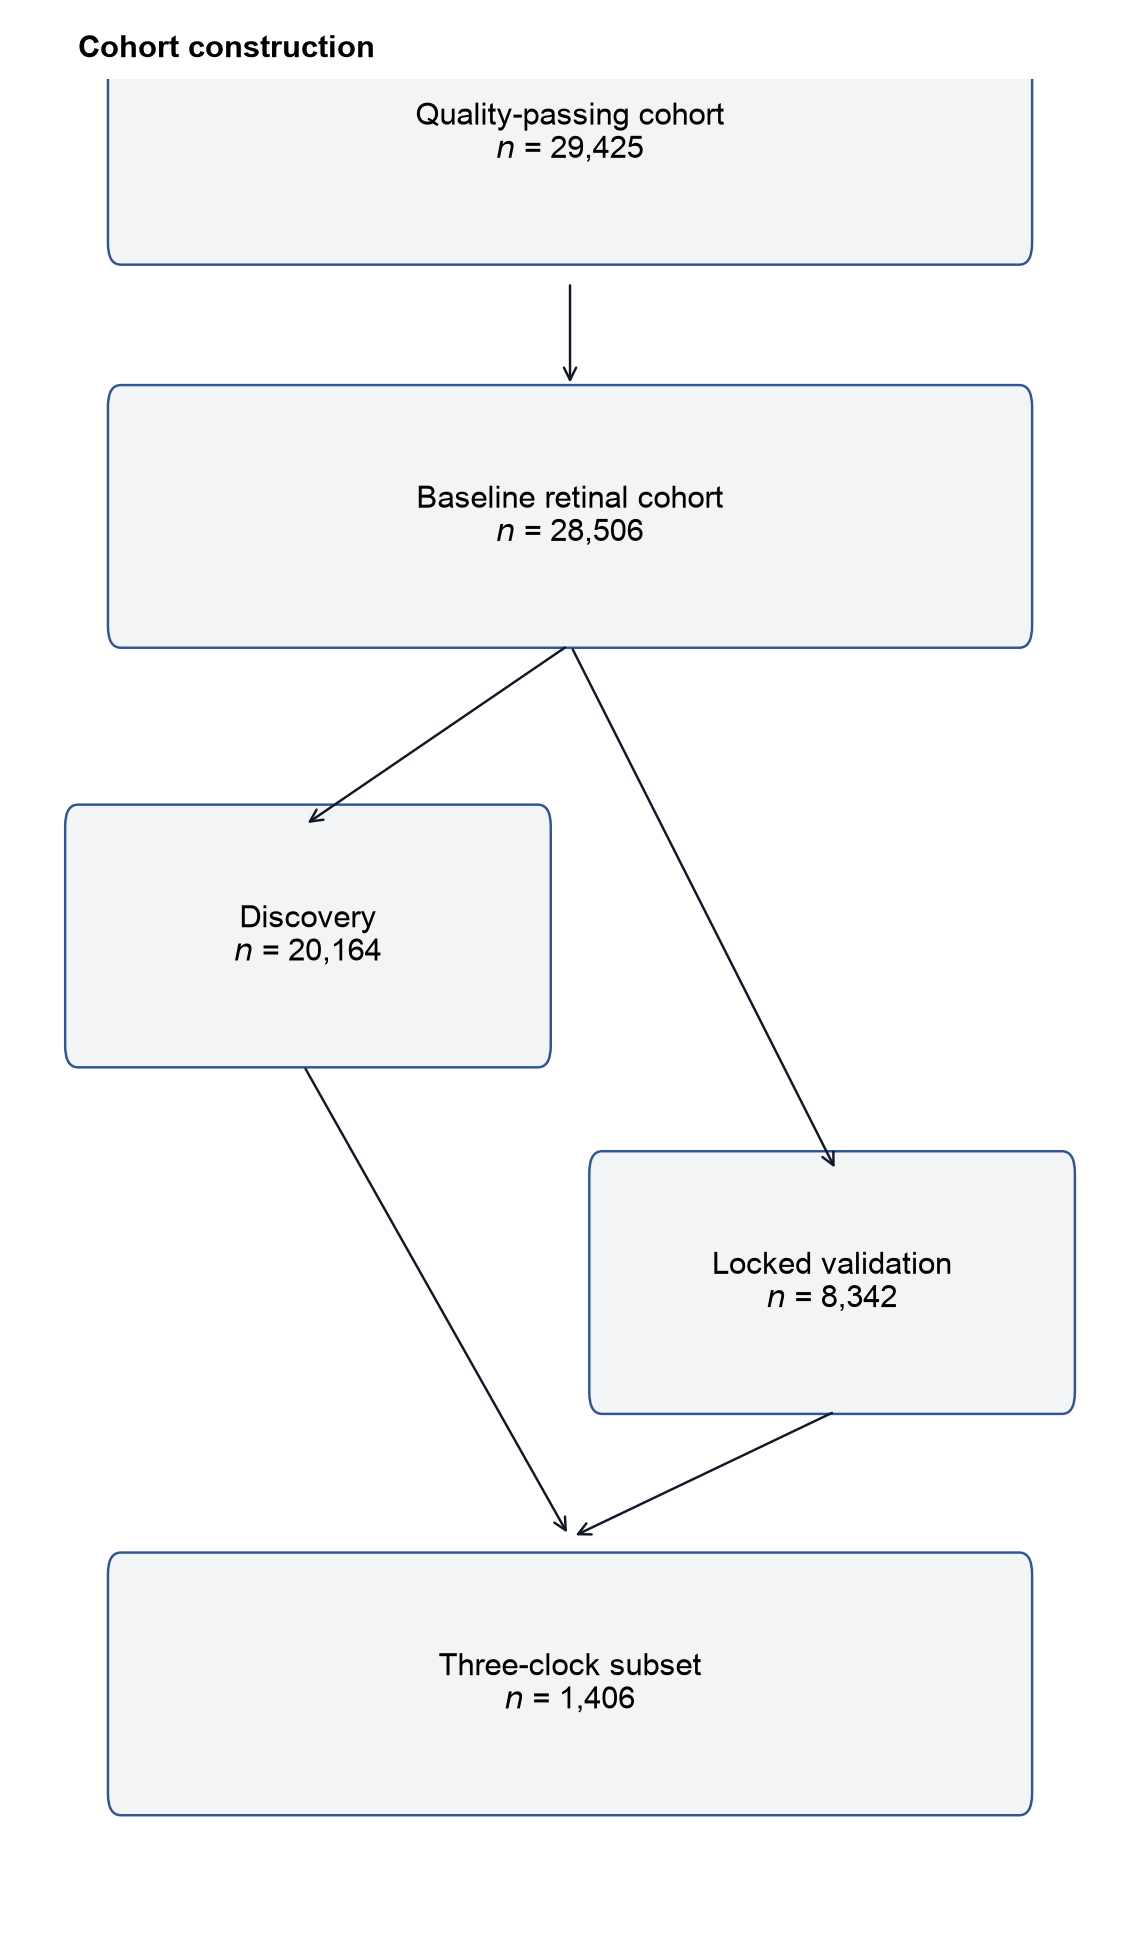

Source: figure_01_cohort_flow.csv (cell 55)

Figure 01 — Cohort construction and locked validation · Panel B

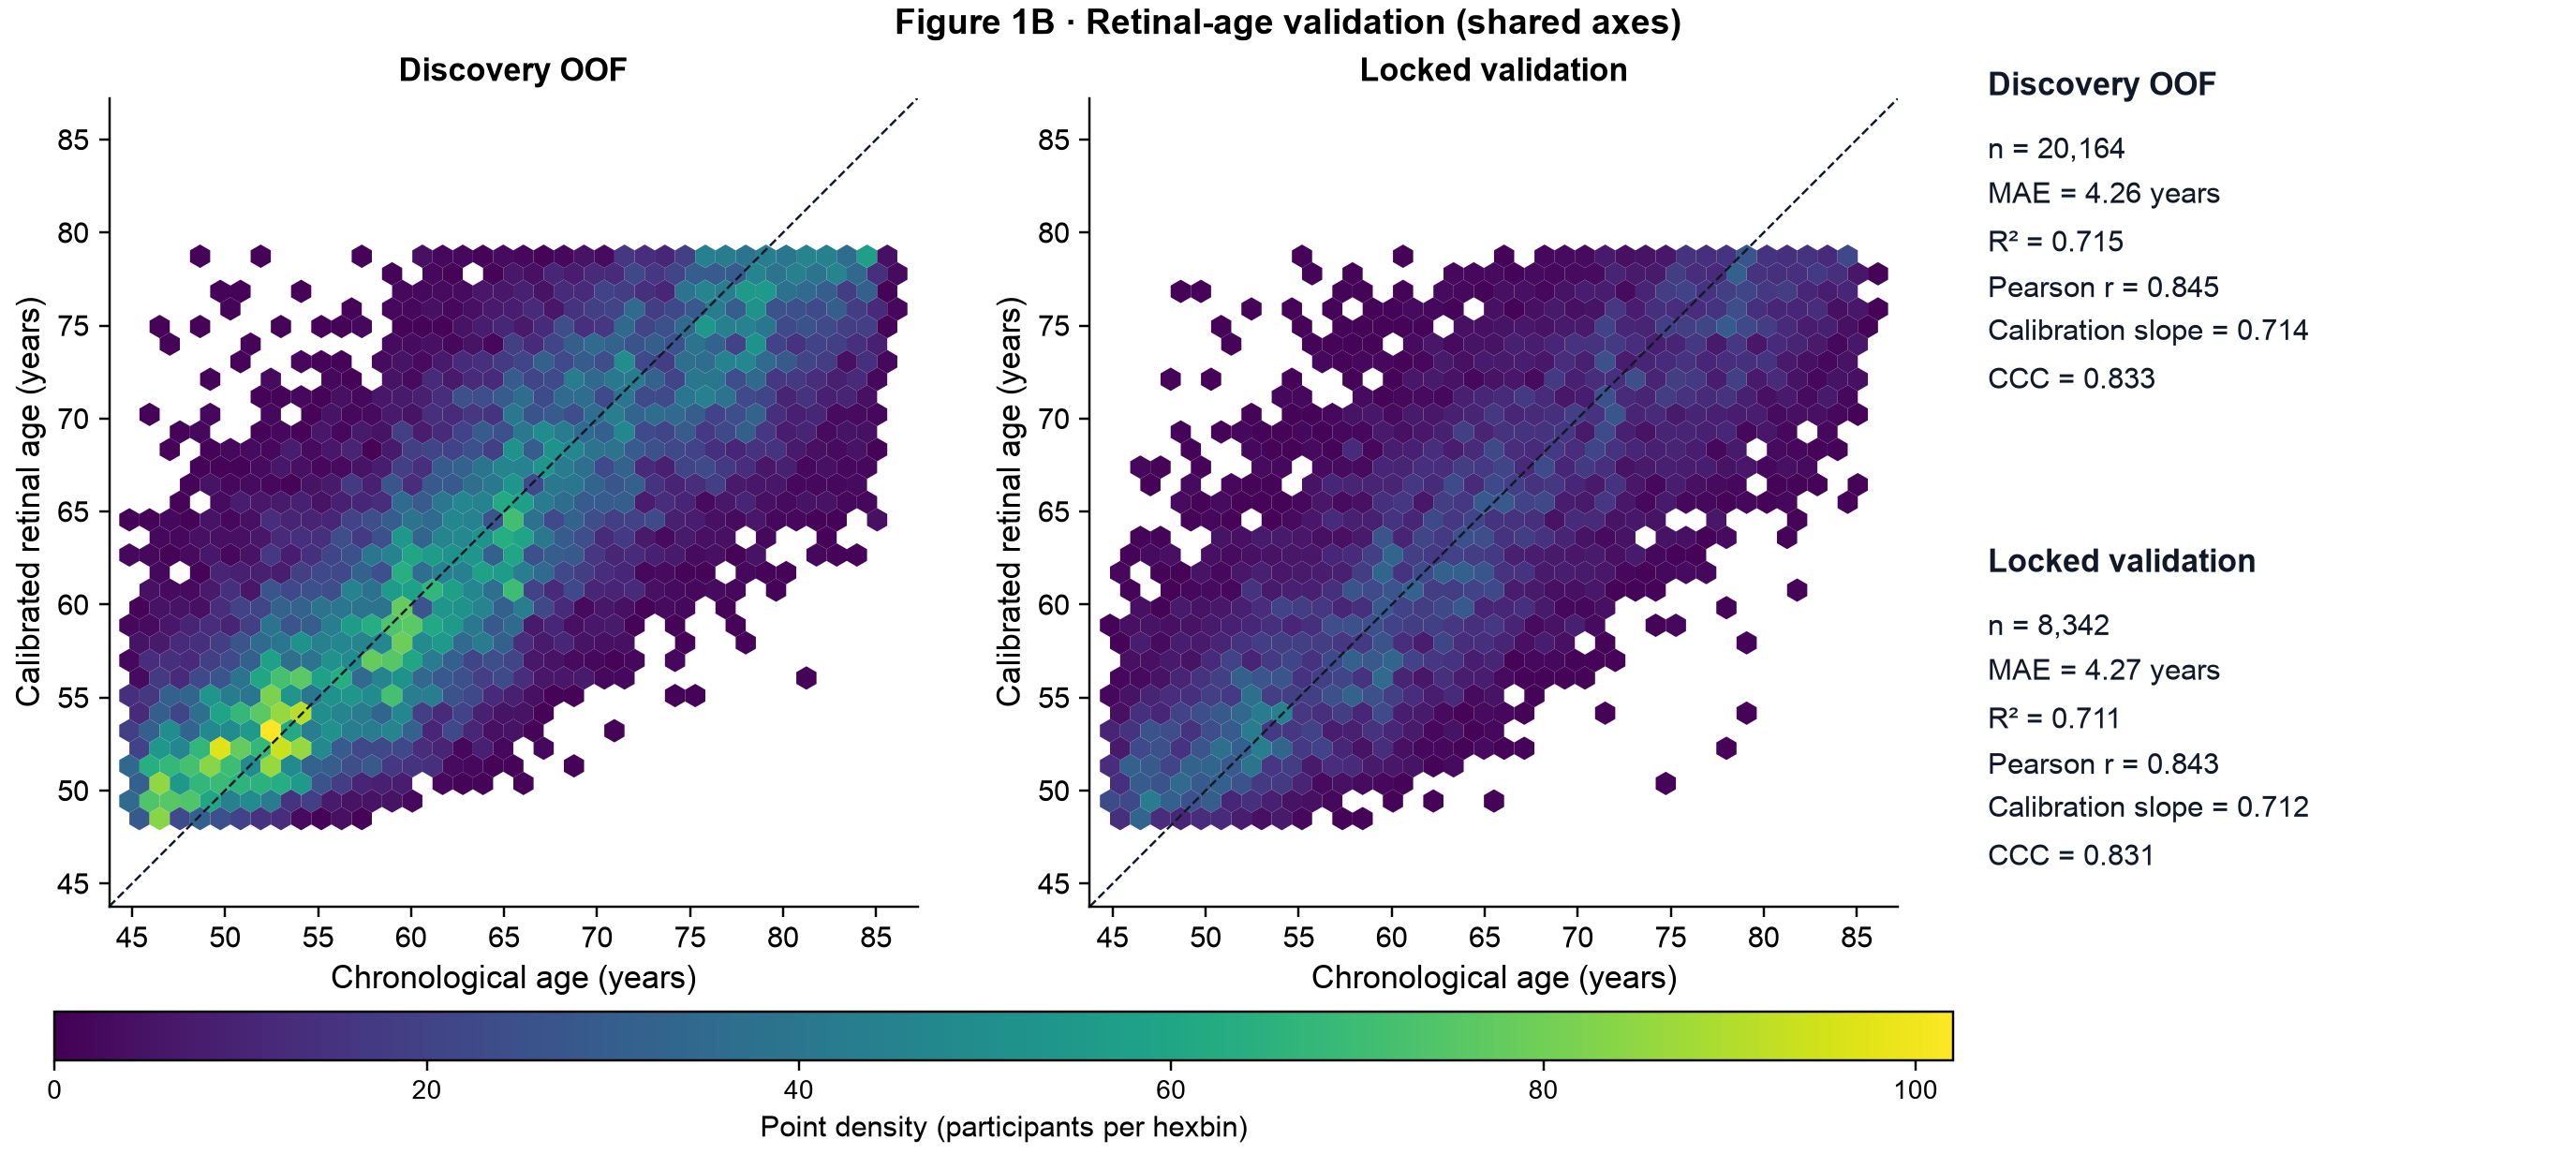

Source: figure_01_locked_validation_points.parquet (cell 41), locked_discovery_validation_metrics.csv (cell 41)

In [ ]:
# PNG series for manuscript Figure 01.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "01"])


Figure 02 — Shared chronological age and modality-specific acceleration · Panel A

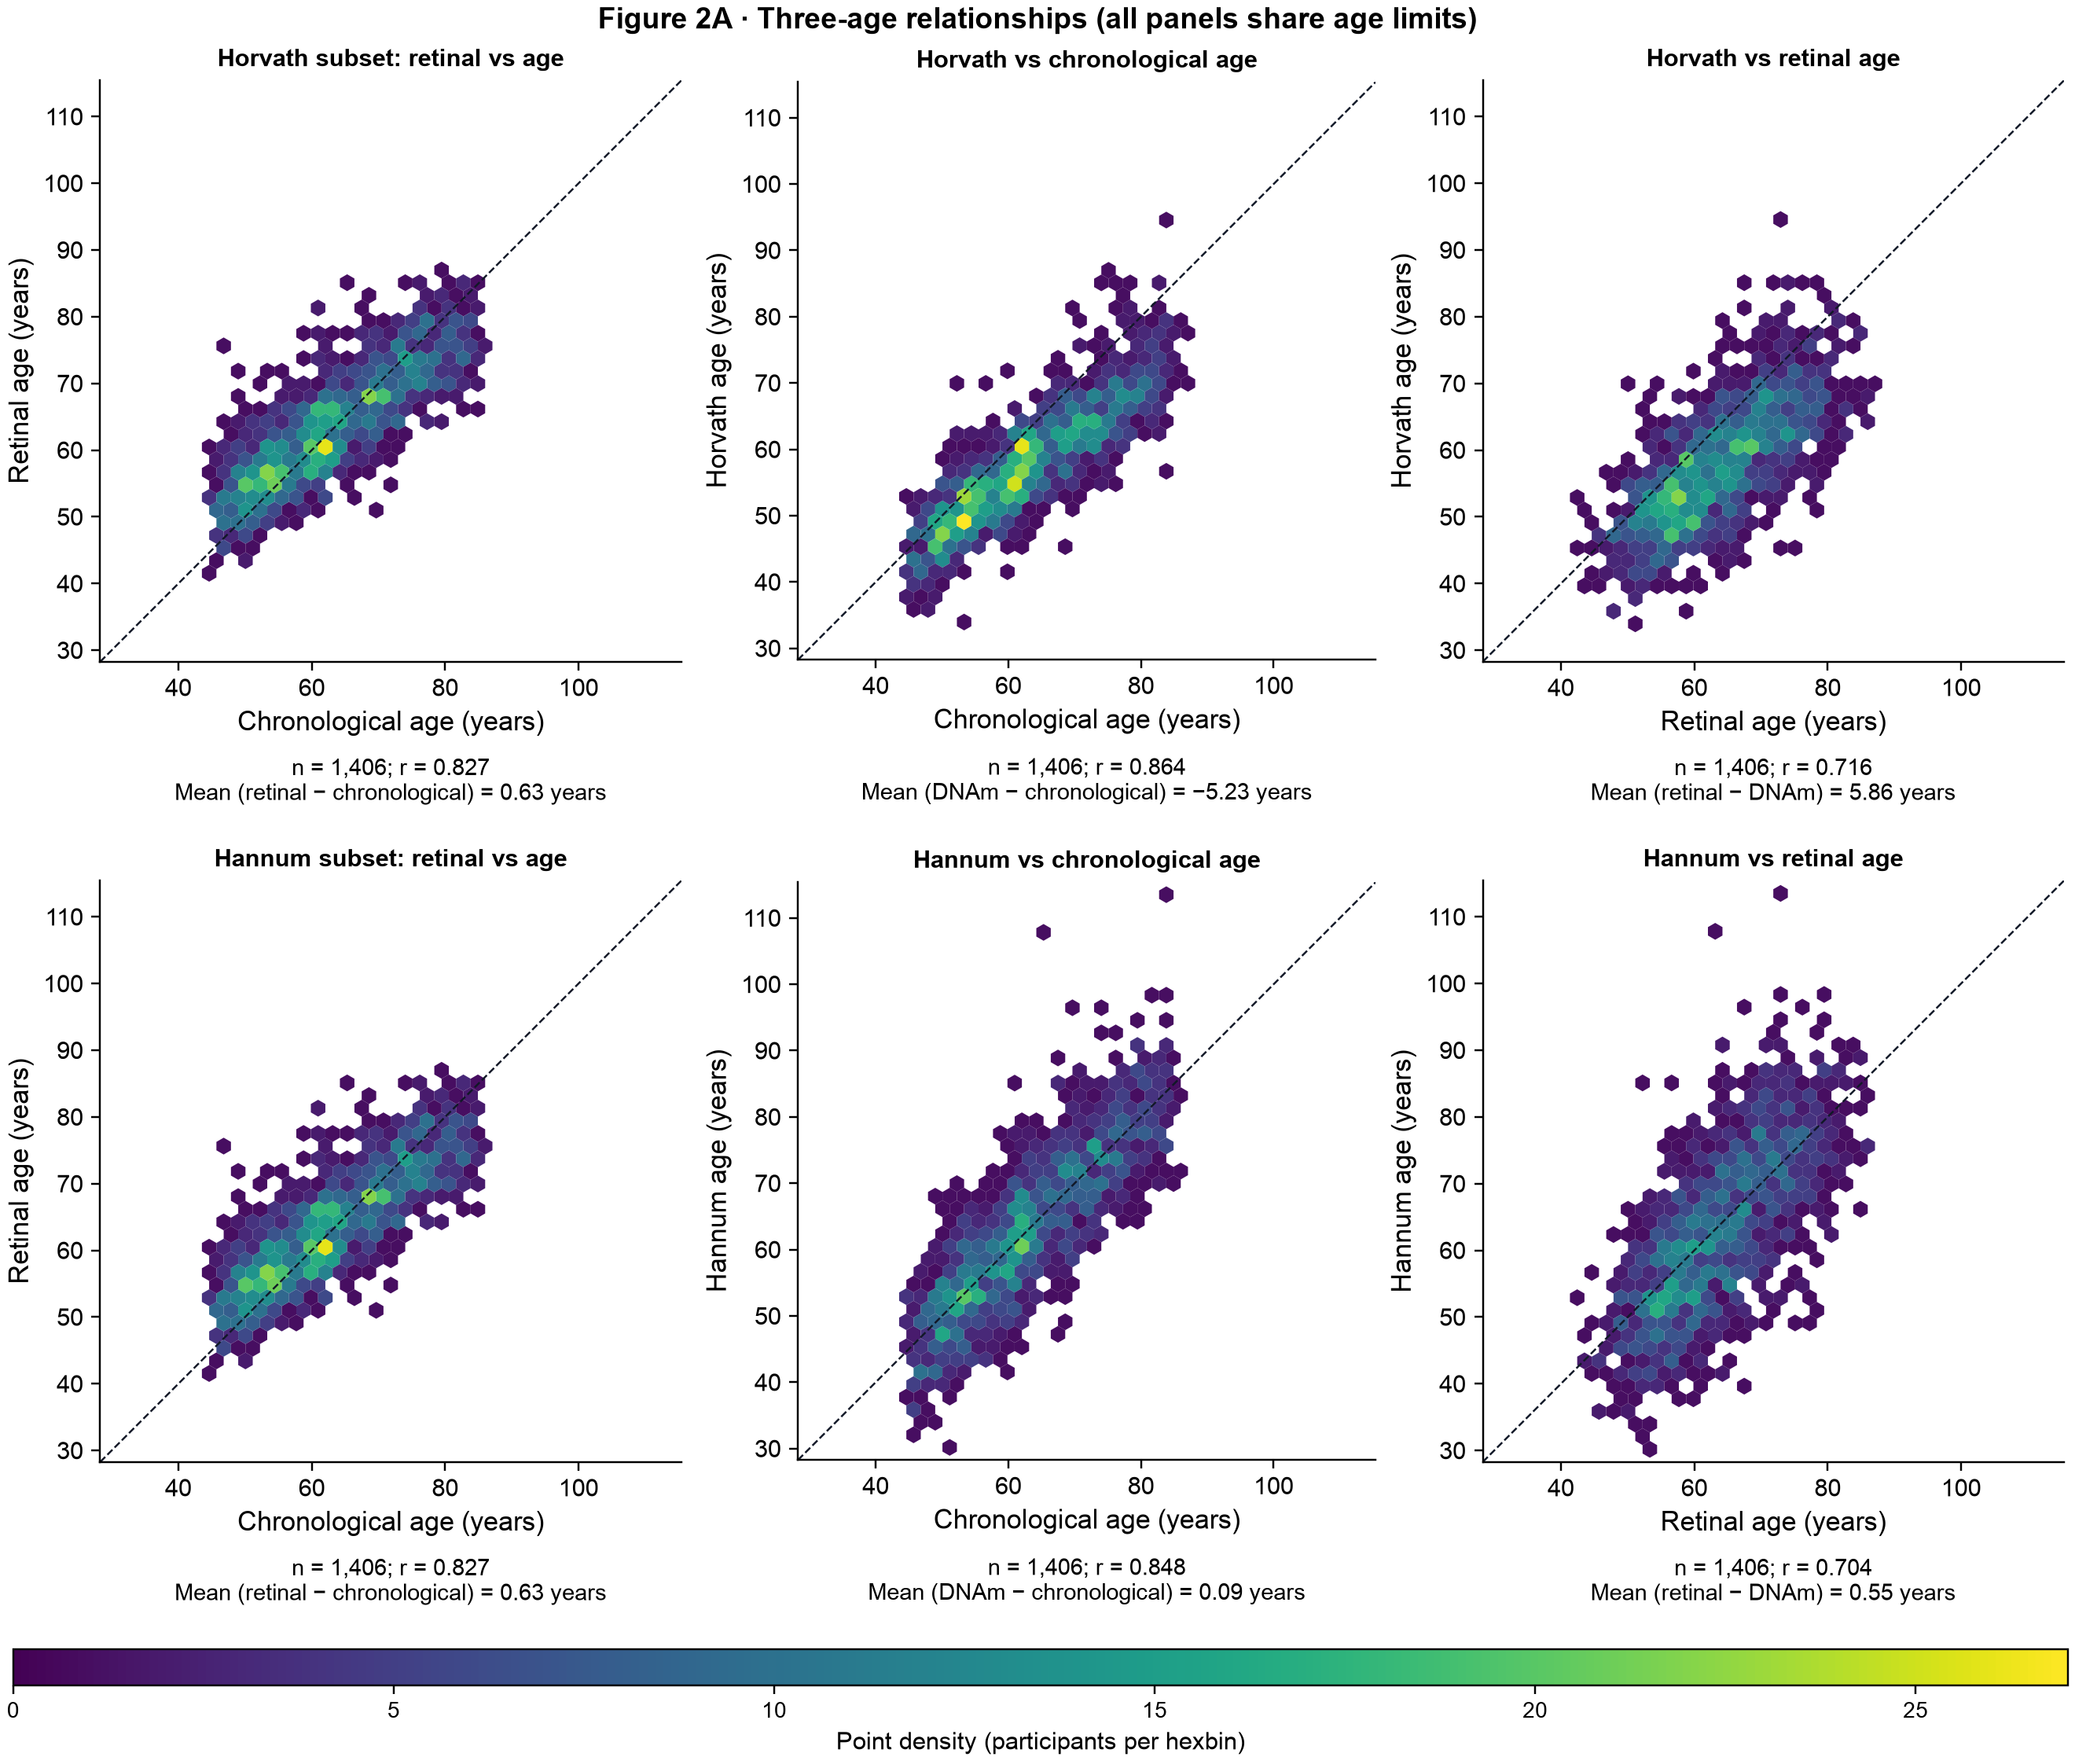

Source: figure_02_three_age_points.parquet (cell 17), three_age_agreement_metrics.csv (cell 17)

Figure 02 — Shared chronological age and modality-specific acceleration · Panel B

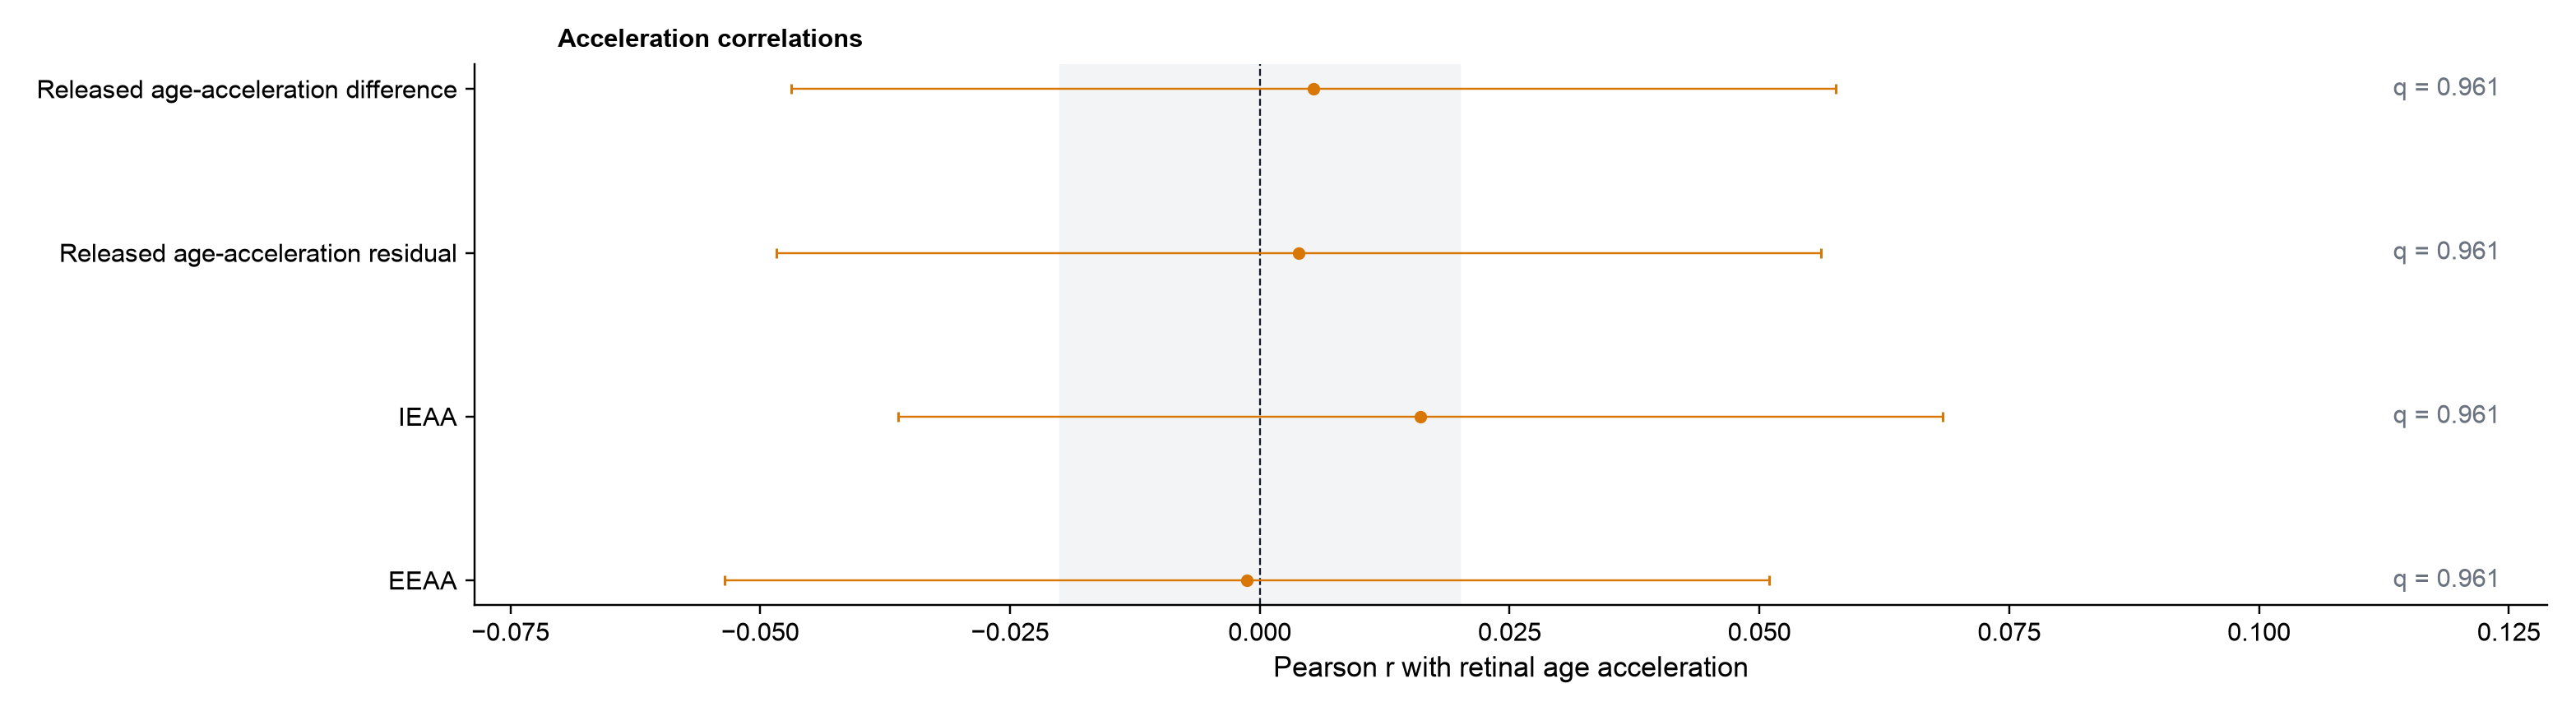

Source: figure_02_acceleration_correlation_forest.csv (cell 21)

In [ ]:
# PNG series for manuscript Figure 02.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "02"])


Figure 03 — Distinct phenotypic domains · Panel A

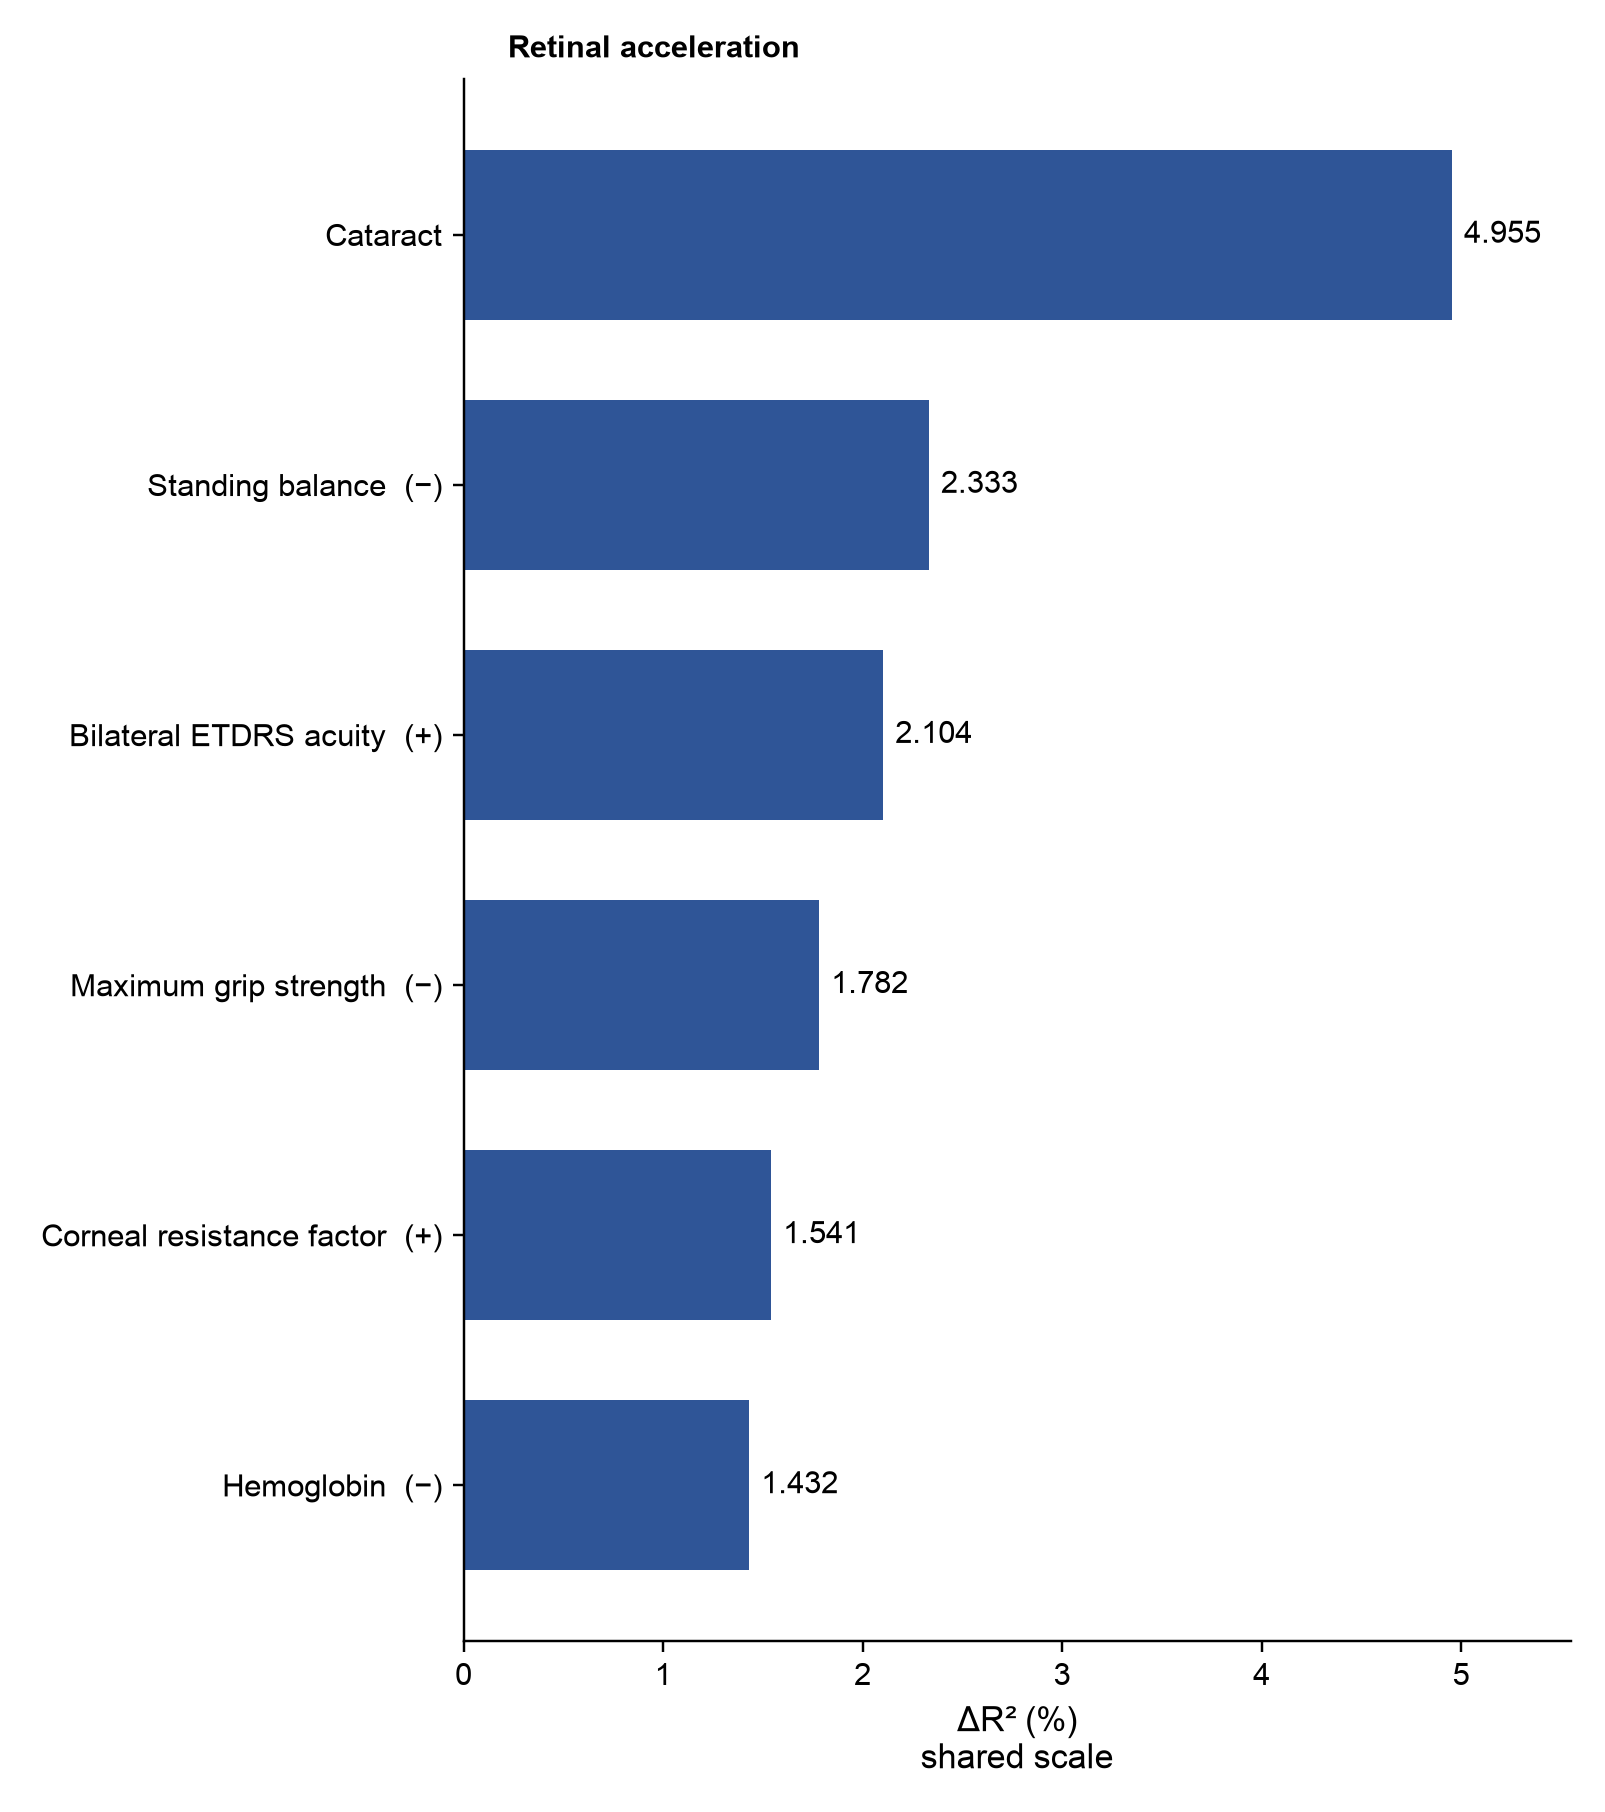

Source: questionnaire_phenome_scan_tests.csv (cell 34)

Figure 03 — Distinct phenotypic domains · Panel B

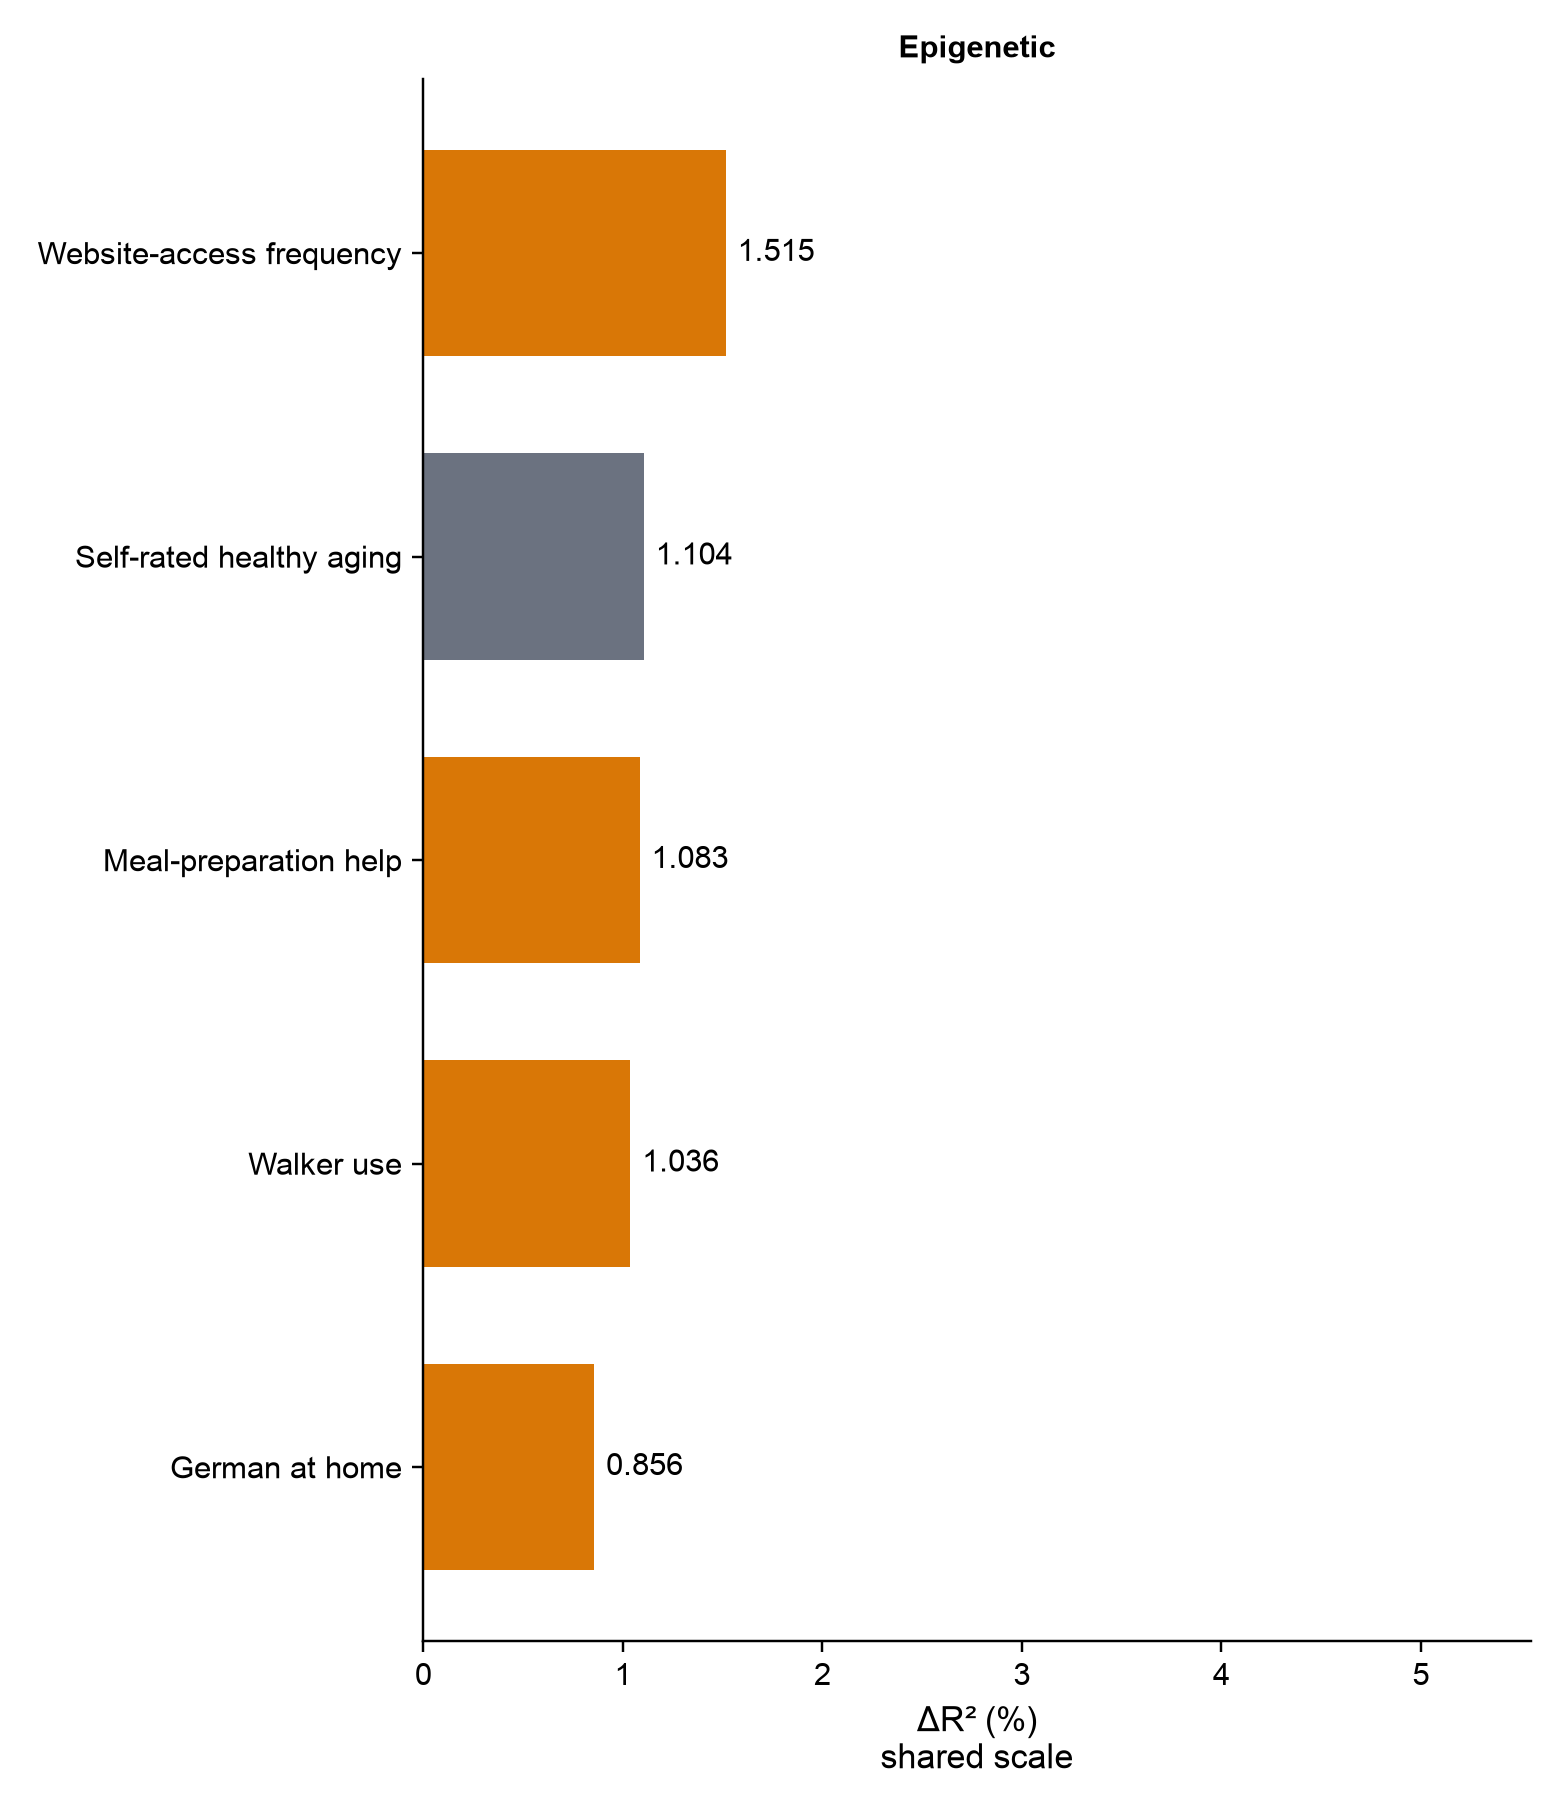

Source: questionnaire_phenome_scan_tests.csv (cell 34)

In [ ]:
# PNG series for manuscript Figure 03.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "03"])


Figure 04 — Retinal stability across eyes, specifications, and time · Panel A

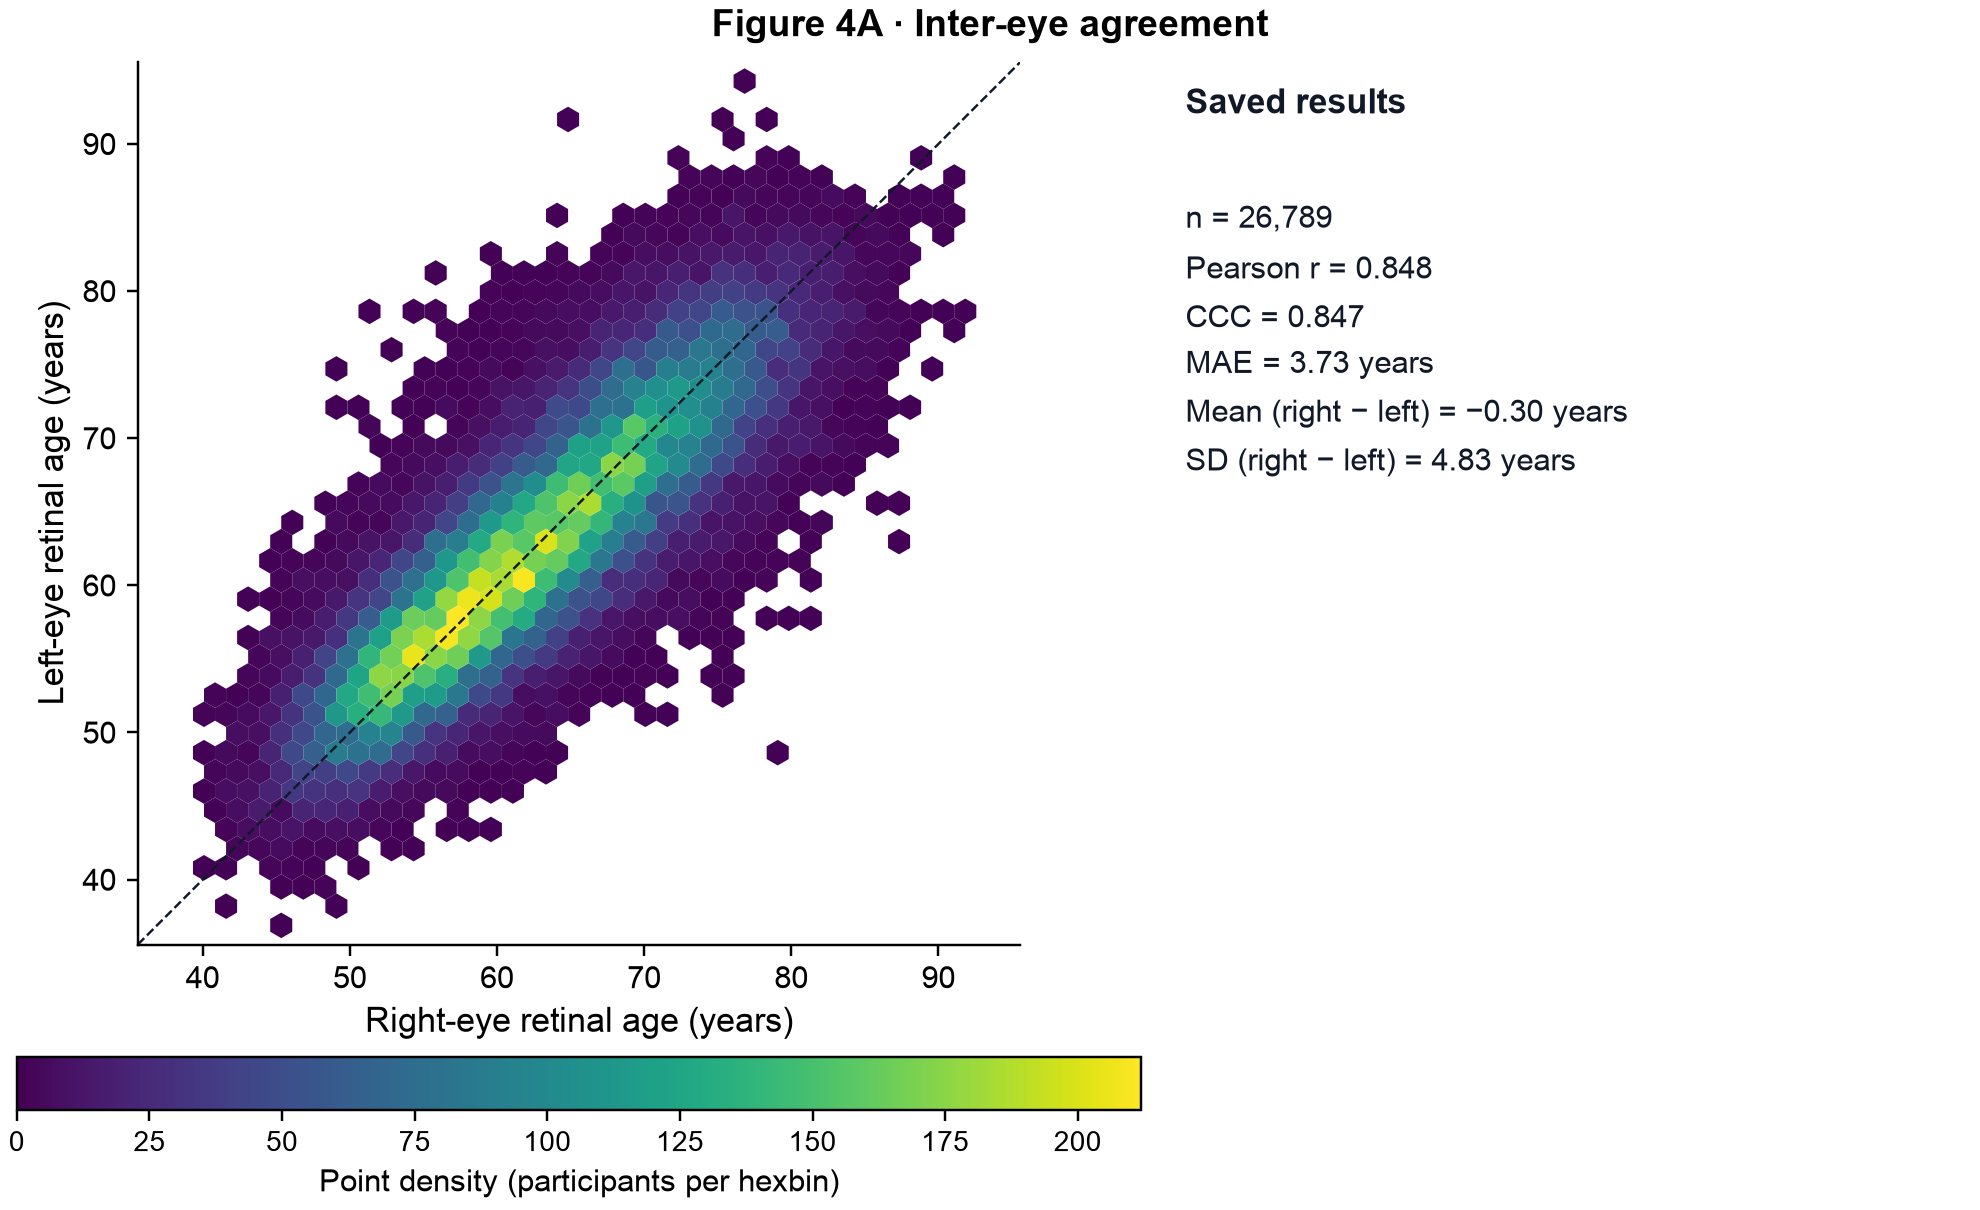

Source: figure_04_inter_eye_points.parquet (cell 47), inter_eye_reliability.csv (cell 47)

Figure 04 — Retinal stability across eyes, specifications, and time · Panel B

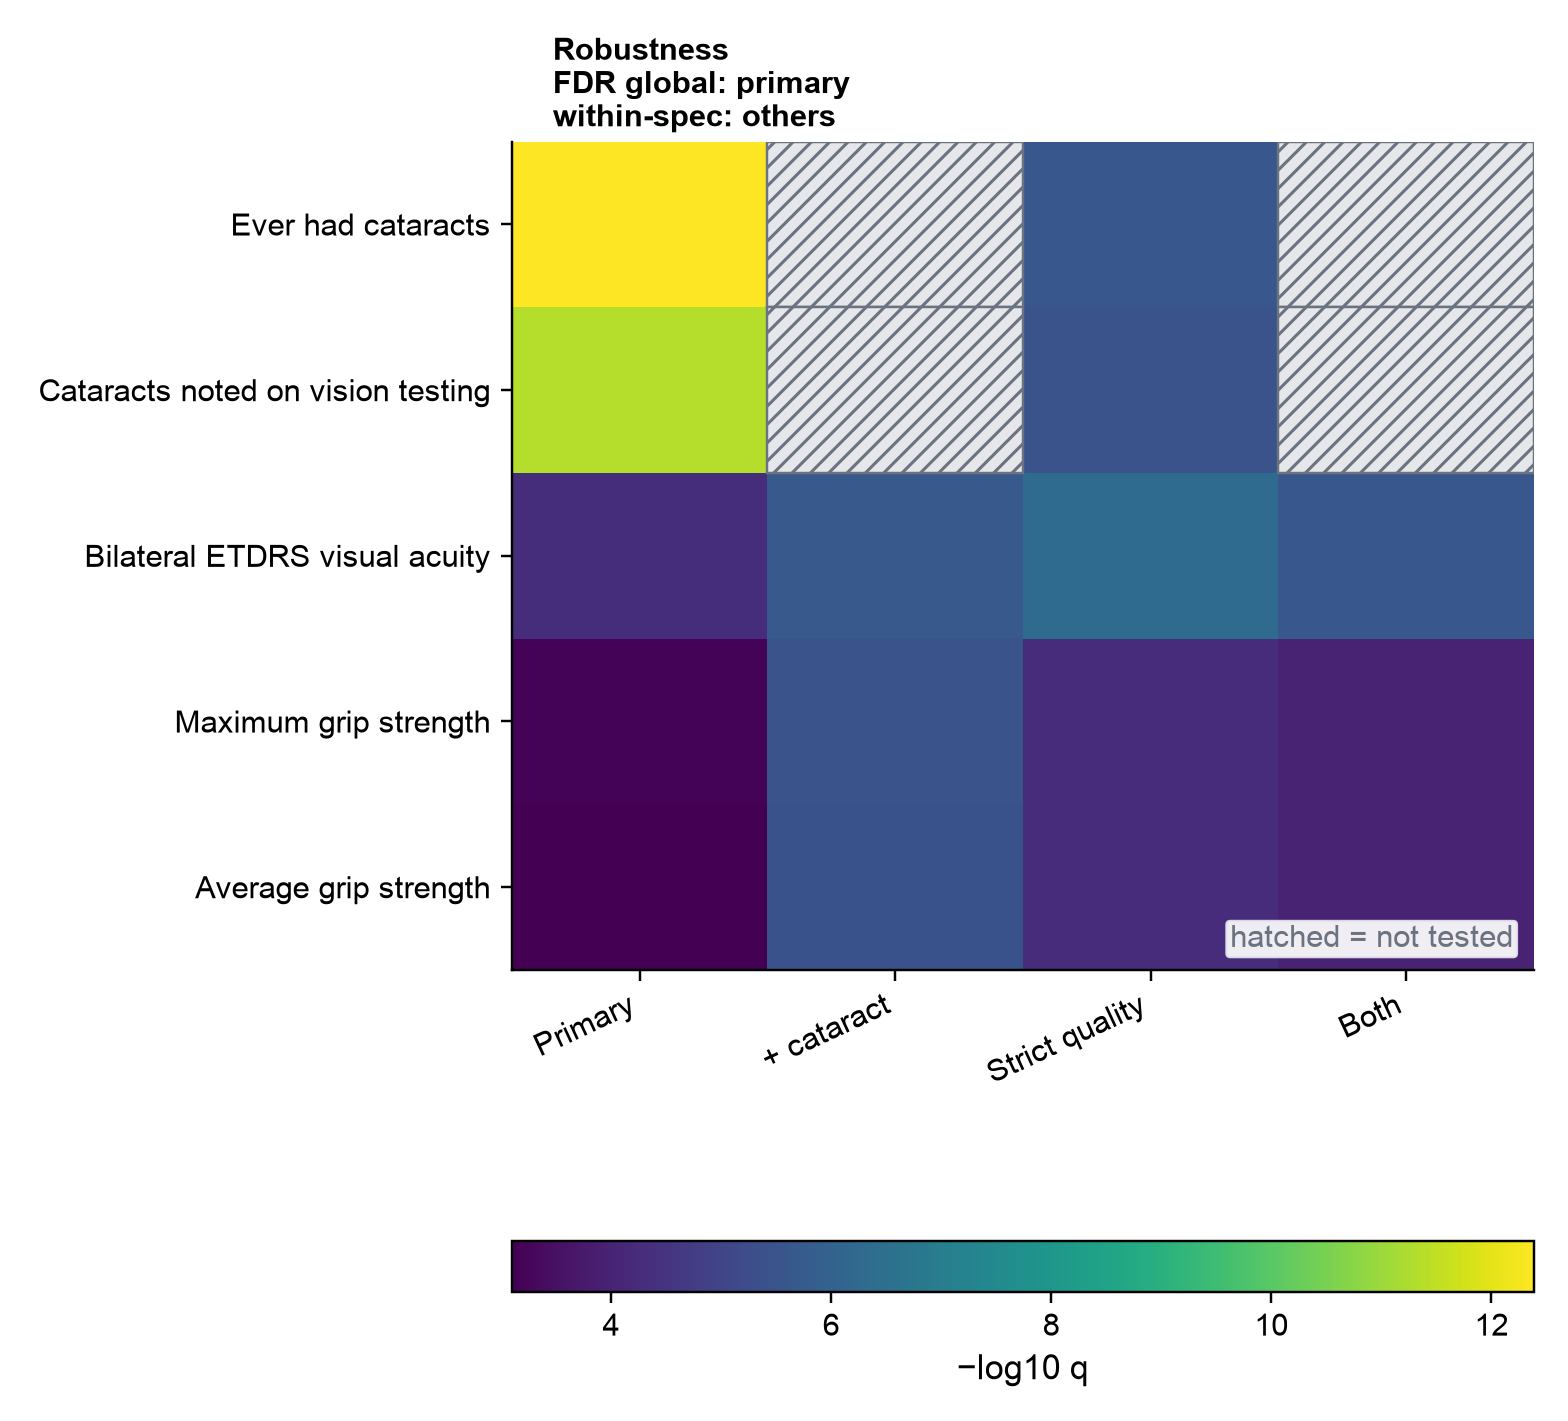

Source: acuity_grip_cataract_quality_sensitivity.csv (cell 37)

Figure 04 — Retinal stability across eyes, specifications, and time · Panel C

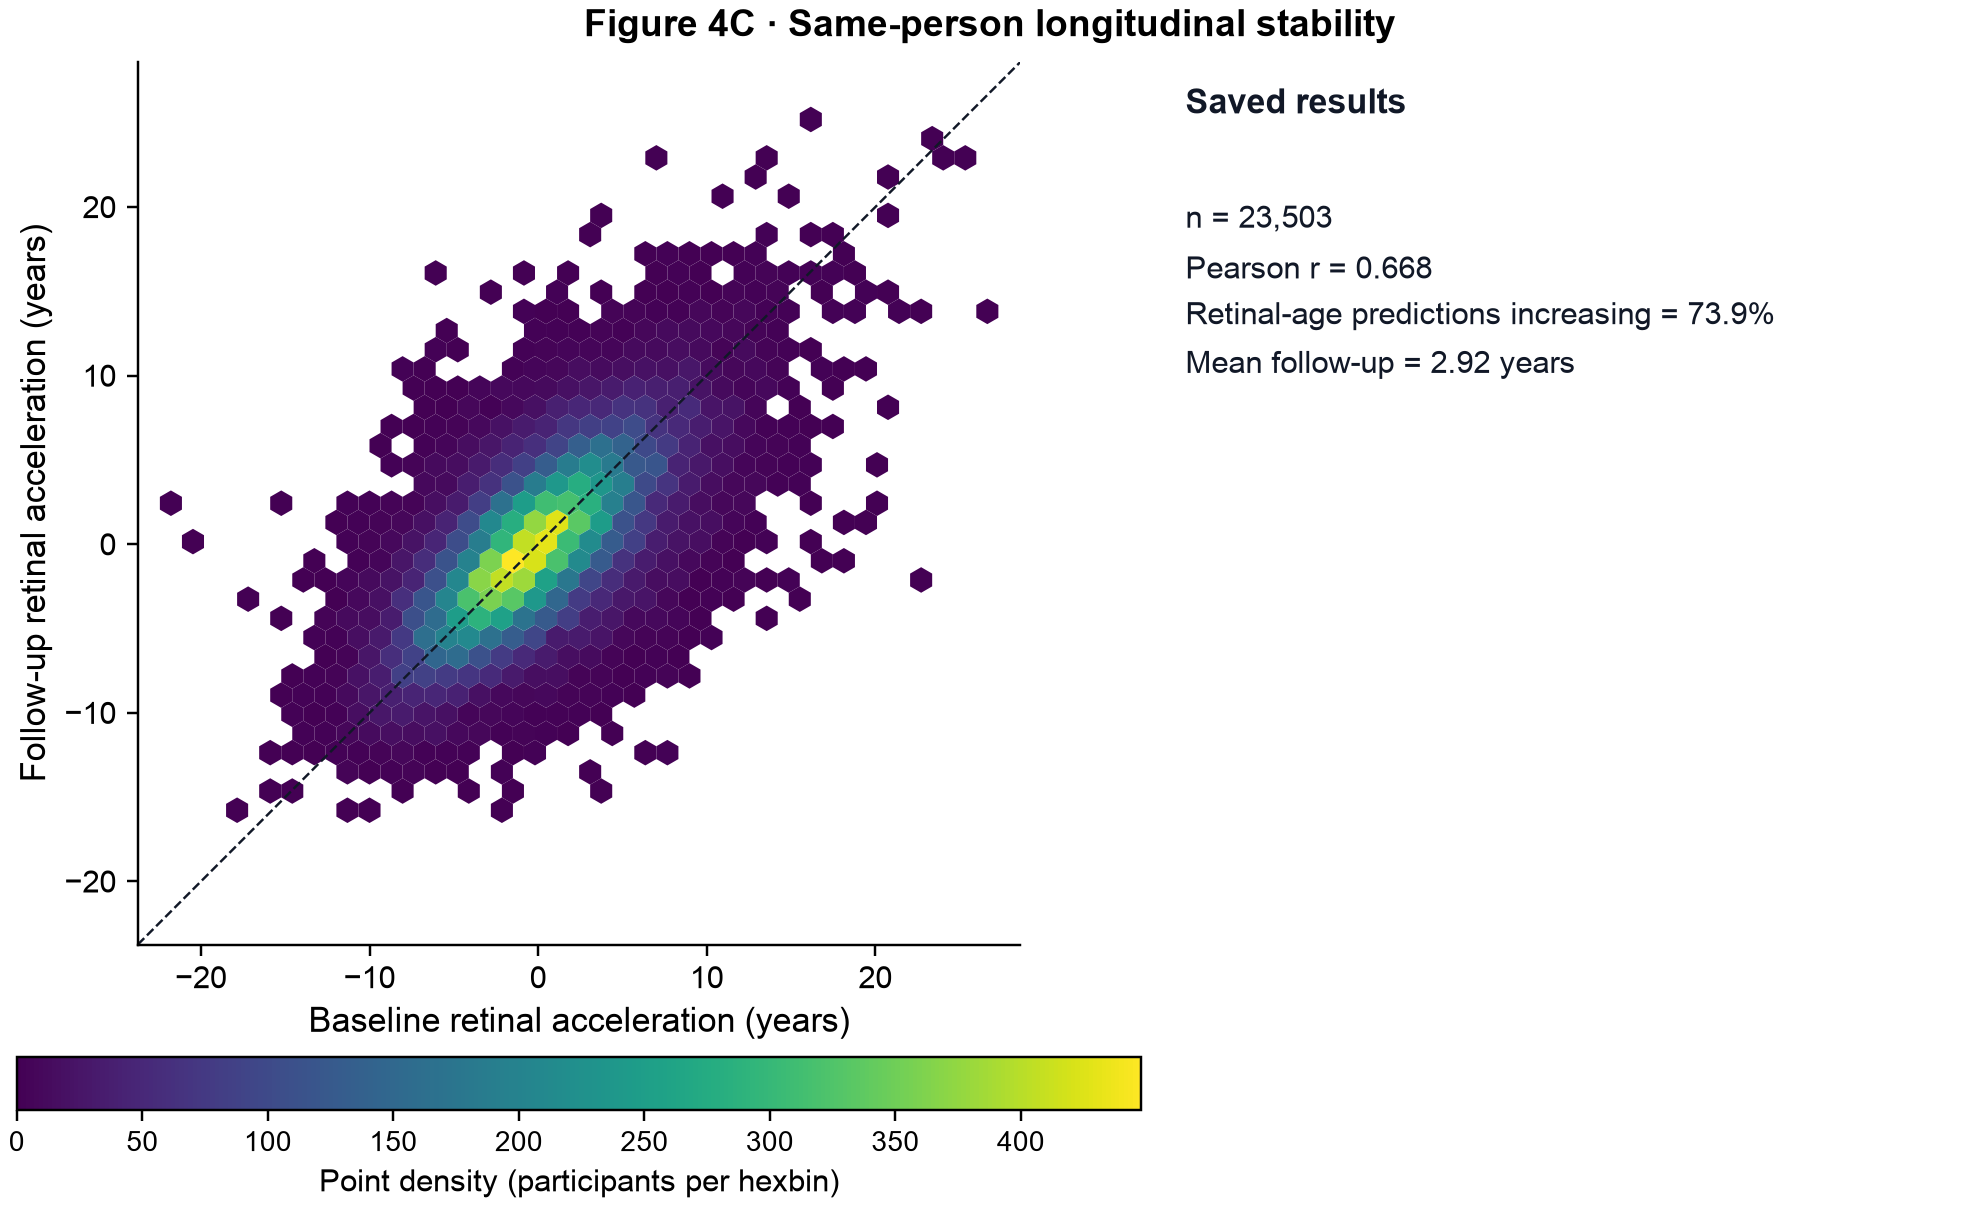

Source: figure_04_longitudinal_points.parquet (cell 53), longitudinal_retinal_change_repeatability.csv (cell 53)

Figure 04 — Retinal stability across eyes, specifications, and time · Panel D

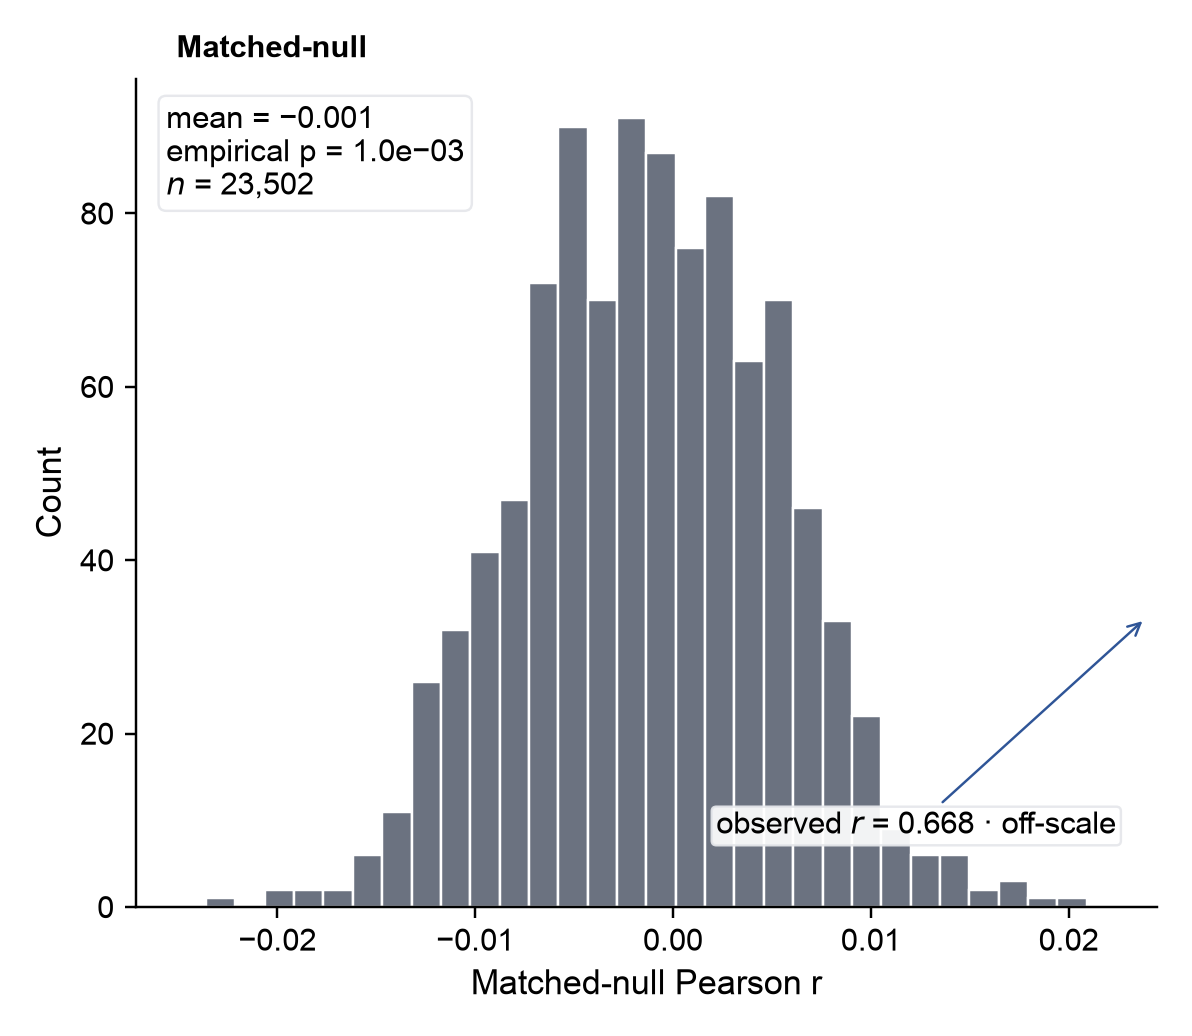

Source: longitudinal_matched_null_distribution.csv (cell 53), longitudinal_same_person_matched_null_test.csv (cell 53)

In [ ]:
# PNG series for manuscript Figure 04.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "04"])


Figure 05 — Cross-modal longitudinal prediction · Panel A

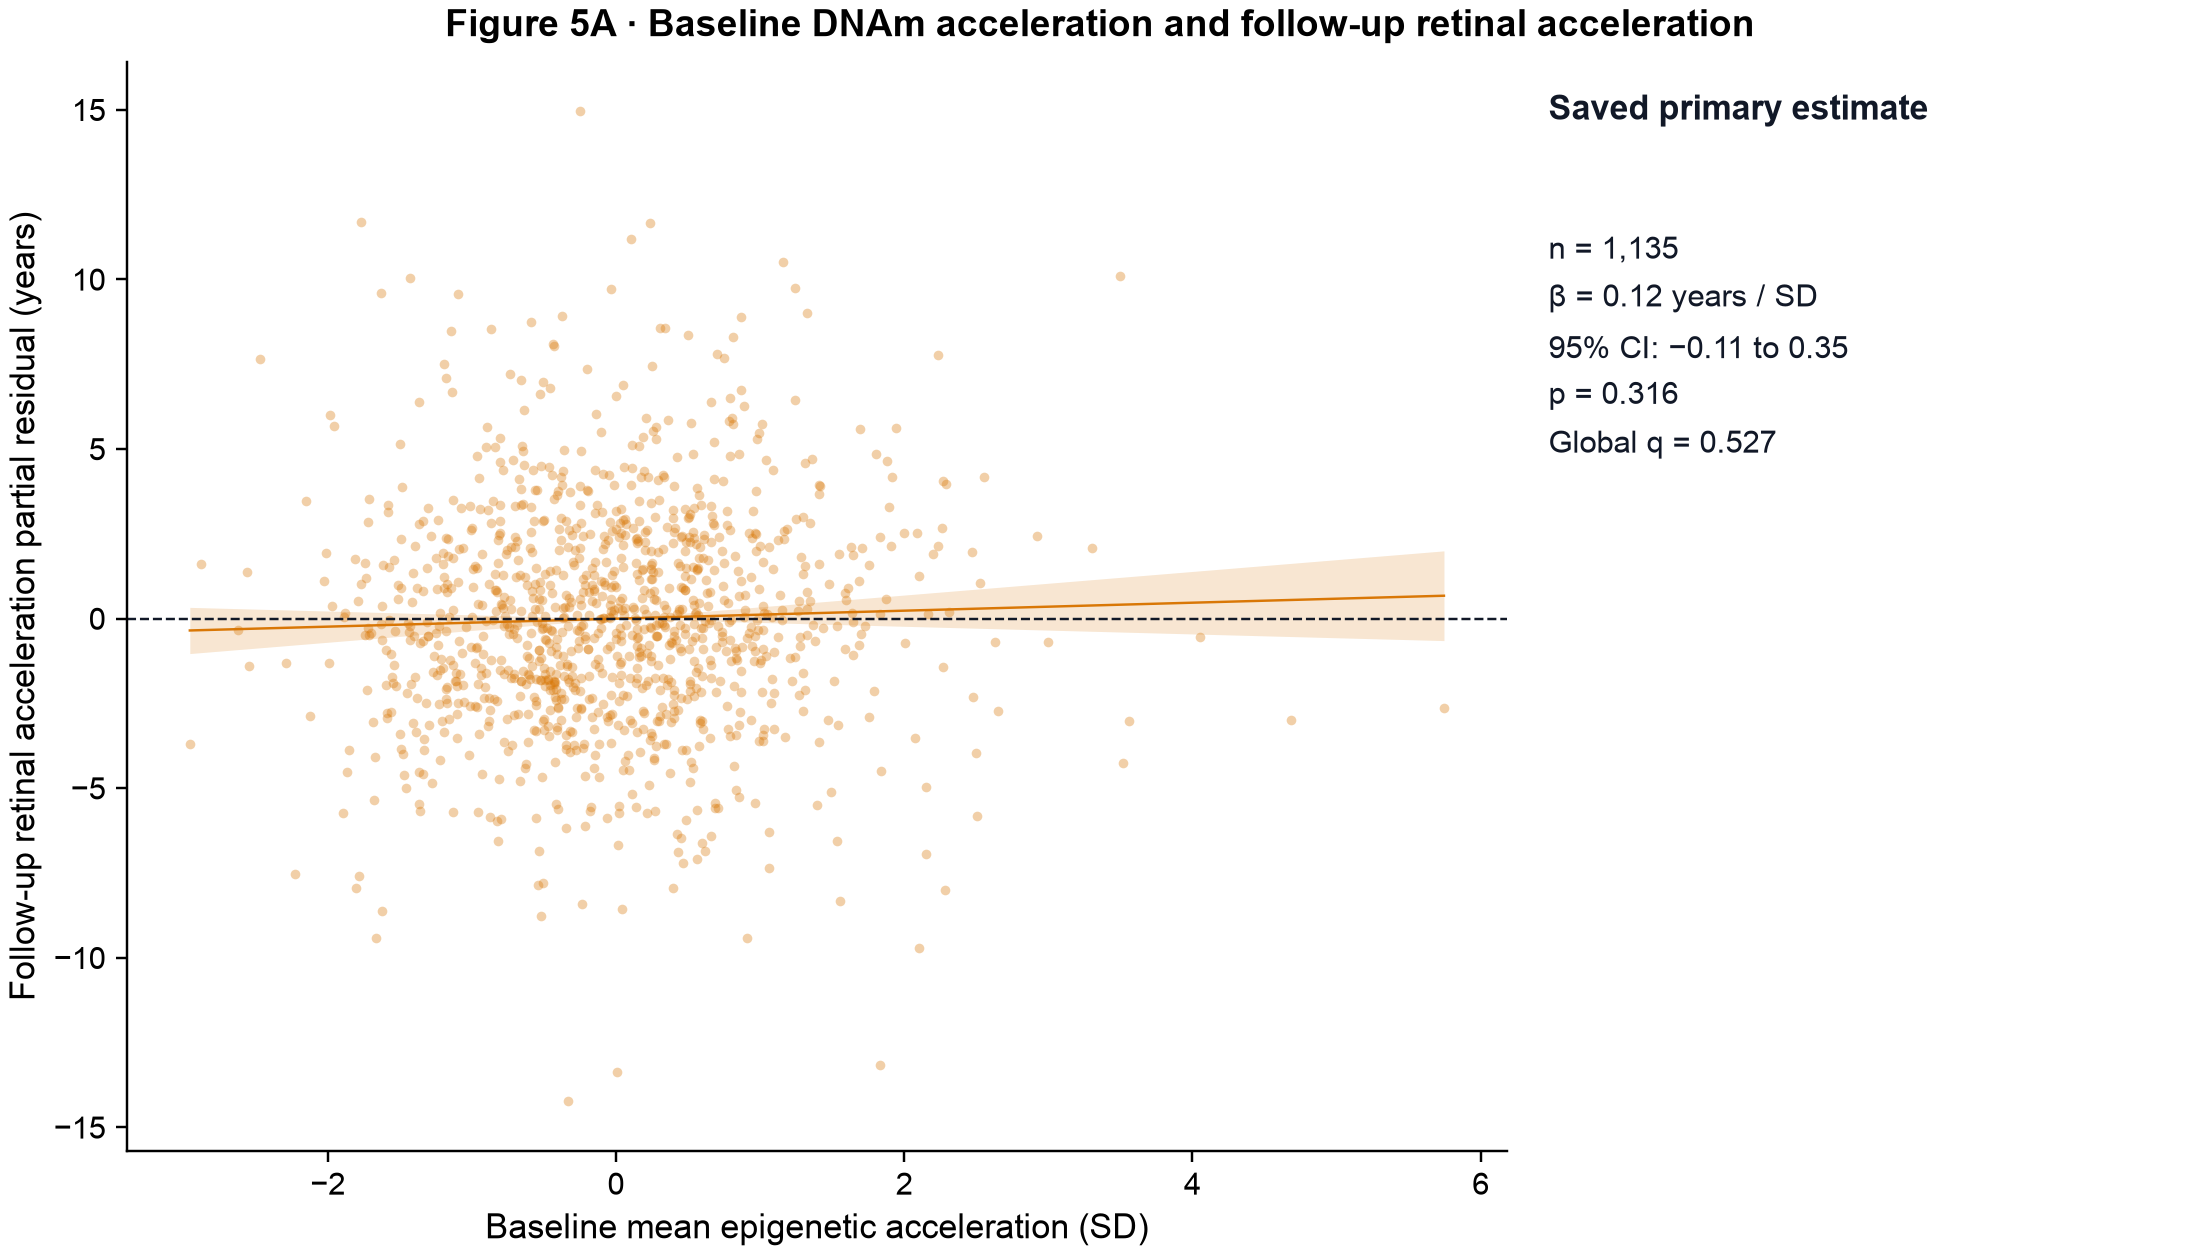

Source: figure_05a_partial_residual_points.parquet (cell 39), baseline_epigenetic_to_followup_retinal_associations.csv (cell 39)

Figure 05 — Cross-modal longitudinal prediction · Panel B

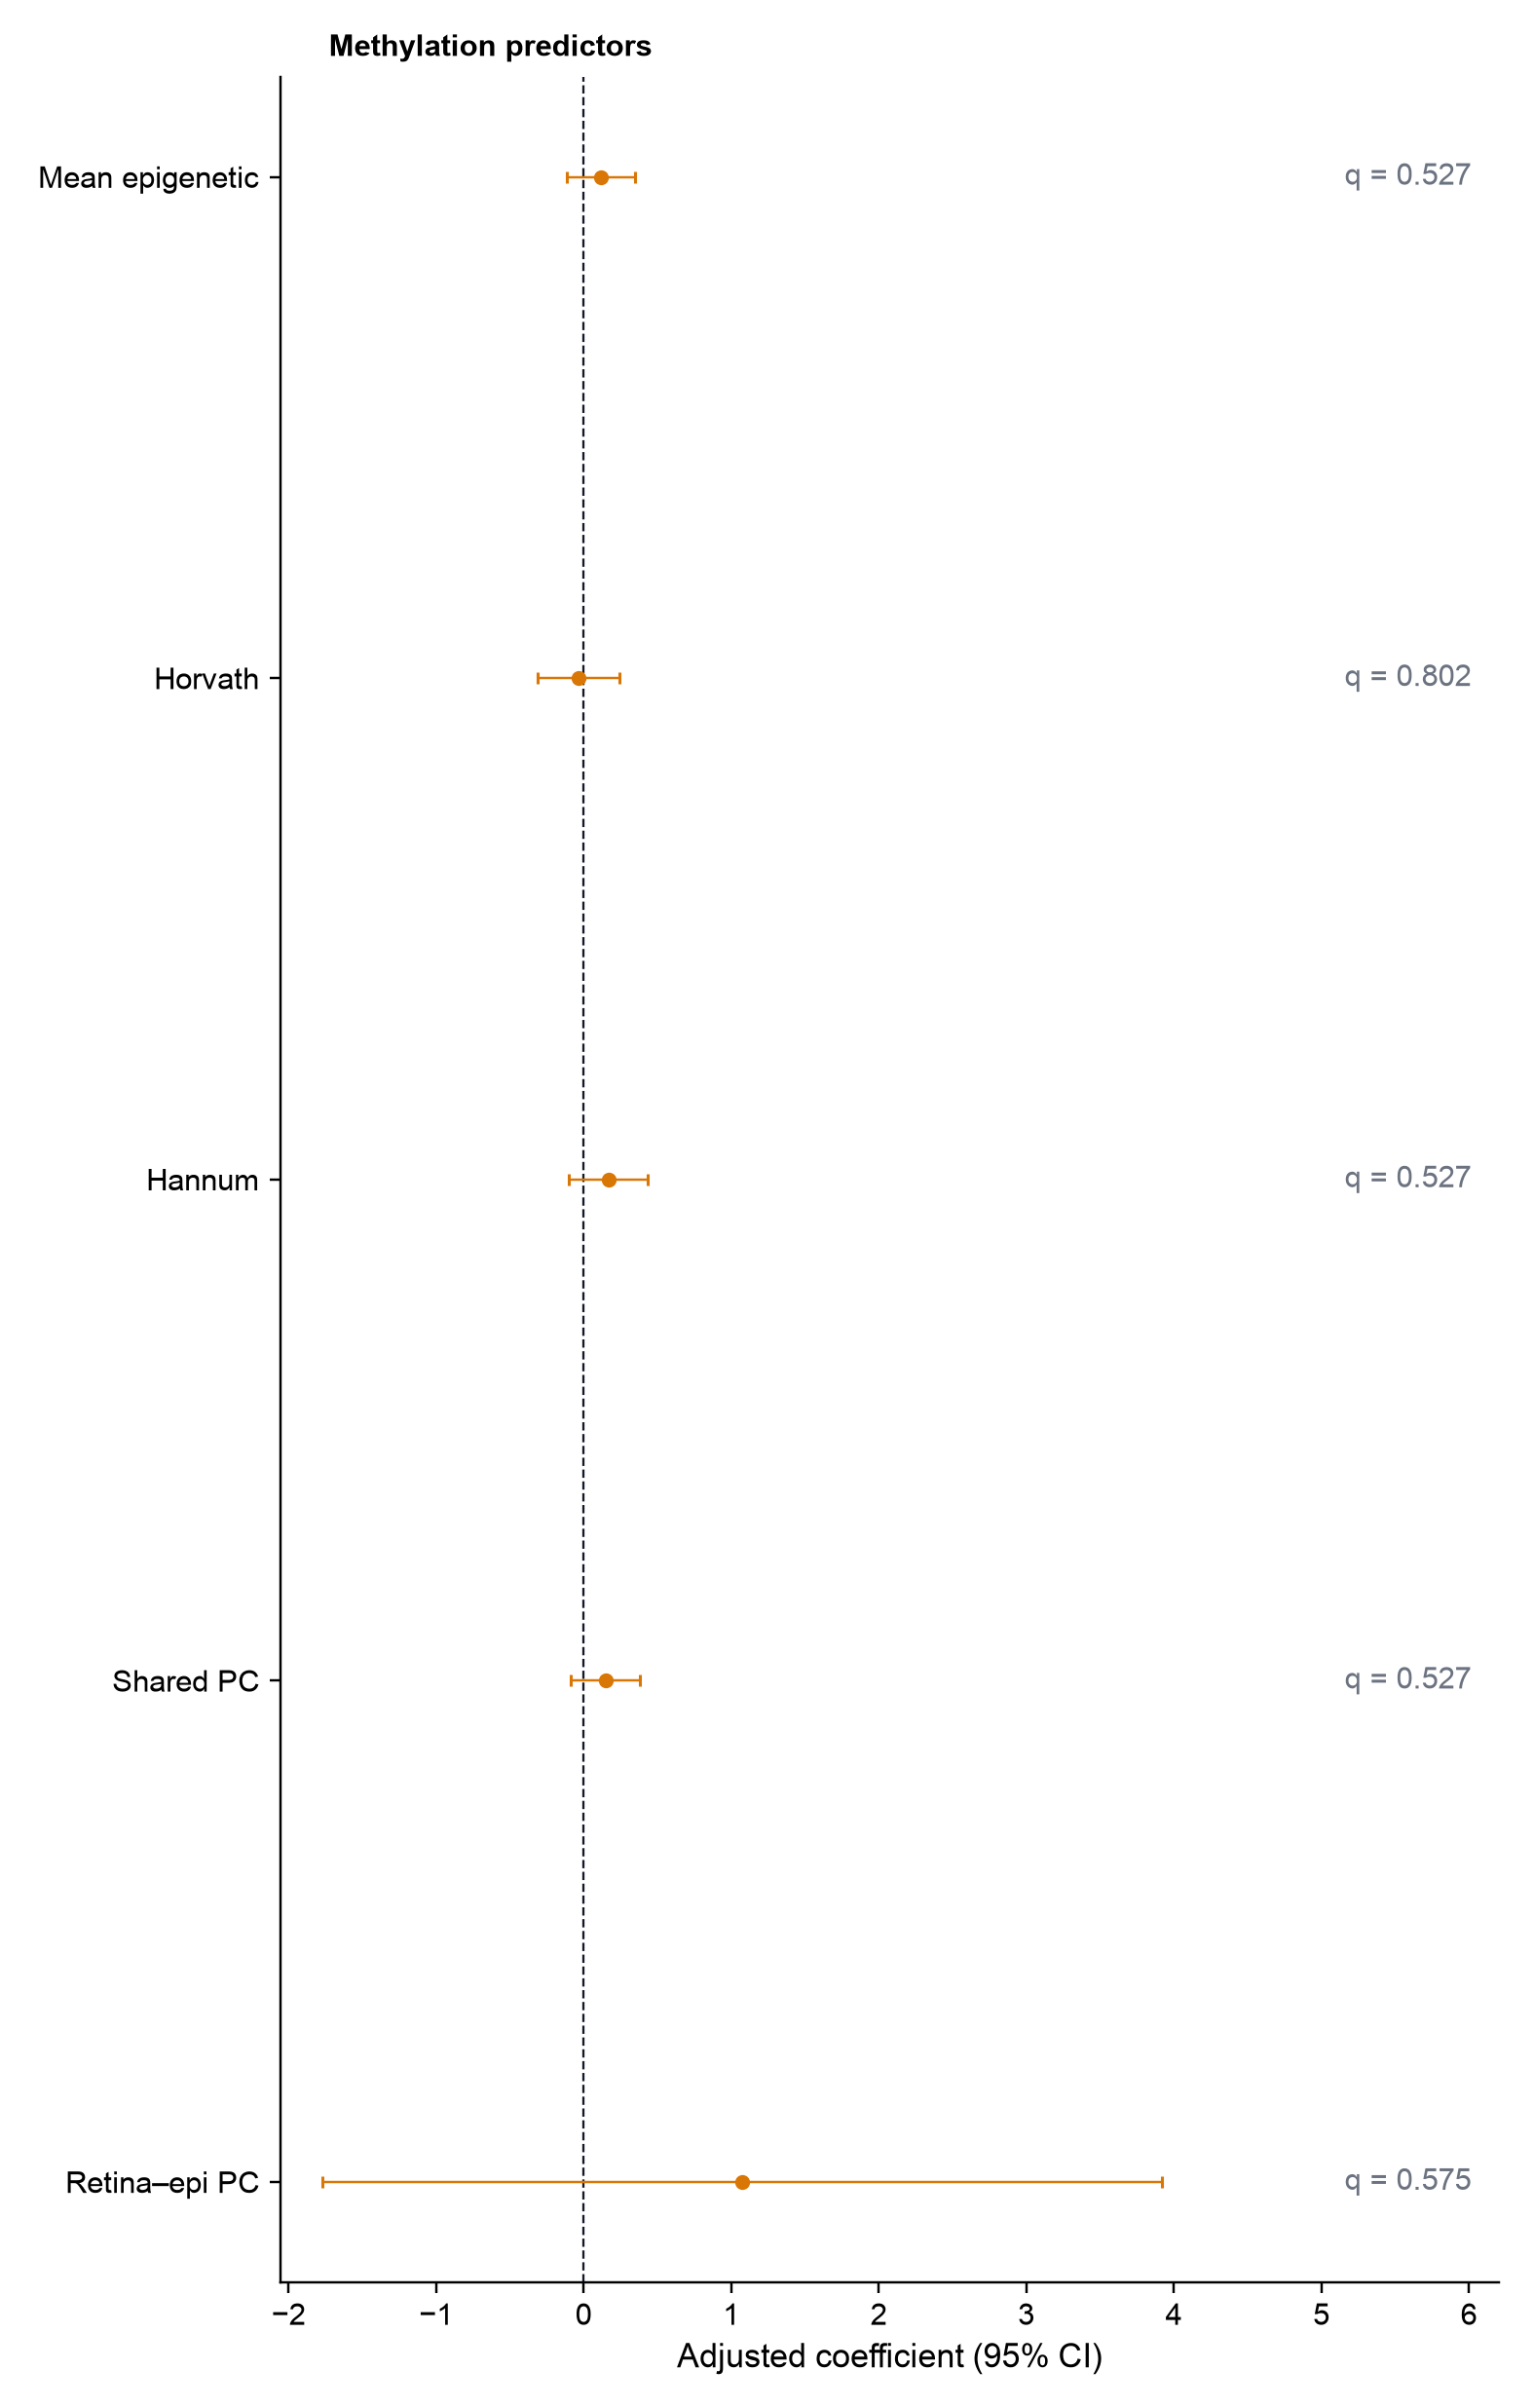

Source: baseline_epigenetic_to_followup_retinal_associations.csv (cell 39)

Figure 05 — Cross-modal longitudinal prediction · Panel C

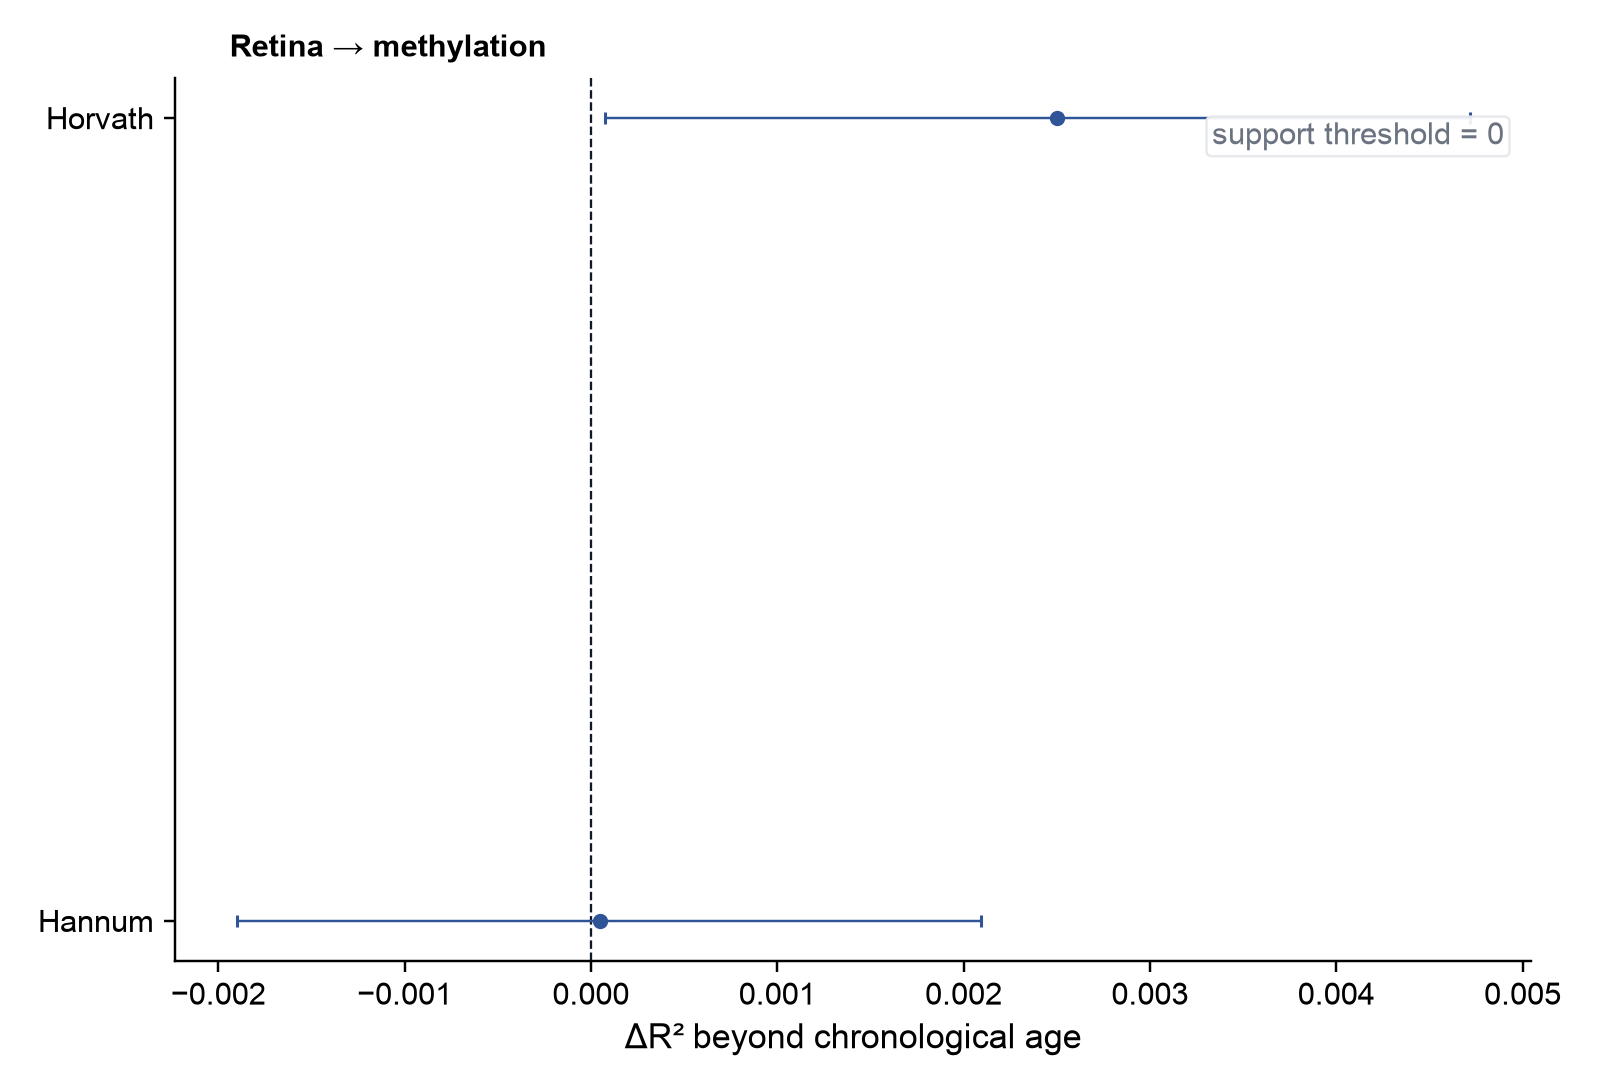

Source: epigenetic_target_prediction_beyond_age.csv (cell 49)

In [ ]:
# PNG series for manuscript Figure 05.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "05"])


Figure S1 — Complete age-model diagnostics · Panel A

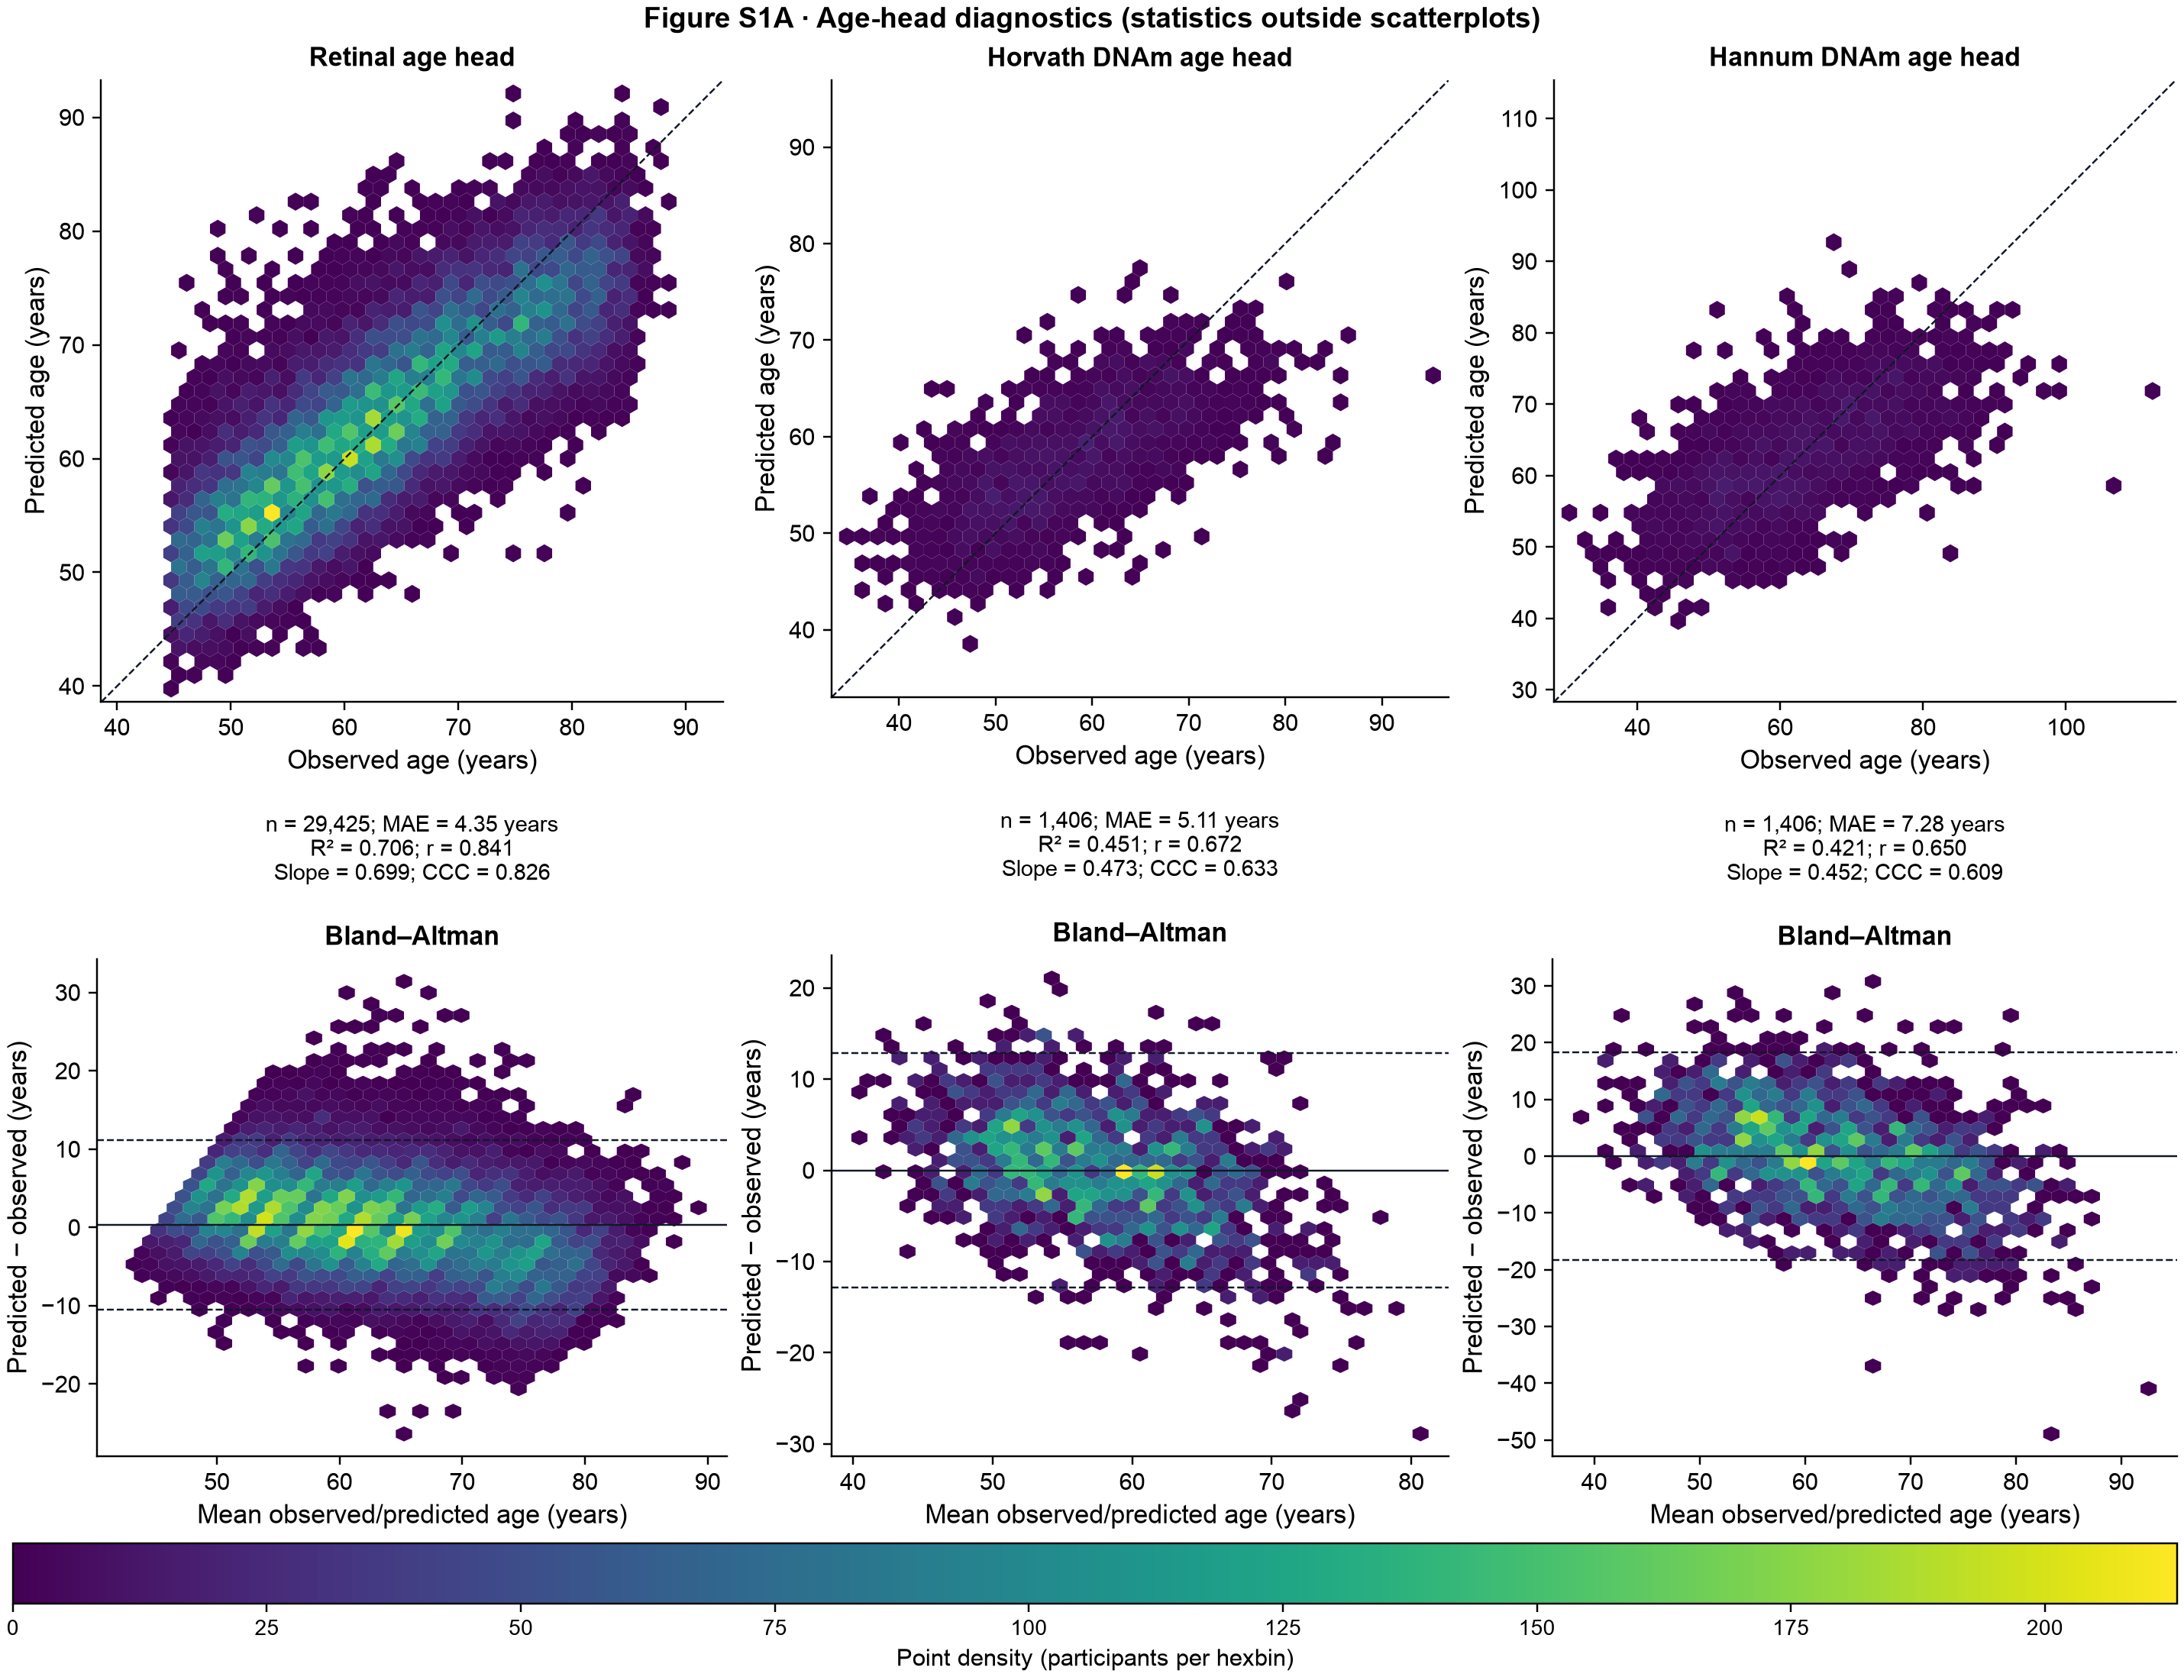

Source: figure_S1_age_diagnostic_points.parquet (cell 12), model_standard_metrics.csv (cell 12)

Figure S1 — Complete age-model diagnostics · Panel B

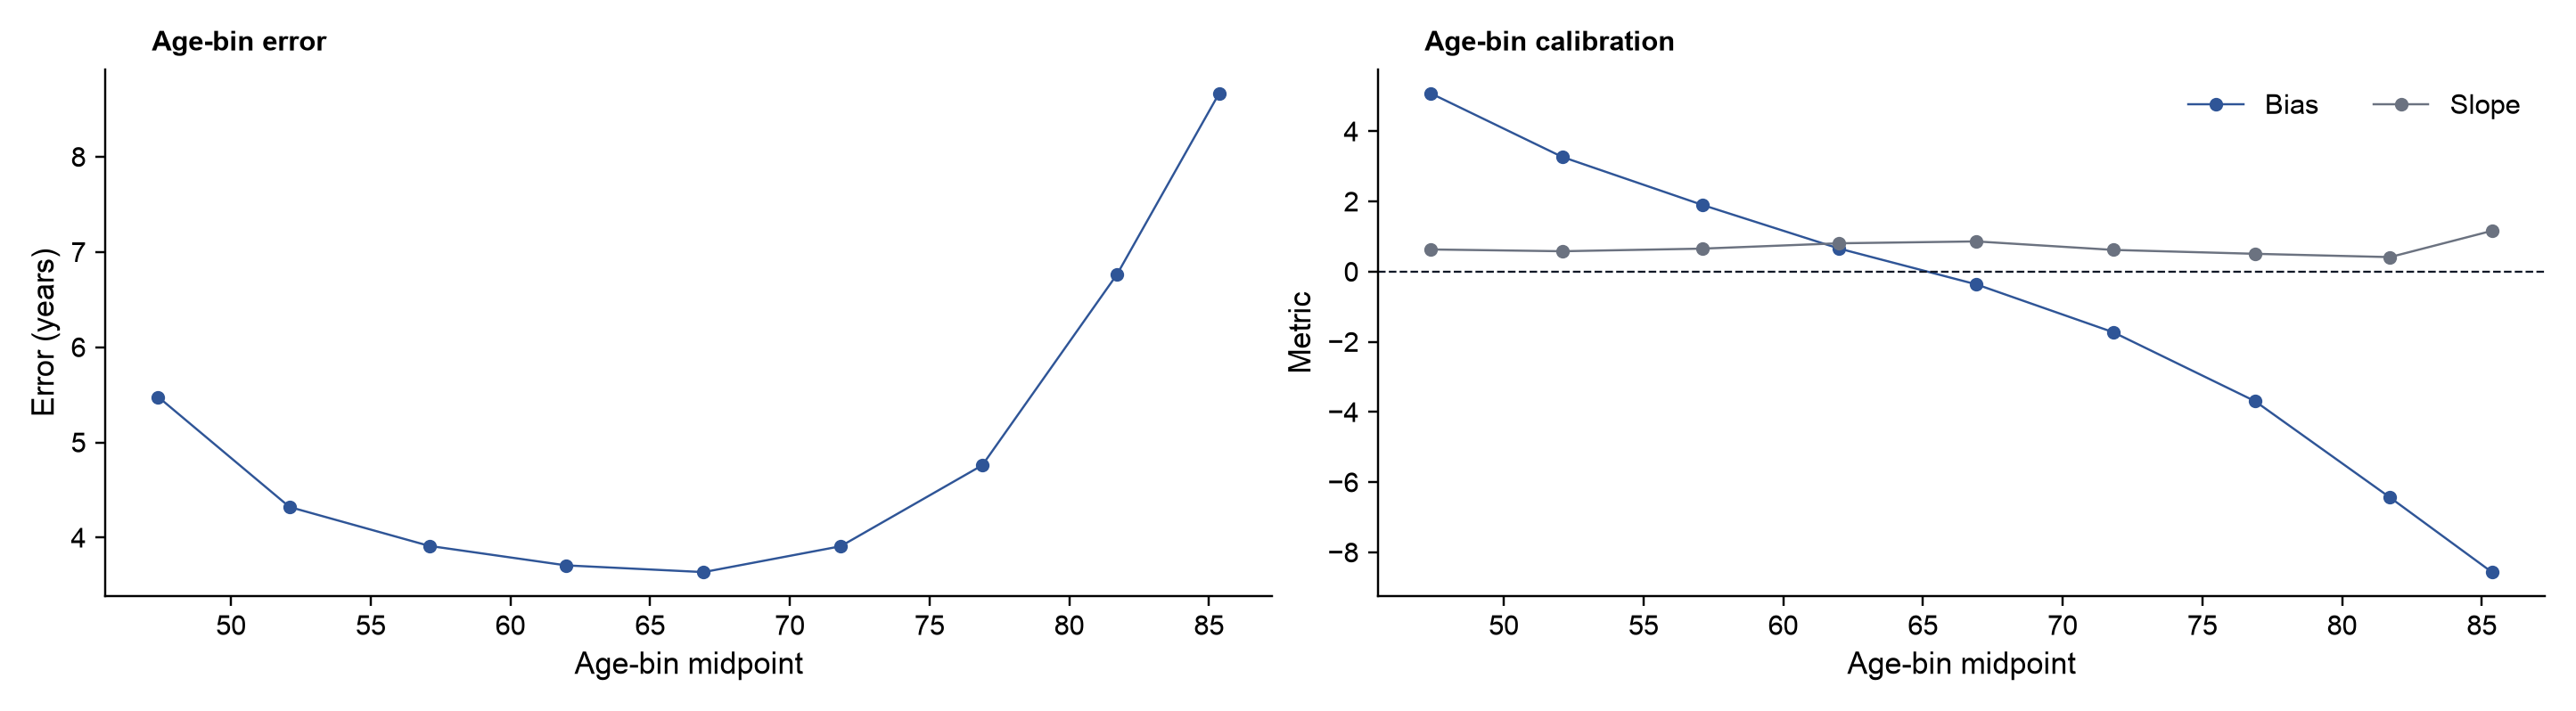

Source: chronological_model_5y_age_bin_performance.csv (cell 12)

In [ ]:
# PNG series for manuscript Figure S1.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "S1"])


Figure S2 — Selection and demographic performance · Panel A

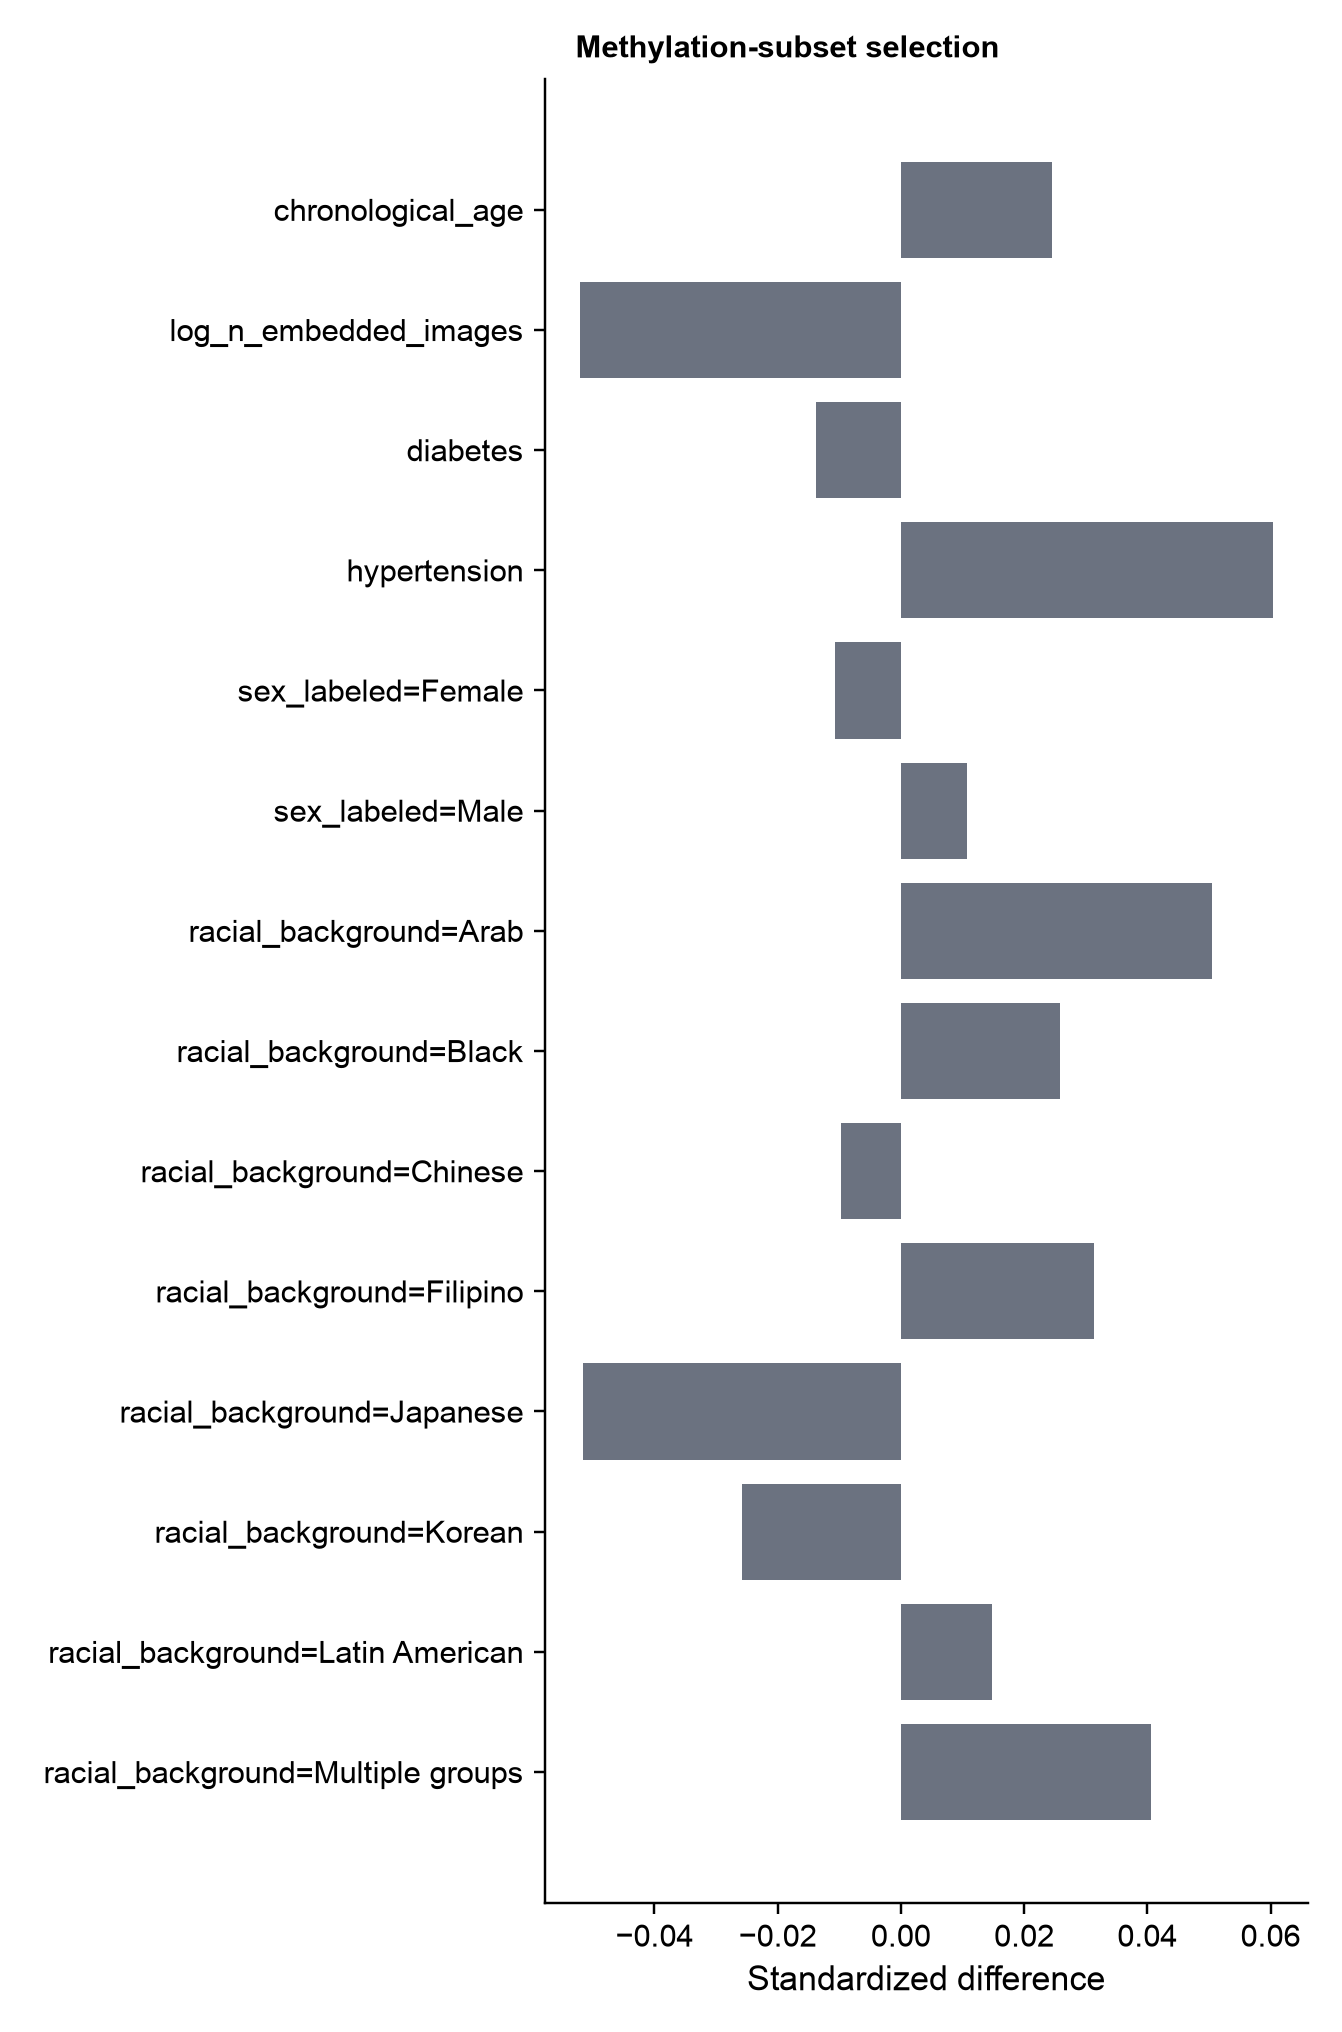

Source: table_1_methylation_included_vs_excluded.csv (cell 55)

Figure S2 — Selection and demographic performance · Panel B

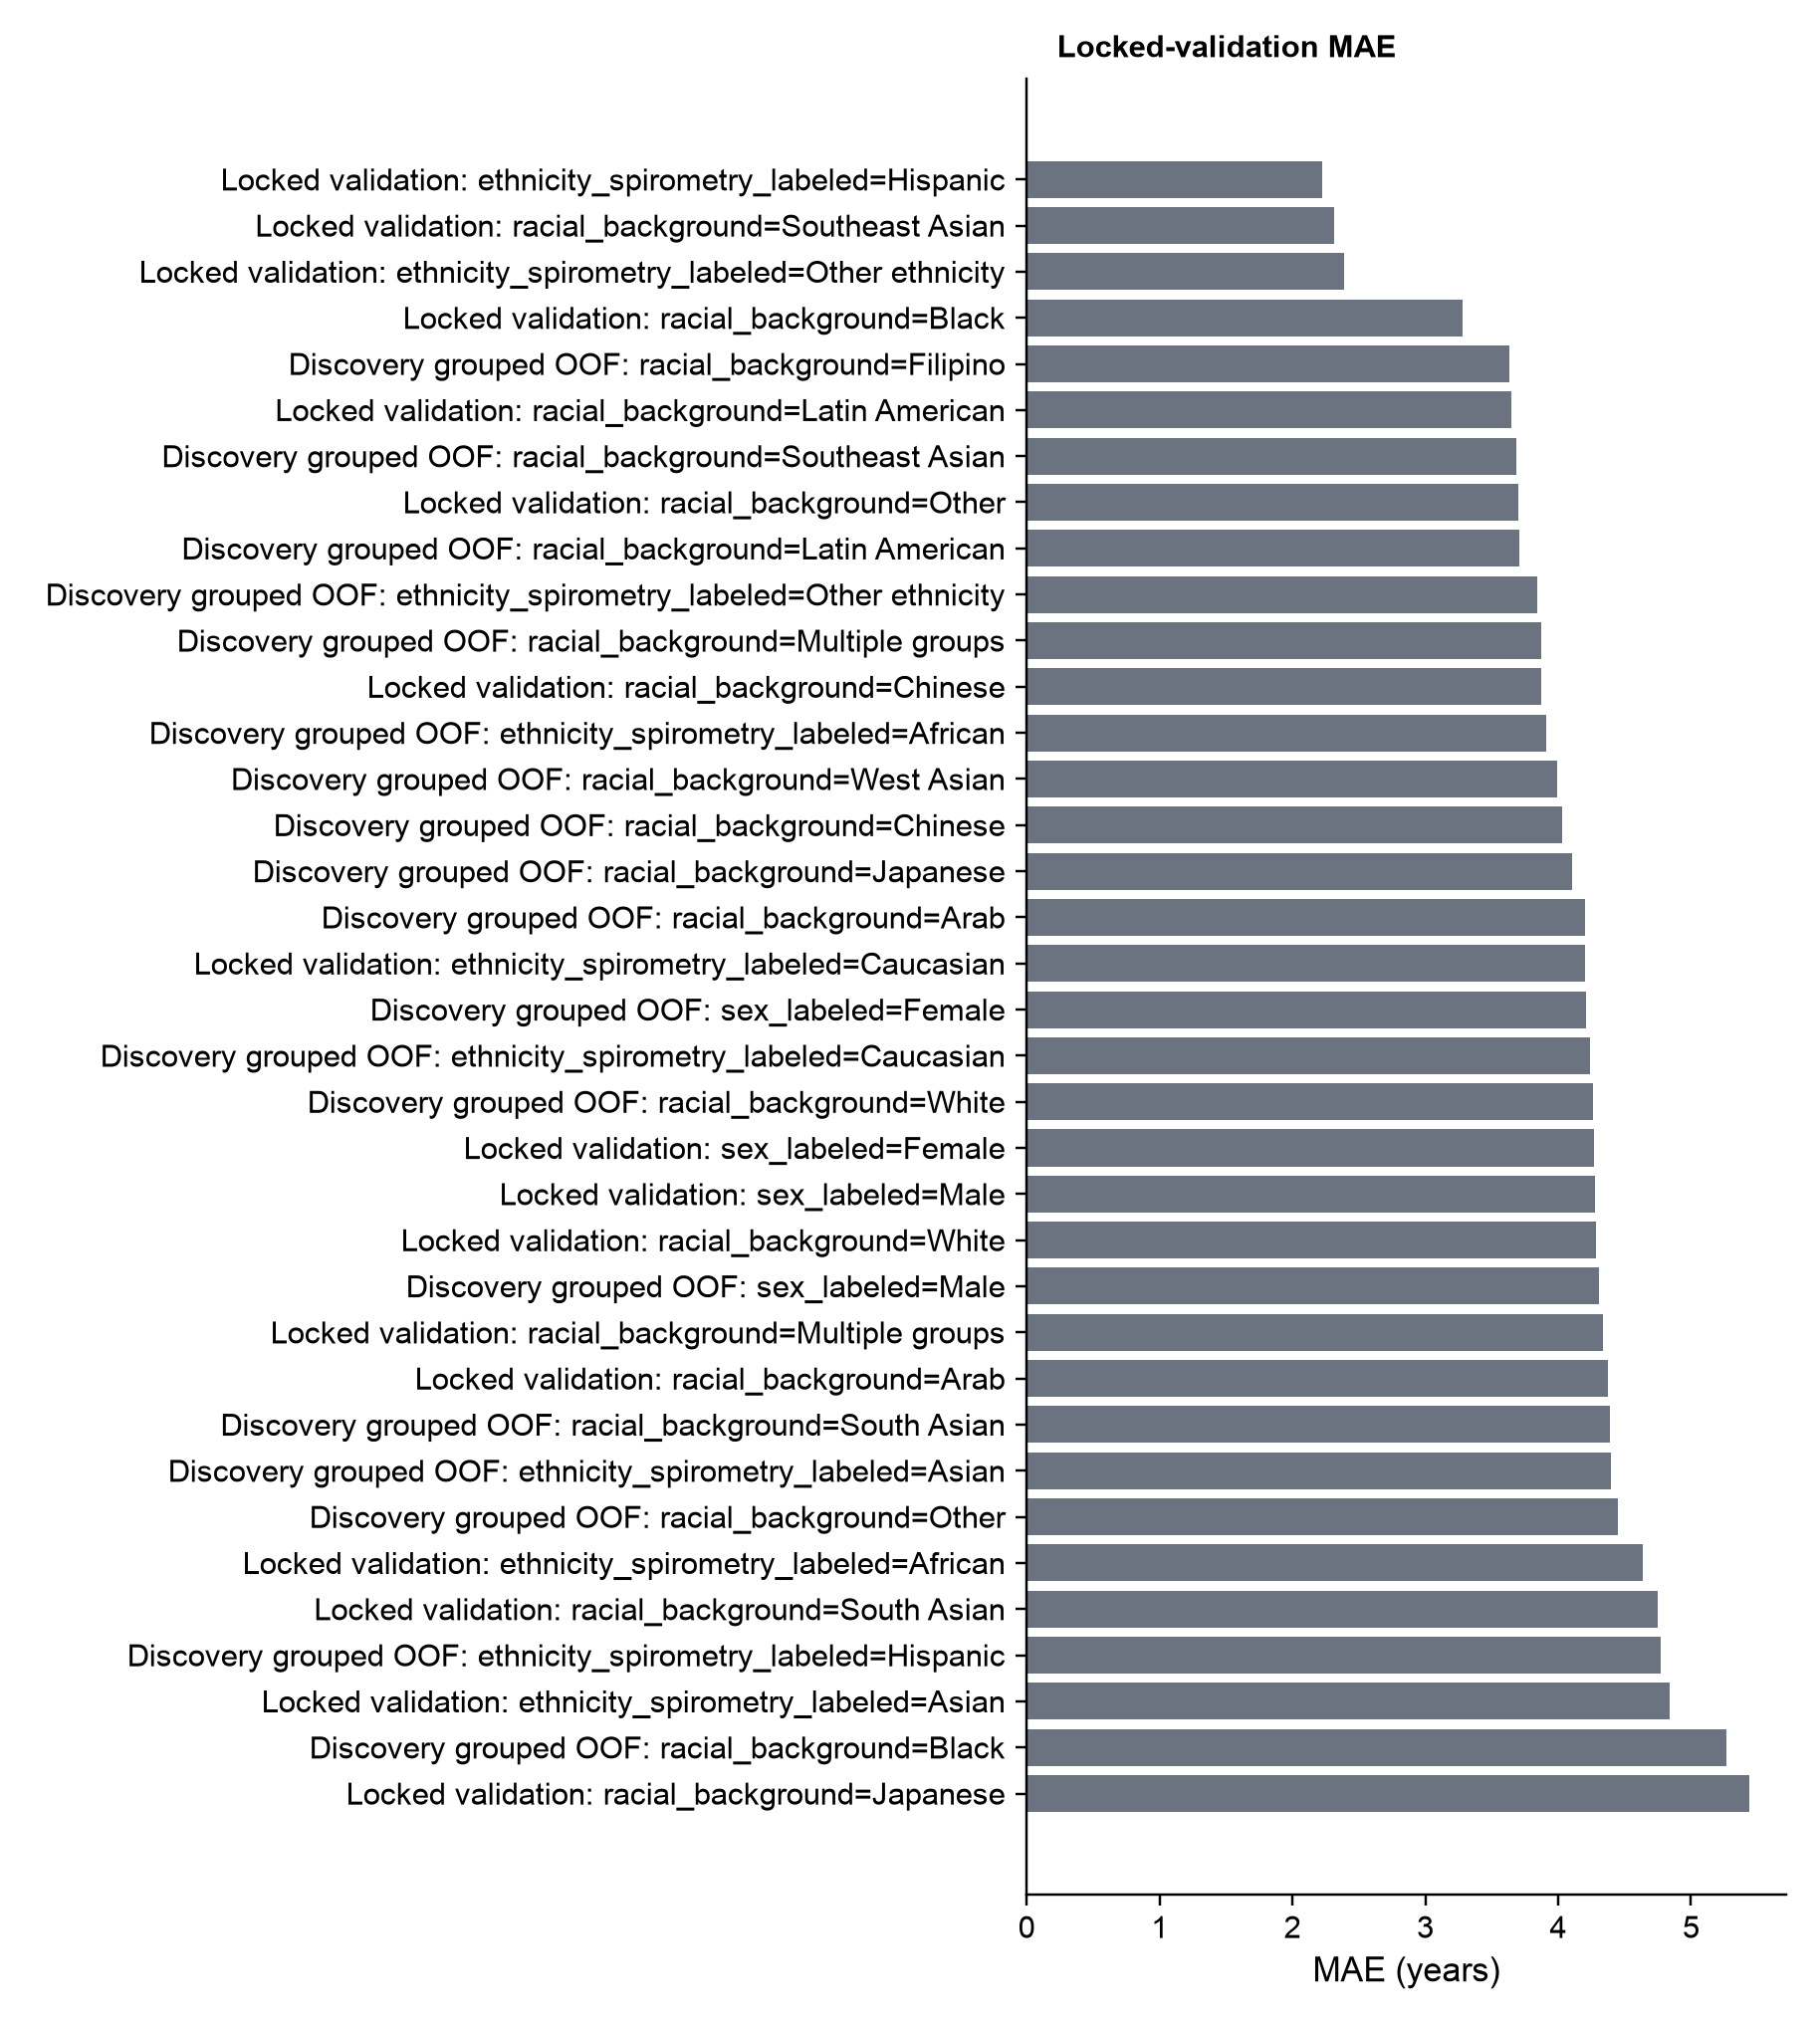

Source: locked_demographic_performance.csv (cell 55)

In [ ]:
# PNG series for manuscript Figure S2.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "S2"])


Figure S3 — Alternative cross-clock comparisons · Panel A

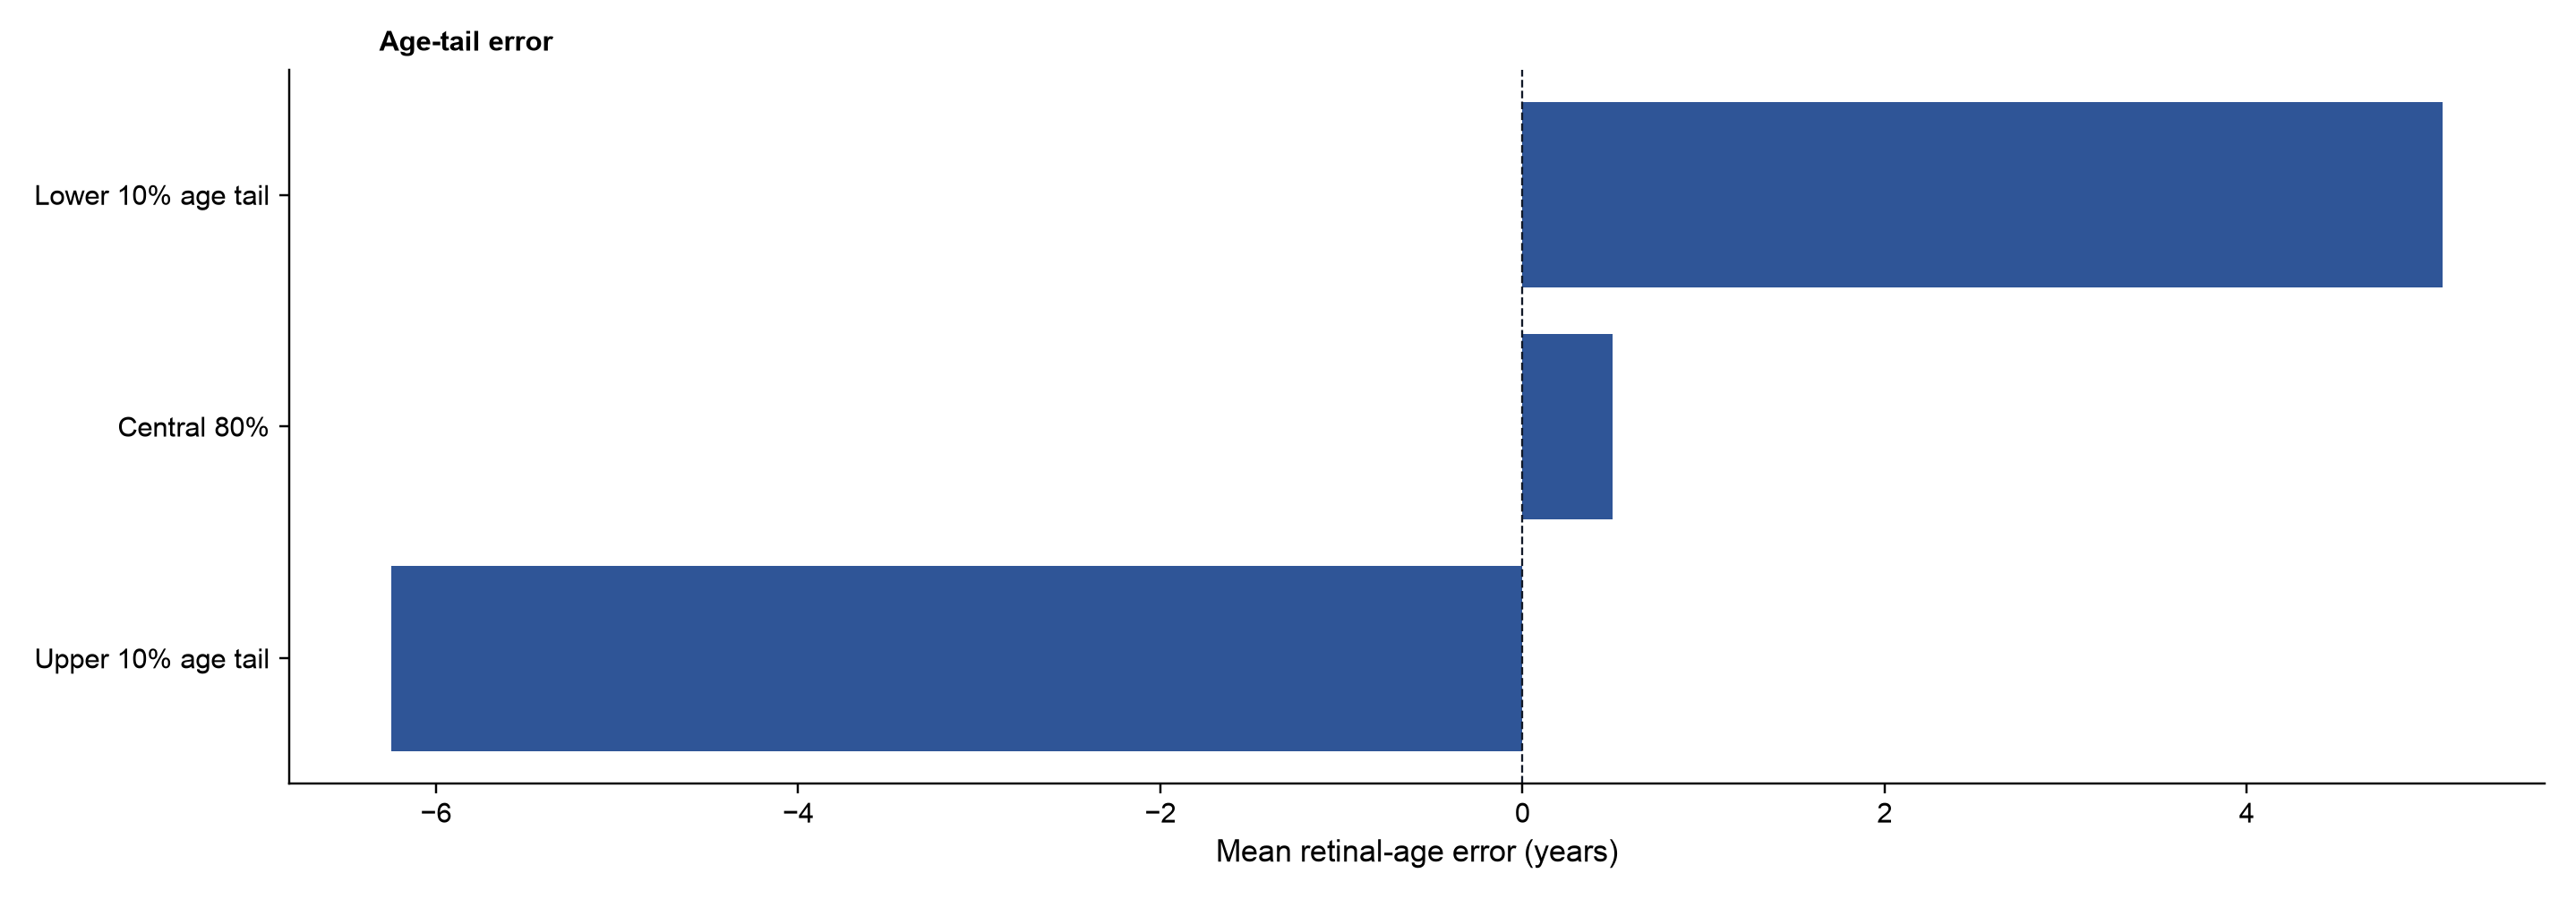

Source: chronological_model_tail_performance.csv (cell 12)

Figure S3 — Alternative cross-clock comparisons · Panel B

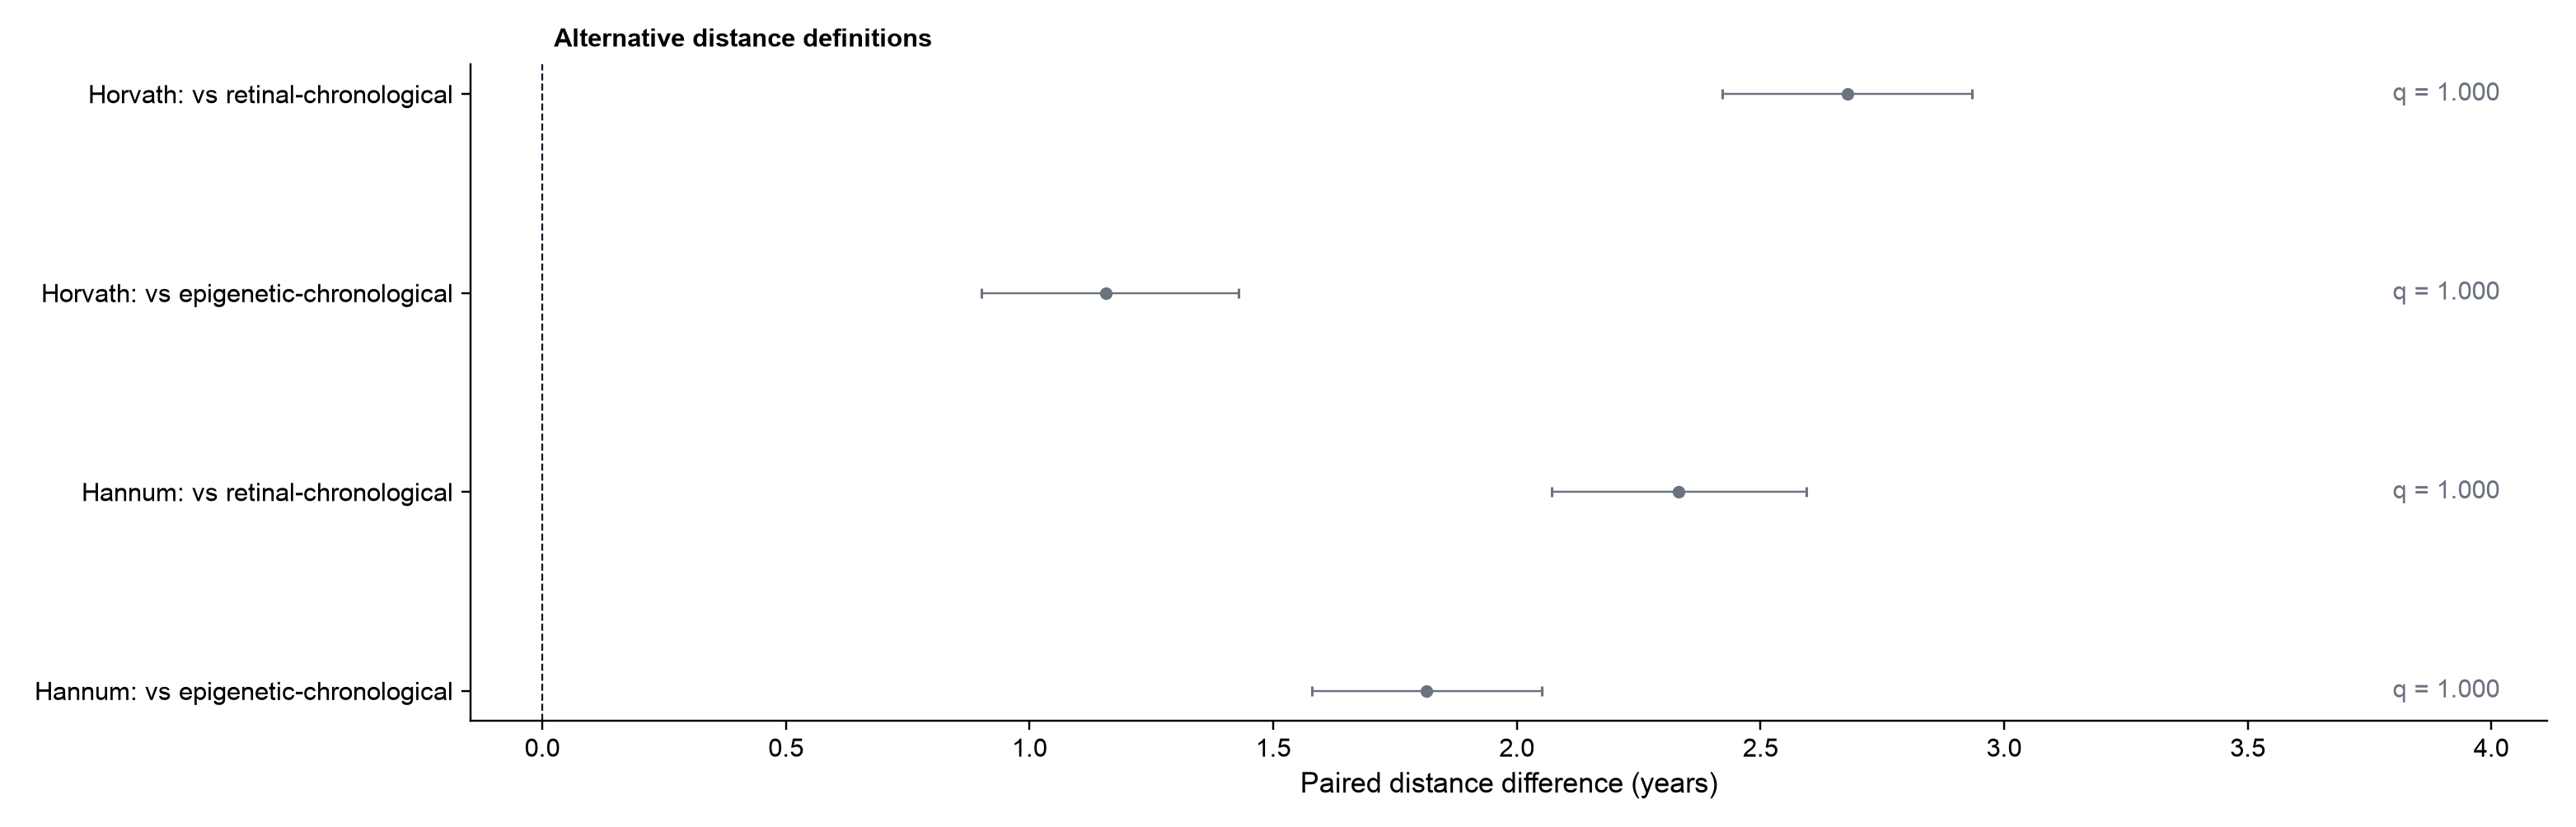

Source: three_age_paired_distance_tests.csv (cell 21)

Figure S3 — Alternative cross-clock comparisons · Panel C

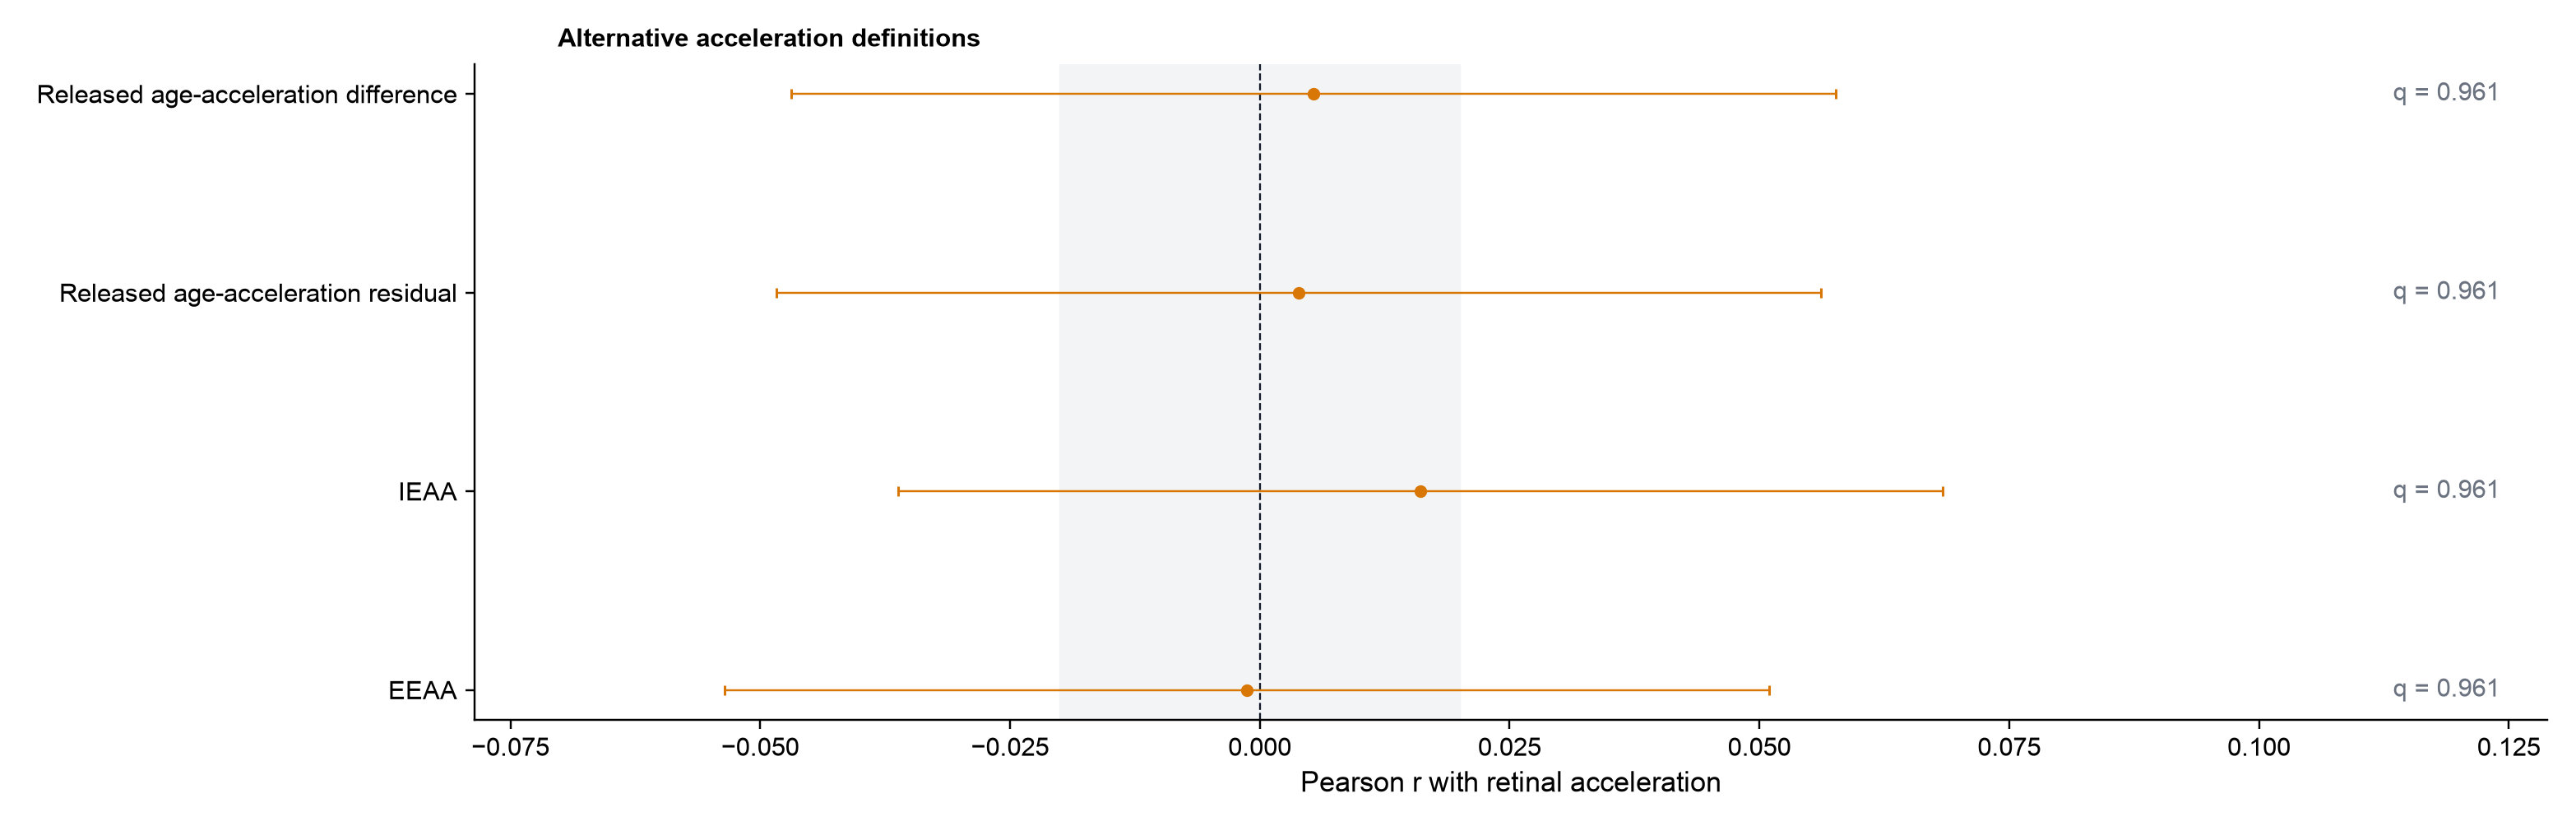

Source: figure_02_acceleration_correlation_forest.csv (cell 21)

In [ ]:
# PNG series for manuscript Figure S3.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "S3"])


Figure S4 — Exploratory three-clock decomposition · Panel A

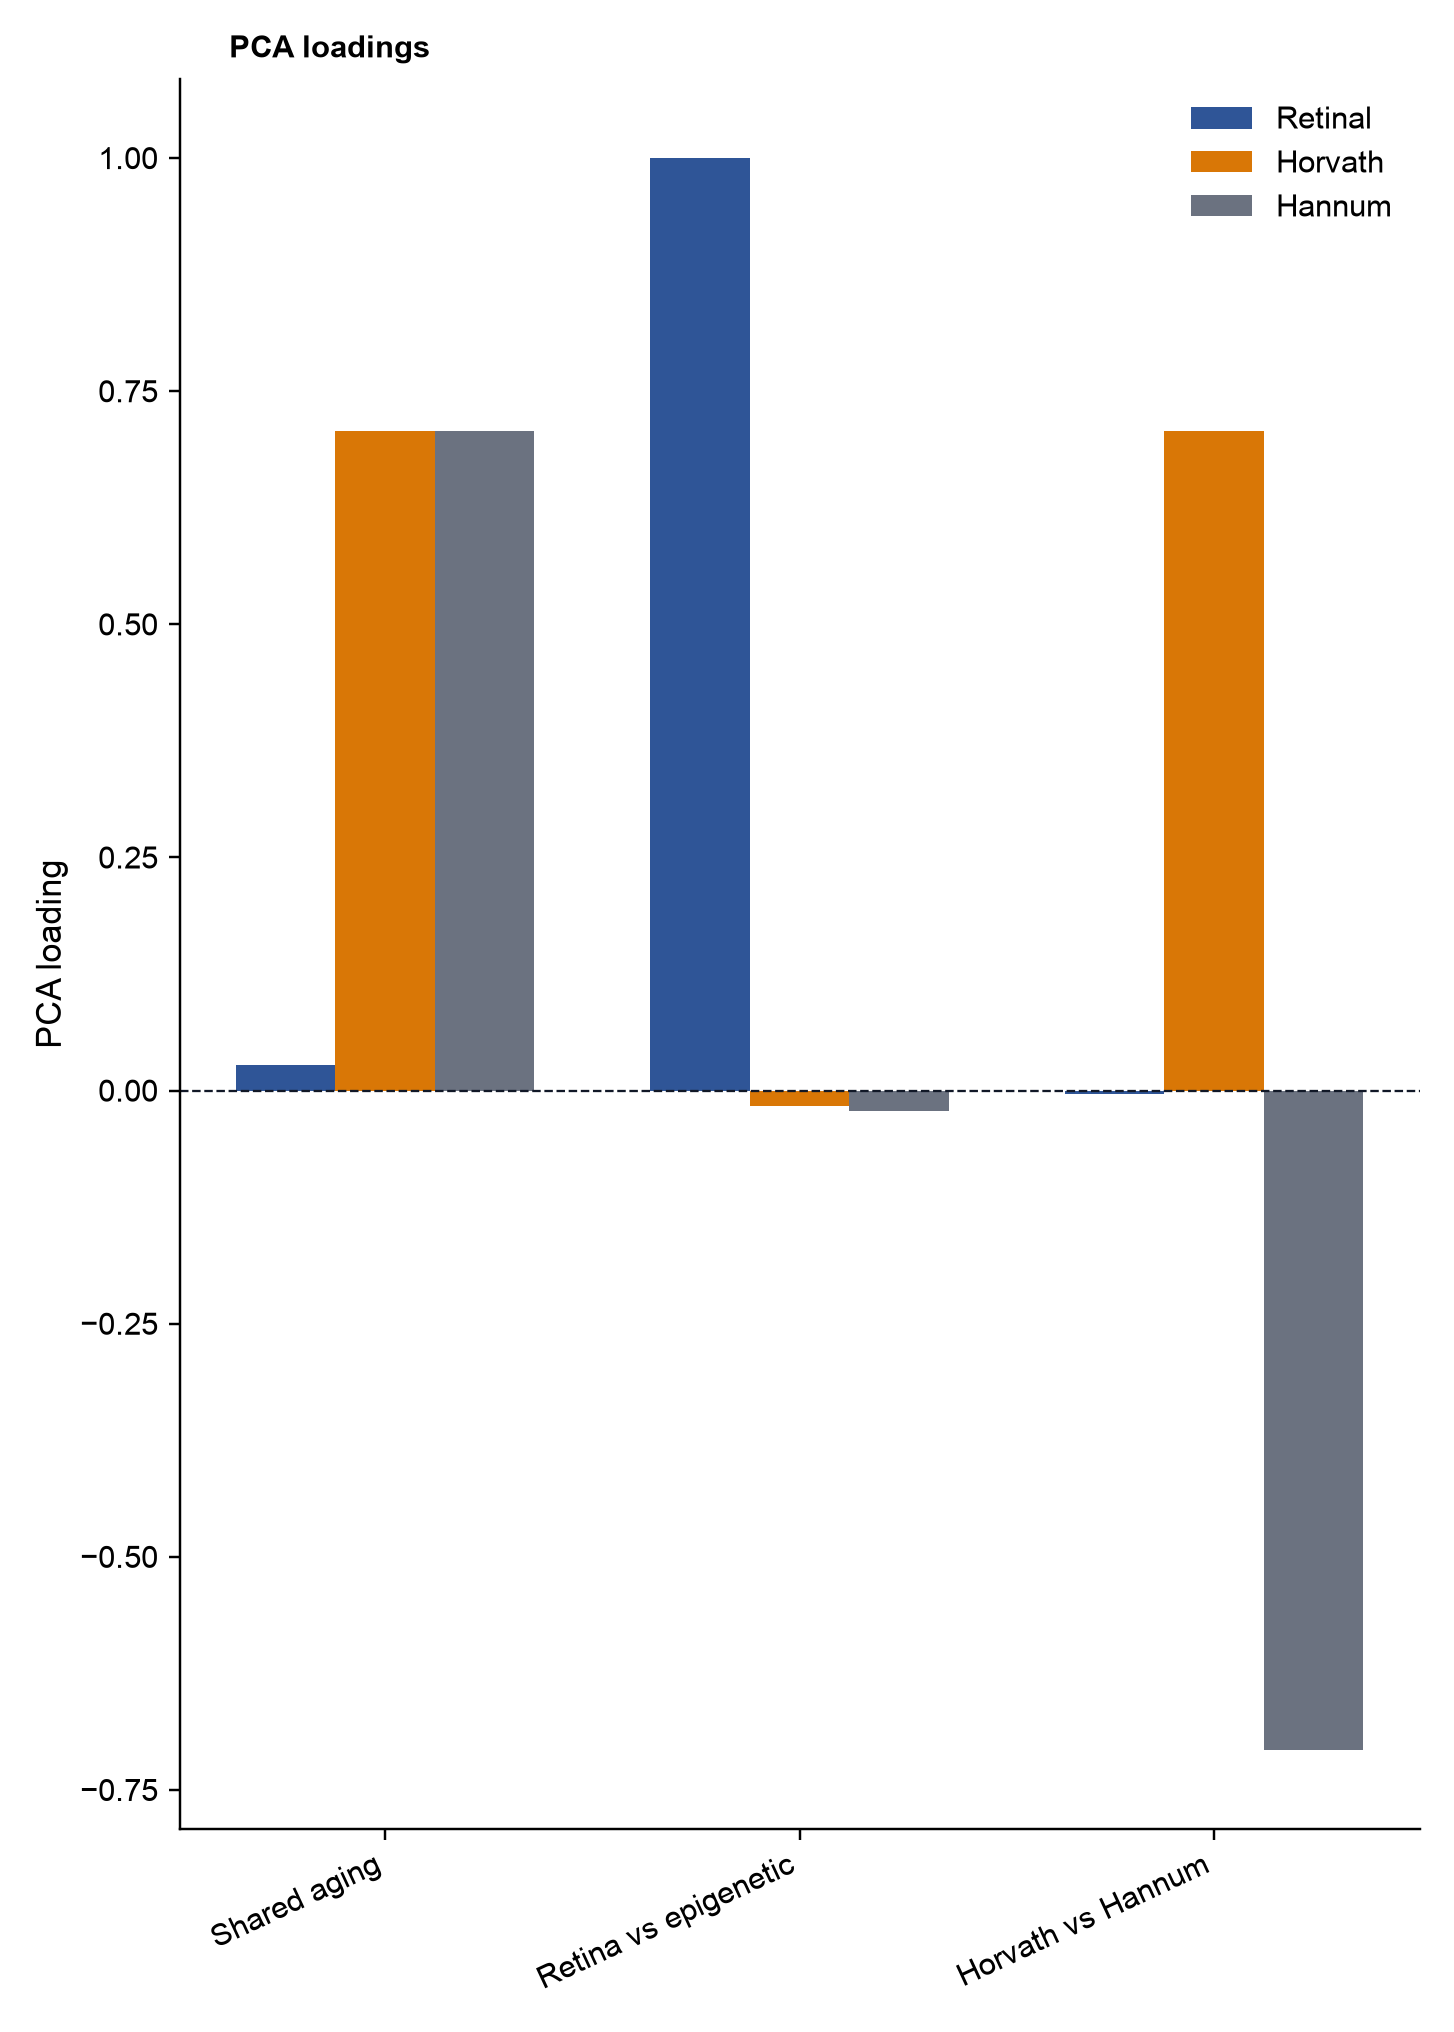

Source: three_clock_pca_loadings.csv (cell 26)

Figure S4 — Exploratory three-clock decomposition · Panel B

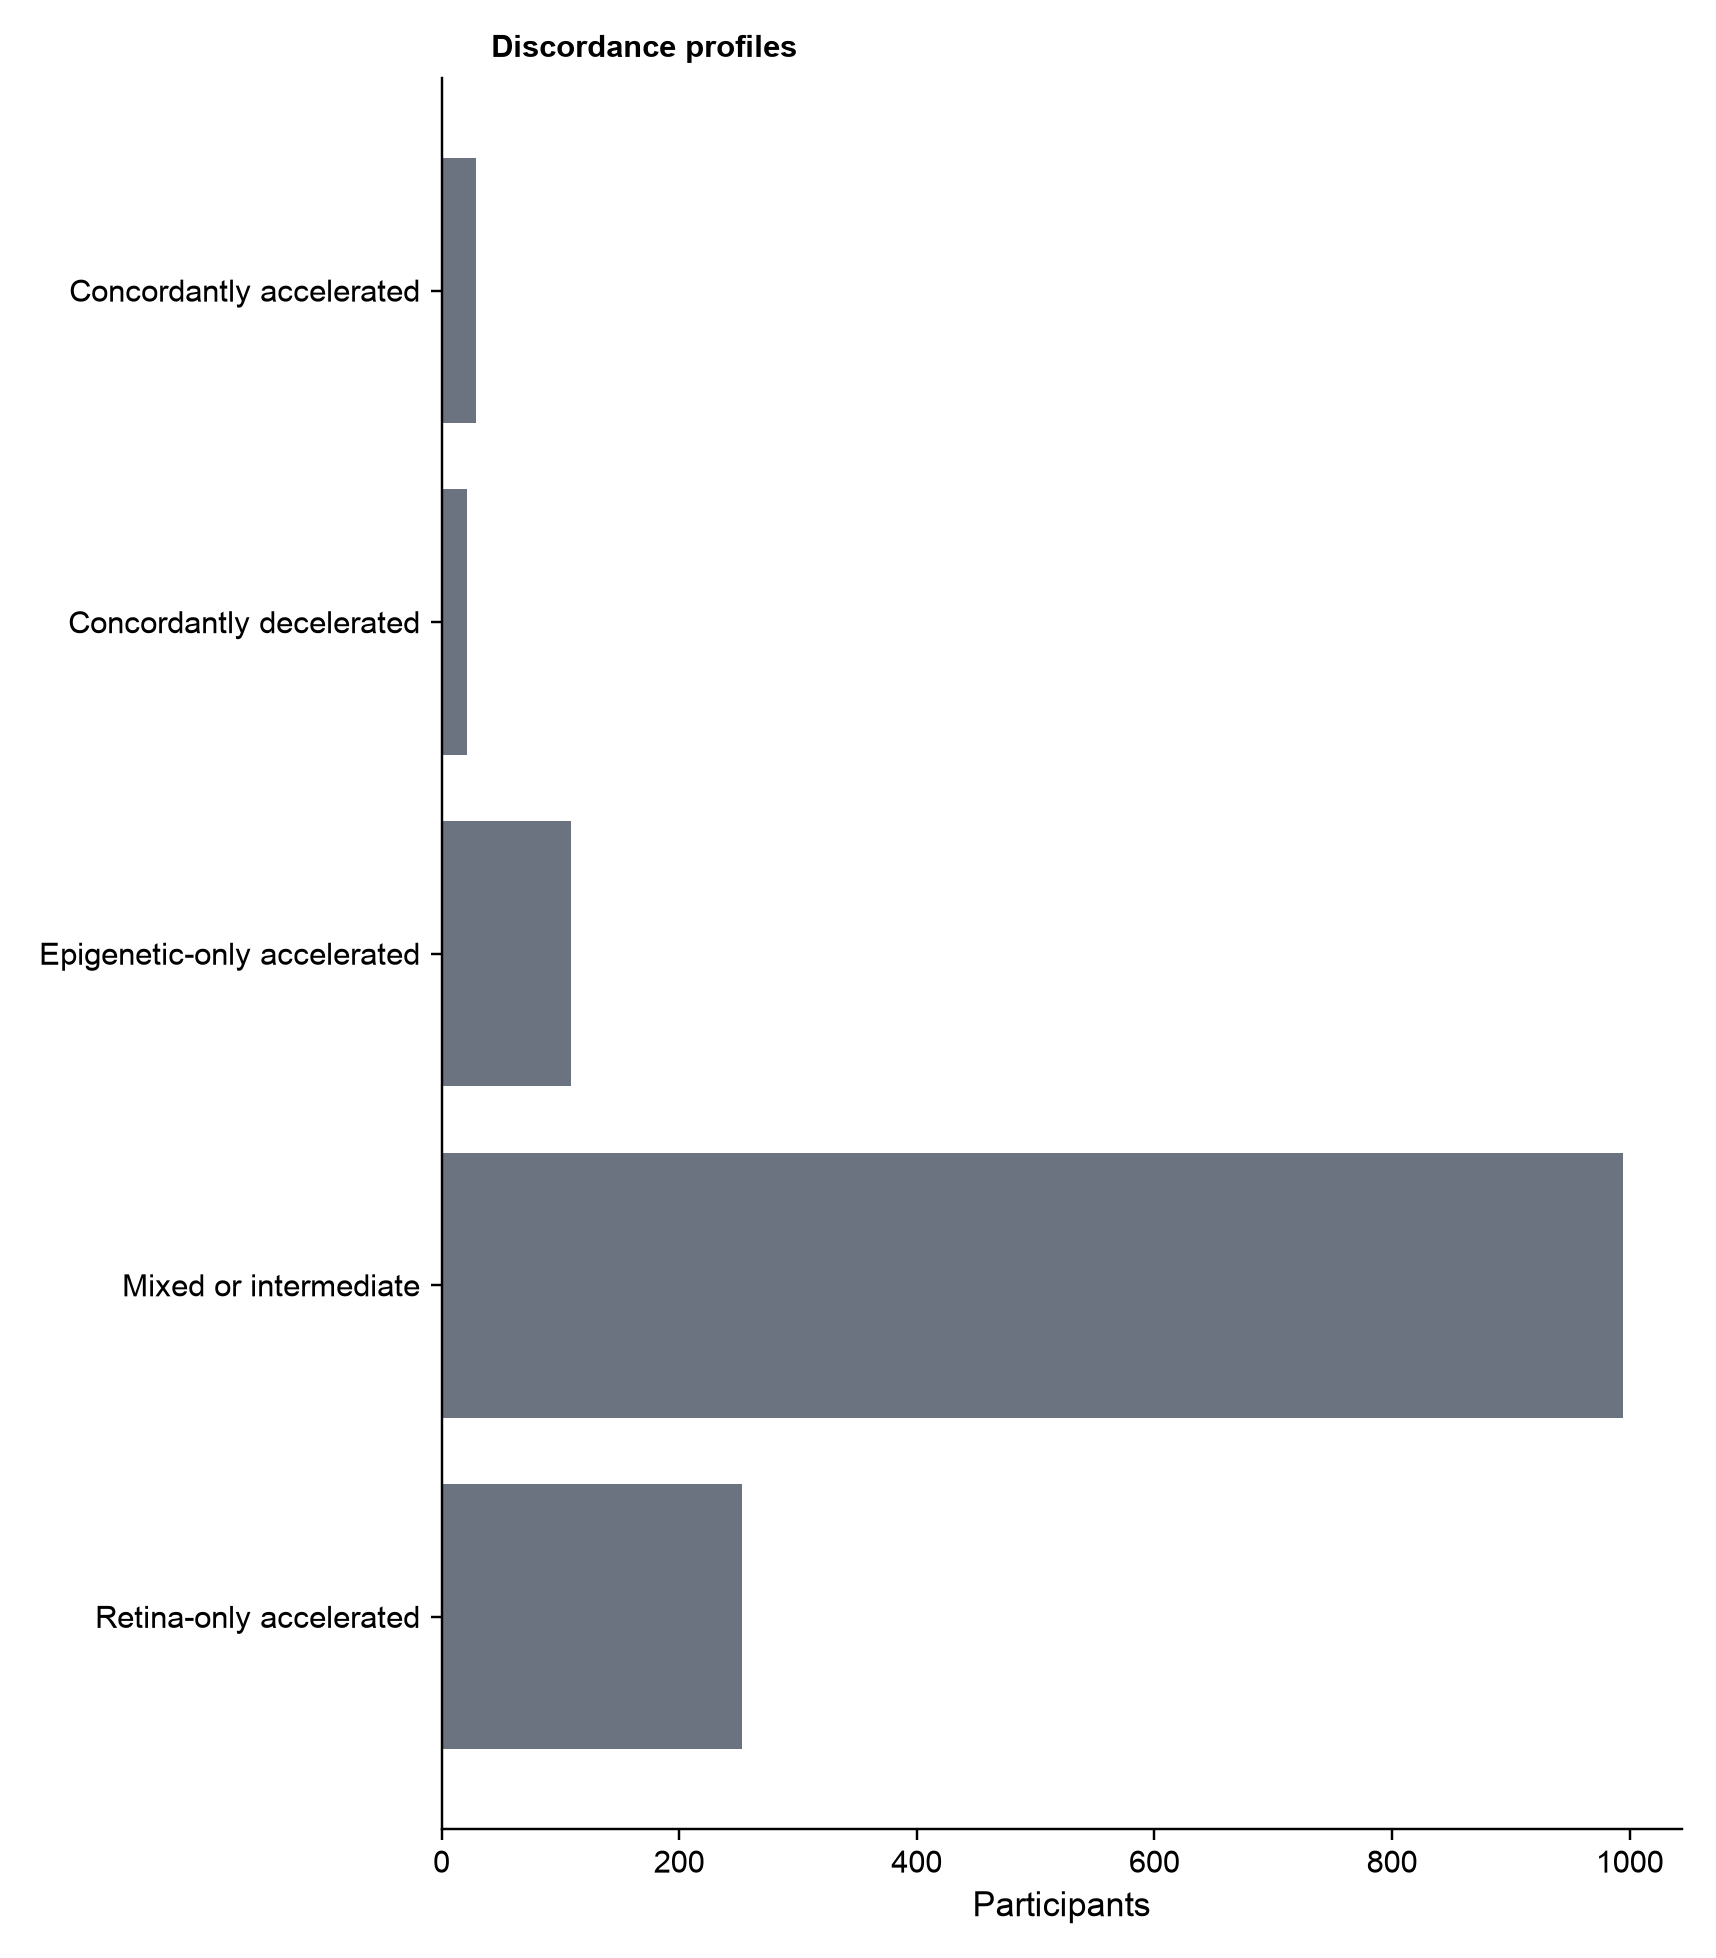

Source: three_clock_profile_summary.csv (cell 26)

In [ ]:
# PNG series for manuscript Figure S4.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "S4"])


Figure S5 — Complete questionnaire-wide associations · Panel A

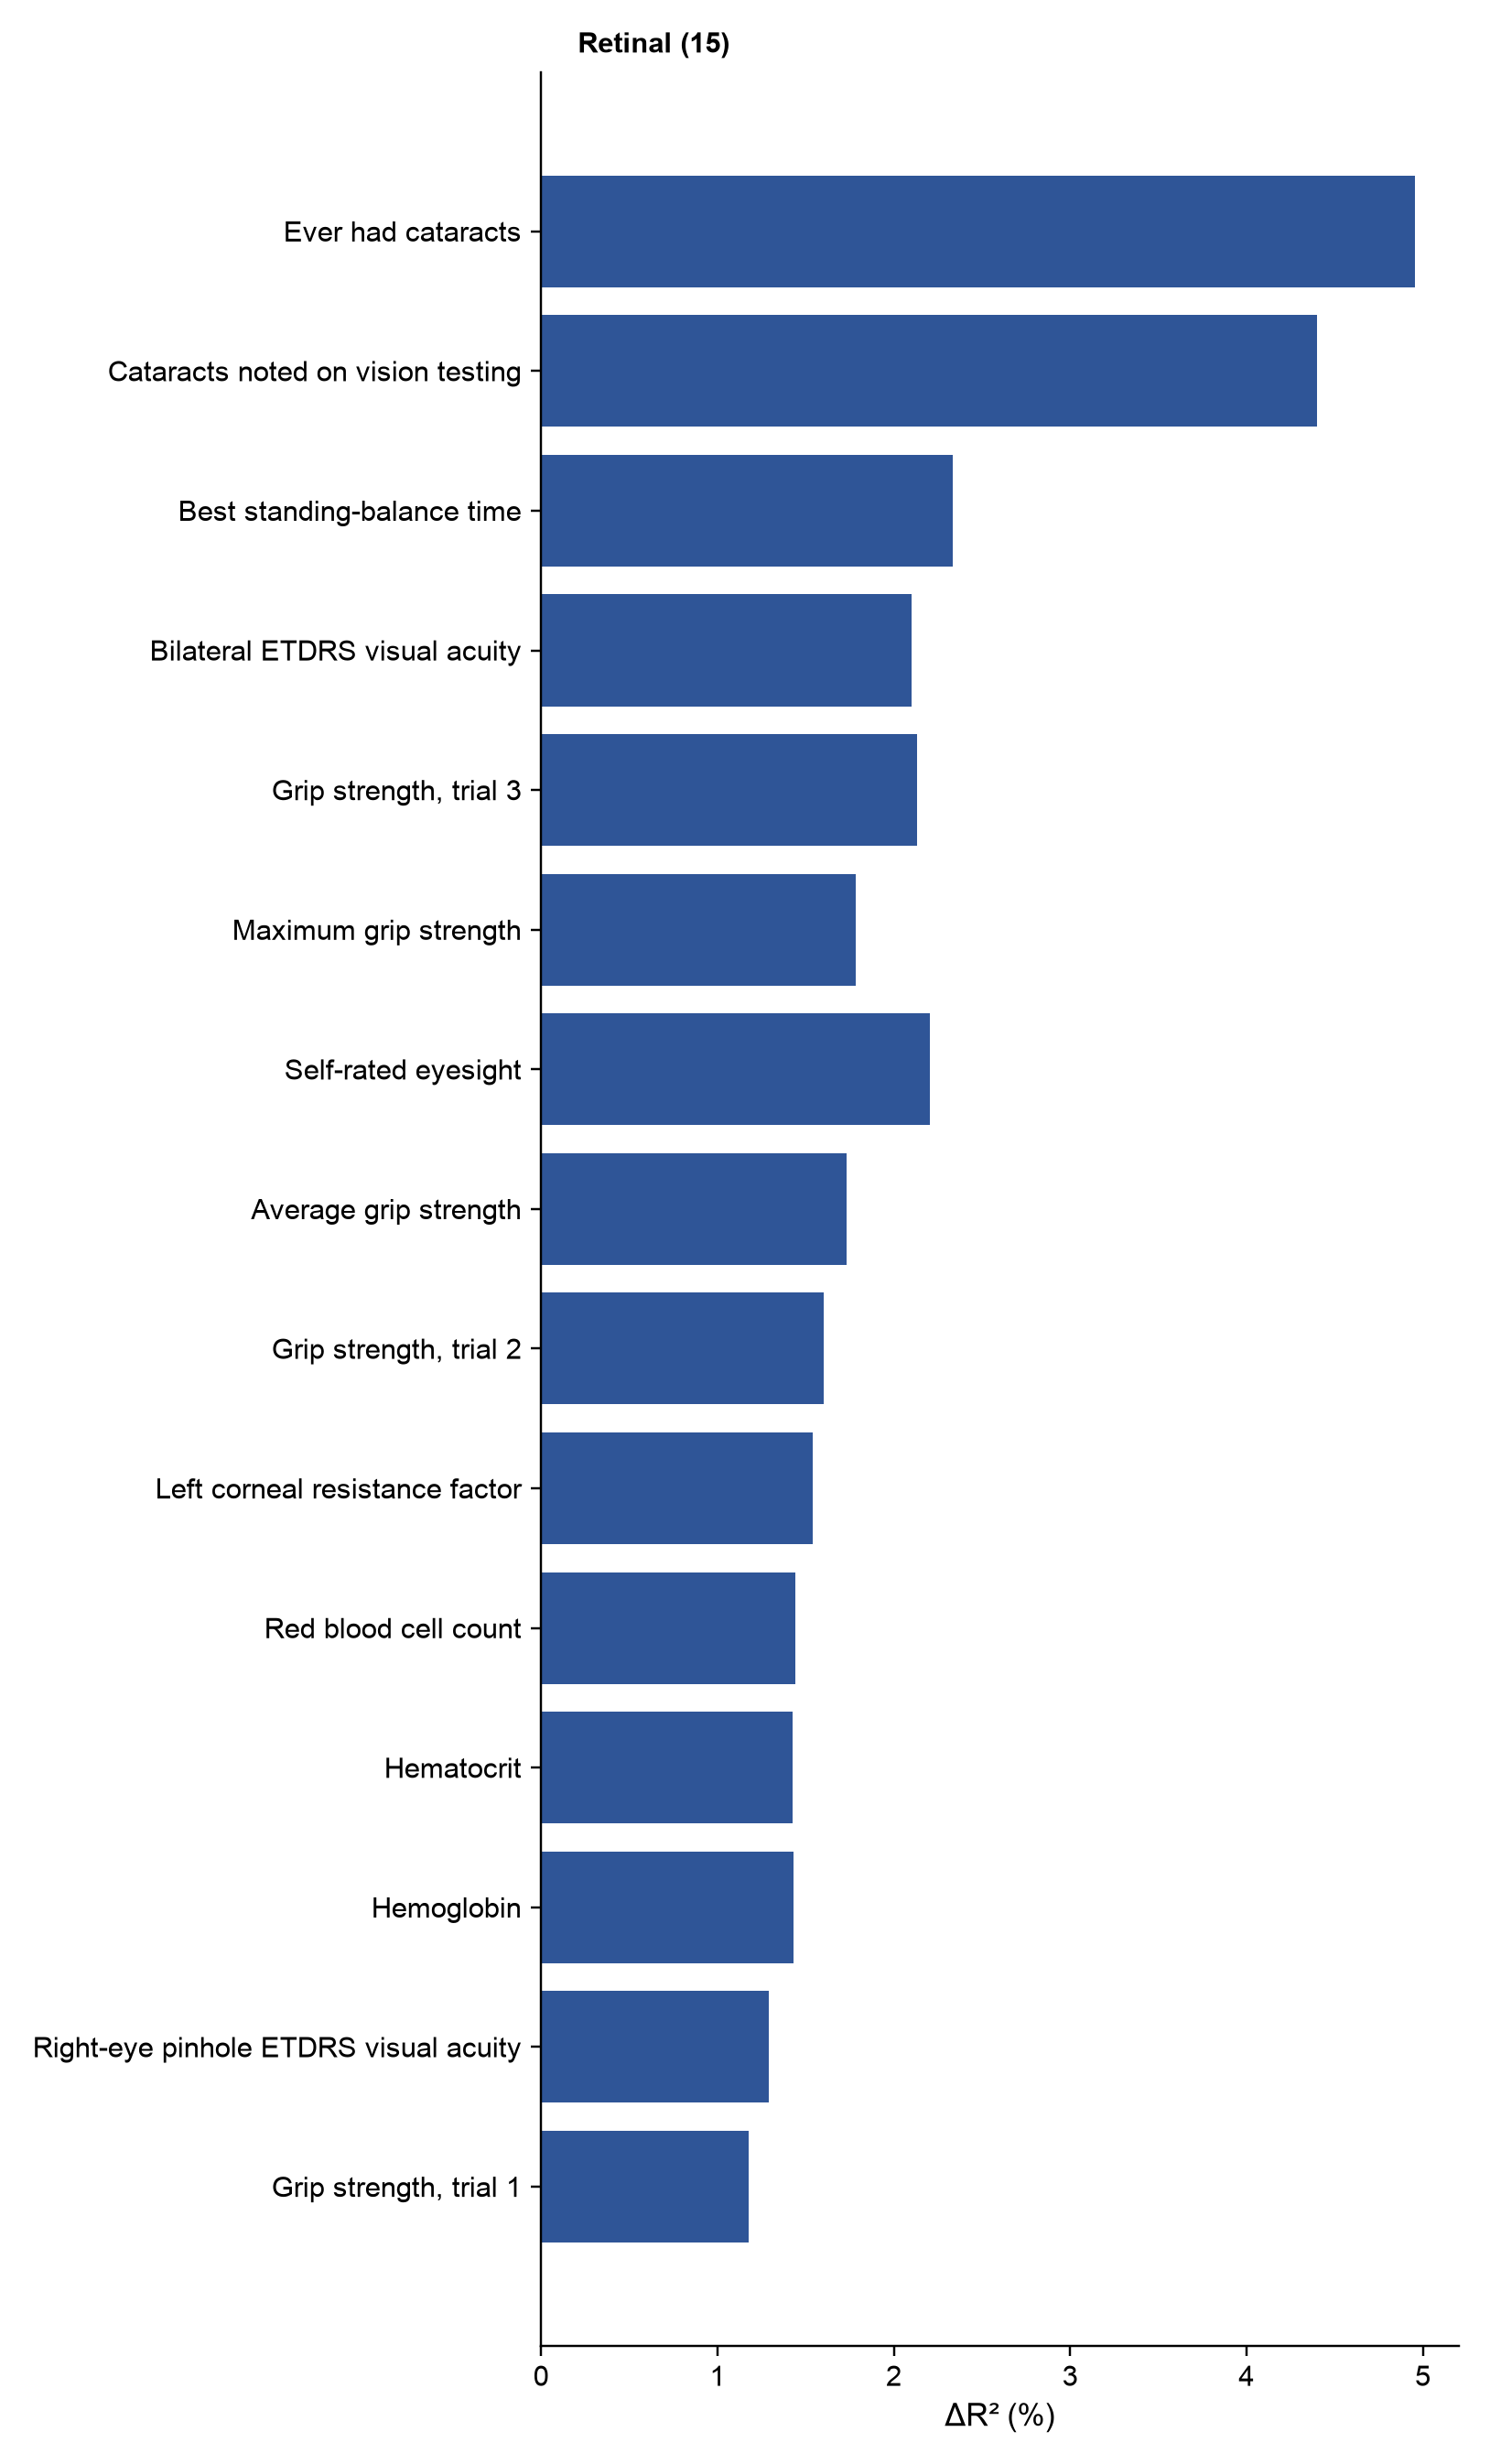

Source: questionnaire_phenome_scan_tests.csv (cell 34)

Figure S5 — Complete questionnaire-wide associations · Panel B

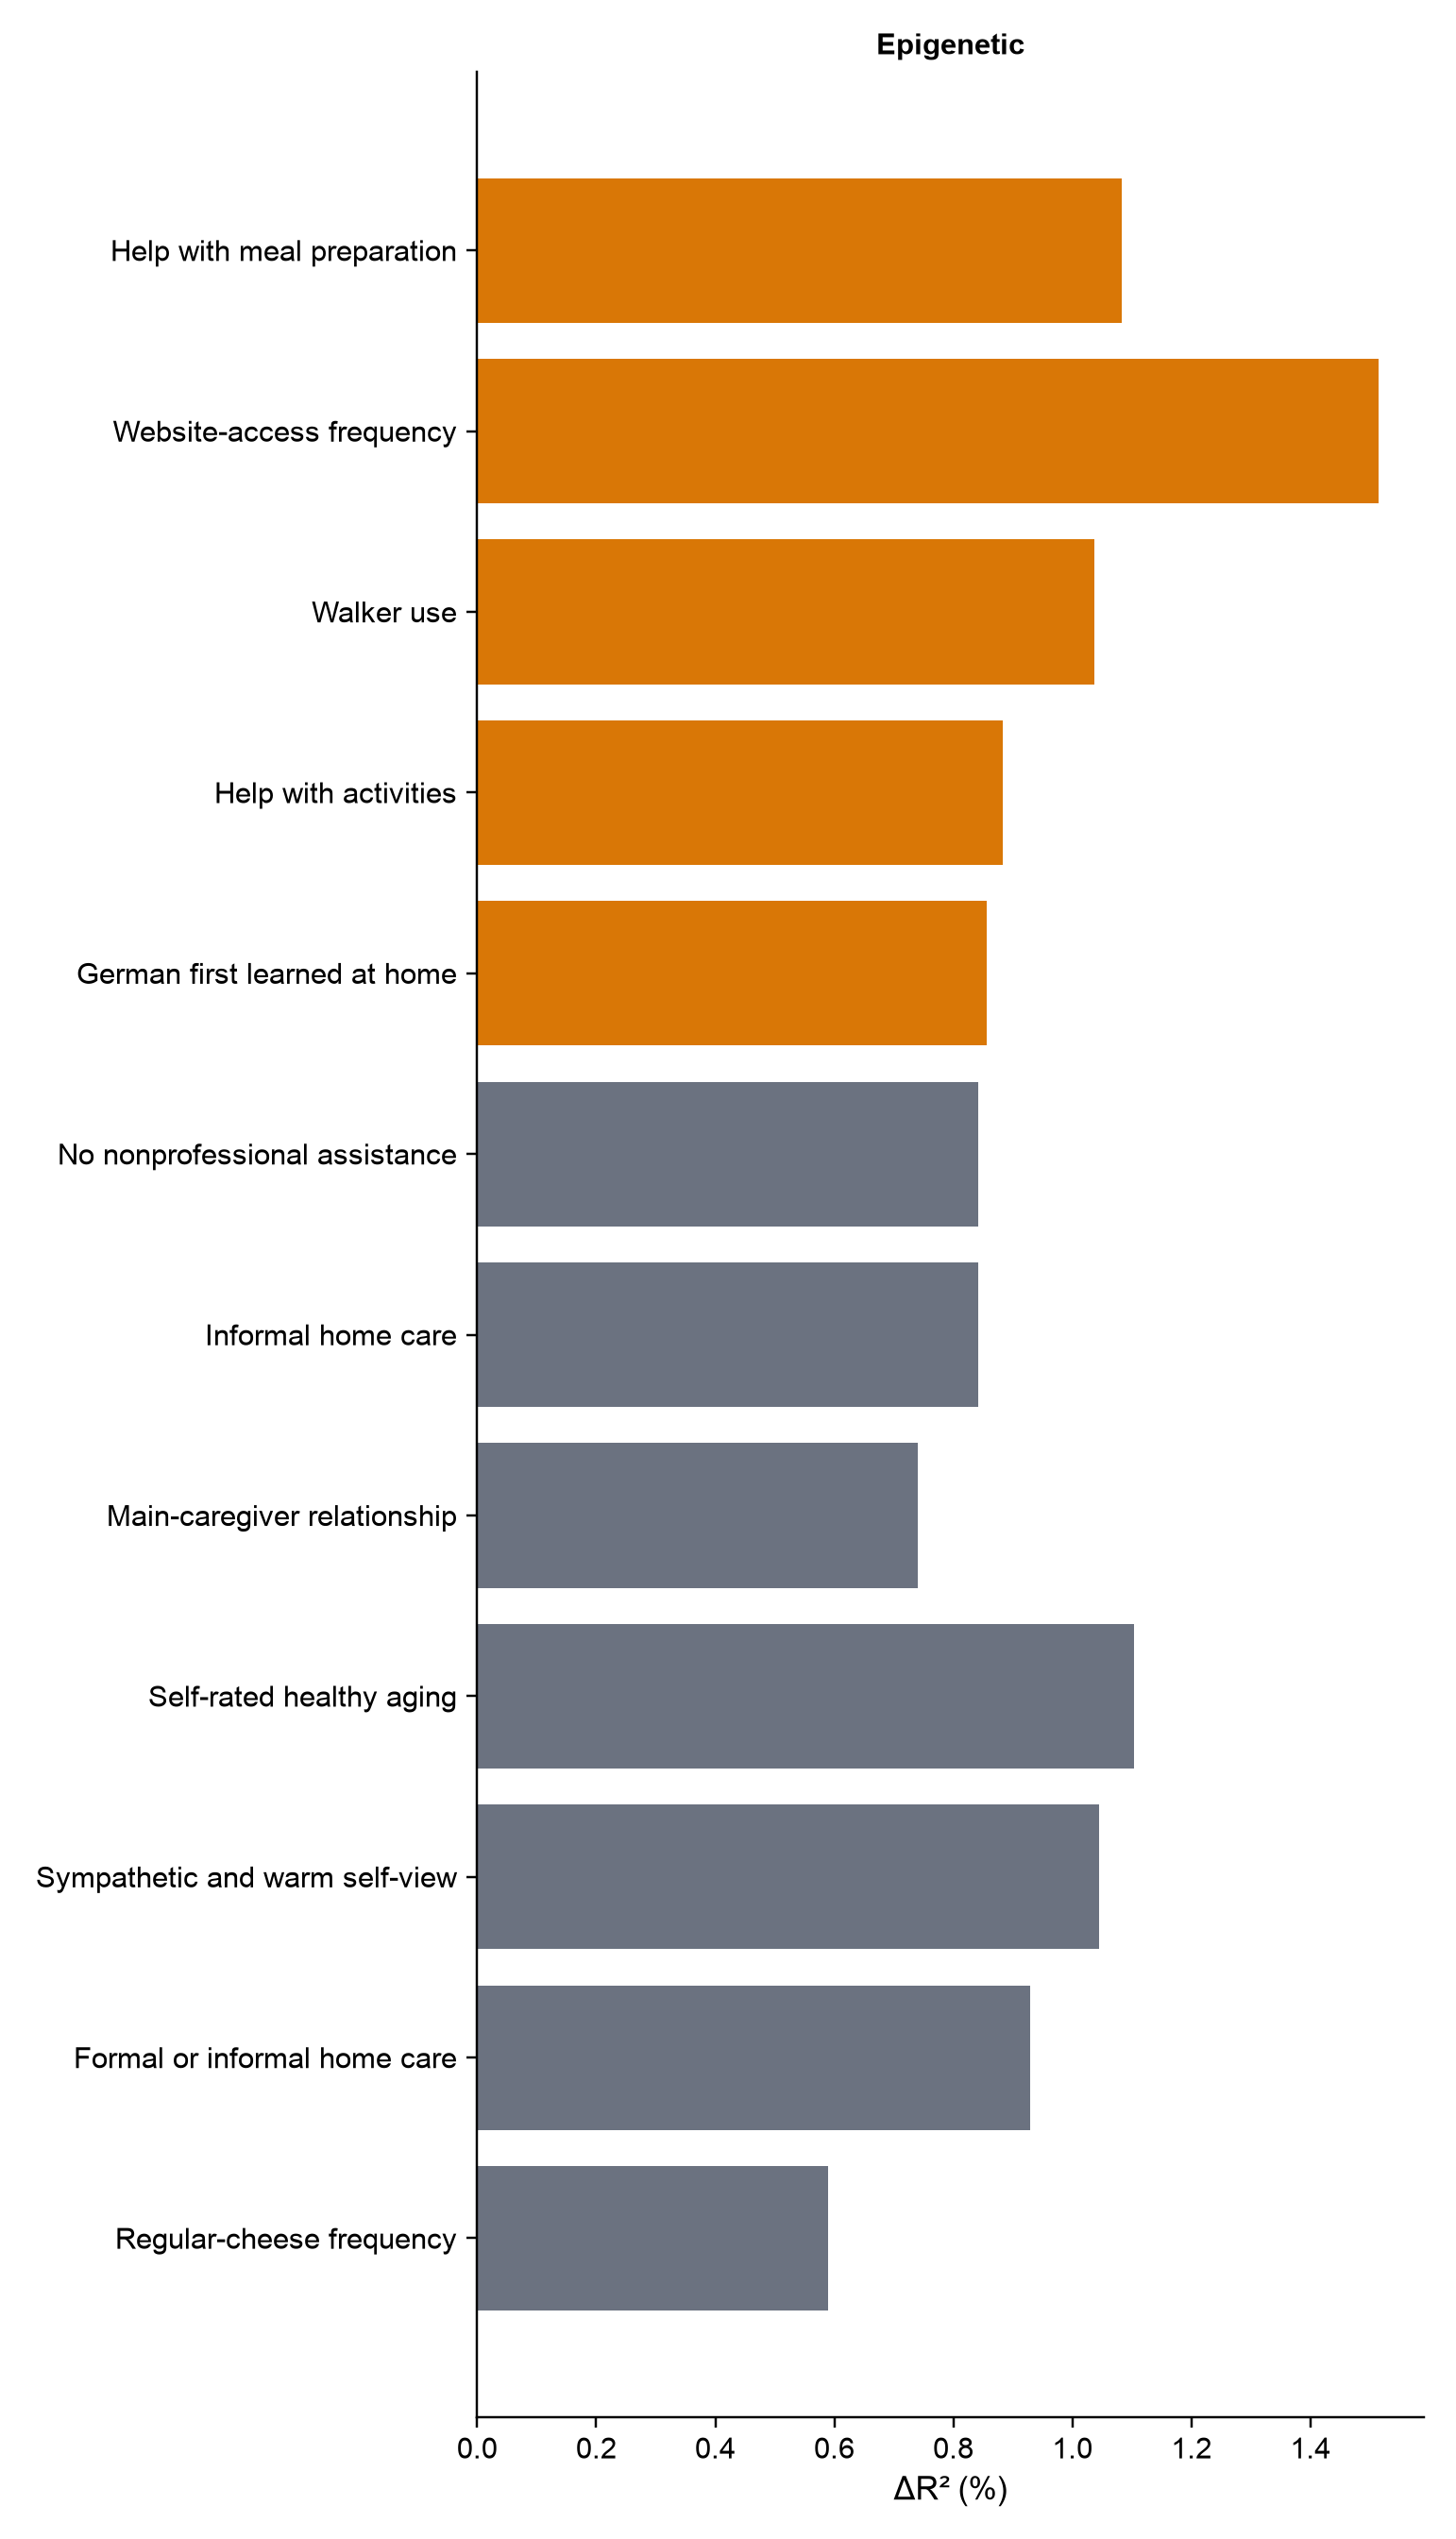

Source: questionnaire_phenome_scan_tests.csv (cell 34)

In [ ]:
# PNG series for manuscript Figure S5.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "S5"])


Figure S6 — Expanded retinal sensitivity analyses · Panel A

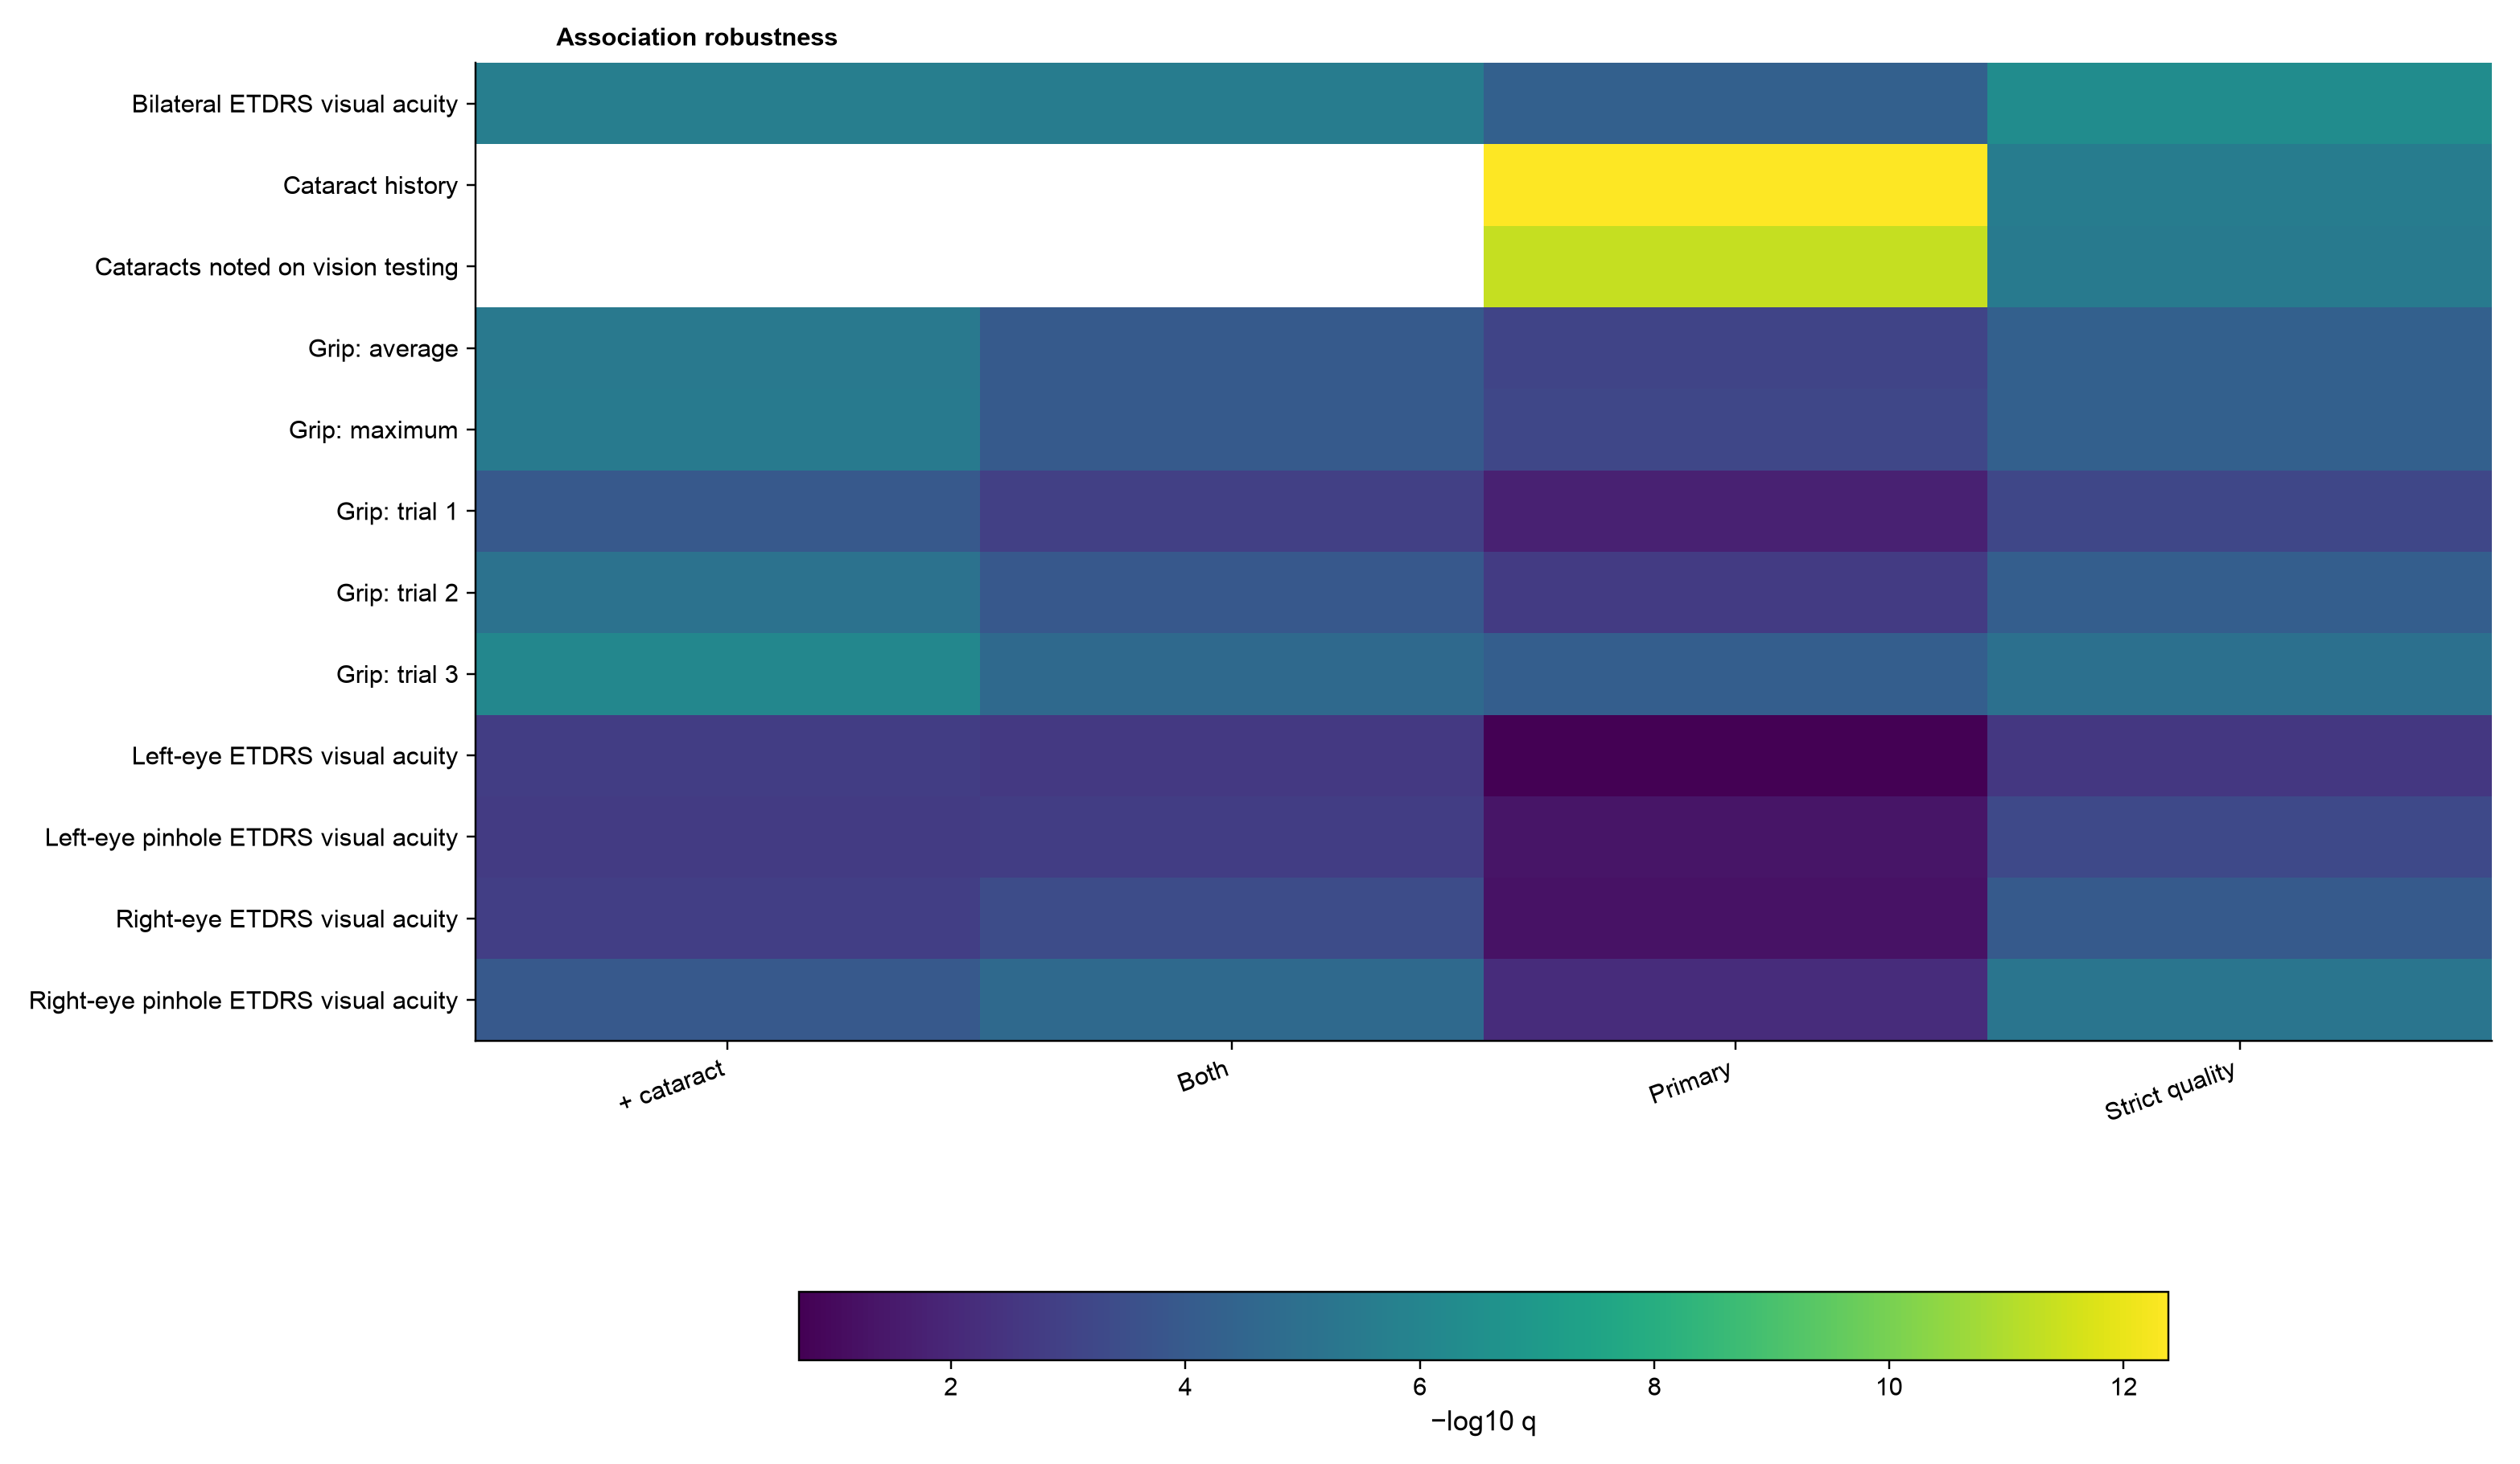

Source: acuity_grip_cataract_quality_sensitivity.csv (cell 37)

Figure S6 — Expanded retinal sensitivity analyses · Panel B

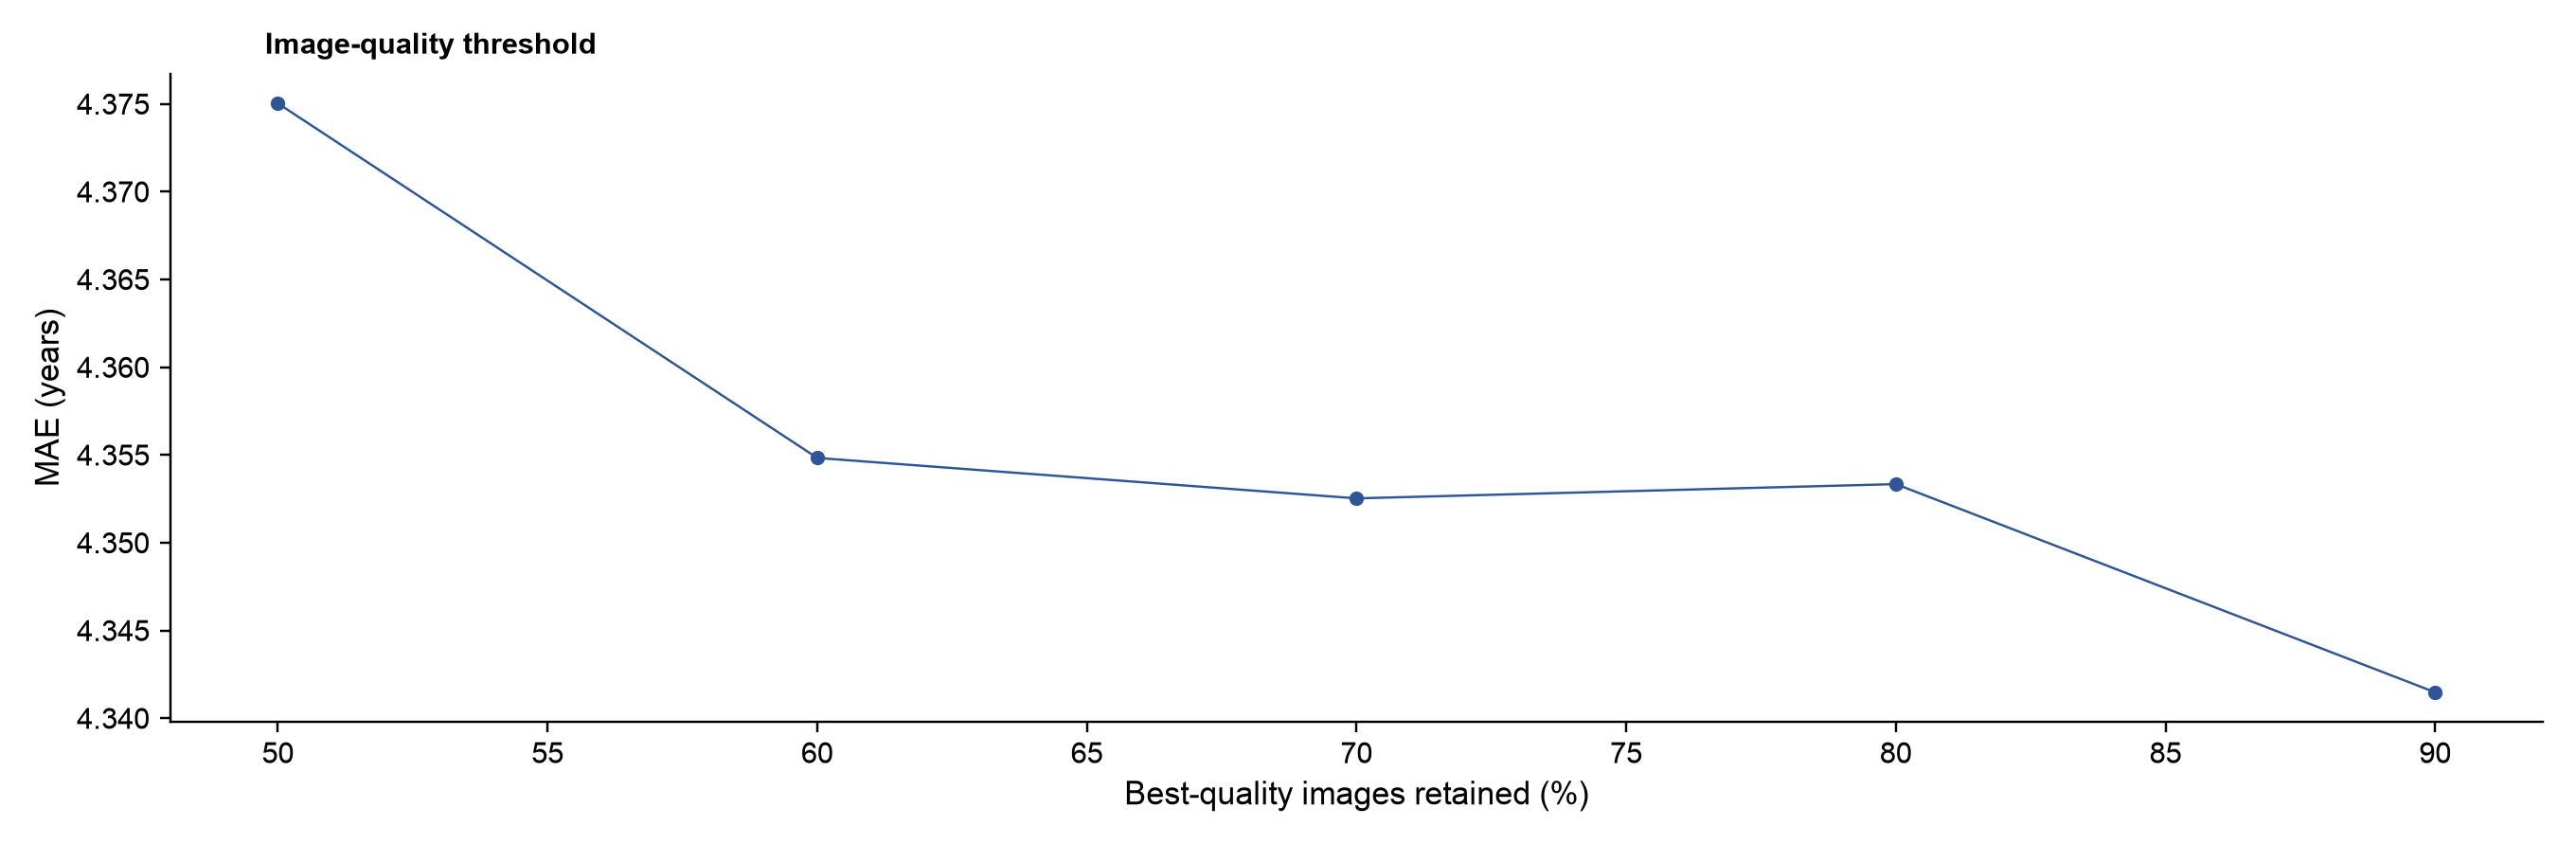

Source: quality_threshold_performance_curve.csv (cell 45)

In [ ]:
# PNG series for manuscript Figure S6.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "S6"])


Figure S7 — Same-eye acuity and complete longitudinal specifications · Panel A

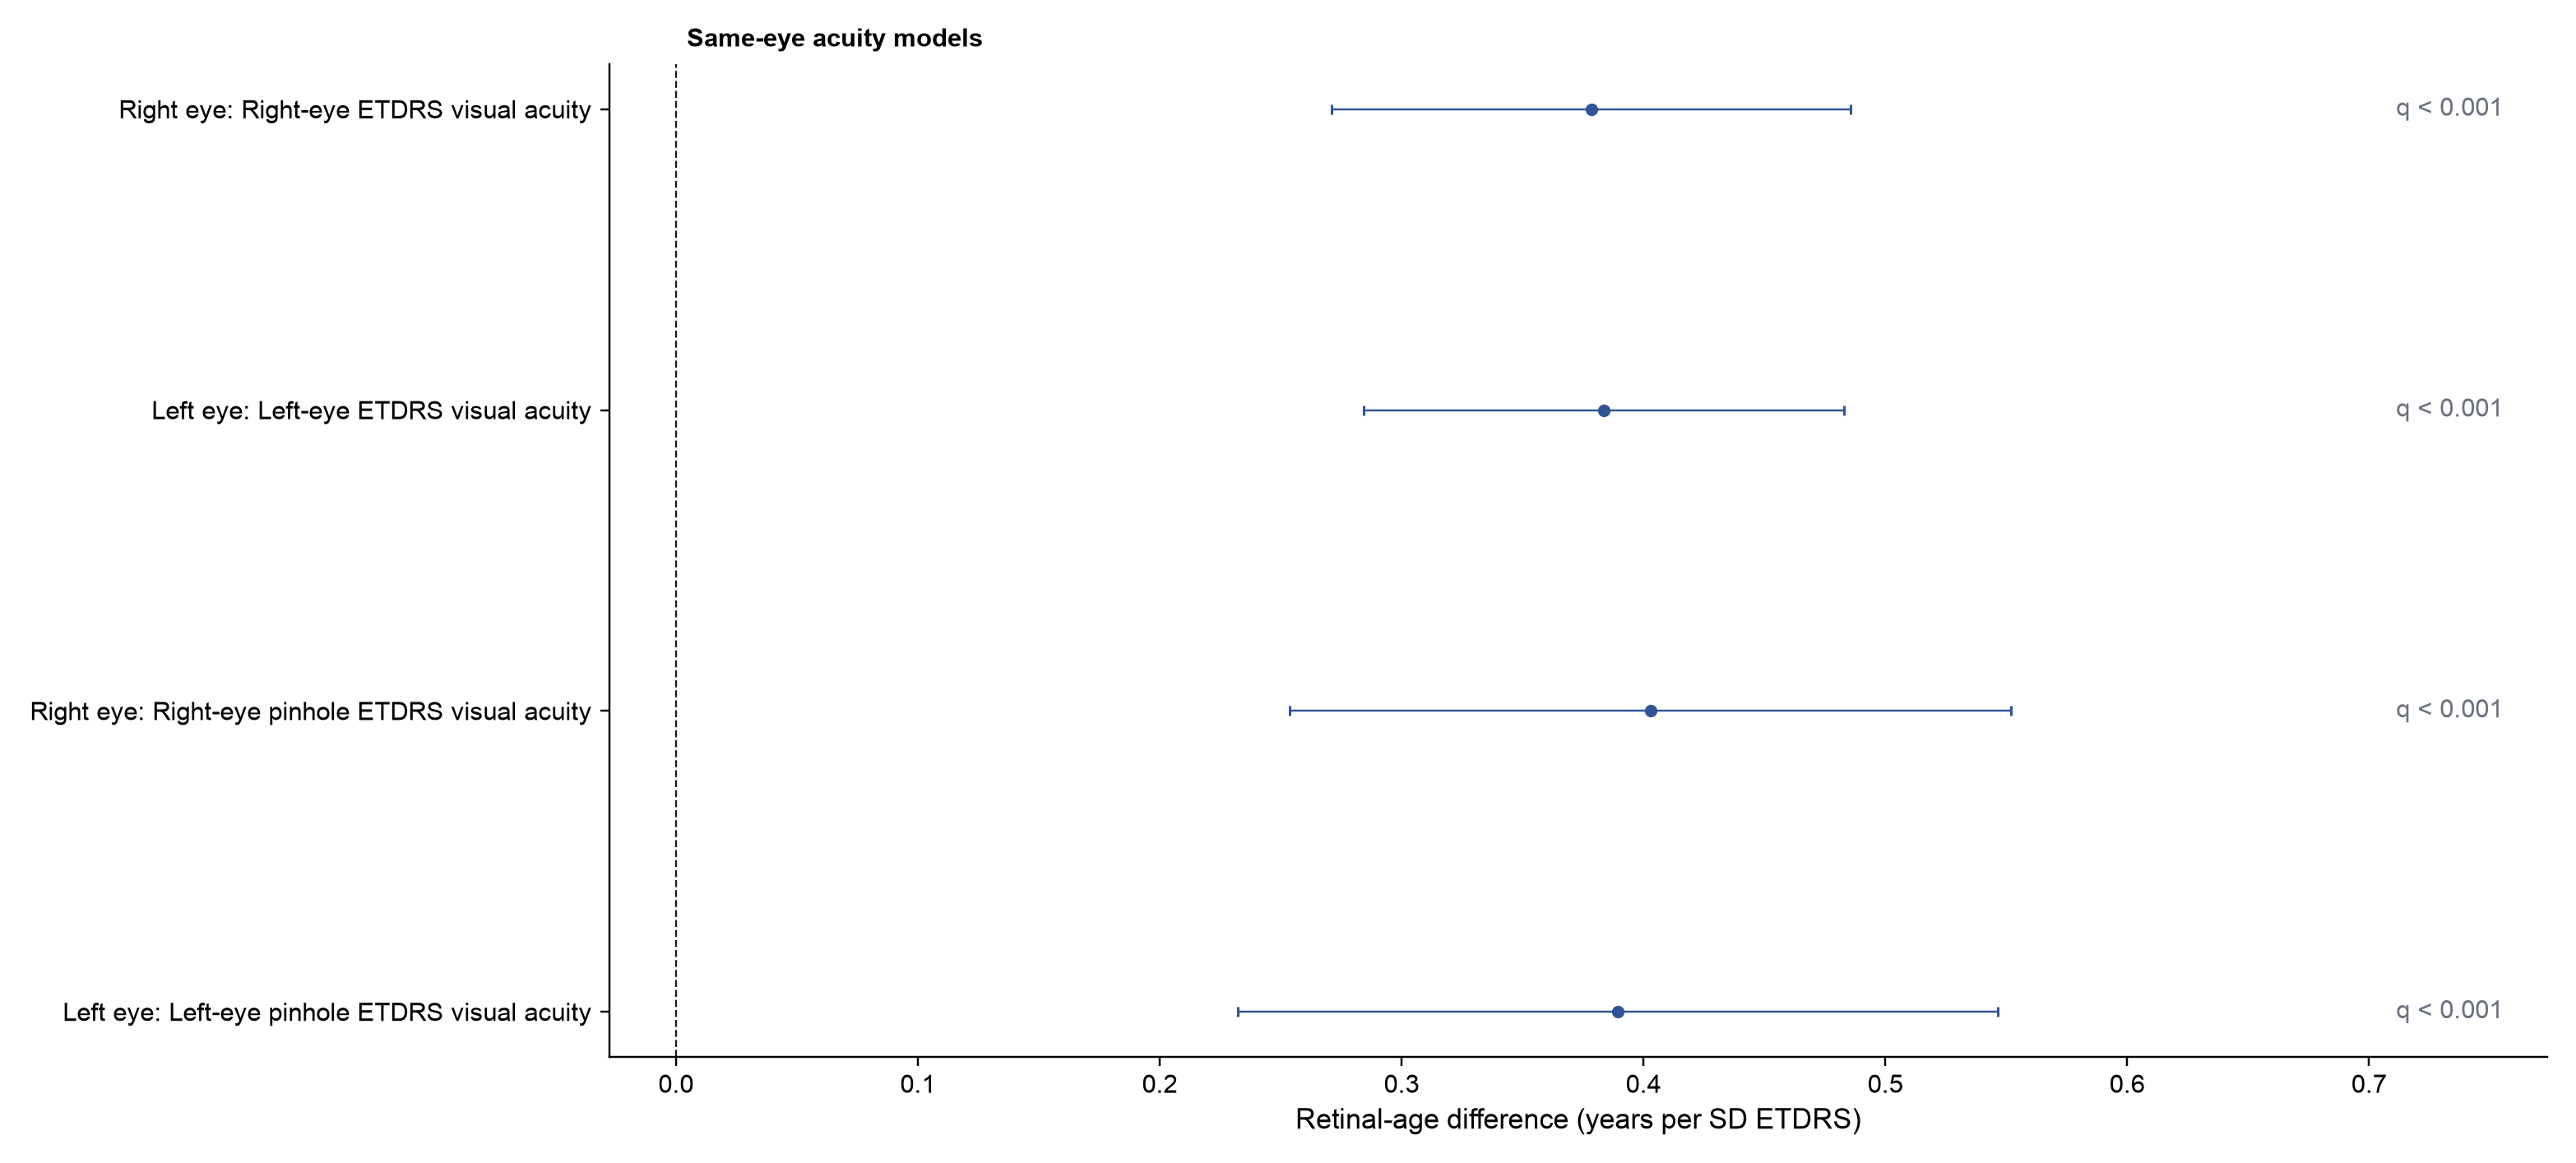

Source: eye_specific_etdrs_associations.csv (cell 47)

Figure S7 — Same-eye acuity and complete longitudinal specifications · Panel B

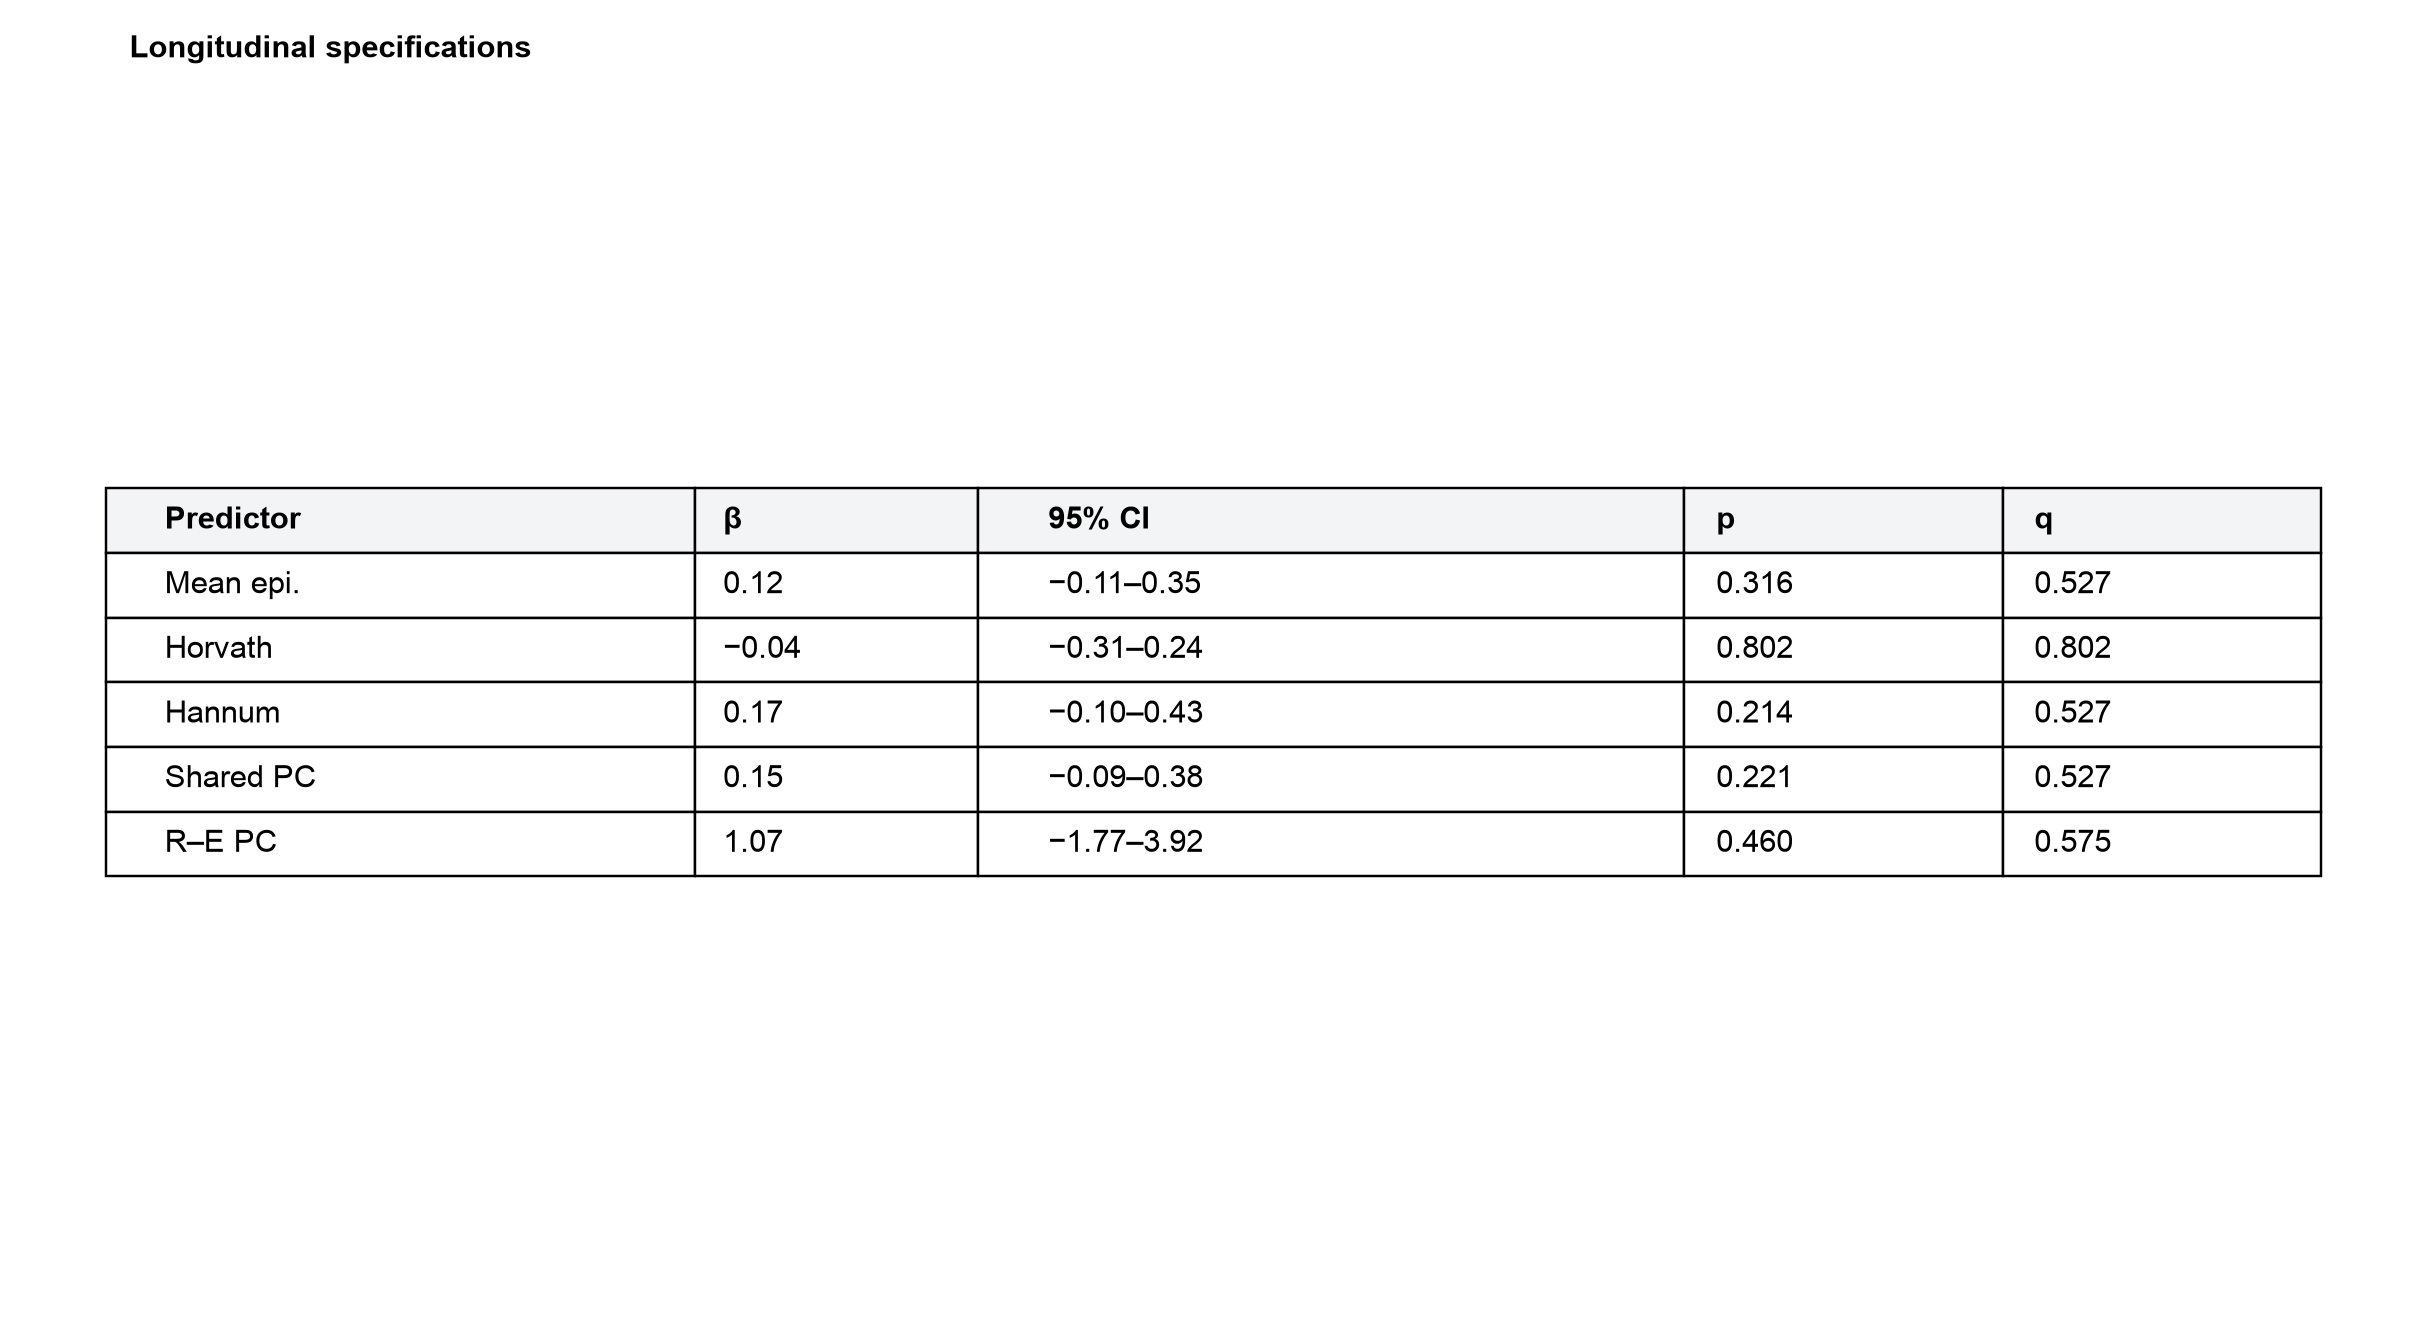

Source: baseline_epigenetic_to_followup_retinal_associations.csv (cell 39)

In [ ]:
# PNG series for manuscript Figure S7.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "S7"])


Figure S8 — Exploratory comorbidity analyses · Panel A

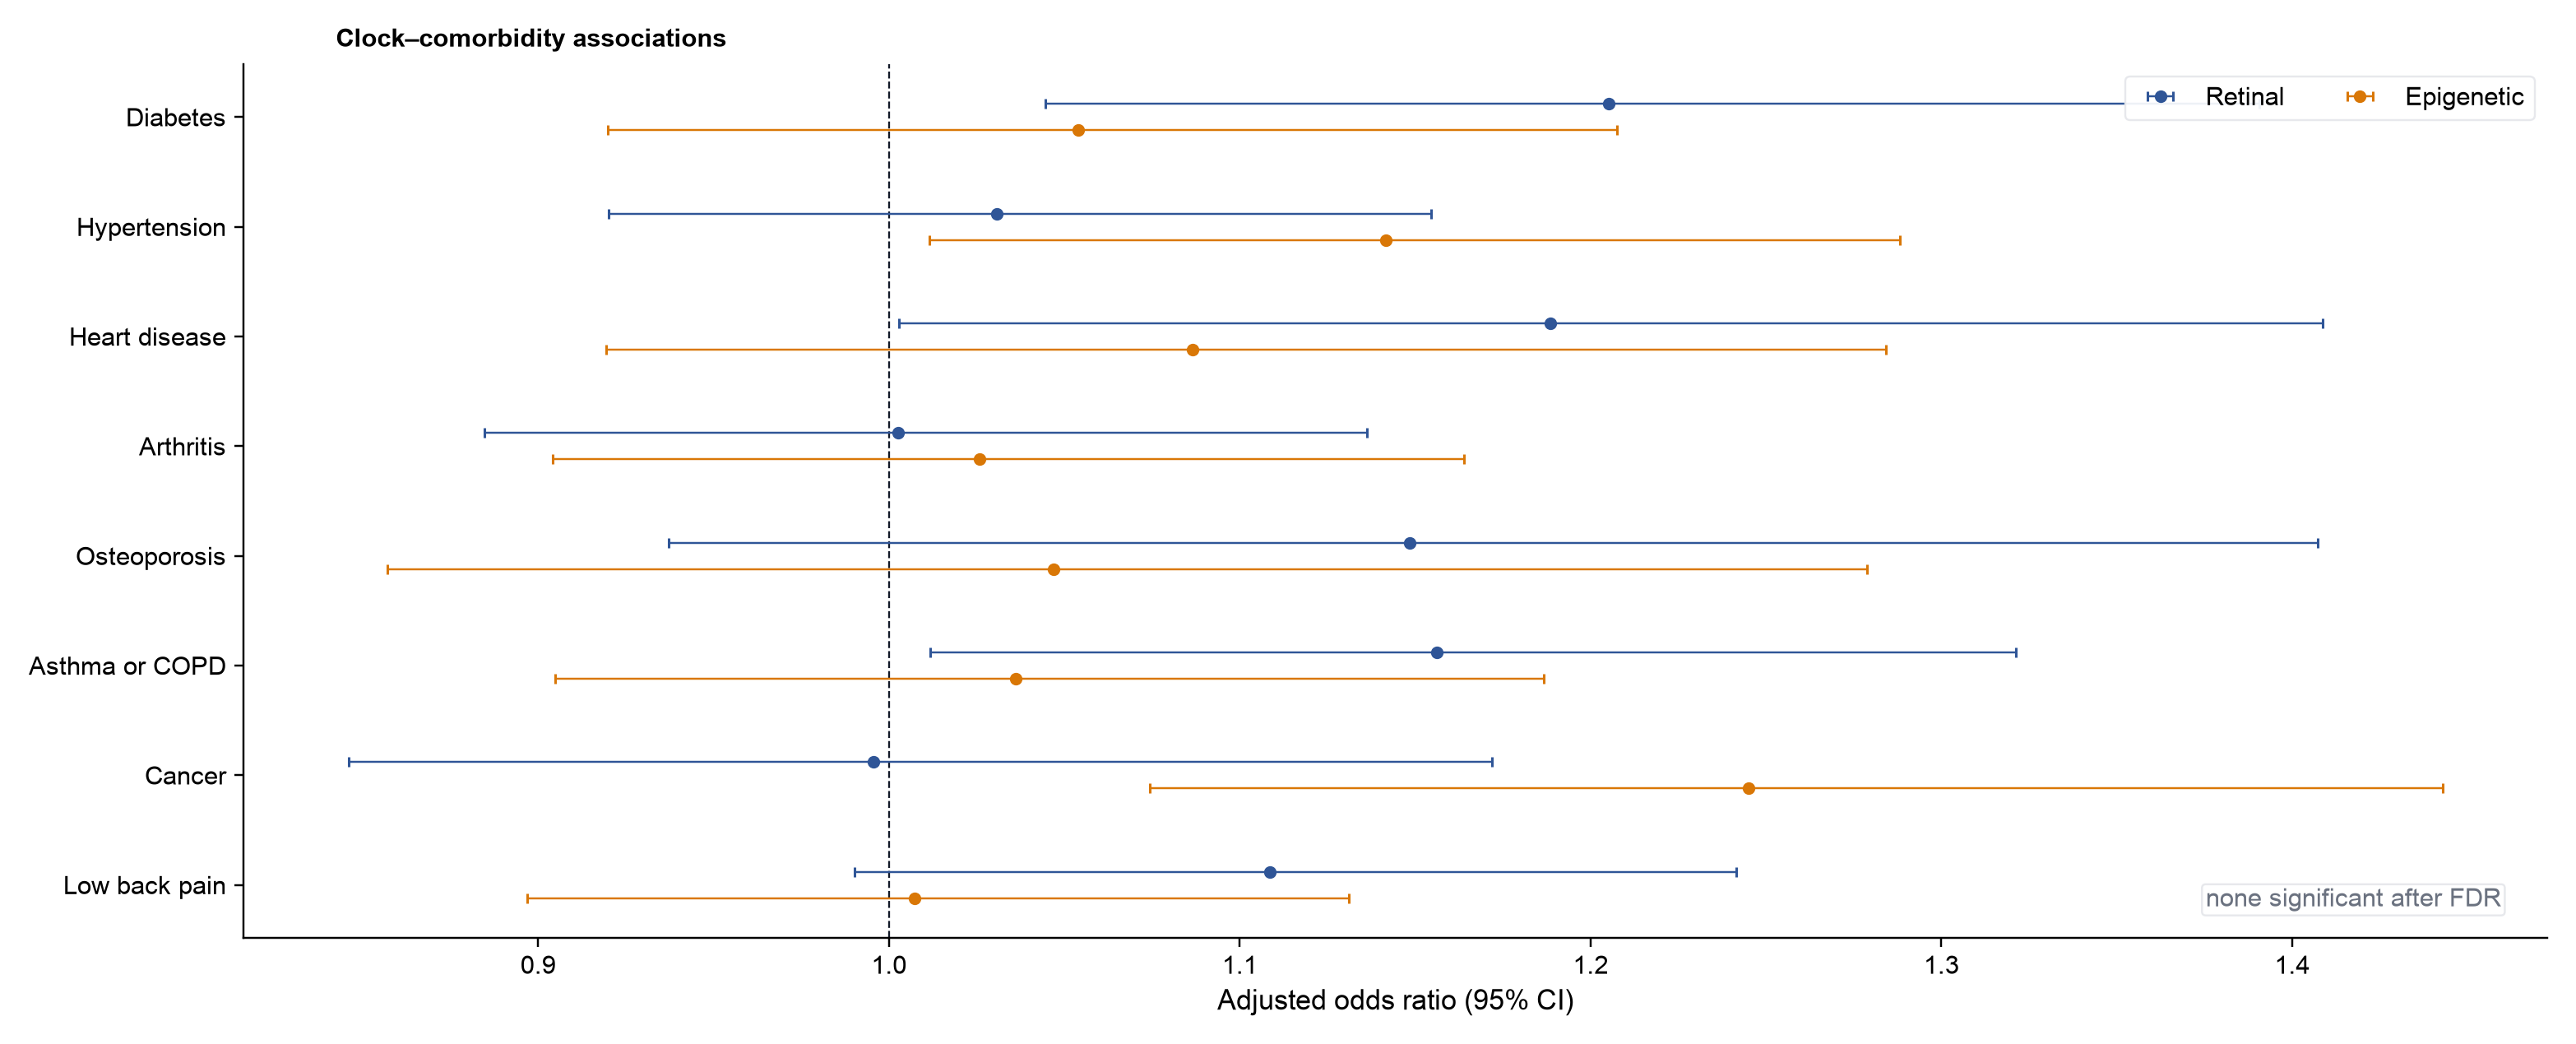

Source: patient_clock_comorbidity_associations.csv (cell 28)

Figure S8 — Exploratory comorbidity analyses · Panel B

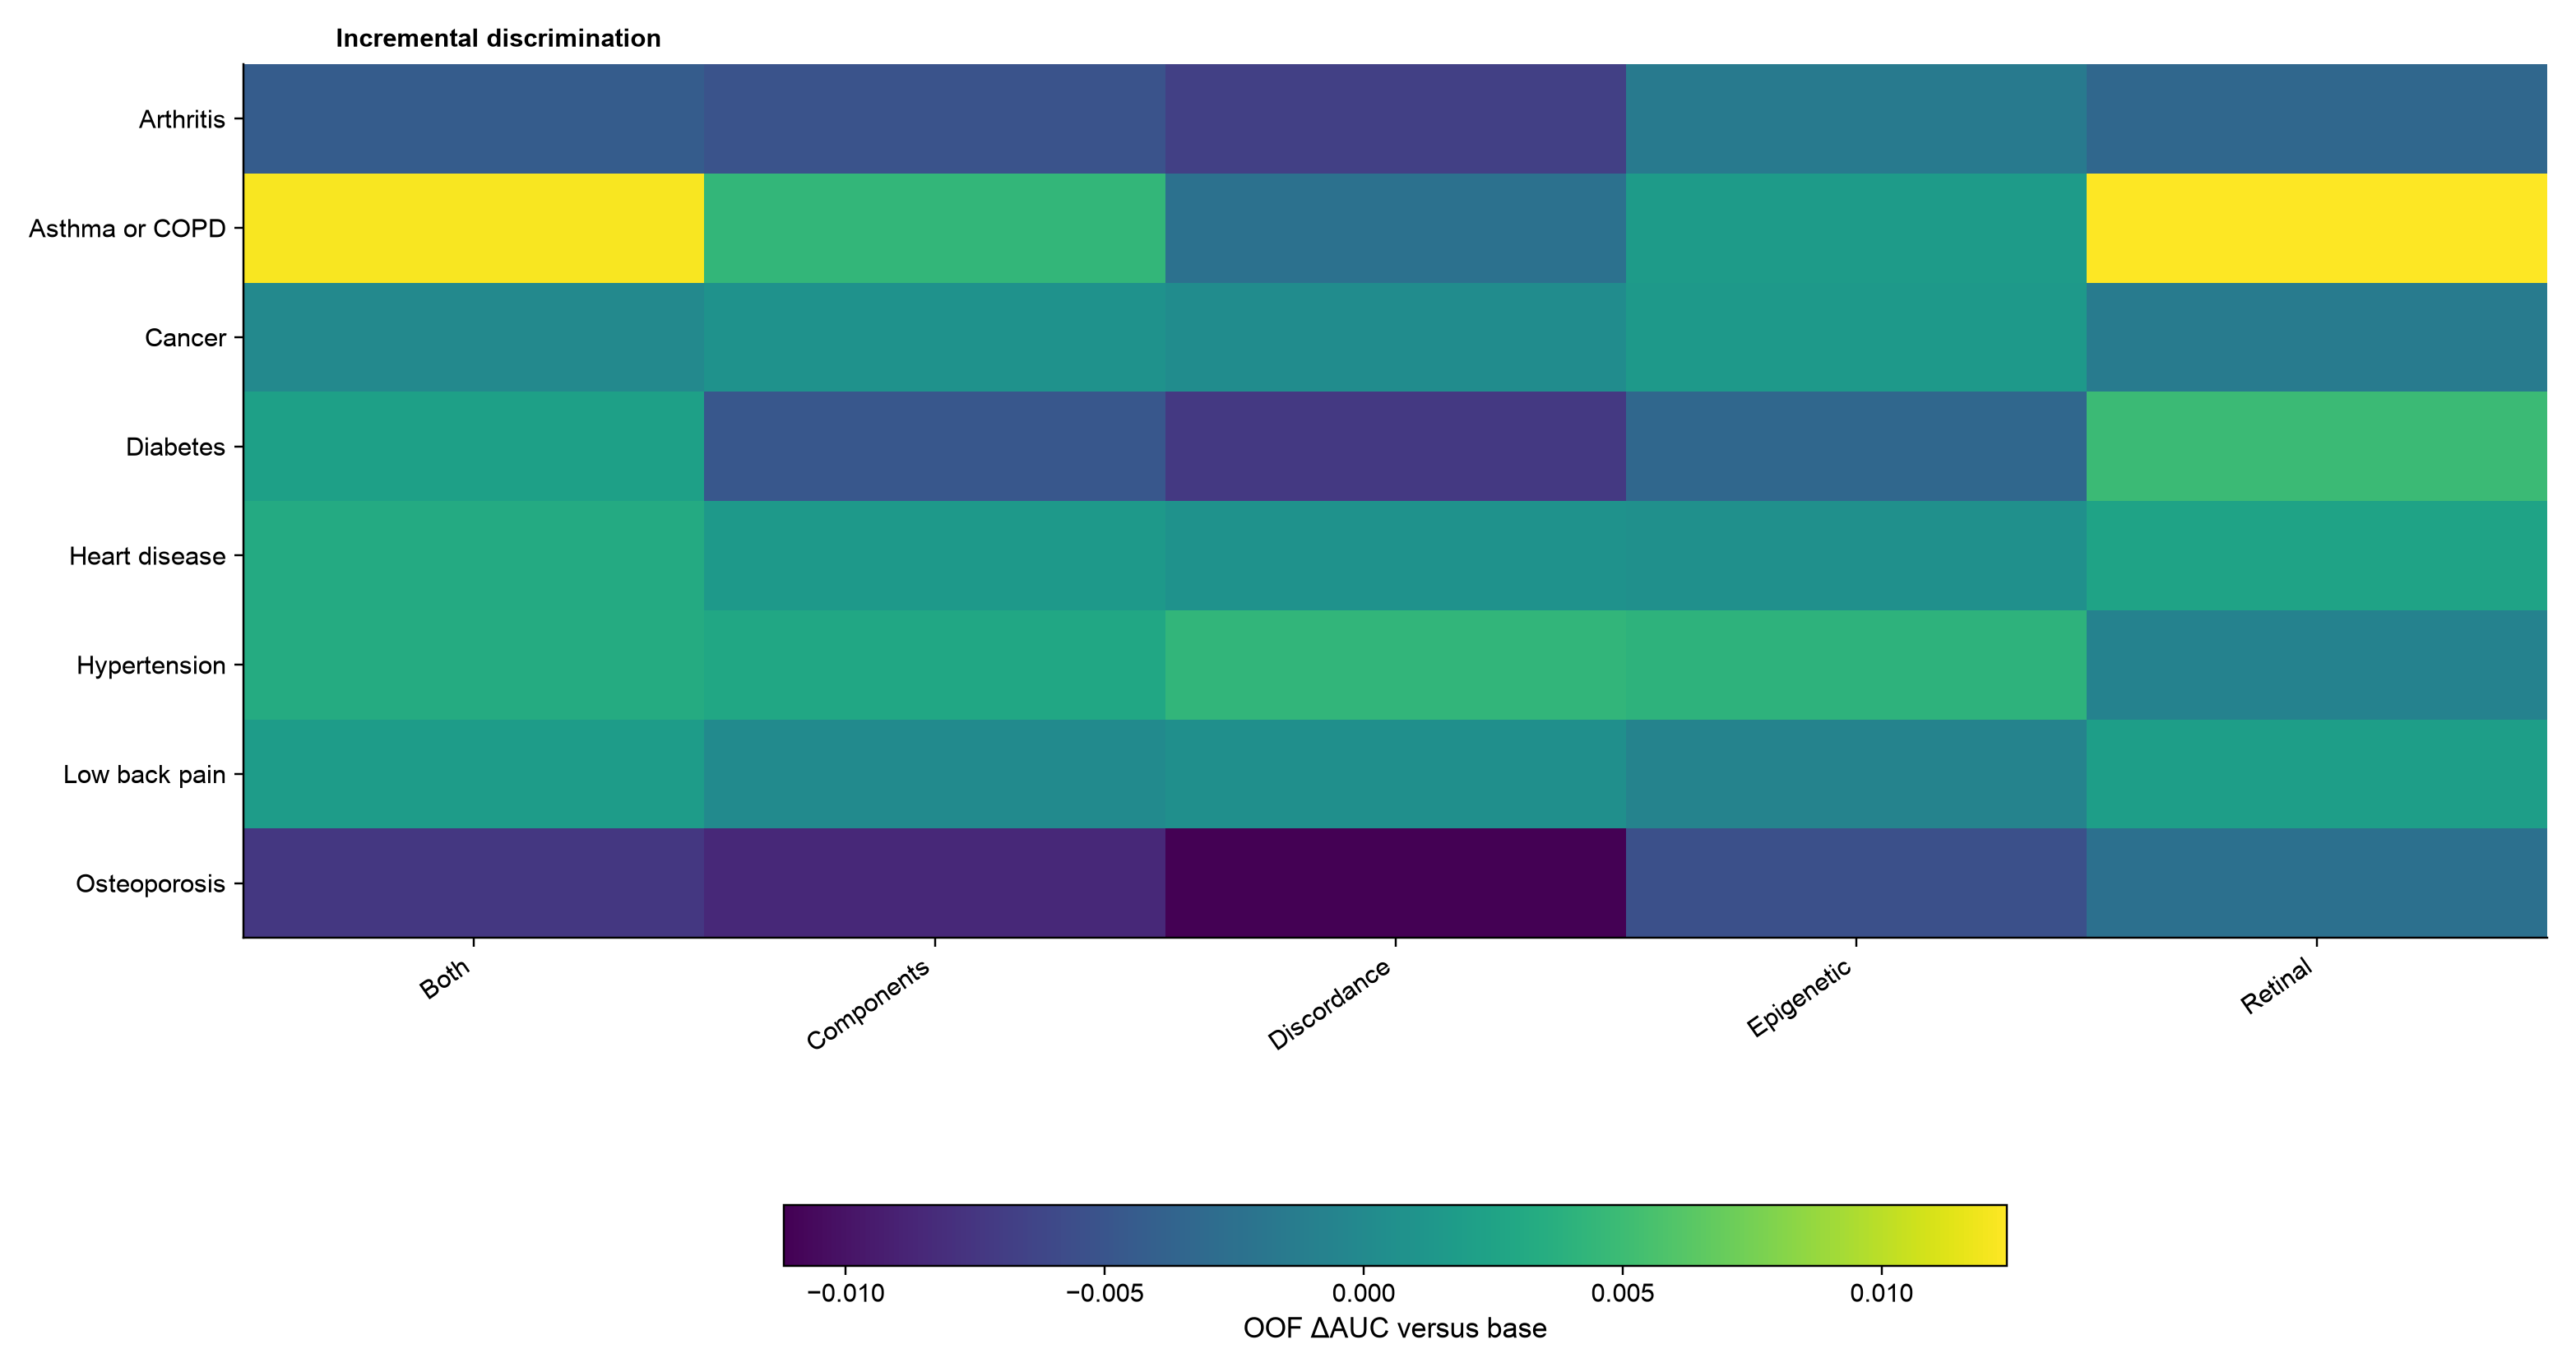

Source: comorbidity_incremental_prediction_metrics.csv (cell 30)

In [ ]:
# PNG series for manuscript Figure S8.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "S8"])


Figure S9 — Expanded methylation-age prediction beyond age · Panel A

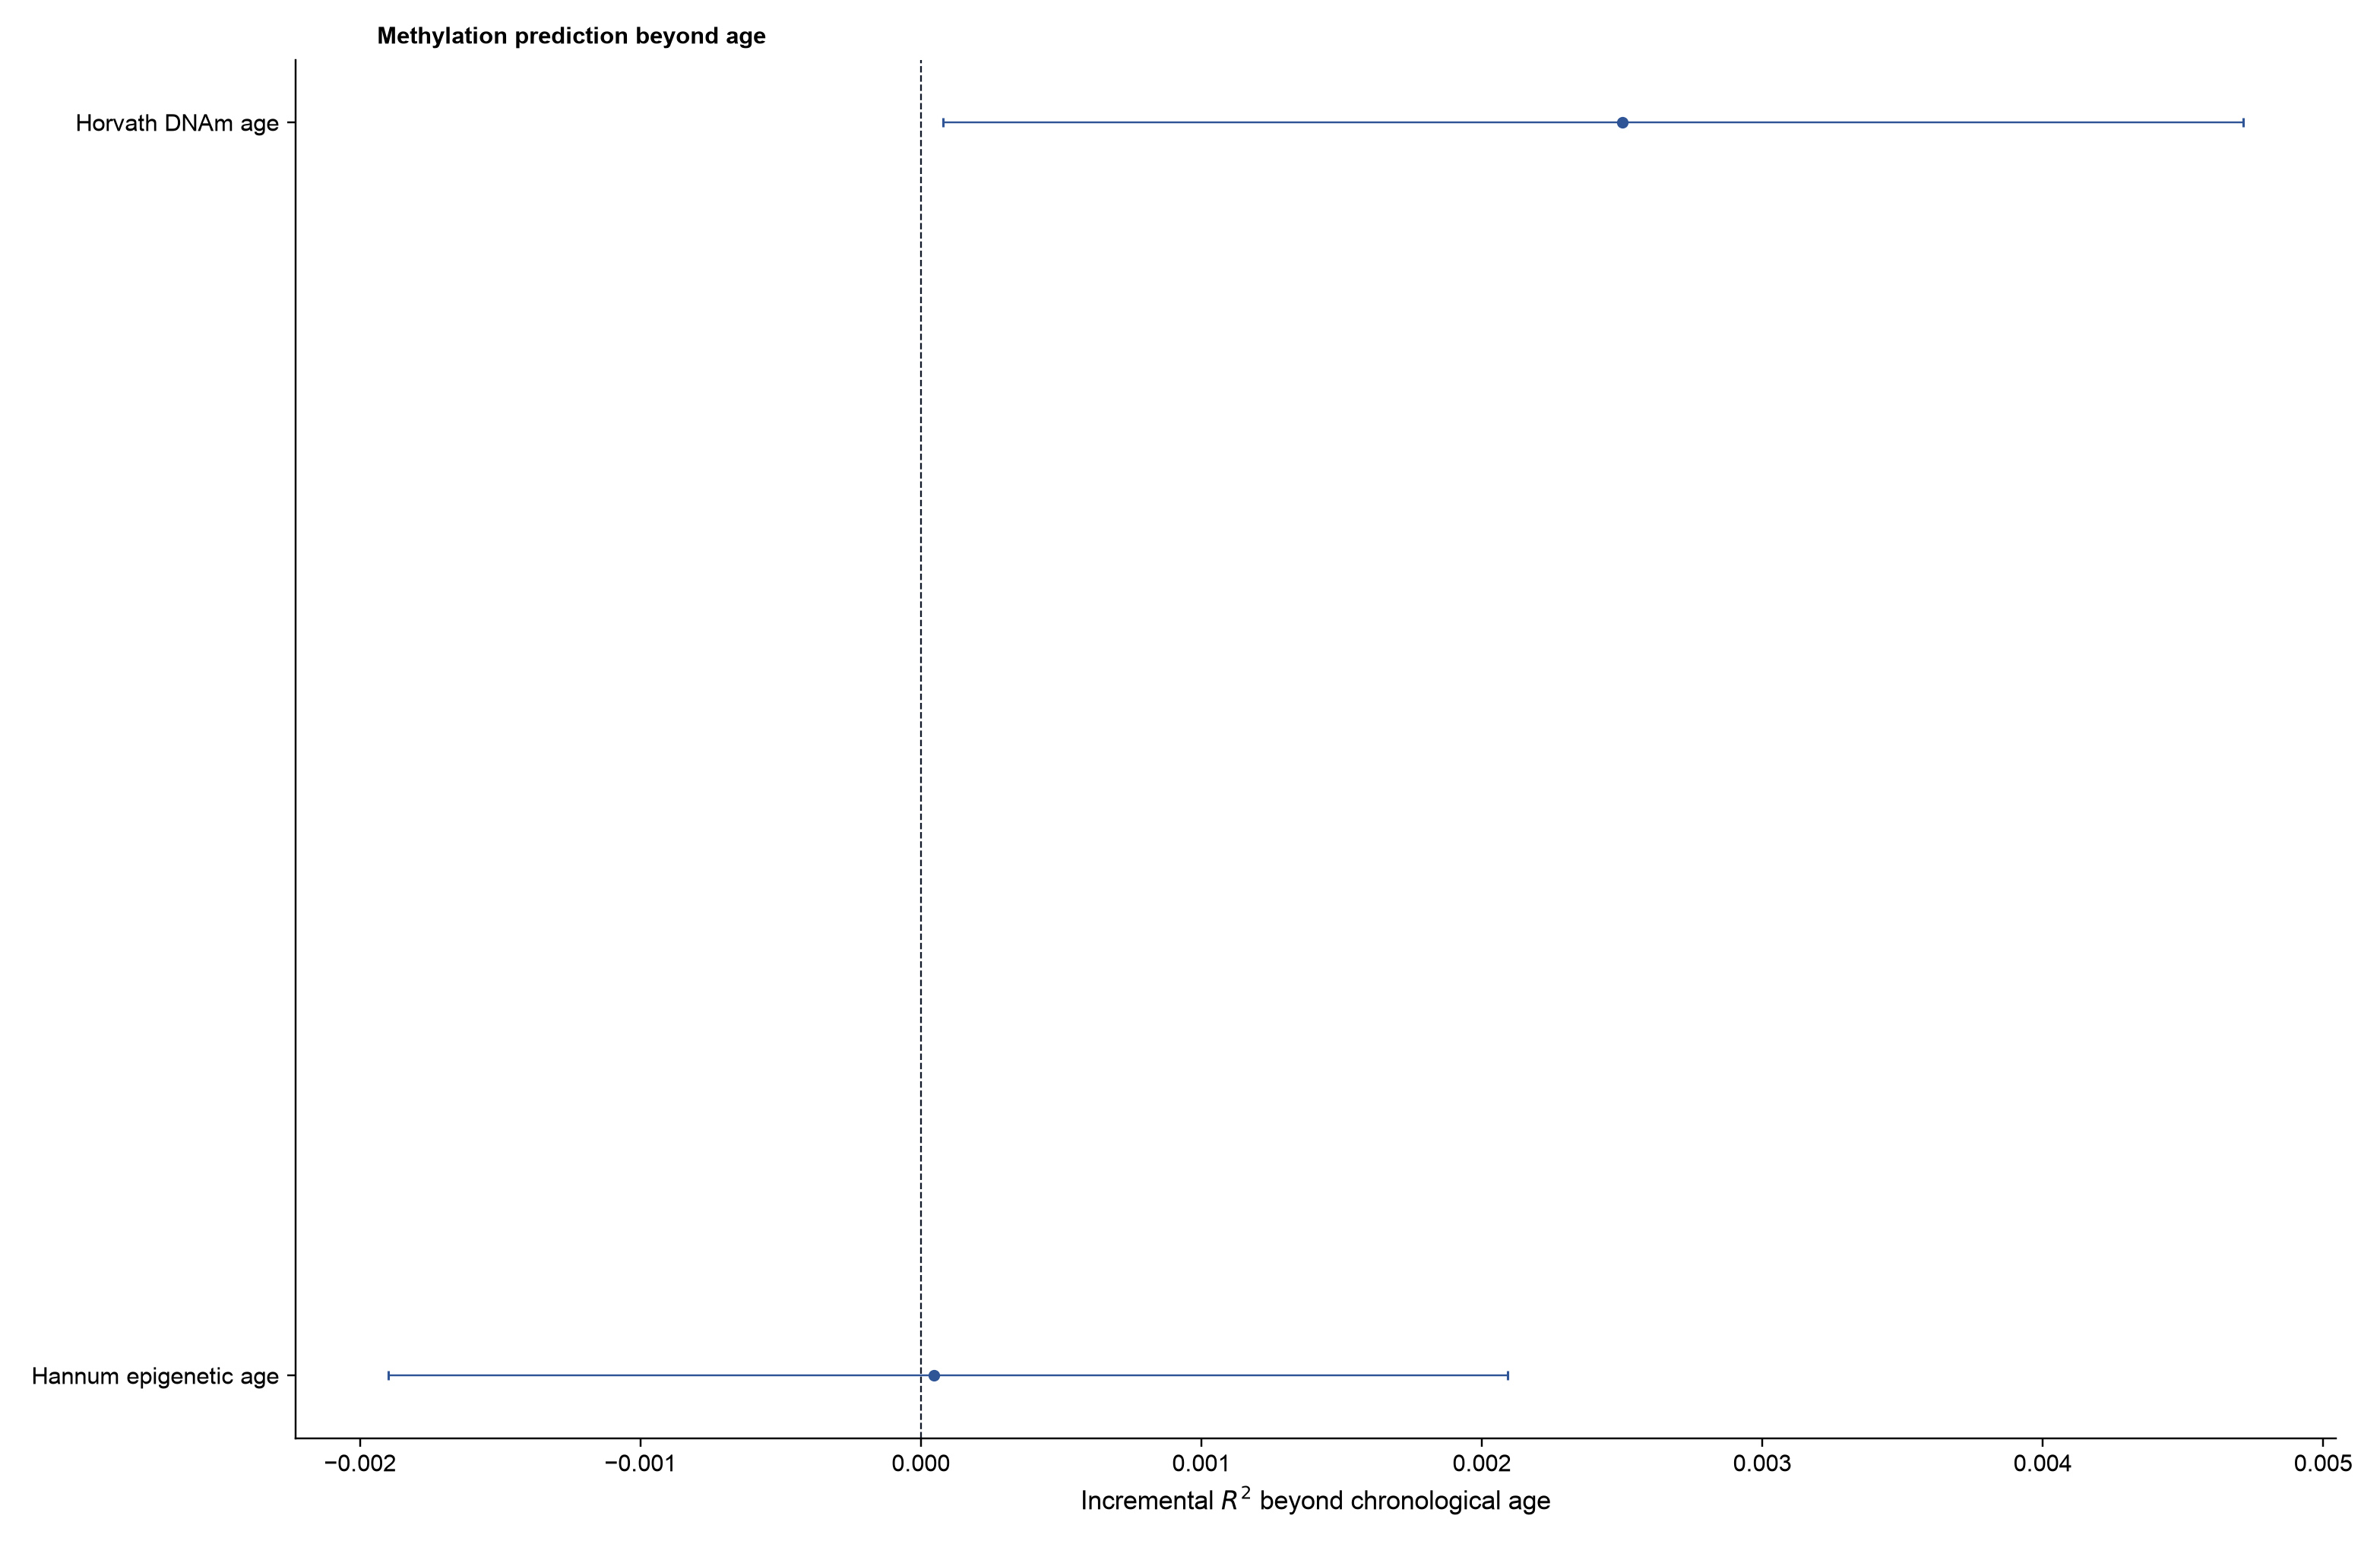

Source: epigenetic_target_prediction_beyond_age.csv (cell 49)

In [ ]:
# PNG series for manuscript Figure S9.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "S9"])


Figure S10 — Construct robustness across epigenetic definitions · Panel A

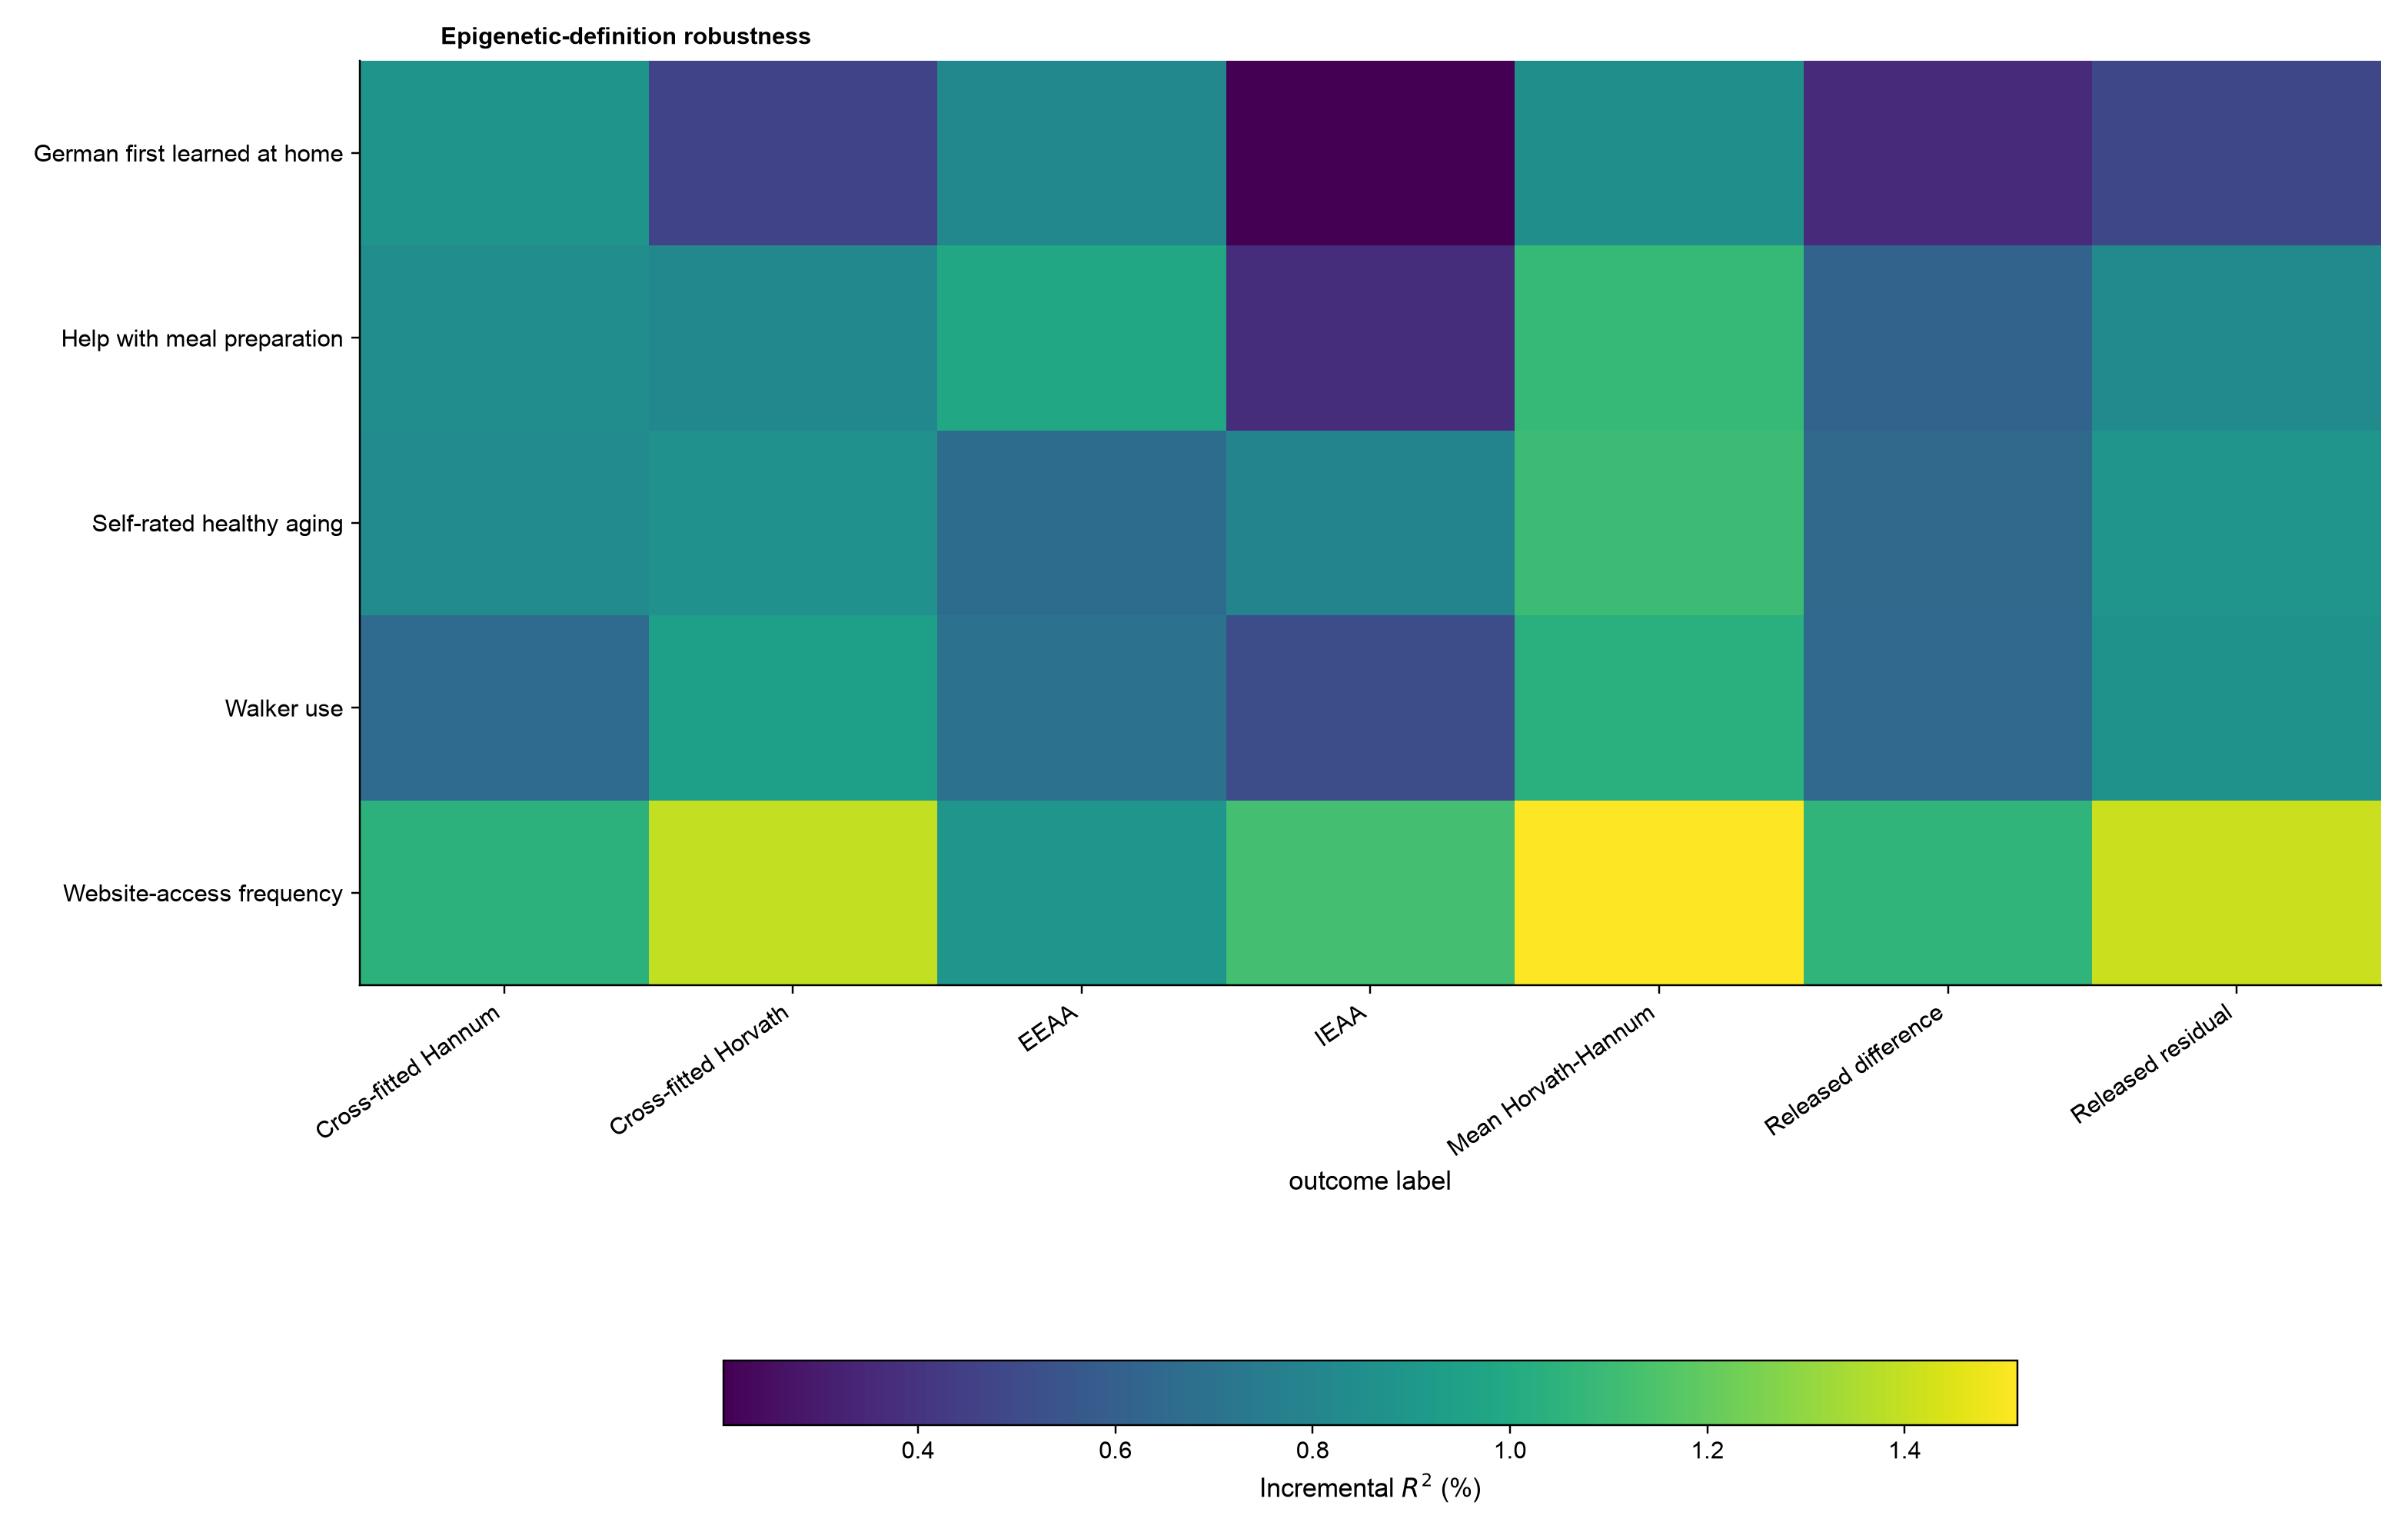

Source: epigenetic_definition_construct_robustness.csv (cell 51)

In [ ]:
# PNG series for manuscript Figure S10.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "S10"])


Figure S11 — Expanded longitudinal change, attrition, and stability · Panel A

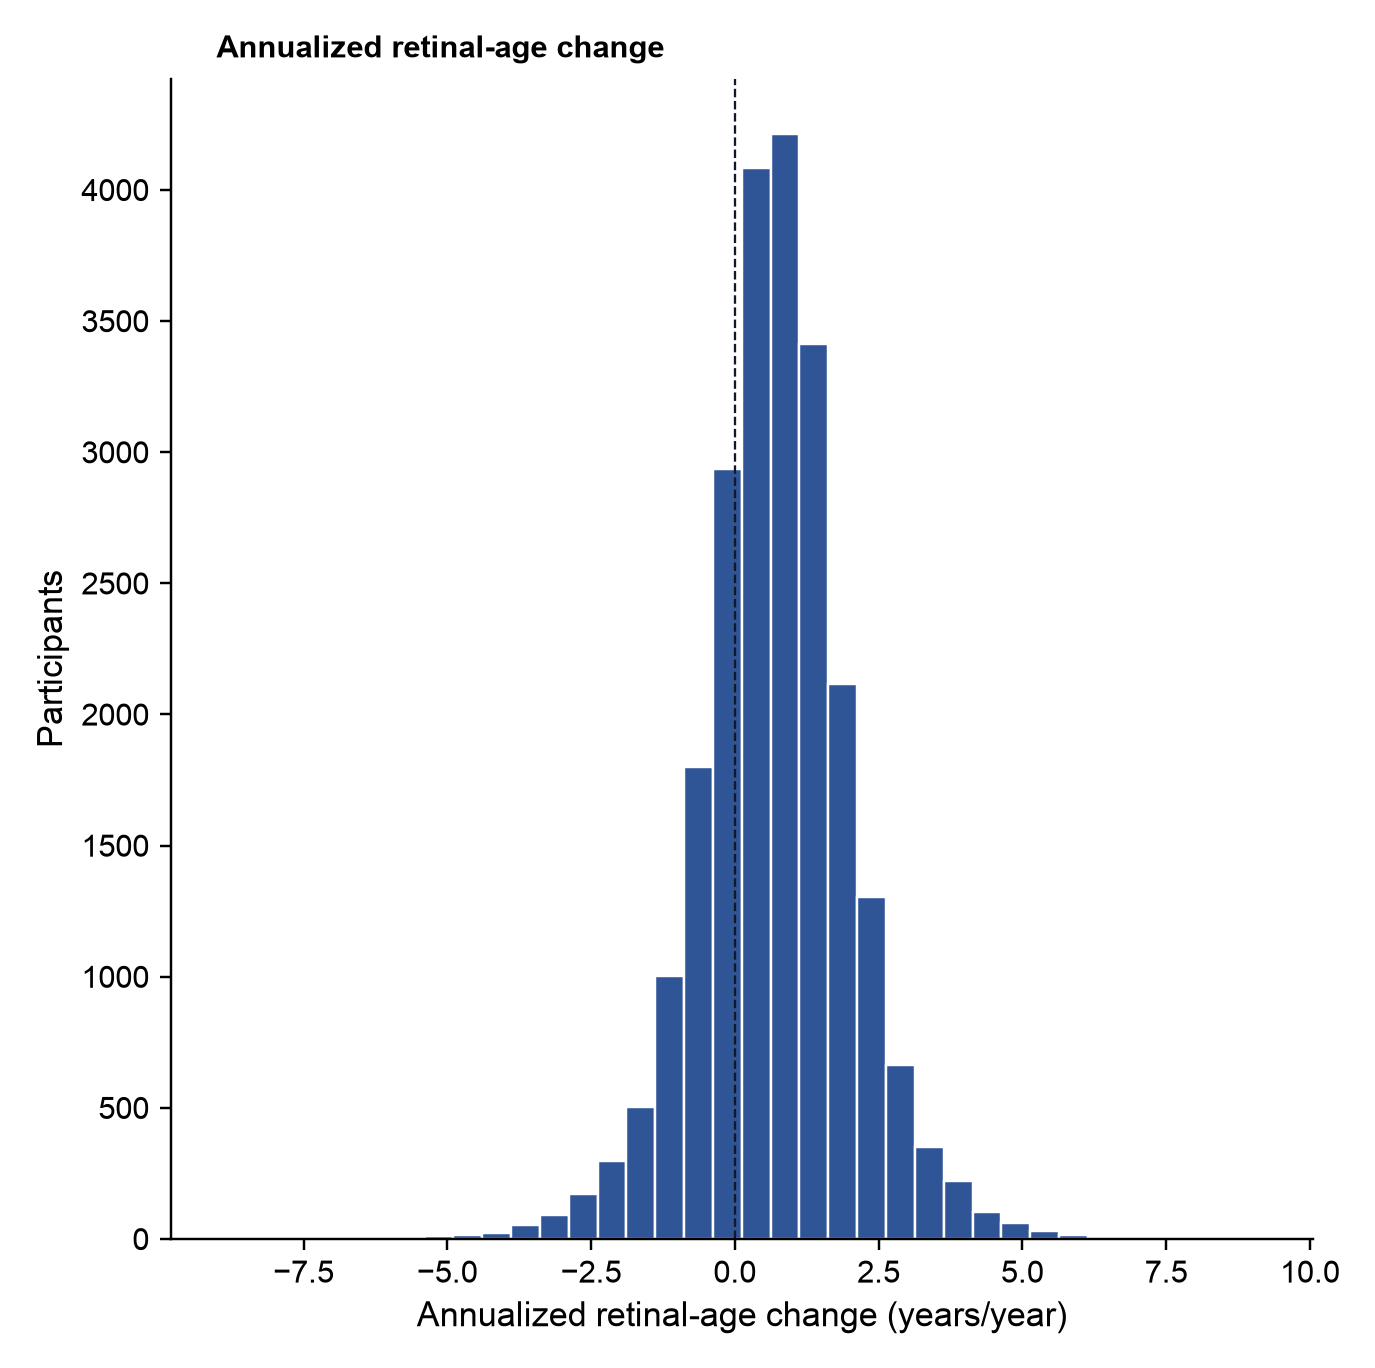

Source: figure_S11_annualized_change.csv (cell 53)

Figure S11 — Expanded longitudinal change, attrition, and stability · Panel B

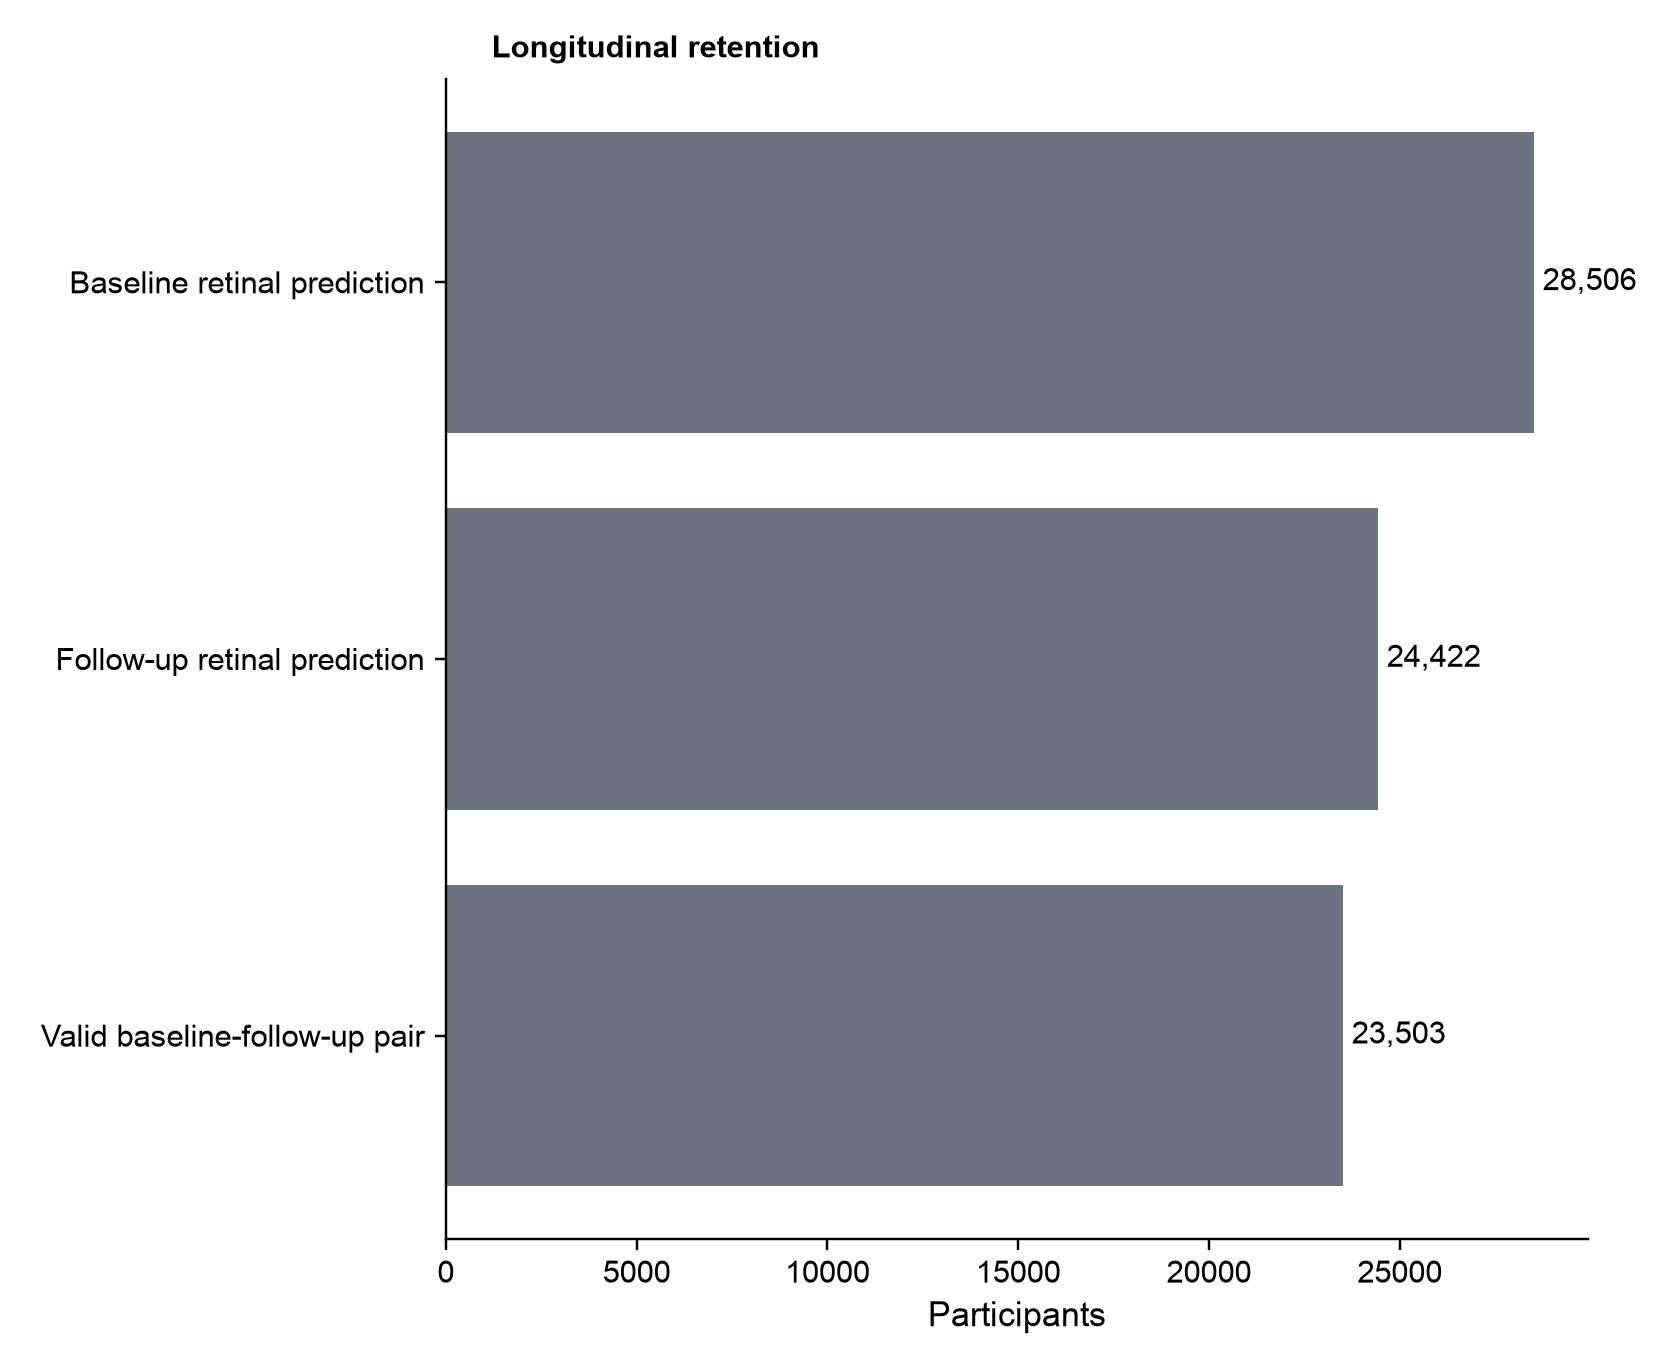

Source: figure_S11_attrition.csv (cell 53)

Figure S11 — Expanded longitudinal change, attrition, and stability · Panel C

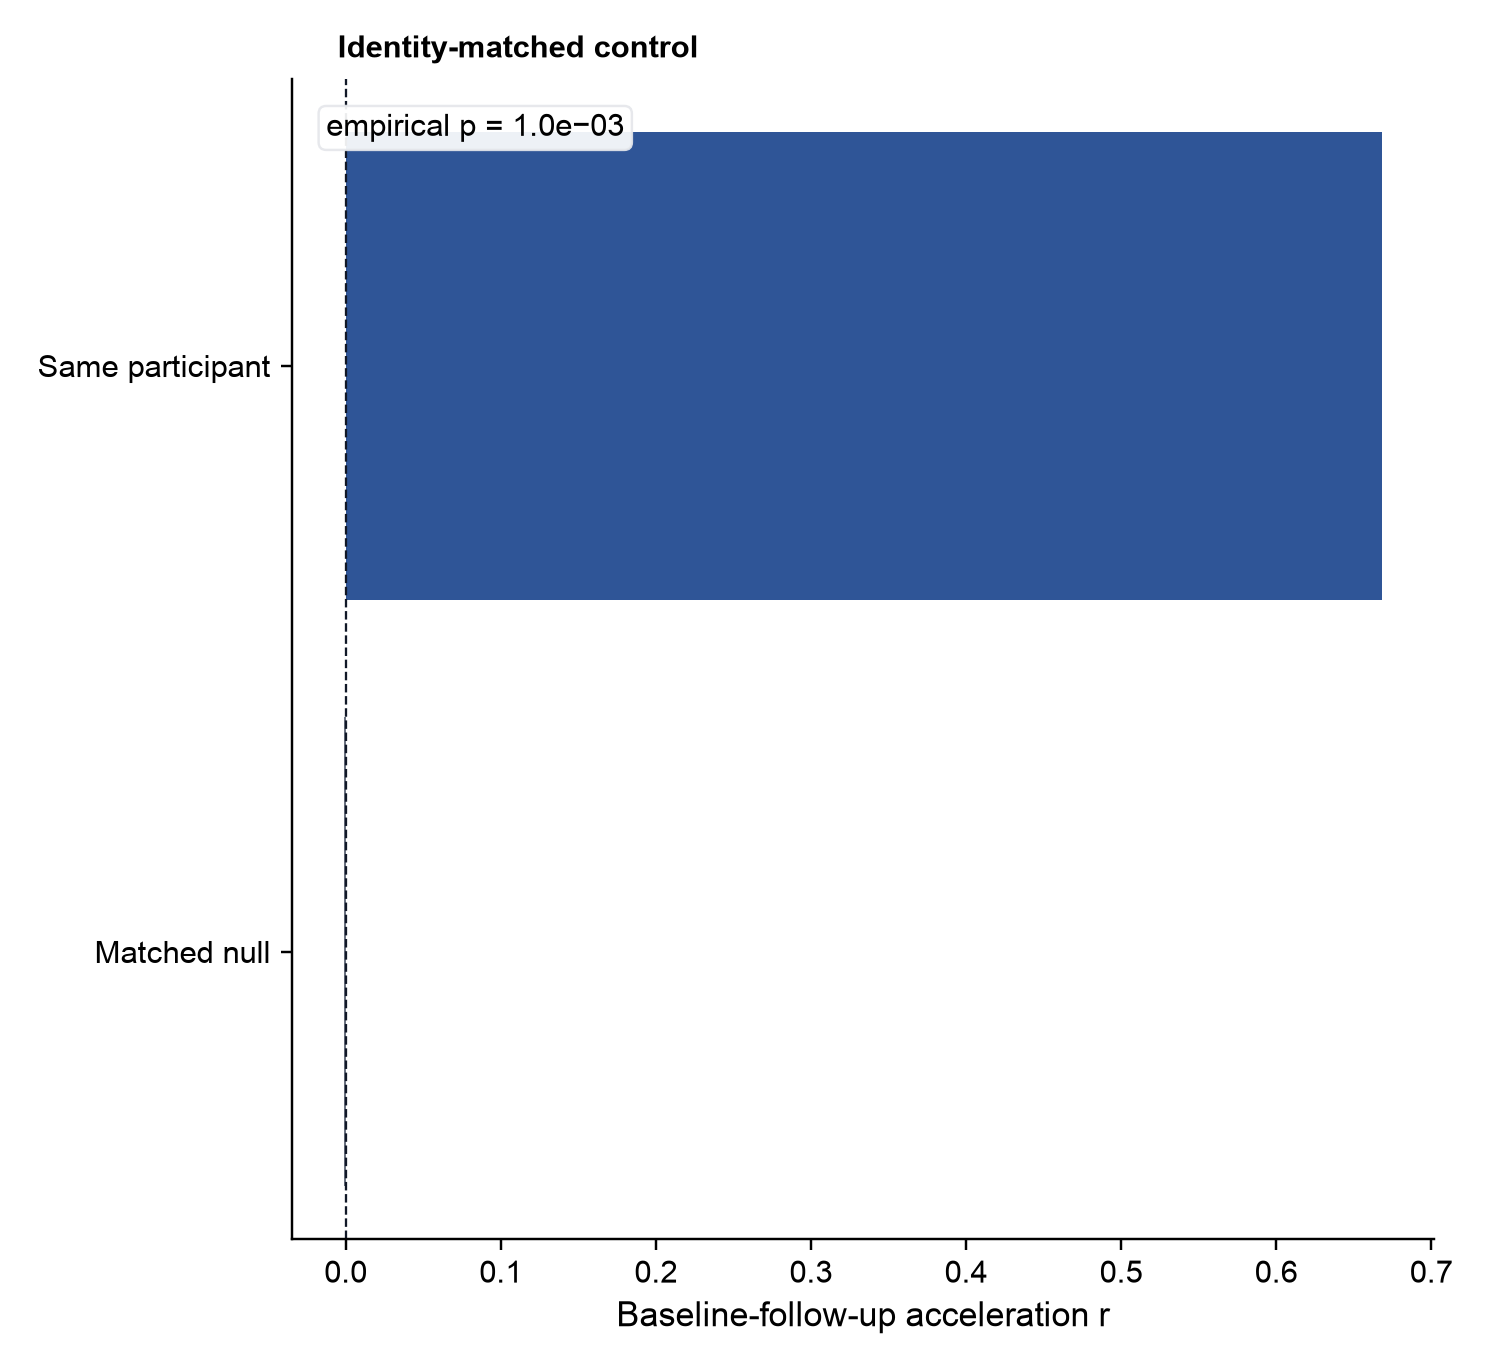

Source: longitudinal_same_person_matched_null_test.csv (cell 53)

Figure S11 — Expanded longitudinal change, attrition, and stability · Panel D

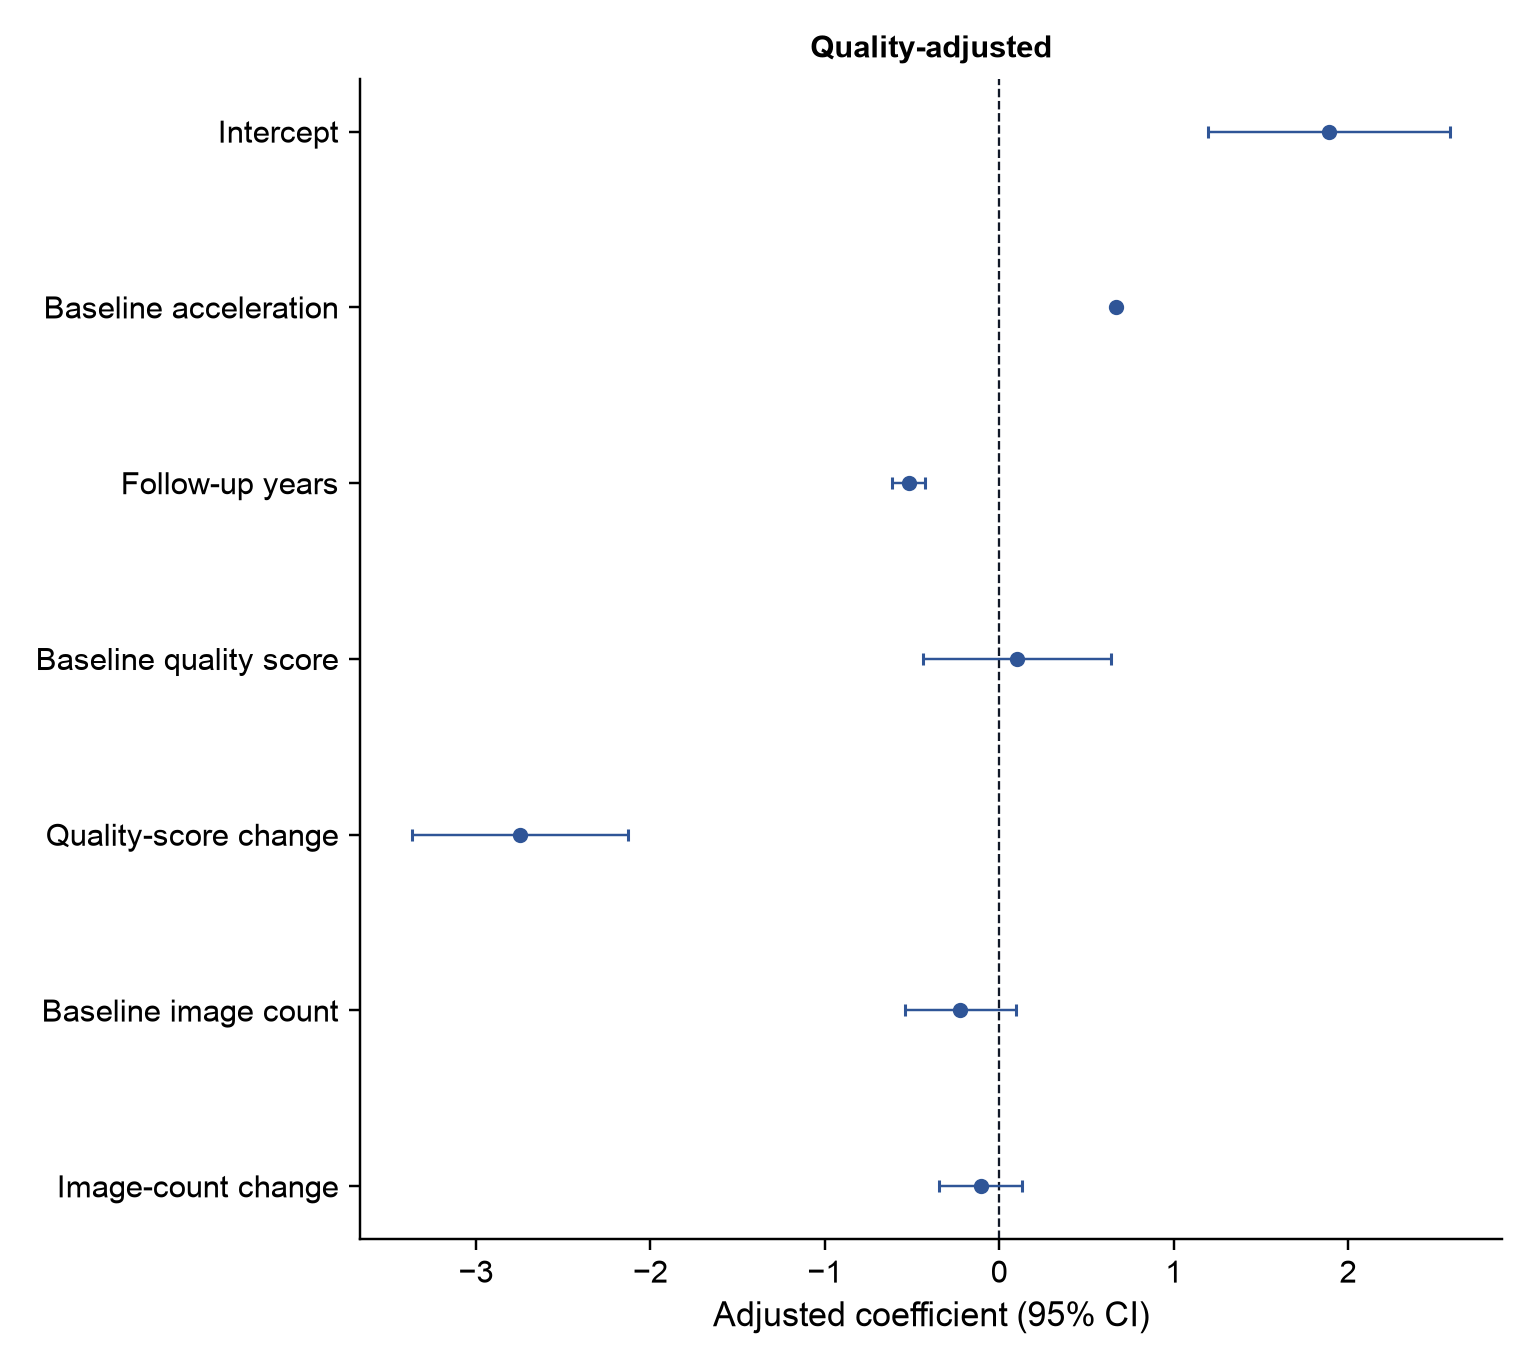

Source: longitudinal_quality_adjusted_stability.csv (cell 53)

In [ ]:
# PNG series for manuscript Figure S11.
_clsa_fix_engine.display_png_series([e for e in fixed_png_entries if e["figure_id"] == "S11"])
